In [1]:
# ============================================================
# MASTER AI CAREER-ANXIETY COMPARATIVE RESEARCH
# STEP 1 — ENVIRONMENT, DATA LOADING & RESEARCH CONFIGURATION
# ============================================================
#
# Research order:
#   1. Entire Dataset
#   2. Public University Cohort
#   3. Private University Cohort
#   4. Daffodil Cohort
#
# IMPORTANT:
# - This notebook is the standardized master implementation.
# - The original four notebooks are the methodological references.
# - Do NOT modify the raw dataset in-place.
# - Do NOT fit preprocessing on the held-out test set.
# - Do NOT use the test set for feature selection/model selection.
# ============================================================


# ============================================================
# 1. INSTALL / IMPORT REQUIRED PACKAGES
# ============================================================

!pip -q install imbalanced-learn shap openpyxl xgboost

import os
import re
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Scikit-learn
import sklearn
from sklearn import __version__ as sklearn_version

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    make_scorer
)

# Imbalanced-learn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# SHAP
import shap

# Optional XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("XGBoost unavailable:", e)


# ============================================================
# 2. GLOBAL RESEARCH CONFIGURATION
# ============================================================

RANDOM_STATE = 42

TEST_SIZE = 0.20

CV_FOLDS = 10
CV_SHUFFLE = True

ROBUSTNESS_REPEATS = 5

# Primary optimization metric.
# We will use F1 consistently in the primary experiment.
PRIMARY_SCORING = "f1"

# All required evaluation metrics
METRIC_NAMES = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "MCC",
    "Cohen_Kappa"
]

# Research execution order
COHORT_ORDER = [
    "Overall",
    "Public",
    "Private",
    "Daffodil"
]

# Reproducibility
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)

print("=" * 80)
print("MASTER AI CAREER-ANXIETY COMPARATIVE RESEARCH")
print("=" * 80)

print(f"Python environment initialized")
print(f"scikit-learn version: {sklearn_version}")
print(f"Random state: {RANDOM_STATE}")
print(f"Test size: {TEST_SIZE}")
print(f"Cross-validation: Stratified {CV_FOLDS}-Fold")
print(f"Primary optimization metric: {PRIMARY_SCORING}")
print(f"XGBoost available: {XGBOOST_AVAILABLE}")


# ============================================================
# 3. UPLOAD DATASET
# ============================================================

from google.colab import files

print("\n" + "=" * 80)
print("UPLOAD THE ORIGINAL CAREER-ANXIETY DATASET")
print("=" * 80)

uploaded = files.upload()

if not uploaded:
    raise RuntimeError(
        "No file was uploaded. Please upload the original Excel dataset."
    )

uploaded_files = list(uploaded.keys())

print("\nUploaded files:")
for f in uploaded_files:
    print("  -", f)


# ============================================================
# 4. IDENTIFY DATASET FILE
# ============================================================

supported_files = [
    f for f in uploaded_files
    if f.lower().endswith((".xlsx", ".xls", ".csv"))
]

if len(supported_files) == 0:
    raise ValueError(
        "No supported dataset found. Please upload an Excel (.xlsx/.xls) "
        "or CSV (.csv) dataset."
    )

if len(supported_files) > 1:
    print("\nMultiple data files detected:")
    for i, f in enumerate(supported_files):
        print(f"{i}: {f}")

    # We deliberately do NOT silently choose among multiple datasets.
    raise ValueError(
        "Multiple dataset files were uploaded. "
        "Please upload only the intended original dataset and rerun this cell."
    )

DATASET_FILE = supported_files[0]

print(f"\nSelected dataset: {DATASET_FILE}")


# ============================================================
# 5. LOAD DATASET
# ============================================================

if DATASET_FILE.lower().endswith(".csv"):
    df_raw = pd.read_csv(DATASET_FILE)

elif DATASET_FILE.lower().endswith((".xlsx", ".xls")):
    df_raw = pd.read_excel(DATASET_FILE)

else:
    raise ValueError("Unsupported file format.")


# Preserve a completely untouched copy
df_original = df_raw.copy(deep=True)

print("\nDataset loaded successfully.")
print("Original shape:", df_raw.shape)


# ============================================================
# 6. BASIC DATA AUDIT
# ============================================================

print("\n" + "=" * 80)
print("INITIAL DATA AUDIT")
print("=" * 80)

print("\nShape:")
print(df_raw.shape)

print("\nColumns:")
for i, col in enumerate(df_raw.columns, start=1):
    print(f"{i:02d}. {col}")

print("\nData types:")
display(
    df_raw.dtypes
    .rename("dtype")
    .to_frame()
)

print("\nFirst 5 rows:")
display(df_raw.head())


# ============================================================
# 7. DEFINE REQUIRED SOURCE COLUMNS
# ============================================================
#
# These are based on the actual feature-engineering logic
# present in the existing notebooks.
#
# We validate them before proceeding.
# ============================================================

REQUIRED_SOURCE_COLUMNS = [
    "university",
    "academic_year",
    "career_anxiety",
    "department",
    "career_path",
    "age",
    "gender",
    "ai_knowledge",
    "ai_replace_jobs",
    "ai_takeover_time",
    "ai_future_perspective",
    "ai_tools_used",
    "ai_tool_perception"
]

missing_required_columns = [
    col for col in REQUIRED_SOURCE_COLUMNS
    if col not in df_raw.columns
]

print("\nRequired source-column validation:")

if missing_required_columns:
    print("\n❌ REQUIRED COLUMNS ARE MISSING:")
    for col in missing_required_columns:
        print("   -", col)

    raise ValueError(
        "\nThe uploaded dataset does not contain all source columns "
        "required by the existing research notebooks. "
        "STOPPING instead of guessing column mappings."
    )

else:
    print("✅ All required source columns are present.")


# ============================================================
# 8. DUPLICATE ANALYSIS
# ============================================================

duplicate_count = df_raw.duplicated().sum()

print("\nDuplicate rows:", duplicate_count)

if duplicate_count > 0:
    print(
        "WARNING: Duplicate rows exist. "
        "They will NOT be automatically removed at this stage."
    )


# ============================================================
# 9. MISSING-VALUE AUDIT
# ============================================================

missing_summary = (
    df_raw[REQUIRED_SOURCE_COLUMNS]
    .isnull()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing_Count")
)

missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Count"] /
    len(df_raw) * 100
)

print("\nMissing values in required source variables:")
display(missing_summary)


# ============================================================
# 10. UNIVERSITY DISTRIBUTION
# ============================================================

print("\n" + "=" * 80)
print("UNIVERSITY DISTRIBUTION")
print("=" * 80)

university_distribution = (
    df_raw["university"]
    .value_counts(dropna=False)
    .rename_axis("University")
    .to_frame("Students")
)

university_distribution["Percentage"] = (
    university_distribution["Students"] /
    len(df_raw) * 100
)

display(university_distribution)


# ============================================================
# 11. ACADEMIC-YEAR DISTRIBUTION
# ============================================================

print("\n" + "=" * 80)
print("ACADEMIC-YEAR DISTRIBUTION")
print("=" * 80)

academic_year_distribution = (
    df_raw["academic_year"]
    .value_counts(dropna=False)
    .rename_axis("Academic Year")
    .to_frame("Students")
)

academic_year_distribution["Percentage"] = (
    academic_year_distribution["Students"] /
    len(df_raw) * 100
)

display(academic_year_distribution)


# ============================================================
# 12. CAREER-ANXIETY DISTRIBUTION
# ============================================================

print("\n" + "=" * 80)
print("CAREER-ANXIETY DISTRIBUTION")
print("=" * 80)

anxiety_distribution = (
    df_raw["career_anxiety"]
    .value_counts(dropna=False)
    .rename_axis("Career Anxiety")
    .to_frame("Students")
)

anxiety_distribution["Percentage"] = (
    anxiety_distribution["Students"] /
    len(df_raw) * 100
)

display(anxiety_distribution)


# ============================================================
# 13. VERIFY EXPECTED TARGET CATEGORIES
# ============================================================

EXPECTED_ANXIETY_CATEGORIES = {
    "No Anxiety",
    "Low",
    "Medium",
    "High"
}

observed_anxiety_categories = set(
    df_raw["career_anxiety"]
    .dropna()
    .astype(str)
    .unique()
)

unexpected_anxiety_categories = (
    observed_anxiety_categories -
    EXPECTED_ANXIETY_CATEGORIES
)

print("\nExpected anxiety categories:")
print(EXPECTED_ANXIETY_CATEGORIES)

print("\nObserved anxiety categories:")
print(observed_anxiety_categories)

if unexpected_anxiety_categories:
    print(
        "\n⚠️ Unexpected career_anxiety categories detected:"
    )
    for category in sorted(unexpected_anxiety_categories):
        print("   -", category)

    raise ValueError(
        "Unexpected target categories detected. "
        "Target mapping must be reviewed before continuing."
    )

print("\n✅ Target categories validated.")


# ============================================================
# 14. VERIFY REQUIRED ACADEMIC YEARS
# ============================================================

TARGET_YEARS = [
    "2nd Year",
    "3rd Year",
    "4th Year"
]

observed_years = set(
    df_raw["academic_year"]
    .dropna()
    .astype(str)
    .unique()
)

print("\nTarget academic years:", TARGET_YEARS)
print("Observed academic years:", observed_years)

unexpected_years = observed_years - set(TARGET_YEARS)

if unexpected_years:
    print(
        "\nNote: additional academic-year categories exist:"
    )
    for year in sorted(unexpected_years):
        print("   -", year)

print("\nInitial audit completed.")
print("=" * 80)

MASTER AI CAREER-ANXIETY COMPARATIVE RESEARCH
Python environment initialized
scikit-learn version: 1.6.1
Random state: 42
Test size: 0.2
Cross-validation: Stratified 10-Fold
Primary optimization metric: f1
XGBoost available: True

UPLOAD THE ORIGINAL CAREER-ANXIETY DATASET


Saving Career_Anxiety_due_to_AI (2).xlsx to Career_Anxiety_due_to_AI (2).xlsx

Uploaded files:
  - Career_Anxiety_due_to_AI (2).xlsx

Selected dataset: Career_Anxiety_due_to_AI (2).xlsx

Dataset loaded successfully.
Original shape: (3156, 15)

INITIAL DATA AUDIT

Shape:
(3156, 15)

Columns:
01. participant_id
02. university
03. department
04. age
05. gender
06. academic_year
07. ai_knowledge
08. ai_tools_used
09. career_path
10. ai_tool_perception
11. ai_future_perspective
12. ai_replace_jobs
13. ai_takeover_time
14. career_anxiety
15. consent

Data types:


,dtype
participant_id,object
university,object
department,object
age,int64
gender,object
academic_year,object
ai_knowledge,object
ai_tools_used,object
career_path,object
ai_tool_perception,object



First 5 rows:


,participant_id,university,department,age,gender,academic_year,ai_knowledge,ai_tools_used,career_path,ai_tool_perception,ai_future_perspective,ai_replace_jobs,ai_takeover_time,career_anxiety,consent
0,P0001,Daffodil International University,Department of Computer Science & Engineering,24,Female,4th Year,Medium,"ChatGPT, Quiltbot, Grammarly",Researcher,I don't know for now,"I believe AI will mostly assist humans, with l...",No,Never,Low,Yes
1,P0002,Daffodil International University,Department of Nutrition & Food Engineering,22,Female,2nd Year,Medium,"ChatGPT, Google Gemini, Photomath",Researcher,Google Gemini,I think AI will replace some human jobs but al...,Partially,11–20 years,Medium,Yes
2,P0003,Daffodil International University,Department of Business Administration,22,Female,2nd Year,Low,"ChatGPT, Google Gemini, Microsoft Copilot",Project Manager,Microsoft Copilot,I think AI will replace some human jobs but al...,No,Never,No Anxiety,Yes
3,P0004,Daffodil International University,Department of Nutrition & Food Engineering,21,Female,2nd Year,Low,"ChatGPT, Google Gemini, Don’t know the name",Nutritionist,NaN,I believe AI will significantly replace human ...,Partially,21–50 years,No Anxiety,Yes
4,P0005,Daffodil International University,Department of Nutrition & Food Engineering,21,Male,2nd Year,Medium,"ChatGPT, Google Gemini, Microsoft Copilot",Researcher,ChatGPT,I strongly believe AI cannot take over human a...,No,Never,Low,Yes


...


ACADEMIC-YEAR DISTRIBUTION


,Students,Percentage
Academic Year,,
1st Year,1120,35.487959
2nd Year,985,31.210393
3rd Year,762,24.144487
4th Year,289,9.157161



CAREER-ANXIETY DISTRIBUTION


,Students,Percentage
Career Anxiety,,
Medium,1634,51.774398
Low,648,20.532319
High,461,14.607098
No Anxiety,413,13.086185



Expected anxiety categories:
{'No Anxiety', 'Medium', 'Low', 'High'}

Observed anxiety categories:
{'No Anxiety', 'Medium', 'Low', 'High'}

✅ Target categories validated.

Target academic years: ['2nd Year', '3rd Year', '4th Year']
Observed academic years: {'1st Year', '3rd Year', '2nd Year', '4th Year'}

Note: additional academic-year categories exist:
   - 1st Year

Initial audit completed.


In [3]:
# ============================================================
# MASTER AI CAREER-ANXIETY COMPARATIVE RESEARCH
# STEP 2 — CORRECTED
#
# COHORT CONSTRUCTION
# TARGET ENGINEERING
# ORDINAL ENCODING
# REGEX AI-TOOL FEATURES
# COMPOSITE FEATURES
# FINAL 17-FEATURE DATASET
# ============================================================

import re
import numpy as np
import pandas as pd


# ============================================================
# 1. CREATE CLEAN WORKING COPY
# ============================================================

df = df_original.copy(deep=True)
df.columns = df.columns.str.strip()

print("=" * 80)
print("STEP 2 — COHORT CONSTRUCTION & FEATURE ENGINEERING")
print("=" * 80)


# ============================================================
# 2. RESTRICT ANALYTICAL POPULATION TO 2ND–4TH YEAR
# ============================================================

TARGET_ACADEMIC_YEARS = [
    "2nd Year",
    "3rd Year",
    "4th Year"
]

df_cohort_base = df[
    df["academic_year"].isin(TARGET_ACADEMIC_YEARS)
].copy()

print("\nAcademic-year filtering")
print("-" * 60)
print(f"Original dataset:        {len(df):,}")
print(f"Analytical cohort:       {len(df_cohort_base):,}")
print(f"Excluded 1st-year:       {len(df) - len(df_cohort_base):,}")

display(
    df_cohort_base["academic_year"]
    .value_counts()
    .sort_index()
    .rename_axis("Academic Year")
    .to_frame("Students")
)


# ============================================================
# 3. BINARY TARGET
# ============================================================

ANXIETY_MAP = {
    "No Anxiety": 0,
    "Low": 0,
    "Medium": 1,
    "High": 1
}

observed_anxiety = set(
    df_cohort_base["career_anxiety"]
    .dropna()
    .unique()
)

unexpected_anxiety = (
    observed_anxiety - set(ANXIETY_MAP.keys())
)

if unexpected_anxiety:
    raise ValueError(
        f"Unexpected career_anxiety values: {unexpected_anxiety}"
    )

df_cohort_base["Anxiety_Label"] = (
    df_cohort_base["career_anxiety"]
    .map(ANXIETY_MAP)
)

if df_cohort_base["Anxiety_Label"].isna().any():
    raise ValueError(
        "Anxiety_Label contains unmapped/missing values."
    )

df_cohort_base["Anxiety_Label"] = (
    df_cohort_base["Anxiety_Label"].astype(int)
)

print("\nBinary target:")
display(
    pd.crosstab(
        df_cohort_base["career_anxiety"],
        df_cohort_base["Anxiety_Label"]
    )
)

print("\nTarget distribution:")
target_summary = (
    df_cohort_base["Anxiety_Label"]
    .value_counts()
    .sort_index()
    .rename_axis("Anxiety_Label")
    .to_frame("Students")
)

target_summary["Percentage"] = (
    target_summary["Students"]
    / len(df_cohort_base)
    * 100
)

display(target_summary.round(2))


# ============================================================
# 4. ORDINAL ENCODING MAPS
# ============================================================

ACADEMIC_YEAR_MAP = {
    "2nd Year": 2,
    "3rd Year": 3,
    "4th Year": 4
}

AI_KNOWLEDGE_MAP = {
    "None": 0,
    "Low": 1,
    "Medium": 2,
    "High": 3
}

AI_REPLACE_MAP = {
    "No": 0,
    "Partially": 1,
    "Fully": 2
}

AI_TAKEOVER_MAP = {
    "Never": 0,
    "50+ years": 1,
    "21–50 years": 2,
    "11–20 years": 3,
    "6–10 years": 4,
    "1–5 years": 5
}

# EXACT mapping from the existing source notebooks
FUTURE_PERSPECTIVE_MAP = {
    "I strongly believe AI cannot take over human activities and will be a helpful tool for humans.": 0,

    "I believe AI will mostly assist humans, with limited job replacement.": 1,

    "I think AI will replace some human jobs but also create new opportunities.": 2,

    "I believe AI will significantly replace human jobs and create major challenges.": 3,

    "I strongly believe AI will completely take over human jobs and pose serious threat to humanity.": 4
}

GENDER_MAP = {
    "Male": 0,
    "Female": 1
}


# ============================================================
# 5. GENERAL MAPPING VALIDATION FUNCTION
# ============================================================

def validate_mapping(df_input, column, mapping, allow_missing=True):

    observed = set(
        df_input[column]
        .dropna()
        .astype(str)
        .unique()
    )

    mapped = set(mapping.keys())

    unmapped = observed - mapped

    if unmapped:
        raise ValueError(
            f"\nUnmapped values detected in '{column}':\n"
            f"{sorted(unmapped)}"
        )

    if not allow_missing and df_input[column].isna().any():
        raise ValueError(
            f"Missing values detected in '{column}', "
            f"but missing values are not permitted here."
        )

    print(
        f"✓ {column}: "
        f"{len(observed)} observed categories validated."
    )


# ============================================================
# 6. VALIDATE ALL MAPPINGS
# ============================================================

validate_mapping(
    df_cohort_base,
    "academic_year",
    ACADEMIC_YEAR_MAP
)

validate_mapping(
    df_cohort_base,
    "ai_knowledge",
    AI_KNOWLEDGE_MAP
)

validate_mapping(
    df_cohort_base,
    "ai_replace_jobs",
    AI_REPLACE_MAP
)

validate_mapping(
    df_cohort_base,
    "ai_takeover_time",
    AI_TAKEOVER_MAP
)

validate_mapping(
    df_cohort_base,
    "ai_future_perspective",
    FUTURE_PERSPECTIVE_MAP
)

validate_mapping(
    df_cohort_base,
    "gender",
    GENDER_MAP
)


# ============================================================
# 7. APPLY ORDINAL ENCODING
# ============================================================
#
# IMPORTANT:
# Missing ai_knowledge remains NaN.
#
# We do NOT manually replace it here.
# The later leak-safe preprocessing pipeline will perform
# median imputation using training data only.
# ============================================================

df_cohort_base["academic_year"] = (
    df_cohort_base["academic_year"]
    .map(ACADEMIC_YEAR_MAP)
)

df_cohort_base["ai_knowledge"] = (
    df_cohort_base["ai_knowledge"]
    .map(AI_KNOWLEDGE_MAP)
)

df_cohort_base["ai_replace_jobs"] = (
    df_cohort_base["ai_replace_jobs"]
    .map(AI_REPLACE_MAP)
)

df_cohort_base["ai_takeover_time"] = (
    df_cohort_base["ai_takeover_time"]
    .map(AI_TAKEOVER_MAP)
)

df_cohort_base["ai_future_perspective"] = (
    df_cohort_base["ai_future_perspective"]
    .map(FUTURE_PERSPECTIVE_MAP)
)

df_cohort_base["gender"] = (
    df_cohort_base["gender"]
    .map(GENDER_MAP)
)


# ============================================================
# 8. VERIFY ENCODED VARIABLES
# ============================================================

print("\nEncoded-variable distributions:")

for column in [
    "academic_year",
    "ai_knowledge",
    "ai_replace_jobs",
    "ai_takeover_time",
    "ai_future_perspective",
    "gender"
]:

    print("\n" + "-" * 60)
    print(column)

    display(
        df_cohort_base[column]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis(column)
        .to_frame("Count")
    )


# ============================================================
# 9. NORMALIZE AI-TOOL TEXT
# ============================================================

df_cohort_base["_ai_tools_text"] = (
    df_cohort_base["ai_tools_used"]
    .fillna("")
    .astype(str)
    .str.strip()
)


# ============================================================
# 10. COUNT AI TOOLS
# ============================================================

def count_ai_tools(text):

    if not text:
        return 0

    tools = [
        item.strip()
        for item in text.split(",")
        if item.strip()
    ]

    return len(tools)


df_cohort_base["Total_AI_Tools"] = (
    df_cohort_base["_ai_tools_text"]
    .apply(count_ai_tools)
)


# ============================================================
# 11. REGEX AI-TOOL DETECTION
# ============================================================

TEXT_GEN_PATTERN = (
    r"ChatGPT|Claude|Gemini|Quillbot|Quiltbot|Grammarly"
)

CODING_AI_PATTERN = (
    r"Copilot|Cursor|Replit|Deepseek"
)

CREATIVE_AI_PATTERN = (
    r"Midjourney|DALL[- ]?E|Stable Diffusion|Canva|Napkin|Photomath"
)


df_cohort_base["Uses_Text_Gen"] = (
    df_cohort_base["_ai_tools_text"]
    .str.contains(
        TEXT_GEN_PATTERN,
        case=False,
        regex=True,
        na=False
    )
    .astype(int)
)

df_cohort_base["Uses_Coding_AI"] = (
    df_cohort_base["_ai_tools_text"]
    .str.contains(
        CODING_AI_PATTERN,
        case=False,
        regex=True,
        na=False
    )
    .astype(int)
)

df_cohort_base["Uses_Creative_AI"] = (
    df_cohort_base["_ai_tools_text"]
    .str.contains(
        CREATIVE_AI_PATTERN,
        case=False,
        regex=True,
        na=False
    )
    .astype(int)
)


# ============================================================
# 12. THREAT PERCEPTION
# ============================================================
#
# Preserve the existing notebook methodology:
# binary indicator based on whether ai_tool_perception
# contains a non-null response.
#
# This is NOT interpreted as a psychological score.
# It is simply the engineered feature used by the existing
# notebooks.
# ============================================================

df_cohort_base["Threat_Perception"] = (
    df_cohort_base["ai_tool_perception"]
    .notna()
    .astype(int)
)


# ============================================================
# 13. COMPOSITE FEATURES
# ============================================================

df_cohort_base["Perceived_Urgency"] = (
    df_cohort_base["ai_replace_jobs"]
    *
    df_cohort_base["ai_takeover_time"]
)


df_cohort_base["Risk_Knowledge_Gap"] = (
    df_cohort_base["ai_future_perspective"]
    -
    df_cohort_base["ai_knowledge"]
)


df_cohort_base["Age_Year_Ratio"] = (
    df_cohort_base["age"]
    /
    df_cohort_base["academic_year"]
)


# ============================================================
# 14. FINAL 17-FEATURE SCHEMA
# ============================================================

FINAL_FEATURES_17 = [
    "department",
    "career_path",
    "age",
    "gender",
    "academic_year",
    "ai_knowledge",
    "ai_replace_jobs",
    "ai_takeover_time",
    "ai_future_perspective",
    "Total_AI_Tools",
    "Uses_Text_Gen",
    "Uses_Coding_AI",
    "Uses_Creative_AI",
    "Threat_Perception",
    "Perceived_Urgency",
    "Risk_Knowledge_Gap",
    "Age_Year_Ratio"
]

TARGET_COLUMN = "Anxiety_Label"


# ============================================================
# 15. VERIFY FINAL FEATURE COUNT
# ============================================================

assert len(FINAL_FEATURES_17) == 17

missing_features = [
    feature
    for feature in FINAL_FEATURES_17
    if feature not in df_cohort_base.columns
]

if missing_features:
    raise ValueError(
        f"Missing engineered features: {missing_features}"
    )

print("\n" + "=" * 80)
print("FINAL FEATURE SET")
print("=" * 80)

for i, feature in enumerate(FINAL_FEATURES_17, 1):
    print(f"{i:02d}. {feature}")

print(f"\nTotal features: {len(FINAL_FEATURES_17)}")


# ============================================================
# 16. FEATURE QUALITY CHECK
# ============================================================

feature_quality = (
    df_cohort_base[
        FINAL_FEATURES_17
    ]
    .isna()
    .sum()
    .rename("Missing Values")
    .to_frame()
)

feature_quality["Missing %"] = (
    feature_quality["Missing Values"]
    / len(df_cohort_base)
    * 100
)

print("\nFeature missing-value summary:")
display(
    feature_quality.sort_values(
        "Missing Values",
        ascending=False
    ).round(3)
)


# ============================================================
# 17. BUILD ANALYTICAL DATAFRAME
# ============================================================

df_model_base = df_cohort_base[
    FINAL_FEATURES_17 + [TARGET_COLUMN]
].copy()

print("\nModeling dataframe:")
print("Rows:", len(df_model_base))
print("Features:", len(FINAL_FEATURES_17))


# ============================================================
# 18. UNIVERSITY DEFINITIONS
# ============================================================
#
# These names are confirmed from the uploaded dataset audit.
# ============================================================

PUBLIC_UNIVERSITIES = [
    "University of Dhaka",
    "Jahangirnagar University",
    "Chittagong University of Engineering and Technology"
]

PRIVATE_UNIVERSITIES = [
    "Daffodil International University",
    "American International University-Bangladesh"
]

DAFFODIL_UNIVERSITIES = [
    "Daffodil International University"
]


# ============================================================
# 19. COHORT CREATION FUNCTION
# ============================================================

def create_cohort(df_input, cohort_name):

    if cohort_name == "Overall":

        cohort = df_input.copy()

    elif cohort_name == "Public":

        cohort = df_input[
            df_input["university"].isin(
                PUBLIC_UNIVERSITIES
            )
        ].copy()

    elif cohort_name == "Private":

        cohort = df_input[
            df_input["university"].isin(
                PRIVATE_UNIVERSITIES
            )
        ].copy()

    elif cohort_name == "Daffodil":

        cohort = df_input[
            df_input["university"].isin(
                DAFFODIL_UNIVERSITIES
            )
        ].copy()

    else:

        raise ValueError(
            f"Unknown cohort: {cohort_name}"
        )

    if cohort.empty:
        raise ValueError(
            f"Cohort '{cohort_name}' contains zero rows."
        )

    return cohort


# ============================================================
# 20. CREATE FOUR STANDARDIZED COHORT DATASETS
# ============================================================

COHORT_DATASETS = {}

for cohort_name in COHORT_ORDER:

    cohort_df = create_cohort(
        df_cohort_base,
        cohort_name
    )

    COHORT_DATASETS[cohort_name] = cohort_df

    print(
        f"\n✓ {cohort_name:<10} : "
        f"{len(cohort_df):,} students"
    )


# ============================================================
# 21. COHORT SUMMARY
# ============================================================

cohort_summary_rows = []

for cohort_name, cohort_df in COHORT_DATASETS.items():

    n = len(cohort_df)

    class_0 = (
        cohort_df[TARGET_COLUMN] == 0
    ).sum()

    class_1 = (
        cohort_df[TARGET_COLUMN] == 1
    ).sum()

    cohort_summary_rows.append({
        "Cohort": cohort_name,
        "N": n,
        "Class 0": class_0,
        "Class 1": class_1,
        "Class 0 %": class_0 / n * 100,
        "Class 1 %": class_1 / n * 100
    })

cohort_summary = pd.DataFrame(
    cohort_summary_rows
)

print("\n" + "=" * 80)
print("COHORT SUMMARY")
print("=" * 80)

display(
    cohort_summary.round(2)
)


# ============================================================
# 22. COHORT UNIVERSITY DISTRIBUTIONS
# ============================================================

for cohort_name, cohort_df in COHORT_DATASETS.items():

    print("\n" + "-" * 70)
    print(f"{cohort_name} — University Distribution")
    print("-" * 70)

    display(
        cohort_df["university"]
        .value_counts()
        .rename_axis("University")
        .to_frame("Students")
    )


# ============================================================
# 23. COHORT TARGET DISTRIBUTIONS
# ============================================================

for cohort_name, cohort_df in COHORT_DATASETS.items():

    print("\n" + "-" * 70)
    print(f"{cohort_name} — Target Distribution")
    print("-" * 70)

    display(
        cohort_df[TARGET_COLUMN]
        .value_counts()
        .sort_index()
        .rename_axis("Anxiety_Label")
        .to_frame("Students")
    )


# ============================================================
# 24. FINAL VALIDATION
# ============================================================

for cohort_name, cohort_df in COHORT_DATASETS.items():

    assert len(cohort_df) > 0

    assert set(
        cohort_df[TARGET_COLUMN].unique()
    ).issubset({0, 1})

    assert all(
        feature in cohort_df.columns
        for feature in FINAL_FEATURES_17
    )

    print(
        f"✓ {cohort_name}: "
        f"{len(cohort_df):,} rows | "
        f"17 features | "
        f"binary target valid"
    )


# ============================================================
# 25. CLEAN TEMPORARY COLUMN
# ============================================================

df_cohort_base.drop(
    columns=["_ai_tools_text"],
    inplace=True,
    errors="ignore"
)


# ============================================================
# 26. SAVE STEP-2 STATE
# ============================================================

print("\n" + "=" * 80)
print("STEP 2 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("""
Objects now available:

df_original
df_cohort_base
df_model_base

COHORT_DATASETS
    ├── Overall
    ├── Public
    ├── Private
    └── Daffodil

FINAL_FEATURES_17
TARGET_COLUMN

Next:
    STEP 3 — Leak-safe preprocessing,
              80/20 stratified split,
              Stratified 10-fold CV,
              and baseline ML benchmarking.
""")

STEP 2 — COHORT CONSTRUCTION & FEATURE ENGINEERING

Academic-year filtering
------------------------------------------------------------
Original dataset:        3,156
Analytical cohort:       2,036
Excluded 1st-year:       1,120


,Students
Academic Year,
2nd Year,985
3rd Year,762
4th Year,289



Binary target:


Anxiety_Label,0,1
career_anxiety,,
High,0,316
Low,397,0
Medium,0,1060
No Anxiety,263,0



Target distribution:


...


----------------------------------------------------------------------
Private — Target Distribution
----------------------------------------------------------------------


,Students
Anxiety_Label,
0,376
1,792



----------------------------------------------------------------------
Daffodil — Target Distribution
----------------------------------------------------------------------


,Students
Anxiety_Label,
0,211
1,484


✓ Overall: 2,036 rows | 17 features | binary target valid
✓ Public: 868 rows | 17 features | binary target valid
✓ Private: 1,168 rows | 17 features | binary target valid
✓ Daffodil: 695 rows | 17 features | binary target valid

STEP 2 COMPLETED SUCCESSFULLY

Objects now available:

df_original
df_cohort_base
df_model_base

COHORT_DATASETS
    ├── Overall
    ├── Public
    ├── Private
    └── Daffodil

FINAL_FEATURES_17
TARGET_COLUMN

Next:
    STEP 3 — Leak-safe preprocessing,
              80/20 stratified split,
              Stratified 10-fold CV,
              and baseline ML benchmarking.



STEP 3 — LEAK-SAFE ML BASELINE
Random State      : 42
Test Size         : 0.2
Cross-Validation  : Stratified 10-Fold
Shuffle           : True

Overall dataset:
Rows     : 2,036
Features : 17
Target   : Anxiety_Label

✓ Feature schema validated.
Categorical features : 2
Numerical features   : 15
Total features       : 17

✓ Leak-safe preprocessing pipeline created.

80/20 STRATIFIED TRAIN-TEST SPLIT
Training samples : 1,628
Testing samples  : 408

Full dataset class distribution:


,Count,Percentage
Anxiety_Label,,
0,660,32.42
1,1376,67.58



Training class distribution:


,Count,Percentage
Anxiety_Label,,
0,528,32.43
1,1100,67.57



Testing class distribution:


...


Training final baseline model: Logistic Regression

Training final baseline model: LDA

Training final baseline model: Decision Tree

Training final baseline model: Random Forest

Training final baseline model: Extra Trees

Training final baseline model: AdaBoost

Training final baseline model: Gradient Boosting

Training final baseline model: SVM

Training final baseline model: KNN

Training final baseline model: Gaussian Naive Bayes

BASE MODEL — HELD-OUT TEST RESULTS


,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test MCC,Test Cohen Kappa
0,SVM,0.6887,0.6905,0.9783,0.8096,0.6055,0.1442,0.0797
1,AdaBoost,0.6765,0.6765,1.0000,0.8070,0.5593,0.0000,0.0000
2,Gradient Boosting,0.6863,0.6927,0.9638,0.8061,0.5710,0.1388,0.0888
3,Logistic Regression,0.6667,0.6862,0.9348,0.7914,0.5585,0.0711,0.0509
4,Random Forest,0.6691,0.7020,0.8877,0.7840,0.5976,0.1328,0.1166
5,LDA,0.6520,0.6831,0.9058,0.7788,0.5348,0.0416,0.0329
6,KNN,0.6691,0.7169,0.8442,0.7754,0.5926,0.1711,0.1630
7,Extra Trees,0.6422,0.6923,0.8478,0.7622,0.5833,0.0744,0.0683
8,Decision Tree,0.6054,0.7018,0.7246,0.7130,0.5388,0.0823,0.0822
9,Gaussian Naive Bayes,0.3505,0.7037,0.0688,0.1254,0.5516,0.0155,0.0055



MASTER BASELINE COMPARISON


,Model,CV Accuracy Mean,CV Accuracy SD,CV Precision Mean,CV Precision SD,CV Recall Mean,CV Recall SD,CV F1 Mean,CV F1 SD,CV ROC-AUC Mean,CV ROC-AUC SD,CV MCC Mean,CV MCC SD,CV Kappa Mean,CV Kappa SD,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test MCC,Test Cohen Kappa
0,SVM,0.6831,0.0132,0.6861,0.0093,0.9791,0.0100,0.8068,0.0073,0.5640,0.0440,0.1115,0.0736,0.0587,0.0465,0.6887,0.6905,0.9783,0.8096,0.6055,0.1442,0.0797
1,AdaBoost,0.6708,0.0074,0.6743,0.0033,0.9918,0.0095,0.8028,0.0052,0.5918,0.0287,-0.0263,0.0434,-0.0084,0.0145,0.6765,0.6765,1.0000,0.8070,0.5593,0.0000,0.0000
2,Gradient Boosting,0.6738,0.0194,0.6873,0.0104,0.9491,0.0200,0.7972,0.0126,0.5986,0.0318,0.0943,0.0852,0.0622,0.0554,0.6863,0.6927,0.9638,0.8061,0.5710,0.1388,0.0888
3,Logistic Regression,0.6677,0.0210,0.6900,0.0109,0.9227,0.0251,0.7895,0.0147,0.6004,0.0301,0.0966,0.0689,0.0725,0.0525,0.6667,0.6862,0.9348,0.7914,0.5585,0.0711,0.0509
4,Random Forest,0.6548,0.0180,0.6906,0.0138,0.8873,0.0231,0.7764,0.0115,0.5949,0.0474,0.0775,0.0667,0.0676,0.0583,0.6691,0.7020,0.8877,0.7840,0.5976,0.1328,0.1166
5,LDA,0.6462,0.0270,0.6859,0.0126,0.8782,0.0345,0.7701,0.0202,0.5936,0.0284,0.0591,0.0707,0.0489,0.0604,0.6520,0.6831,0.9058,0.7788,0.5348,0.0416,0.0329
6,Extra Trees,0.6536,0.0288,0.6988,0.0183,0.8573,0.0312,0.7697,0.0198,0.5939,0.0493,0.1070,0.0860,0.0982,0.0777,0.6422,0.6923,0.8478,0.7622,0.5833,0.0744,0.0683
7,KNN,0.6303,0.0360,0.6932,0.0239,0.8127,0.0364,0.7480,0.0258,0.5349,0.0467,0.0725,0.0927,0.0691,0.0891,0.6691,0.7169,0.8442,0.7754,0.5926,0.1711,0.1630
8,Decision Tree,0.6032,0.0334,0.7110,0.0337,0.7000,0.0364,0.7044,0.0228,0.5529,0.0510,0.0985,0.0991,0.0981,0.0987,0.6054,0.7018,0.7246,0.7130,0.5388,0.0823,0.0822
9,Gaussian Naive Bayes,0.3587,0.0226,0.7353,0.1528,0.0745,0.0325,0.1341,0.0549,0.5690,0.0469,0.0414,0.0774,0.0171,0.0267,0.3505,0.7037,0.0688,0.1254,0.5516,0.0155,0.0055



Best baseline model by CV F1:
    SVM

Highest test F1 baseline model:
    SVM


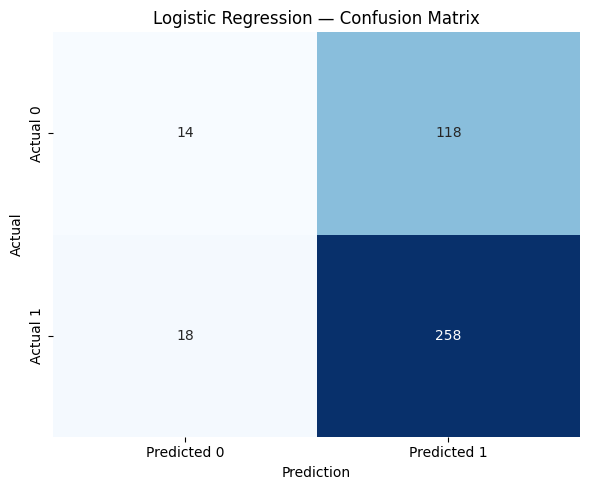

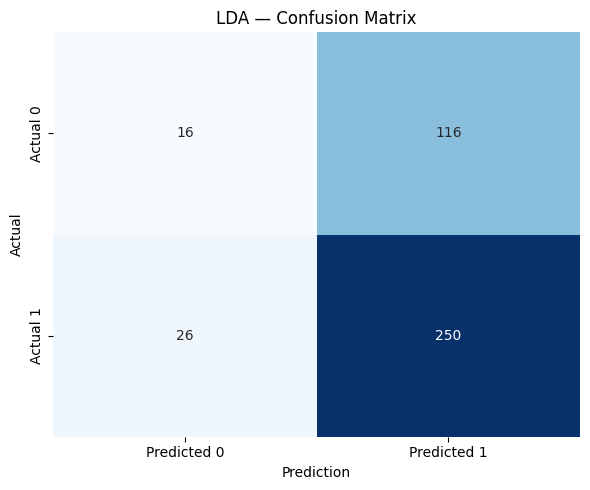

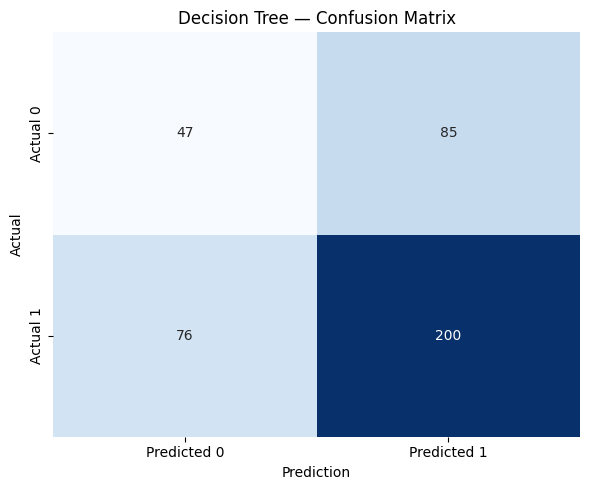

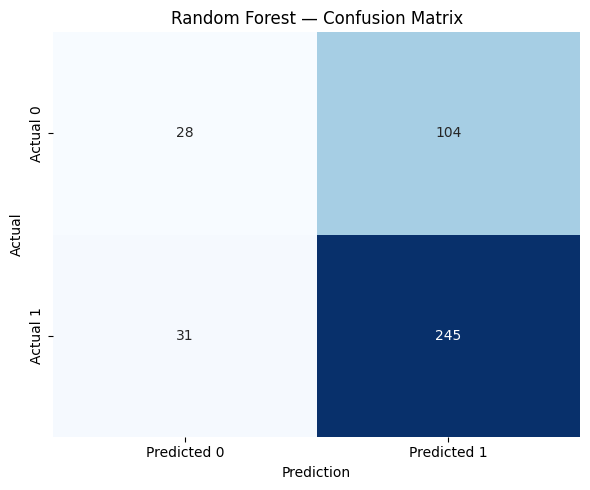

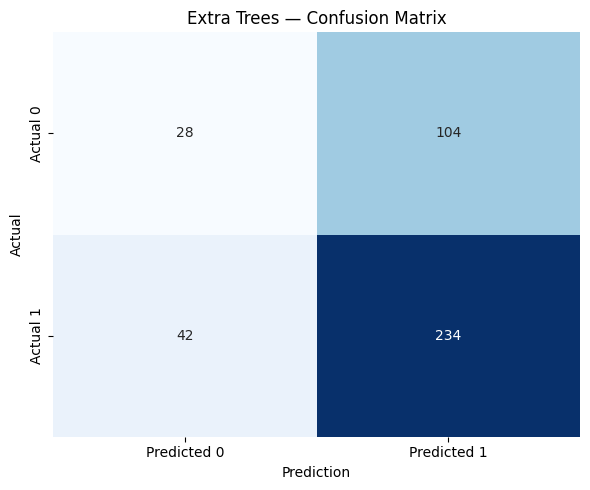

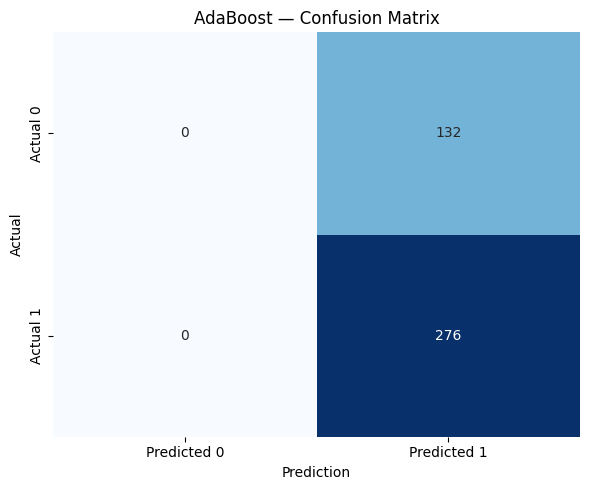

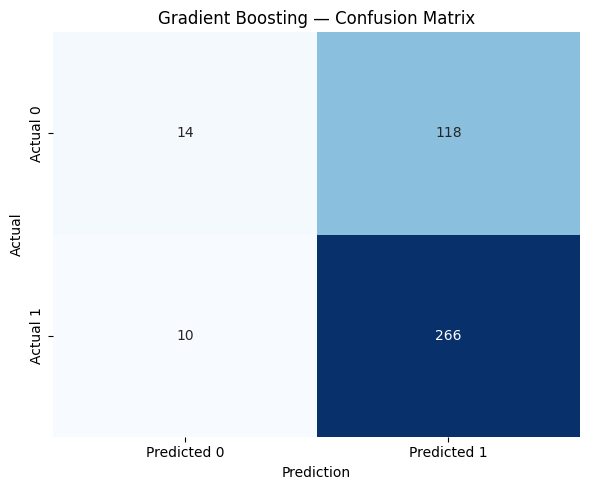

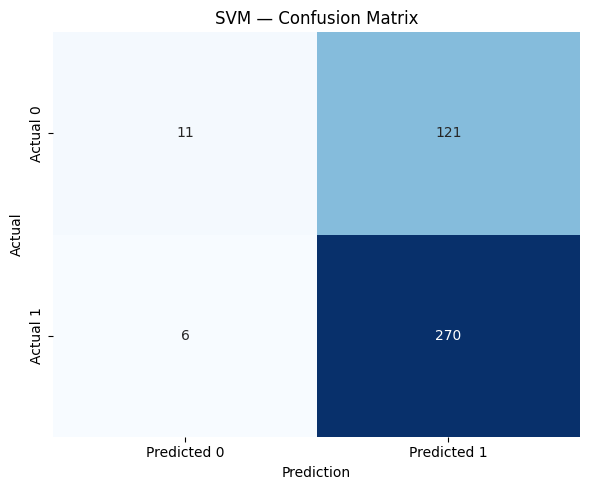

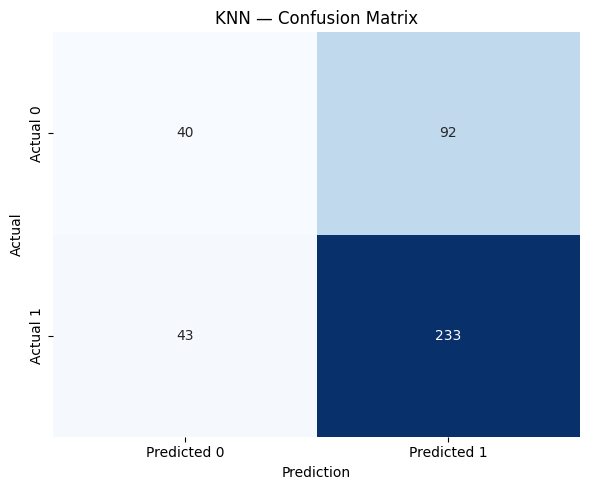

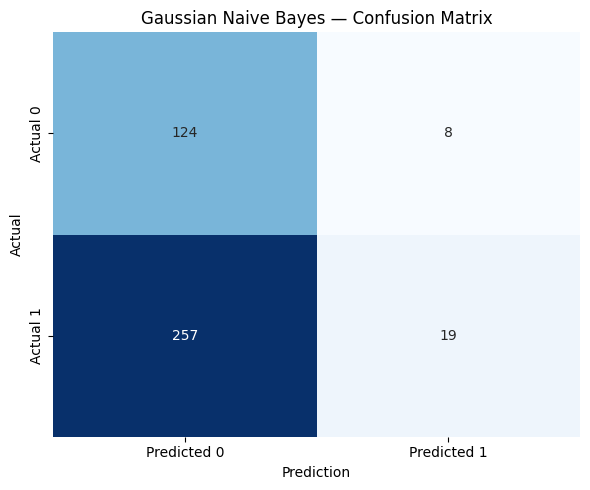

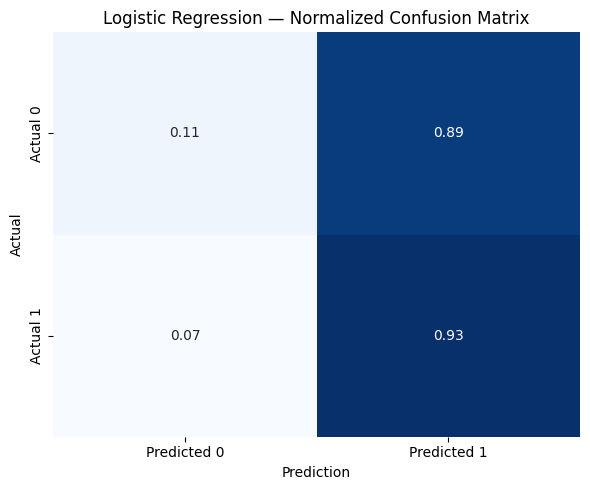

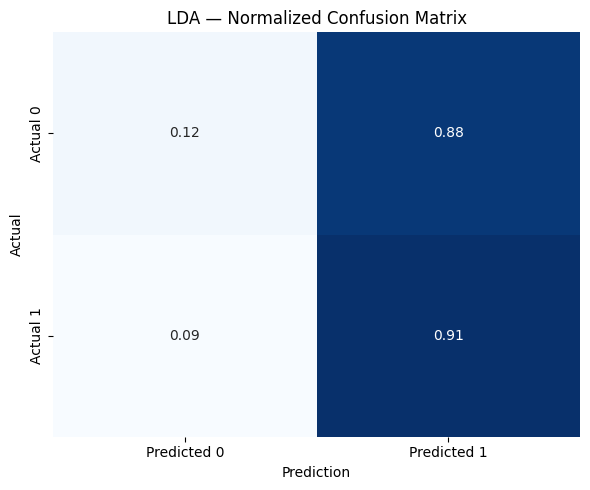

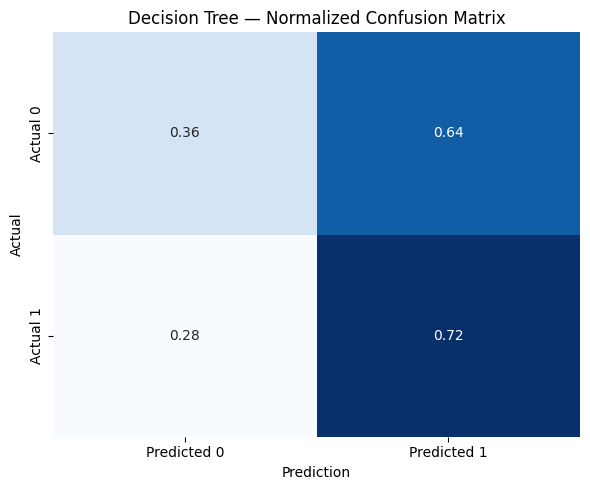

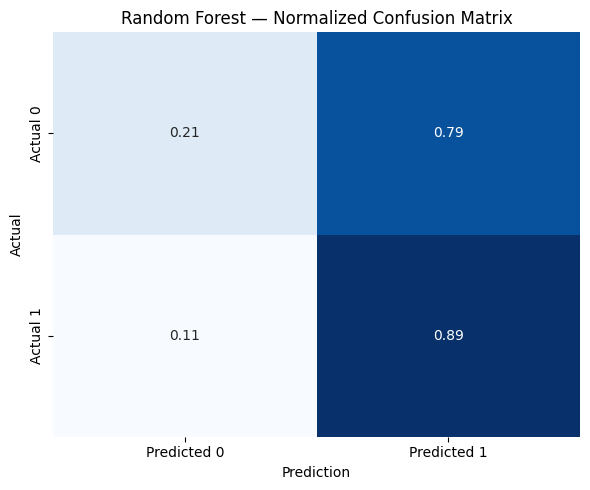

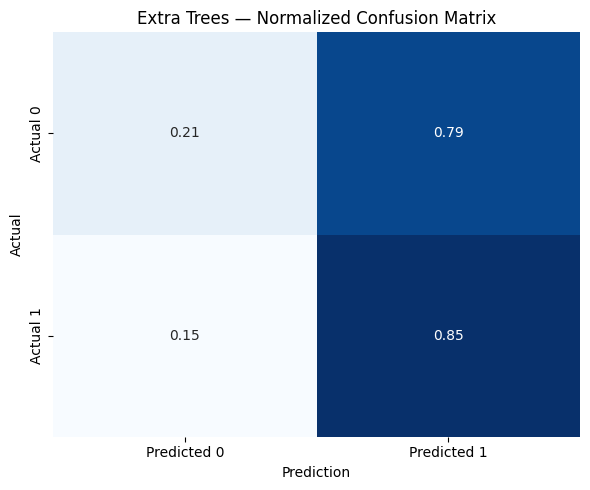

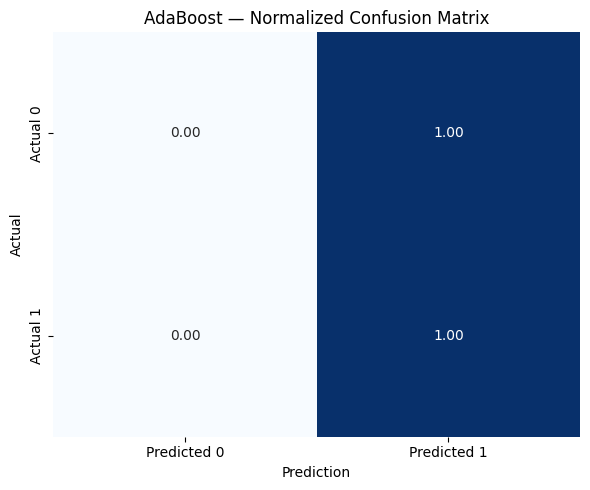

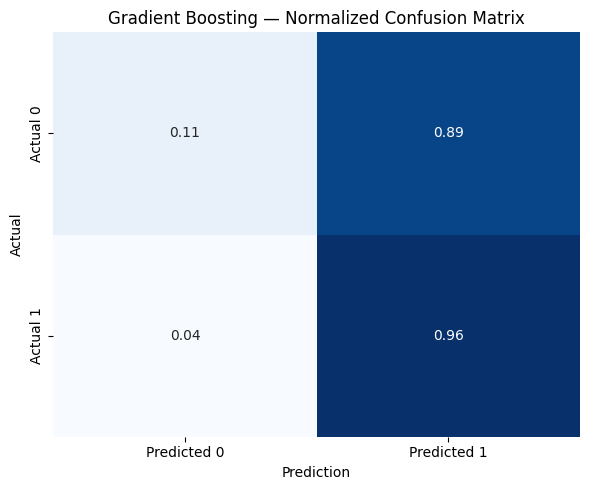

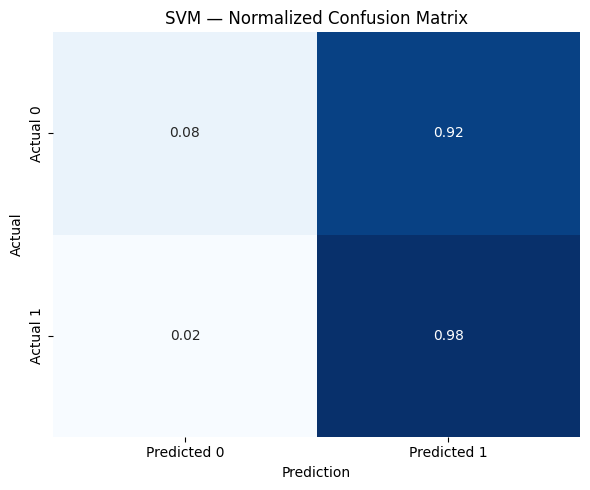

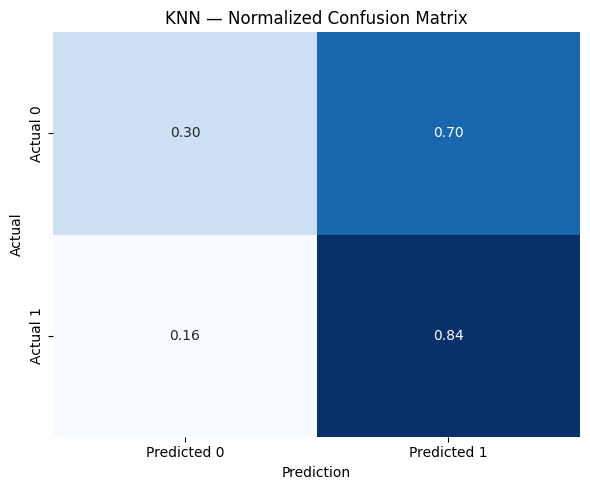

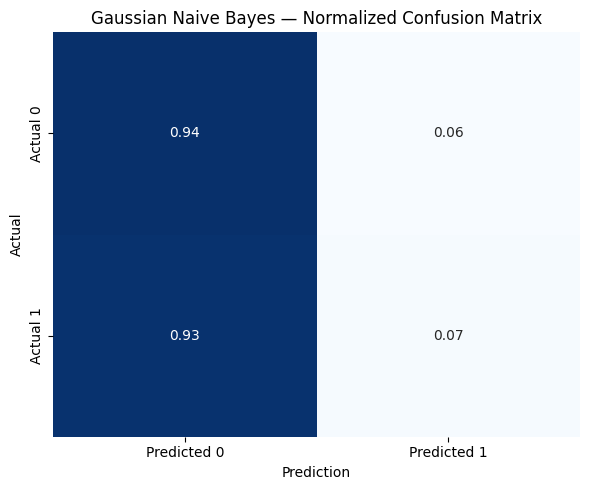


CLASSIFICATION REPORT — SVM
              precision    recall  f1-score   support

           0     0.6471    0.0833    0.1477       132
           1     0.6905    0.9783    0.8096       276

    accuracy                         0.6887       408
   macro avg     0.6688    0.5308    0.4786       408
weighted avg     0.6765    0.6887    0.5954       408



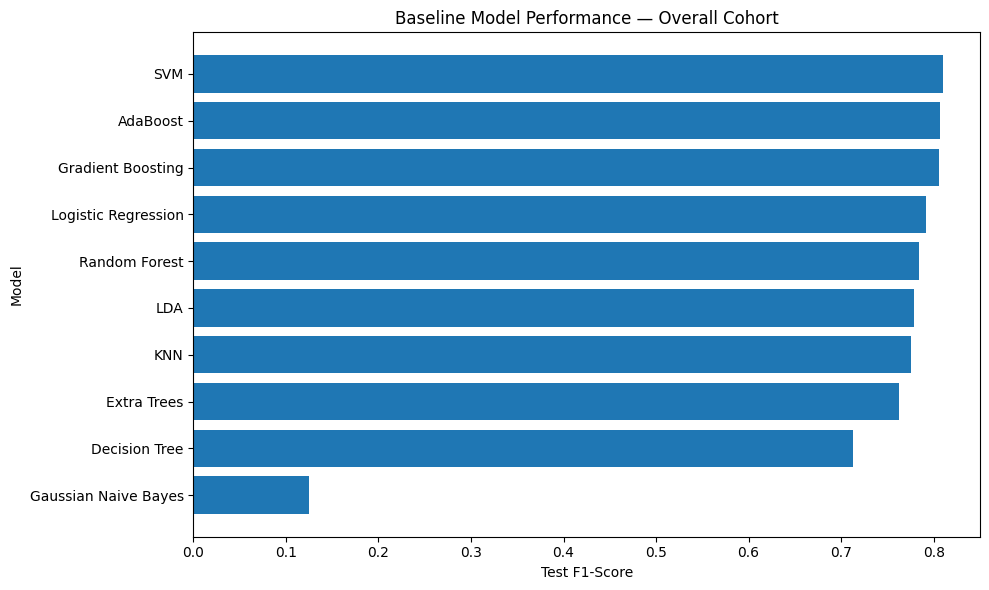


Saved:
  baseline_overall_model_comparison.csv
  baseline_overall_cv_results.csv
  baseline_overall_test_results.csv

STEP 3 COMPLETED

Completed:

✓ Leak-safe numerical preprocessing
    - Median imputation
    - StandardScaler

✓ Leak-safe categorical preprocessing
    - Most-frequent imputation
    - OneHotEncoder

✓ 80/20 stratified train-test split

✓ Stratified 10-fold cross-validation

✓ Base classifiers:
    - Logistic Regression
    - LDA
    - Decision Tree
    - Random Forest
    - Extra Trees
    - AdaBoost
    - Gradient Boosting
    - SVM
    - KNN
    - Gaussian Naive Bayes

✓ Seven evaluation metrics:
    - Accuracy
    - Precision
    - Recall
    - F1
    - ROC-AUC
    - MCC
    - Cohen's Kappa

✓ Held-out test evaluation

✓ Confusion matrices

✓ Baseline result tables

NEXT:
    STEP 4 — Repeat the standardized baseline pipeline
              across Public, Private, and Daffodil cohorts,
              followed by systematic cohort comparison.



In [4]:
# ============================================================
# MASTER AI CAREER-ANXIETY COMPARATIVE RESEARCH
# STEP 3
#
# LEAK-SAFE PREPROCESSING
# 80/20 STRATIFIED TRAIN-TEST SPLIT
# STRATIFIED 10-FOLD CROSS-VALIDATION
# BASE CLASSIFIER BENCHMARK
# 7-METRIC EVALUATION
# CONFUSION MATRICES
#
# PRIMARY COHORT:
#     Overall
#
# Later:
#     Public
#     Private
#     Daffodil
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# 1. RESEARCH CONFIGURATION
# ============================================================

RANDOM_STATE = 42

TEST_SIZE = 0.20

N_SPLITS = 10

CV = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("=" * 80)
print("STEP 3 — LEAK-SAFE ML BASELINE")
print("=" * 80)

print(f"Random State      : {RANDOM_STATE}")
print(f"Test Size         : {TEST_SIZE}")
print(f"Cross-Validation  : Stratified {N_SPLITS}-Fold")
print(f"Shuffle           : True")


# ============================================================
# 2. SELECT PRIMARY DATASET — OVERALL
# ============================================================

if "COHORT_DATASETS" not in globals():
    raise RuntimeError(
        "COHORT_DATASETS is not available. "
        "Run Step 2 first."
    )

if "FINAL_FEATURES_17" not in globals():
    raise RuntimeError(
        "FINAL_FEATURES_17 is not available. "
        "Run Step 2 first."
    )

if "TARGET_COLUMN" not in globals():
    raise RuntimeError(
        "TARGET_COLUMN is not available. "
        "Run Step 2 first."
    )


df_overall = COHORT_DATASETS["Overall"].copy()

X_overall = df_overall[
    FINAL_FEATURES_17
].copy()

y_overall = df_overall[
    TARGET_COLUMN
].copy()


print("\nOverall dataset:")
print(f"Rows     : {len(X_overall):,}")
print(f"Features : {X_overall.shape[1]}")
print(f"Target   : {TARGET_COLUMN}")


# ============================================================
# 3. DEFINE FEATURE TYPES
# ============================================================

CATEGORICAL_FEATURES = [
    "department",
    "career_path"
]

NUMERICAL_FEATURES = [
    "age",
    "gender",
    "academic_year",
    "ai_knowledge",
    "ai_replace_jobs",
    "ai_takeover_time",
    "ai_future_perspective",
    "Total_AI_Tools",
    "Uses_Text_Gen",
    "Uses_Coding_AI",
    "Uses_Creative_AI",
    "Threat_Perception",
    "Perceived_Urgency",
    "Risk_Knowledge_Gap",
    "Age_Year_Ratio"
]


# ============================================================
# 4. FEATURE-SCHEMA VALIDATION
# ============================================================

schema_features = (
    CATEGORICAL_FEATURES +
    NUMERICAL_FEATURES
)

if set(schema_features) != set(FINAL_FEATURES_17):

    missing_from_schema = (
        set(FINAL_FEATURES_17) -
        set(schema_features)
    )

    extra_in_schema = (
        set(schema_features) -
        set(FINAL_FEATURES_17)
    )

    raise ValueError(
        "\nFeature schema mismatch.\n"
        f"Missing from schema: {missing_from_schema}\n"
        f"Extra in schema: {extra_in_schema}"
    )

print("\n✓ Feature schema validated.")
print(f"Categorical features : {len(CATEGORICAL_FEATURES)}")
print(f"Numerical features   : {len(NUMERICAL_FEATURES)}")
print(f"Total features       : {len(schema_features)}")


# ============================================================
# 5. LEAK-SAFE PREPROCESSING PIPELINE
# ============================================================
#
# NUMERICAL:
#     Median Imputation
#          ↓
#     Standard Scaling
#
# CATEGORICAL:
#     Most-Frequent Imputation
#          ↓
#     One-Hot Encoding
#
# IMPORTANT:
# The preprocessing object is fitted ONLY on training folds.
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


PREPROCESSOR = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            NUMERICAL_FEATURES
        ),
        (
            "cat",
            categorical_pipeline,
            CATEGORICAL_FEATURES
        )
    ],
    remainder="drop"
)


print("\n✓ Leak-safe preprocessing pipeline created.")


# ============================================================
# 6. STRATIFIED 80/20 TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_overall,
    y_overall,
    test_size=TEST_SIZE,
    stratify=y_overall,
    random_state=RANDOM_STATE
)


print("\n" + "=" * 80)
print("80/20 STRATIFIED TRAIN-TEST SPLIT")
print("=" * 80)

print(f"Training samples : {len(X_train):,}")
print(f"Testing samples  : {len(X_test):,}")


# ============================================================
# 7. VERIFY STRATIFICATION
# ============================================================

def class_distribution(y):

    counts = (
        pd.Series(y)
        .value_counts()
        .sort_index()
    )

    percentages = (
        counts / len(y) * 100
    )

    return pd.DataFrame({
        "Count": counts,
        "Percentage": percentages
    })


print("\nFull dataset class distribution:")
display(
    class_distribution(y_overall).round(2)
)

print("\nTraining class distribution:")
display(
    class_distribution(y_train).round(2)
)

print("\nTesting class distribution:")
display(
    class_distribution(y_test).round(2)
)


# ============================================================
# 8. DEFINE CLASSIFIERS
# ============================================================
#
# These are the requested BASE classifiers.
#
# No hyperparameter optimization yet.
# Default/controlled baseline configurations are used.
# ============================================================

BASE_MODELS = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        ),

    "LDA":
        LinearDiscriminantAnalysis(),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=RANDOM_STATE
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

    "AdaBoost":
        AdaBoostClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=RANDOM_STATE
        ),

    "SVM":
        SVC(
            probability=True,
            random_state=RANDOM_STATE
        ),

    "KNN":
        KNeighborsClassifier(),

    "Gaussian Naive Bayes":
        GaussianNB()
}


print("\n" + "=" * 80)
print("BASE CLASSIFIERS")
print("=" * 80)

for i, name in enumerate(BASE_MODELS.keys(), 1):
    print(f"{i:02d}. {name}")


# ============================================================
# 9. METRIC DEFINITIONS
# ============================================================

SCORING = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "mcc": make_scorer(
        matthews_corrcoef
    ),
    "kappa": make_scorer(
        cohen_kappa_score
    )
}


# ============================================================
# 10. CREATE MODEL PIPELINE FUNCTION
# ============================================================

def make_model_pipeline(model):

    return Pipeline(
        steps=[
            (
                "preprocessor",
                clone(PREPROCESSOR)
            ),
            (
                "classifier",
                clone(model)
            )
        ]
    )


# ============================================================
# 11. CROSS-VALIDATION BASELINE
# ============================================================
#
# CV occurs ONLY on the training set.
#
# The test set remains untouched.
# ============================================================

cv_results = []

fitted_models = {}

for model_name, model in BASE_MODELS.items():

    print(
        f"\nRunning CV: {model_name}"
    )

    pipeline = make_model_pipeline(model)

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=CV,
        scoring=SCORING,
        n_jobs=-1,
        return_train_score=False
    )

    result = {
        "Model": model_name,

        "CV Accuracy Mean":
            scores["test_accuracy"].mean(),

        "CV Accuracy SD":
            scores["test_accuracy"].std(),

        "CV Precision Mean":
            scores["test_precision"].mean(),

        "CV Precision SD":
            scores["test_precision"].std(),

        "CV Recall Mean":
            scores["test_recall"].mean(),

        "CV Recall SD":
            scores["test_recall"].std(),

        "CV F1 Mean":
            scores["test_f1"].mean(),

        "CV F1 SD":
            scores["test_f1"].std(),

        "CV ROC-AUC Mean":
            scores["test_roc_auc"].mean(),

        "CV ROC-AUC SD":
            scores["test_roc_auc"].std(),

        "CV MCC Mean":
            scores["test_mcc"].mean(),

        "CV MCC SD":
            scores["test_mcc"].std(),

        "CV Kappa Mean":
            scores["test_kappa"].mean(),

        "CV Kappa SD":
            scores["test_kappa"].std()
    }

    cv_results.append(result)


# ============================================================
# 12. CV RESULTS TABLE
# ============================================================

cv_results_df = pd.DataFrame(
    cv_results
)

cv_results_df = (
    cv_results_df
    .sort_values(
        "CV F1 Mean",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 80)
print("BASE MODEL — 10-FOLD CV RESULTS")
print("=" * 80)

display(
    cv_results_df.round(4)
)


# ============================================================
# 13. FIT EACH MODEL ON COMPLETE TRAINING DATA
# ============================================================
#
# After CV evaluation, each model is refitted on the complete
# 80% training partition.
#
# The test set remains untouched until this point.
# ============================================================

test_results = []

test_predictions = {}

test_probabilities = {}

for model_name, model in BASE_MODELS.items():

    print(
        f"\nTraining final baseline model: {model_name}"
    )

    pipeline = make_model_pipeline(model)

    pipeline.fit(
        X_train,
        y_train
    )

    fitted_models[model_name] = pipeline

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Probability / decision score
    if hasattr(
        pipeline,
        "predict_proba"
    ):

        y_score = (
            pipeline
            .predict_proba(X_test)[:, 1]
        )

    elif hasattr(
        pipeline,
        "decision_function"
    ):

        y_score = (
            pipeline
            .decision_function(X_test)
        )

    else:

        y_score = None


    # Store predictions
    test_predictions[
        model_name
    ] = y_pred

    if y_score is not None:
        test_probabilities[
            model_name
        ] = y_score


    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    if y_score is not None:

        roc_auc = roc_auc_score(
            y_test,
            y_score
        )

    else:

        roc_auc = np.nan


    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_test,
        y_pred
    )


    test_results.append({

        "Model": model_name,

        "Test Accuracy":
            accuracy,

        "Test Precision":
            precision,

        "Test Recall":
            recall,

        "Test F1":
            f1,

        "Test ROC-AUC":
            roc_auc,

        "Test MCC":
            mcc,

        "Test Cohen Kappa":
            kappa
    })


# ============================================================
# 14. TEST RESULTS TABLE
# ============================================================

test_results_df = pd.DataFrame(
    test_results
)

test_results_df = (
    test_results_df
    .sort_values(
        "Test F1",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 80)
print("BASE MODEL — HELD-OUT TEST RESULTS")
print("=" * 80)

display(
    test_results_df.round(4)
)


# ============================================================
# 15. COMBINE CV + TEST RESULTS
# ============================================================

baseline_comparison = cv_results_df.merge(
    test_results_df,
    on="Model",
    how="left"
)

print("\n" + "=" * 80)
print("MASTER BASELINE COMPARISON")
print("=" * 80)

display(
    baseline_comparison.round(4)
)


# ============================================================
# 16. IDENTIFY BASELINE BEST MODELS
# ============================================================
#
# IMPORTANT:
# These are descriptive rankings.
# They are NOT yet the final research model selection.
#
# Hyperparameter tuning and ensembles come later.
# ============================================================

best_cv_model = (
    cv_results_df
    .iloc[0]["Model"]
)

best_test_model = (
    test_results_df
    .iloc[0]["Model"]
)

print("\nBest baseline model by CV F1:")
print("   ", best_cv_model)

print("\nHighest test F1 baseline model:")
print("   ", best_test_model)


# ============================================================
# 17. CONFUSION MATRICES
# ============================================================

def plot_confusion_matrix(
    y_true,
    y_pred,
    model_name,
    normalize=False
):

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    if normalize:

        cm_display = (
            cm.astype(float)
            /
            cm.sum(
                axis=1,
                keepdims=True
            )
        )

        fmt = ".2f"

        title = (
            f"{model_name} — "
            "Normalized Confusion Matrix"
        )

    else:

        cm_display = cm

        fmt = "d"

        title = (
            f"{model_name} — "
            "Confusion Matrix"
        )

    plt.figure(
        figsize=(6, 5)
    )

    sns.heatmap(
        cm_display,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        cbar=False,
        xticklabels=[
            "Predicted 0",
            "Predicted 1"
        ],
        yticklabels=[
            "Actual 0",
            "Actual 1"
        ]
    )

    plt.title(title)
    plt.xlabel("Prediction")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


# Plot confusion matrices for all baseline models
for model_name in test_predictions:

    plot_confusion_matrix(
        y_test,
        test_predictions[model_name],
        model_name,
        normalize=False
    )


# ============================================================
# 18. NORMALIZED CONFUSION MATRICES
# ============================================================

for model_name in test_predictions:

    plot_confusion_matrix(
        y_test,
        test_predictions[model_name],
        model_name,
        normalize=True
    )


# ============================================================
# 19. CLASSIFICATION REPORT FOR BEST CV MODEL
# ============================================================

best_model_name = best_cv_model

best_predictions = (
    test_predictions[
        best_model_name
    ]
)

print("\n" + "=" * 80)
print(
    f"CLASSIFICATION REPORT — {best_model_name}"
)
print("=" * 80)

print(
    classification_report(
        y_test,
        best_predictions,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 20. BASELINE F1 VISUALIZATION
# ============================================================

plot_df = (
    test_results_df
    .sort_values(
        "Test F1",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    plot_df["Model"],
    plot_df["Test F1"]
)

plt.xlabel("Test F1-Score")
plt.ylabel("Model")
plt.title(
    "Baseline Model Performance — Overall Cohort"
)

plt.tight_layout()
plt.show()


# ============================================================
# 21. SAVE BASELINE RESULTS
# ============================================================
#
# These files are intermediate research outputs.
# ============================================================

baseline_comparison.to_csv(
    "baseline_overall_model_comparison.csv",
    index=False
)

cv_results_df.to_csv(
    "baseline_overall_cv_results.csv",
    index=False
)

test_results_df.to_csv(
    "baseline_overall_test_results.csv",
    index=False
)

print("\nSaved:")
print("  baseline_overall_model_comparison.csv")
print("  baseline_overall_cv_results.csv")
print("  baseline_overall_test_results.csv")


# ============================================================
# 22. FINAL STEP-3 SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("STEP 3 COMPLETED")
print("=" * 80)

print("""
Completed:

✓ Leak-safe numerical preprocessing
    - Median imputation
    - StandardScaler

✓ Leak-safe categorical preprocessing
    - Most-frequent imputation
    - OneHotEncoder

✓ 80/20 stratified train-test split

✓ Stratified 10-fold cross-validation

✓ Base classifiers:
    - Logistic Regression
    - LDA
    - Decision Tree
    - Random Forest
    - Extra Trees
    - AdaBoost
    - Gradient Boosting
    - SVM
    - KNN
    - Gaussian Naive Bayes

✓ Seven evaluation metrics:
    - Accuracy
    - Precision
    - Recall
    - F1
    - ROC-AUC
    - MCC
    - Cohen's Kappa

✓ Held-out test evaluation

✓ Confusion matrices

✓ Baseline result tables

NEXT:
    STEP 4 — Repeat the standardized baseline pipeline
              across Public, Private, and Daffodil cohorts,
              followed by systematic cohort comparison.
""")



RUNNING COHORT: Overall
Rows: 2,036
Features: 17
Train: 1,628 | Test: 408

[Overall] Running: Logistic Regression

[Overall] Running: LDA

[Overall] Running: Decision Tree

[Overall] Running: Random Forest

[Overall] Running: Extra Trees

[Overall] Running: AdaBoost

[Overall] Running: Gradient Boosting

[Overall] Running: SVM

[Overall] Running: KNN

[Overall] Running: Gaussian Naive Bayes


RUNNING COHORT: Public
Rows: 868
Features: 17
Train: 694 | Test: 174

[Public] Running: Logistic Regression

[Public] Running: LDA

[Public] Running: Decision Tree

[Public] Running: Random Forest

[Public] Running: Extra Trees

[Public] Running: AdaBoost

[Public] Running: Gradient Boosting

[Public] Running: SVM

[Public] Running: KNN

[Public] Running: Gaussian Naive Bayes


RUNNING COHORT: Private
Rows: 1,168
Features: 17
Train: 934 | Test: 234

[Private] Running: Logistic Regression

[Private] Running: LDA

[Private] Running: Decision Tree

[Private] Running: Random Forest

[Private] Runnin

,Cohort,Model,CV Accuracy Mean,CV Accuracy SD,CV Precision Mean,CV Precision SD,CV Recall Mean,CV Recall SD,CV F1 Mean,CV F1 SD,CV ROC-AUC Mean,CV ROC-AUC SD,CV MCC Mean,CV MCC SD,CV Kappa Mean,CV Kappa SD,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test MCC,Test Cohen Kappa
0,Overall,SVM,0.6831,0.0132,0.6861,0.0093,0.9791,0.0100,0.8068,0.0073,0.5640,0.0440,0.1115,0.0736,0.0587,0.0465,0.6887,0.6905,0.9783,0.8096,0.6055,0.1442,0.0797
1,Overall,AdaBoost,0.6708,0.0074,0.6743,0.0033,0.9918,0.0095,0.8028,0.0052,0.5918,0.0287,-0.0263,0.0434,-0.0084,0.0145,0.6765,0.6765,1.0000,0.8070,0.5593,0.0000,0.0000
2,Overall,Gradient Boosting,0.6738,0.0194,0.6873,0.0104,0.9491,0.0200,0.7972,0.0126,0.5986,0.0318,0.0943,0.0852,0.0622,0.0554,0.6863,0.6927,0.9638,0.8061,0.5710,0.1388,0.0888
3,Overall,Logistic Regression,0.6677,0.0210,0.6900,0.0109,0.9227,0.0251,0.7895,0.0147,0.6004,0.0301,0.0966,0.0689,0.0725,0.0525,0.6667,0.6862,0.9348,0.7914,0.5585,0.0711,0.0509
4,Overall,Random Forest,0.6548,0.0180,0.6906,0.0138,0.8873,0.0231,0.7764,0.0115,0.5949,0.0474,0.0775,0.0667,0.0676,0.0583,0.6691,0.7020,0.8877,0.7840,0.5976,0.1328,0.1166
5,Overall,LDA,0.6462,0.0270,0.6859,0.0126,0.8782,0.0345,0.7701,0.0202,0.5936,0.0284,0.0591,0.0707,0.0489,0.0604,0.6520,0.6831,0.9058,0.7788,0.5348,0.0416,0.0329
6,Overall,Extra Trees,0.6536,0.0288,0.6988,0.0183,0.8573,0.0312,0.7697,0.0198,0.5939,0.0493,0.1070,0.0860,0.0982,0.0777,0.6422,0.6923,0.8478,0.7622,0.5833,0.0744,0.0683
7,Overall,KNN,0.6303,0.0360,0.6932,0.0239,0.8127,0.0364,0.7480,0.0258,0.5349,0.0467,0.0725,0.0927,0.0691,0.0891,0.6691,0.7169,0.8442,0.7754,0.5926,0.1711,0.1630
8,Overall,Decision Tree,0.6032,0.0334,0.7110,0.0337,0.7000,0.0364,0.7044,0.0228,0.5529,0.0510,0.0985,0.0991,0.0981,0.0987,0.6054,0.7018,0.7246,0.7130,0.5388,0.0823,0.0822
9,Overall,Gaussian Naive Bayes,0.3587,0.0226,0.7353,0.1528,0.0745,0.0325,0.1341,0.0549,0.5690,0.0469,0.0414,0.0774,0.0171,0.0267,0.3505,0.7037,0.0688,0.1254,0.5516,0.0155,0.0055



BEST BASELINE MODEL BY COHORT — CV F1


,Cohort,Model,CV F1 Mean,CV F1 SD,CV ROC-AUC Mean,CV MCC Mean,CV Kappa Mean
0,Daffodil,SVM,0.8372,0.0284,0.7251,0.3226,0.2754
1,Overall,SVM,0.8068,0.0073,0.5640,0.1115,0.0587
2,Private,SVM,0.8105,0.0159,0.5947,0.1657,0.1103
3,Public,AdaBoost,0.8034,0.0053,0.4706,-0.0084,-0.0028



BEST BASELINE MODEL BY COHORT — TEST F1


...

Cohort,Overall,Public,Private,Daffodil
Model,,,,
AdaBoost,0.8070,0.7958,0.7968,0.8100
Decision Tree,0.7130,0.7000,0.7192,0.7340
Extra Trees,0.7622,0.7462,0.7884,0.7745
Gaussian Naive Bayes,0.1254,0.1250,0.1364,0.0784
Gradient Boosting,0.8061,0.7902,0.8011,0.8079
KNN,0.7754,0.7137,0.7536,0.7885
LDA,0.7788,0.7737,0.7803,0.8137
Logistic Regression,0.7914,0.7829,0.7955,0.8390
Random Forest,0.7840,0.7640,0.8056,0.8058



TEST ROC-AUC — MODEL × COHORT


Cohort,Overall,Public,Private,Daffodil
Model,,,,
AdaBoost,0.5593,0.4791,0.6564,0.7345
Decision Tree,0.5388,0.5171,0.5678,0.5893
Extra Trees,0.5833,0.5276,0.6254,0.7270
Gaussian Naive Bayes,0.5516,0.5265,0.6496,0.6505
Gradient Boosting,0.5710,0.4905,0.6813,0.7371
KNN,0.5926,0.4881,0.6130,0.6485
LDA,0.5348,0.4686,0.6772,0.7312
Logistic Regression,0.5585,0.5022,0.6812,0.7607
Random Forest,0.5976,0.4915,0.6568,0.7522



TEST MCC — MODEL × COHORT


Cohort,Overall,Public,Private,Daffodil
Model,,,,
AdaBoost,0.0000,-0.0753,0.0584,0.3262
Decision Tree,0.0823,0.0348,0.1299,0.1811
Extra Trees,0.0744,0.0270,0.2181,0.1612
Gaussian Naive Bayes,0.0155,0.0304,0.0158,0.0430
Gradient Boosting,0.1388,-0.0468,0.1651,0.2956
KNN,0.1711,-0.0542,0.0820,0.1773
LDA,0.0416,0.0178,0.1814,0.3100
Logistic Regression,0.0711,-0.0145,0.1894,0.4002
Random Forest,0.1328,0.0404,0.2438,0.2641


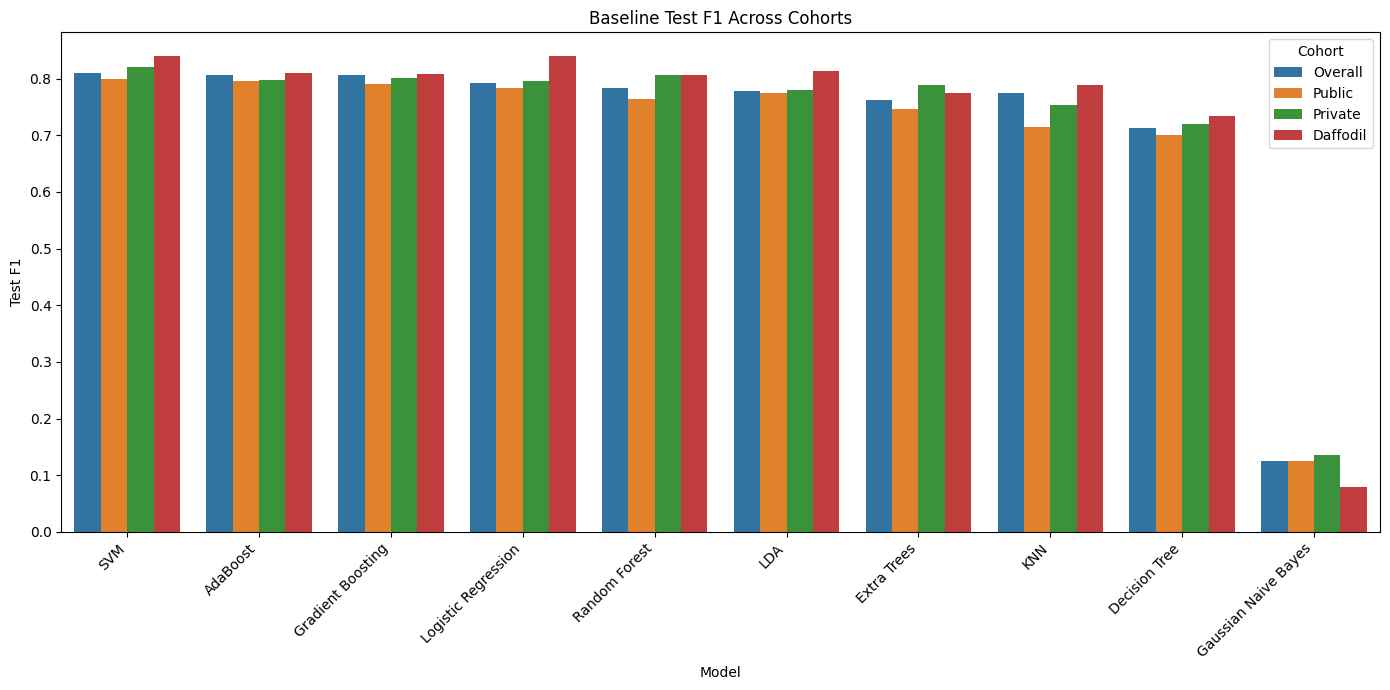

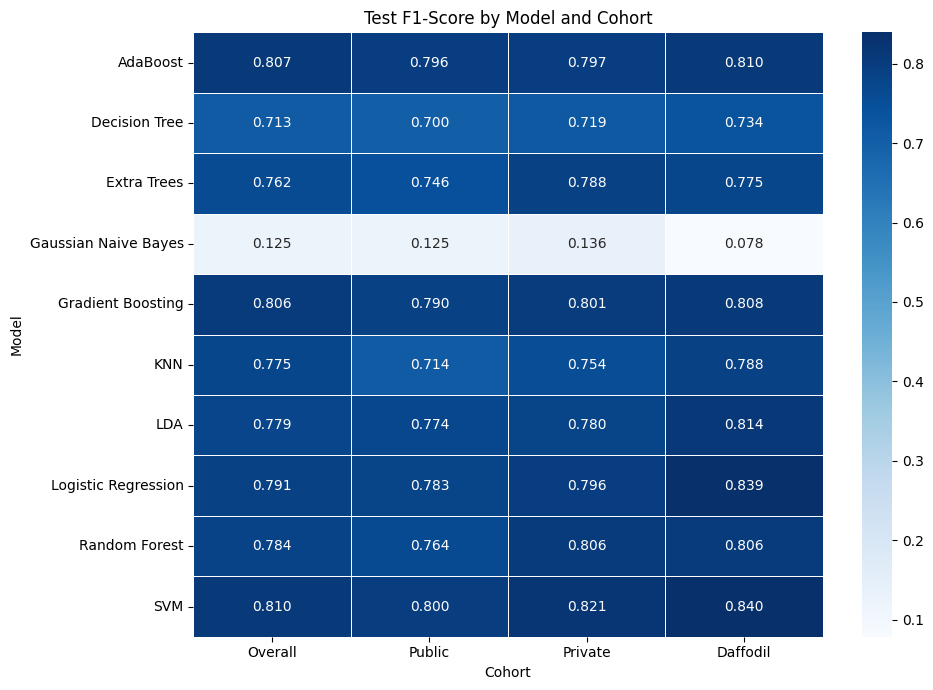

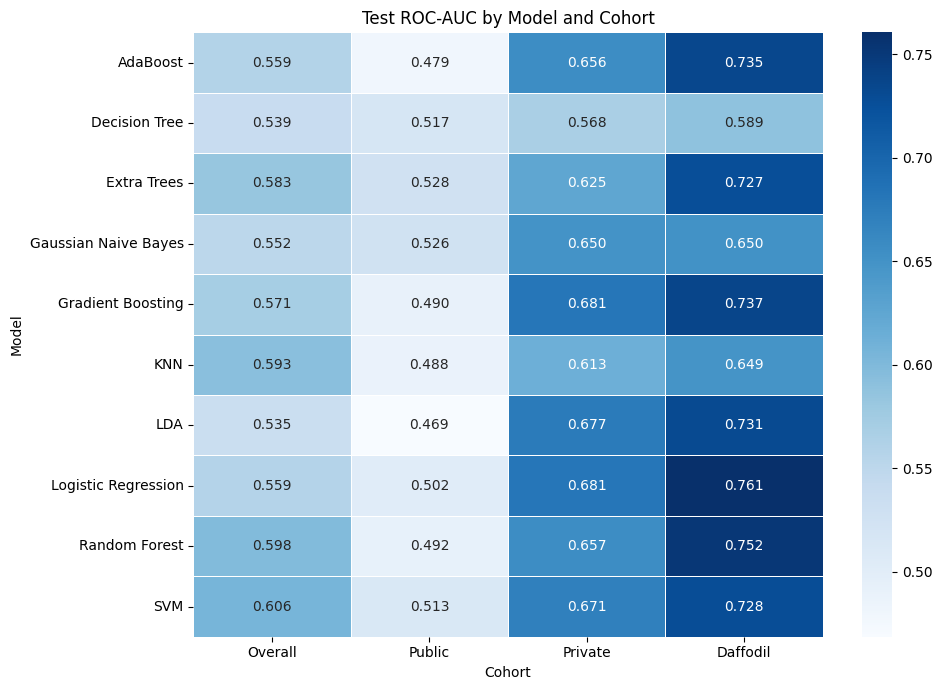

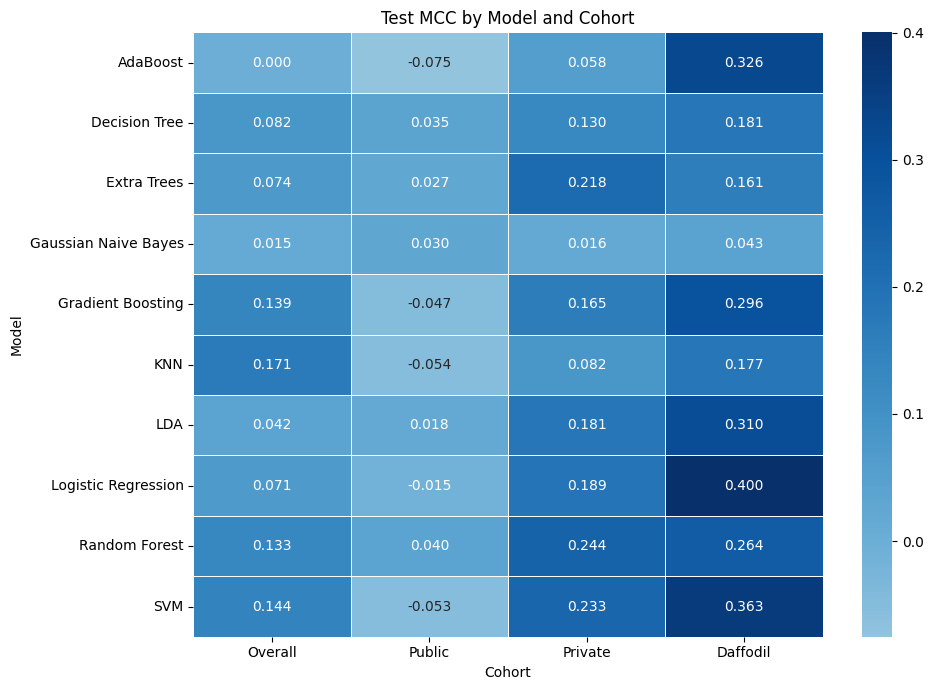


AVERAGE BASELINE PERFORMANCE BY COHORT


,Mean_Test_F1,Mean_Test_ROC_AUC,Mean_Test_MCC,Mean_Test_Kappa
Cohort,,,,
Overall,0.7153,0.5693,0.0872,0.0688
Public,0.6992,0.5004,-0.0093,0.0002
Private,0.7198,0.6480,0.1517,0.1305
Daffodil,0.7292,0.7059,0.2521,0.2430



STEP 4 COMPLETED SUCCESSFULLY

The same baseline methodology has now been applied to:

    ✓ Overall
    ✓ Public
    ✓ Private
    ✓ Daffodil

Each cohort used:

    ✓ 80/20 stratified split
    ✓ Leak-safe preprocessing
    ✓ Stratified 10-fold CV
    ✓ Same 10 base classifiers
    ✓ Same 7 evaluation metrics
    ✓ Held-out test evaluation

Generated comparative outputs:

    ✓ Model × Cohort F1 matrix
    ✓ Model × Cohort ROC-AUC matrix
    ✓ Model × Cohort MCC matrix
    ✓ Cohort performance summary
    ✓ Complete baseline results

NEXT:
    STEP 5 — SMOTE vs. No-SMOTE experiment
              using the same controlled framework.



In [5]:
# ============================================================
# MASTER AI CAREER-ANXIETY COMPARATIVE RESEARCH
# STEP 4
#
# STANDARDIZED BASELINE ACROSS ALL COHORTS
#
# ORDER:
#   1. Overall
#   2. Public
#   3. Private
#   4. Daffodil
#
# IMPORTANT:
# The exact same preprocessing, models, split strategy,
# CV strategy, and evaluation metrics are used for every
# cohort.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer


# ============================================================
# 1. GLOBAL CONFIGURATION
# ============================================================

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 10

CV = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)


# ============================================================
# 2. VERIFY REQUIRED OBJECTS
# ============================================================

required_objects = [
    "COHORT_DATASETS",
    "FINAL_FEATURES_17",
    "TARGET_COLUMN"
]

for obj_name in required_objects:

    if obj_name not in globals():

        raise RuntimeError(
            f"{obj_name} is not available. "
            "Please run Steps 1–2 first."
        )


# ============================================================
# 3. FEATURE TYPES
# ============================================================

CATEGORICAL_FEATURES = [
    "department",
    "career_path"
]

NUMERICAL_FEATURES = [
    "age",
    "gender",
    "academic_year",
    "ai_knowledge",
    "ai_replace_jobs",
    "ai_takeover_time",
    "ai_future_perspective",
    "Total_AI_Tools",
    "Uses_Text_Gen",
    "Uses_Coding_AI",
    "Uses_Creative_AI",
    "Threat_Perception",
    "Perceived_Urgency",
    "Risk_Knowledge_Gap",
    "Age_Year_Ratio"
]


# ============================================================
# 4. CREATE FRESH PREPROCESSOR
# ============================================================
#
# A NEW preprocessor is created for every cohort.
#
# This is important because imputation/scaling parameters
# must be learned independently inside each cohort's
# training data.
# ============================================================

def create_preprocessor():

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            )
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_pipeline,
                NUMERICAL_FEATURES
            ),
            (
                "cat",
                categorical_pipeline,
                CATEGORICAL_FEATURES
            )
        ],
        remainder="drop"
    )


# ============================================================
# 5. BASE MODELS
# ============================================================

BASE_MODELS = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        ),

    "LDA":
        LinearDiscriminantAnalysis(),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=RANDOM_STATE
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

    "AdaBoost":
        AdaBoostClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=RANDOM_STATE
        ),

    "SVM":
        SVC(
            probability=True,
            random_state=RANDOM_STATE
        ),

    "KNN":
        KNeighborsClassifier(),

    "Gaussian Naive Bayes":
        GaussianNB()
}


# ============================================================
# 6. SCORING FUNCTIONS
# ============================================================

SCORING = {

    "accuracy": "accuracy",

    "precision": "precision",

    "recall": "recall",

    "f1": "f1",

    "roc_auc": "roc_auc",

    "mcc": make_scorer(
        matthews_corrcoef
    ),

    "kappa": make_scorer(
        cohen_kappa_score
    )
}


# ============================================================
# 7. MODEL PIPELINE FACTORY
# ============================================================

def create_model_pipeline(model):

    return Pipeline(
        steps=[
            (
                "preprocessor",
                create_preprocessor()
            ),
            (
                "classifier",
                clone(model)
            )
        ]
    )


# ============================================================
# 8. COHORT EXPERIMENT FUNCTION
# ============================================================

def run_baseline_cohort_experiment(
    cohort_name,
    cohort_df
):

    print("\n")
    print("=" * 80)
    print(f"RUNNING COHORT: {cohort_name}")
    print("=" * 80)

    # --------------------------------------------------------
    # Data
    # --------------------------------------------------------

    X = cohort_df[
        FINAL_FEATURES_17
    ].copy()

    y = cohort_df[
        TARGET_COLUMN
    ].copy()

    print(f"Rows: {len(X):,}")
    print(f"Features: {X.shape[1]}")

    # --------------------------------------------------------
    # Verify both classes
    # --------------------------------------------------------

    unique_classes = set(
        y.unique()
    )

    if unique_classes != {0, 1}:

        raise ValueError(
            f"{cohort_name} does not contain both classes: "
            f"{unique_classes}"
        )

    # --------------------------------------------------------
    # Stratified 80/20 split
    # --------------------------------------------------------

    X_train, X_test, y_train, y_test = (
        train_test_split(
            X,
            y,
            test_size=TEST_SIZE,
            stratify=y,
            random_state=RANDOM_STATE
        )
    )

    print(
        f"Train: {len(X_train):,} | "
        f"Test: {len(X_test):,}"
    )

    # --------------------------------------------------------
    # Result containers
    # --------------------------------------------------------

    cv_results = []
    test_results = []

    fitted_models = {}
    test_predictions = {}
    test_probabilities = {}

    # --------------------------------------------------------
    # Run every base model
    # --------------------------------------------------------

    for model_name, model in BASE_MODELS.items():

        print(
            f"\n[{cohort_name}] "
            f"Running: {model_name}"
        )

        pipeline = create_model_pipeline(
            model
        )

        # ----------------------------------------------------
        # CV
        # ----------------------------------------------------

        scores = cross_validate(
            pipeline,
            X_train,
            y_train,
            cv=CV,
            scoring=SCORING,
            n_jobs=-1,
            return_train_score=False
        )

        cv_results.append({

            "Cohort": cohort_name,

            "Model": model_name,

            "CV Accuracy Mean":
                scores[
                    "test_accuracy"
                ].mean(),

            "CV Accuracy SD":
                scores[
                    "test_accuracy"
                ].std(),

            "CV Precision Mean":
                scores[
                    "test_precision"
                ].mean(),

            "CV Precision SD":
                scores[
                    "test_precision"
                ].std(),

            "CV Recall Mean":
                scores[
                    "test_recall"
                ].mean(),

            "CV Recall SD":
                scores[
                    "test_recall"
                ].std(),

            "CV F1 Mean":
                scores[
                    "test_f1"
                ].mean(),

            "CV F1 SD":
                scores[
                    "test_f1"
                ].std(),

            "CV ROC-AUC Mean":
                scores[
                    "test_roc_auc"
                ].mean(),

            "CV ROC-AUC SD":
                scores[
                    "test_roc_auc"
                ].std(),

            "CV MCC Mean":
                scores[
                    "test_mcc"
                ].mean(),

            "CV MCC SD":
                scores[
                    "test_mcc"
                ].std(),

            "CV Kappa Mean":
                scores[
                    "test_kappa"
                ].mean(),

            "CV Kappa SD":
                scores[
                    "test_kappa"
                ].std()
        })

        # ----------------------------------------------------
        # Fit on complete training data
        # ----------------------------------------------------

        pipeline.fit(
            X_train,
            y_train
        )

        fitted_models[
            model_name
        ] = pipeline

        # ----------------------------------------------------
        # Test prediction
        # ----------------------------------------------------

        y_pred = pipeline.predict(
            X_test
        )

        # ----------------------------------------------------
        # Test probability
        # ----------------------------------------------------

        if hasattr(
            pipeline,
            "predict_proba"
        ):

            y_score = (
                pipeline
                .predict_proba(X_test)[:, 1]
            )

        elif hasattr(
            pipeline,
            "decision_function"
        ):

            y_score = (
                pipeline
                .decision_function(X_test)
            )

        else:

            y_score = None

        # ----------------------------------------------------
        # Store predictions
        # ----------------------------------------------------

        test_predictions[
            model_name
        ] = y_pred

        if y_score is not None:

            test_probabilities[
                model_name
            ] = y_score

        # ----------------------------------------------------
        # Test metrics
        # ----------------------------------------------------

        accuracy = accuracy_score(
            y_test,
            y_pred
        )

        precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )

        if y_score is not None:

            roc_auc = roc_auc_score(
                y_test,
                y_score
            )

        else:

            roc_auc = np.nan

        mcc = matthews_corrcoef(
            y_test,
            y_pred
        )

        kappa = cohen_kappa_score(
            y_test,
            y_pred
        )

        test_results.append({

            "Cohort": cohort_name,

            "Model": model_name,

            "Test Accuracy":
                accuracy,

            "Test Precision":
                precision,

            "Test Recall":
                recall,

            "Test F1":
                f1,

            "Test ROC-AUC":
                roc_auc,

            "Test MCC":
                mcc,

            "Test Cohen Kappa":
                kappa
        })

    # --------------------------------------------------------
    # Convert to DataFrames
    # --------------------------------------------------------

    cv_df = pd.DataFrame(
        cv_results
    )

    test_df = pd.DataFrame(
        test_results
    )

    combined_df = cv_df.merge(
        test_df,
        on=[
            "Cohort",
            "Model"
        ],
        how="left"
    )

    # --------------------------------------------------------
    # Sort by CV F1
    # --------------------------------------------------------

    combined_df = (
        combined_df
        .sort_values(
            "CV F1 Mean",
            ascending=False
        )
        .reset_index(drop=True)
    )

    return {

        "cohort": cohort_name,

        "X_train": X_train,
        "X_test": X_test,

        "y_train": y_train,
        "y_test": y_test,

        "cv_results": cv_df,

        "test_results": test_df,

        "combined_results": combined_df,

        "fitted_models": fitted_models,

        "test_predictions": test_predictions,

        "test_probabilities": test_probabilities
    }


# ============================================================
# 9. RUN COHORTS IN REQUIRED ORDER
# ============================================================

COHORT_EXPERIMENTS = {}

for cohort_name in COHORT_ORDER:

    COHORT_EXPERIMENTS[
        cohort_name
    ] = run_baseline_cohort_experiment(
        cohort_name,
        COHORT_DATASETS[
            cohort_name
        ]
    )


# ============================================================
# 10. COMBINE ALL RESULTS
# ============================================================

ALL_CV_RESULTS = pd.concat(
    [
        result["cv_results"]
        for result in COHORT_EXPERIMENTS.values()
    ],
    ignore_index=True
)

ALL_TEST_RESULTS = pd.concat(
    [
        result["test_results"]
        for result in COHORT_EXPERIMENTS.values()
    ],
    ignore_index=True
)

ALL_BASELINE_RESULTS = pd.concat(
    [
        result["combined_results"]
        for result in COHORT_EXPERIMENTS.values()
    ],
    ignore_index=True
)


# ============================================================
# 11. DISPLAY COMPLETE COMPARISON
# ============================================================

print("\n" + "=" * 80)
print("ALL-COHORT BASELINE COMPARISON")
print("=" * 80)

display(
    ALL_BASELINE_RESULTS.round(4)
)


# ============================================================
# 12. BEST MODEL BY COHORT — CV F1
# ============================================================

best_cv_by_cohort = (
    ALL_BASELINE_RESULTS
    .sort_values(
        "CV F1 Mean",
        ascending=False
    )
    .groupby(
        "Cohort",
        as_index=False
    )
    .first()
)

print("\n" + "=" * 80)
print("BEST BASELINE MODEL BY COHORT — CV F1")
print("=" * 80)

display(
    best_cv_by_cohort[
        [
            "Cohort",
            "Model",
            "CV F1 Mean",
            "CV F1 SD",
            "CV ROC-AUC Mean",
            "CV MCC Mean",
            "CV Kappa Mean"
        ]
    ].round(4)
)


# ============================================================
# 13. BEST MODEL BY COHORT — TEST F1
# ============================================================

best_test_by_cohort = (
    ALL_BASELINE_RESULTS
    .sort_values(
        "Test F1",
        ascending=False
    )
    .groupby(
        "Cohort",
        as_index=False
    )
    .first()
)

print("\n" + "=" * 80)
print("BEST BASELINE MODEL BY COHORT — TEST F1")
print("=" * 80)

display(
    best_test_by_cohort[
        [
            "Cohort",
            "Model",
            "Test F1",
            "Test ROC-AUC",
            "Test MCC",
            "Test Cohen Kappa"
        ]
    ].round(4)
)


# ============================================================
# 14. MODEL × COHORT F1 MATRIX
# ============================================================

f1_matrix = (
    ALL_BASELINE_RESULTS
    .pivot(
        index="Model",
        columns="Cohort",
        values="Test F1"
    )
)

# Maintain research order
f1_matrix = f1_matrix.reindex(
    columns=COHORT_ORDER
)

print("\n" + "=" * 80)
print("TEST F1 — MODEL × COHORT")
print("=" * 80)

display(
    f1_matrix.round(4)
)


# ============================================================
# 15. MODEL × COHORT ROC-AUC MATRIX
# ============================================================

roc_matrix = (
    ALL_BASELINE_RESULTS
    .pivot(
        index="Model",
        columns="Cohort",
        values="Test ROC-AUC"
    )
)

roc_matrix = roc_matrix.reindex(
    columns=COHORT_ORDER
)

print("\n" + "=" * 80)
print("TEST ROC-AUC — MODEL × COHORT")
print("=" * 80)

display(
    roc_matrix.round(4)
)


# ============================================================
# 16. MODEL × COHORT MCC MATRIX
# ============================================================

mcc_matrix = (
    ALL_BASELINE_RESULTS
    .pivot(
        index="Model",
        columns="Cohort",
        values="Test MCC"
    )
)

mcc_matrix = mcc_matrix.reindex(
    columns=COHORT_ORDER
)

print("\n" + "=" * 80)
print("TEST MCC — MODEL × COHORT")
print("=" * 80)

display(
    mcc_matrix.round(4)
)


# ============================================================
# 17. VISUALIZE TEST F1 BY COHORT
# ============================================================

plt.figure(
    figsize=(14, 7)
)

sns.barplot(
    data=ALL_BASELINE_RESULTS,
    x="Model",
    y="Test F1",
    hue="Cohort"
)

plt.title(
    "Baseline Test F1 Across Cohorts"
)

plt.xlabel("Model")
plt.ylabel("Test F1")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()


# ============================================================
# 18. HEATMAP — TEST F1
# ============================================================

plt.figure(
    figsize=(10, 7)
)

sns.heatmap(
    f1_matrix,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    linewidths=0.5
)

plt.title(
    "Test F1-Score by Model and Cohort"
)

plt.xlabel("Cohort")
plt.ylabel("Model")

plt.tight_layout()
plt.show()


# ============================================================
# 19. HEATMAP — TEST ROC-AUC
# ============================================================

plt.figure(
    figsize=(10, 7)
)

sns.heatmap(
    roc_matrix,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    linewidths=0.5
)

plt.title(
    "Test ROC-AUC by Model and Cohort"
)

plt.xlabel("Cohort")
plt.ylabel("Model")

plt.tight_layout()
plt.show()


# ============================================================
# 20. HEATMAP — TEST MCC
# ============================================================

plt.figure(
    figsize=(10, 7)
)

sns.heatmap(
    mcc_matrix,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    linewidths=0.5,
    center=0
)

plt.title(
    "Test MCC by Model and Cohort"
)

plt.xlabel("Cohort")
plt.ylabel("Model")

plt.tight_layout()
plt.show()


# ============================================================
# 21. COHORT PERFORMANCE SUMMARY
# ============================================================

cohort_performance_summary = (
    ALL_BASELINE_RESULTS
    .groupby("Cohort")
    .agg(
        Mean_Test_F1=(
            "Test F1",
            "mean"
        ),
        Mean_Test_ROC_AUC=(
            "Test ROC-AUC",
            "mean"
        ),
        Mean_Test_MCC=(
            "Test MCC",
            "mean"
        ),
        Mean_Test_Kappa=(
            "Test Cohen Kappa",
            "mean"
        )
    )
    .reindex(
        COHORT_ORDER
    )
)

print("\n" + "=" * 80)
print("AVERAGE BASELINE PERFORMANCE BY COHORT")
print("=" * 80)

display(
    cohort_performance_summary.round(4)
)


# ============================================================
# 22. SAVE MASTER BASELINE RESULTS
# ============================================================

ALL_BASELINE_RESULTS.to_csv(
    "master_baseline_all_cohorts.csv",
    index=False
)

ALL_CV_RESULTS.to_csv(
    "master_cv_all_cohorts.csv",
    index=False
)

ALL_TEST_RESULTS.to_csv(
    "master_test_all_cohorts.csv",
    index=False
)

f1_matrix.to_csv(
    "master_test_f1_model_cohort_matrix.csv"
)

roc_matrix.to_csv(
    "master_test_roc_auc_model_cohort_matrix.csv"
)

mcc_matrix.to_csv(
    "master_test_mcc_model_cohort_matrix.csv"
)

cohort_performance_summary.to_csv(
    "master_cohort_performance_summary.csv"
)


# ============================================================
# 23. FINAL VALIDATION
# ============================================================

expected_cohorts = set(
    COHORT_ORDER
)

observed_cohorts = set(
    ALL_BASELINE_RESULTS["Cohort"].unique()
)

if observed_cohorts != expected_cohorts:

    raise ValueError(
        "Not all expected cohorts were evaluated.\n"
        f"Expected: {expected_cohorts}\n"
        f"Observed: {observed_cohorts}"
    )

expected_models = set(
    BASE_MODELS.keys()
)

observed_models = set(
    ALL_BASELINE_RESULTS["Model"].unique()
)

if observed_models != expected_models:

    raise ValueError(
        "Not all expected models were evaluated."
    )


print("\n" + "=" * 80)
print("STEP 4 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("""
The same baseline methodology has now been applied to:

    ✓ Overall
    ✓ Public
    ✓ Private
    ✓ Daffodil

Each cohort used:

    ✓ 80/20 stratified split
    ✓ Leak-safe preprocessing
    ✓ Stratified 10-fold CV
    ✓ Same 10 base classifiers
    ✓ Same 7 evaluation metrics
    ✓ Held-out test evaluation

Generated comparative outputs:

    ✓ Model × Cohort F1 matrix
    ✓ Model × Cohort ROC-AUC matrix
    ✓ Model × Cohort MCC matrix
    ✓ Cohort performance summary
    ✓ Complete baseline results

NEXT:
    STEP 5 — SMOTE vs. No-SMOTE experiment
              using the same controlled framework.
""")

STEP 5 — CLASS-IMBALANCE EXPERIMENT

✓ Steps 1–4 objects detected.

Class-weighted models:
✓ Logistic Regression
✓ Decision Tree
✓ Random Forest
✓ Extra Trees
✓ SVM

Models without native class_weight support:
— LDA
— AdaBoost
— Gradient Boosting
— KNN
— Gaussian Naive Bayes

[Overall] Baseline

[Overall] Class Weight

[Overall] SMOTE

[Public] Baseline

[Public] Class Weight

[Public] SMOTE

[Private] Baseline

[Private] Class Weight

[Private] SMOTE

[Daffodil] Baseline

[Daffodil] Class Weight

[Daffodil] SMOTE

STEP 5 — COMPLETE IMBALANCE EXPERIMENT


,Cohort,Condition,Model,CV Accuracy Mean,CV Accuracy SD,CV Precision Mean,CV Precision SD,CV Recall Mean,CV Recall SD,CV F1 Mean,CV F1 SD,CV ROC-AUC Mean,CV ROC-AUC SD,CV MCC Mean,CV MCC SD,CV Kappa Mean,CV Kappa SD,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test MCC,Test Cohen Kappa
82,Daffodil,Baseline,SVM,0.7445,0.0452,0.7532,0.0305,0.9433,0.0409,0.8372,0.0284,0.7251,0.0902,0.3226,0.1546,0.2754,0.1383,0.7554,0.7739,0.9175,0.8396,0.7283,0.3626,0.3398
75,Daffodil,Baseline,Logistic Regression,0.7248,0.0600,0.7611,0.0335,0.8813,0.0590,0.8164,0.0414,0.7266,0.0848,0.2929,0.1652,0.2761,0.1549,0.7626,0.7963,0.8866,0.8390,0.7607,0.4002,0.3919
76,Daffodil,Baseline,LDA,0.7068,0.0623,0.7541,0.0340,0.8580,0.0671,0.8021,0.0455,0.6955,0.0889,0.2542,0.1546,0.2416,0.1473,0.7266,0.7757,0.8557,0.8137,0.7312,0.3100,0.3048
80,Daffodil,Baseline,AdaBoost,0.7102,0.0460,0.7647,0.0395,0.8476,0.0419,0.8030,0.0287,0.7076,0.0693,0.2626,0.1459,0.2562,0.1456,0.7266,0.7864,0.8351,0.8100,0.7345,0.3262,0.3244
81,Daffodil,Baseline,Gradient Boosting,0.7121,0.0474,0.7568,0.0279,0.8659,0.0655,0.8064,0.0354,0.7164,0.0800,0.2648,0.1234,0.2495,0.1172,0.7194,0.7736,0.8454,0.8079,0.7371,0.2956,0.2917
78,Daffodil,Baseline,Random Forest,0.7267,0.0360,0.7570,0.0158,0.8943,0.0490,0.8195,0.0268,0.7124,0.0821,0.2915,0.0953,0.2694,0.0845,0.7122,0.7615,0.8557,0.8058,0.7522,0.2641,0.2575
83,Daffodil,Baseline,KNN,0.7482,0.0583,0.7897,0.0434,0.8738,0.0630,0.8282,0.0399,0.6949,0.1038,0.3722,0.1620,0.3574,0.1555,0.6835,0.7387,0.8454,0.7885,0.6485,0.1773,0.1710
79,Daffodil,Baseline,Extra Trees,0.7177,0.0375,0.7569,0.0218,0.8763,0.0420,0.8118,0.0259,0.7001,0.0788,0.2704,0.1090,0.2563,0.1022,0.6691,0.7383,0.8144,0.7745,0.7270,0.1612,0.1585
77,Daffodil,Baseline,Decision Tree,0.6710,0.0378,0.7546,0.0289,0.7833,0.0369,0.7681,0.0265,0.5964,0.0507,0.2018,0.1022,0.2007,0.1019,0.6403,0.7582,0.7113,0.7340,0.5893,0.1811,0.1802
84,Daffodil,Baseline,Gaussian Naive Bayes,0.3204,0.0375,0.6452,0.3143,0.0544,0.0296,0.0994,0.0534,0.6232,0.0804,-0.0270,0.1682,-0.0106,0.0619,0.3237,0.8000,0.0412,0.0784,0.6505,0.0430,0.0108



BEST MODEL WITHIN EACH COHORT × CONDITION


,Cohort,Condition,Model,CV F1 Mean,Test F1,Test ROC-AUC,Test MCC,Test Cohen Kappa
0,Daffodil,Baseline,SVM,0.8372,0.8396,0.7283,0.3626,0.3398
1,Daffodil,Class Weight,Random Forest,0.8204,0.8079,0.7466,0.2956,0.2917
2,Daffodil,SMOTE,AdaBoost,0.7719,0.8065,0.7300,0.4209,0.4173
3,Overall,Baseline,SVM,0.8068,0.8096,0.6055,0.1442,0.0797
4,Overall,Class Weight,Random Forest,0.7823,0.7815,0.6023,0.1142,0.0994
5,Overall,SMOTE,Random Forest,0.7722,0.7752,0.5904,0.1300,0.1194
6,Private,Baseline,SVM,0.8105,0.8211,0.6709,0.2332,0.1464
7,Private,Class Weight,Random Forest,0.7736,0.8136,0.6490,0.2826,0.2584
8,Private,SMOTE,Random Forest,0.7542,0.7719,0.6271,0.1698,0.1641
9,Public,Baseline,SVM,0.8014,0.8000,0.5125,-0.0531,-0.0114



TEST F1 — MODEL × COHORT × CONDITION


...

Cohort               Daffodil                       Overall                       Private                        Public                     
Condition            Baseline Class Weight   SMOTE Baseline Class Weight   SMOTE Baseline Class Weight   SMOTE Baseline Class Weight   SMOTE
Model                                                                                                                                       
AdaBoost               0.7345          NaN  0.7300   0.5593          NaN  0.5462   0.6564          NaN  0.6491   0.4791          NaN  0.4603
Decision Tree          0.5893       0.5965  0.6303   0.5388       0.4973  0.5603   0.5678       0.5432  0.5150   0.5171       0.4746  0.4858
Extra Trees            0.7270       0.7223  0.6960   0.5833       0.5763  0.5844   0.6254       0.6227  0.6338   0.5276       0.5208  0.5082
Gaussian Naive Bayes   0.6505          NaN  0.6217   0.5516          NaN  0.5530   0.6496          NaN  0.5879   0.5265          NaN  0.5050
Gradient Boosting      0.7371          NaN  0.7204   0.5710          NaN  0.5806   0.6813          NaN  0.6401   0.4905          NaN  0.4731
KNN                    0.6485          NaN  0.6033   0.5926          NaN  0.5629   0.6130          NaN  0.6210   0.4881          NaN  0.4993
LDA                    0.7312          NaN  0.7297   0.5348          NaN  0.5288   0.6772          NaN  0.6547   0.4686          NaN  0.4791
Logistic Regression    0.7607       0.7595  0.7364   0.5585       0.5586  0.5541   0.6812       0.6838  0.6609   0.5022       0.5046  0.5112
Random Forest          0.7522       0.7466  0.7490   0.5976       0.6023  0.5904   0.6568       0.6490  0.6271   0.4915       0.4890  0.5032
SVM                    0.7283       0.7587  0.7198   0.6055       0.6024  0.5975   0.6709       0.6860  0.6583   0.5125       0.5037  0.5064


AVERAGE PERFORMANCE BY IMBALANCE CONDITION


,Mean_Test_F1,Mean_Test_ROC_AUC,Mean_Test_MCC,Mean_Test_Kappa
Condition,,,,
Class Weight,0.7261,0.6049,0.1474,0.1415
Baseline,0.7159,0.6059,0.1204,0.1106
SMOTE,0.6507,0.5944,0.1186,0.1139



CONDITION × COHORT PERFORMANCE


,Cohort,Condition,Mean_Test_F1,Mean_Test_ROC_AUC,Mean_Test_MCC,Mean_Test_Kappa
0,Daffodil,Baseline,0.7292,0.7059,0.2521,0.2430
1,Daffodil,Class Weight,0.7768,0.7167,0.2951,0.2889
2,Daffodil,SMOTE,0.6780,0.6937,0.2461,0.2363
3,Overall,Baseline,0.7153,0.5693,0.0872,0.0688
4,Overall,Class Weight,0.7112,0.5674,0.0983,0.0923
5,Overall,SMOTE,0.6502,0.5658,0.0816,0.0794
6,Private,Baseline,0.7198,0.6480,0.1517,0.1305
7,Private,Class Weight,0.7415,0.6369,0.2059,0.1957
8,Private,SMOTE,0.6607,0.6248,0.1570,0.1523
9,Public,Baseline,0.6992,0.5004,-0.0093,0.0002


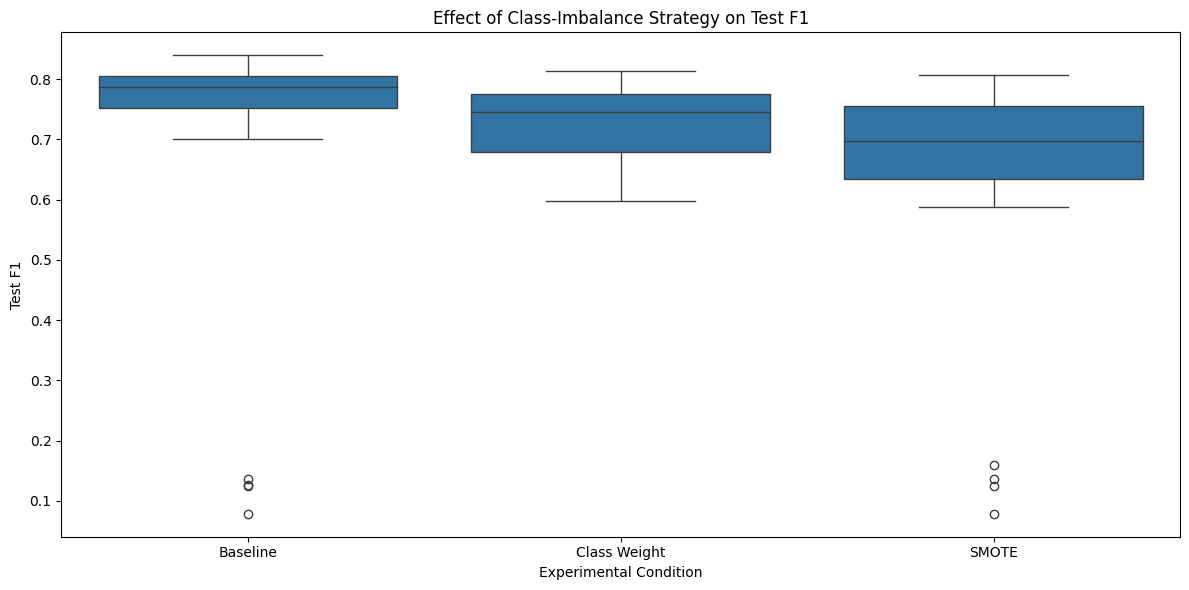

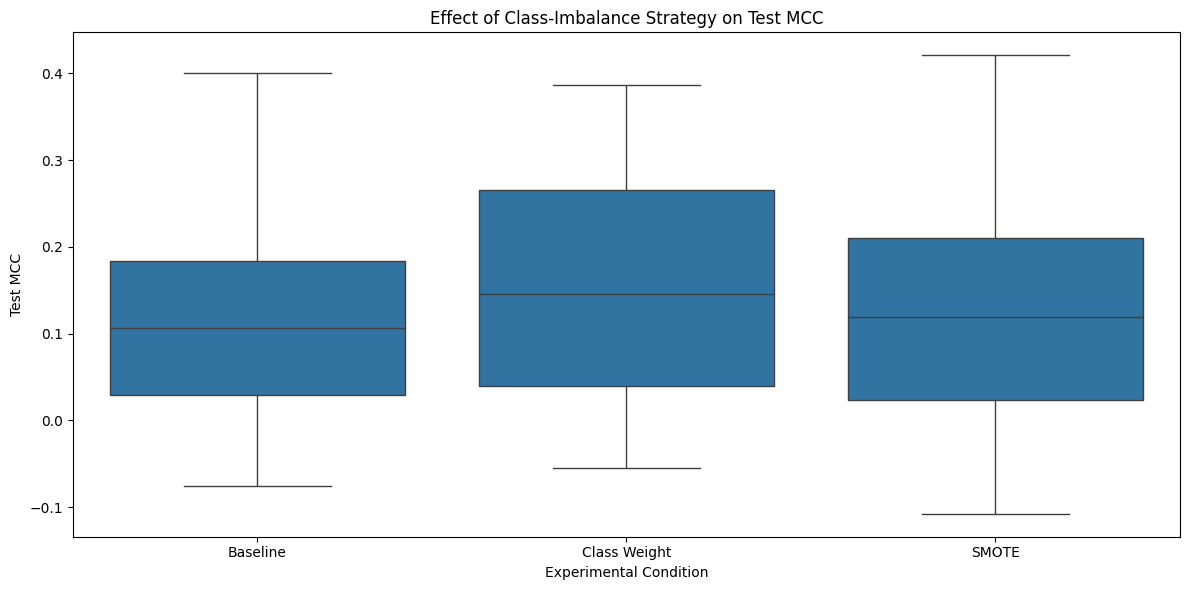


STEP 5 COMPLETED SUCCESSFULLY

Three controlled imbalance conditions evaluated:

    ✓ Baseline
    ✓ Class Weight
    ✓ SMOTE

Across:

    ✓ Overall
    ✓ Public
    ✓ Private
    ✓ Daffodil

Using:

    ✓ 80/20 stratified split
    ✓ Stratified 10-fold CV
    ✓ Leak-safe preprocessing
    ✓ Same evaluation framework
    ✓ Accuracy
    ✓ Precision
    ✓ Recall
    ✓ F1
    ✓ ROC-AUC
    ✓ MCC
    ✓ Cohen's Kappa

NEXT:
    STEP 6 — Hyperparameter optimization
              using GridSearchCV and RandomizedSearchCV.



In [6]:
# ============================================================
# MASTER AI CAREER-ANXIETY COMPARATIVE RESEARCH
# STEP 5
#
# CLASS-IMBALANCE EXPERIMENT
#
# CONDITIONS:
#   1. Baseline
#   2. Class Weighting
#   3. SMOTE
#
# COHORTS:
#   Overall
#   Public
#   Private
#   Daffodil
#
# SAME:
#   - 80/20 stratified split
#   - Stratified 10-fold CV
#   - preprocessing
#   - classifiers
#   - evaluation metrics
#
# IMPORTANT:
# SMOTE is applied ONLY inside the training pipeline.
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    cohen_kappa_score,
    make_scorer
)

from imblearn.over_sampling import SMOTE


# ============================================================
# 2. CONFIGURATION
# ============================================================

RANDOM_STATE = 42

TEST_SIZE = 0.20

N_SPLITS = 10

CV = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)


# ============================================================
# 3. VERIFY PREVIOUS STEPS
# ============================================================

required_objects = [
    "COHORT_DATASETS",
    "FINAL_FEATURES_17",
    "TARGET_COLUMN",
    "BASE_MODELS",
    "COHORT_EXPERIMENTS",
    "ALL_BASELINE_RESULTS"
]

for object_name in required_objects:

    if object_name not in globals():

        raise RuntimeError(
            f"{object_name} is missing.\n"
            f"Please complete Steps 1–4 before Step 5."
        )

print("=" * 80)
print("STEP 5 — CLASS-IMBALANCE EXPERIMENT")
print("=" * 80)

print("\n✓ Steps 1–4 objects detected.")


# ============================================================
# 4. FEATURE TYPES
# ============================================================

CATEGORICAL_FEATURES = [
    "department",
    "career_path"
]

NUMERICAL_FEATURES = [
    "age",
    "gender",
    "academic_year",
    "ai_knowledge",
    "ai_replace_jobs",
    "ai_takeover_time",
    "ai_future_perspective",
    "Total_AI_Tools",
    "Uses_Text_Gen",
    "Uses_Coding_AI",
    "Uses_Creative_AI",
    "Threat_Perception",
    "Perceived_Urgency",
    "Risk_Knowledge_Gap",
    "Age_Year_Ratio"
]


# ============================================================
# 5. PREPROCESSOR FACTORY
# ============================================================

def create_preprocessor_step5():

    numeric_pipeline = SklearnPipeline(
        steps=[

            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),

            (
                "scaler",
                StandardScaler()
            )
        ]
    )


    categorical_pipeline = SklearnPipeline(
        steps=[

            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),

            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            )
        ]
    )


    preprocessor = ColumnTransformer(
        transformers=[

            (
                "num",
                numeric_pipeline,
                NUMERICAL_FEATURES
            ),

            (
                "cat",
                categorical_pipeline,
                CATEGORICAL_FEATURES
            )
        ],

        remainder="drop"
    )


    return preprocessor


# ============================================================
# 6. DEFINE CLASS-WEIGHTED MODELS
# ============================================================
#
# Only models that natively support class_weight are modified.
#
# Models without class_weight remain unchanged and will be
# marked as "Not Applicable" for this condition.
# ============================================================

CLASS_WEIGHTED_MODELS = {

    "Logistic Regression":
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

    "SVM":
        SVC(
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_STATE
        )
}


print("\nClass-weighted models:")

for model_name in CLASS_WEIGHTED_MODELS:

    print(
        f"✓ {model_name}"
    )


print("\nModels without native class_weight support:")

for model_name in BASE_MODELS:

    if model_name not in CLASS_WEIGHTED_MODELS:

        print(
            f"— {model_name}"
        )


# ============================================================
# 7. SMOTE CONFIGURATION
# ============================================================

SMOTE_CONFIG = {

    "sampling_strategy": "auto",

    "random_state": RANDOM_STATE,

    "k_neighbors": 5
}


# ============================================================
# 8. CREATE PIPELINE
# ============================================================

def create_imbalance_pipeline(
    model,
    condition
):

    preprocessor = (
        create_preprocessor_step5()
    )

    model = clone(model)


    # --------------------------------------------------------
    # BASELINE
    # --------------------------------------------------------

    if condition == "Baseline":

        return SklearnPipeline(
            steps=[

                (
                    "preprocessor",
                    preprocessor
                ),

                (
                    "classifier",
                    model
                )
            ]
        )


    # --------------------------------------------------------
    # CLASS WEIGHT
    # --------------------------------------------------------

    elif condition == "Class Weight":

        if (
            model.__class__.__name__
            not in [
                "LogisticRegression",
                "DecisionTreeClassifier",
                "RandomForestClassifier",
                "ExtraTreesClassifier",
                "SVC"
            ]
        ):

            return None


        return SklearnPipeline(
            steps=[

                (
                    "preprocessor",
                    preprocessor
                ),

                (
                    "classifier",
                    model
                )
            ]
        )


    # --------------------------------------------------------
    # SMOTE
    # --------------------------------------------------------
    #
    # IMPORTANT:
    #
    # preprocessing
    #     ↓
    # SMOTE
    #     ↓
    # classifier
    #
    # The entire pipeline is evaluated within CV.
    # Therefore SMOTE sees only each training fold.
    # --------------------------------------------------------

    elif condition == "SMOTE":

        return ImbPipeline(
            steps=[

                (
                    "preprocessor",
                    preprocessor
                ),

                (
                    "smote",
                    SMOTE(
                        **SMOTE_CONFIG
                    )
                ),

                (
                    "classifier",
                    model
                )
            ]
        )


    else:

        raise ValueError(
            f"Unknown condition: {condition}"
        )


# ============================================================
# 9. METRICS
# ============================================================

SCORING_STEP5 = {

    "accuracy":
        "accuracy",

    "precision":
        "precision",

    "recall":
        "recall",

    "f1":
        "f1",

    "roc_auc":
        "roc_auc",

    "mcc":
        make_scorer(
            matthews_corrcoef
        ),

    "kappa":
        make_scorer(
            cohen_kappa_score
        )
}


# ============================================================
# 10. EXPERIMENT FUNCTION
# ============================================================

def run_imbalance_experiment(
    cohort_name,
    cohort_df,
    condition
):

    print(
        f"\n[{cohort_name}] "
        f"{condition}"
    )


    X = cohort_df[
        FINAL_FEATURES_17
    ].copy()


    y = cohort_df[
        TARGET_COLUMN
    ].copy()


    # --------------------------------------------------------
    # STRATIFIED SPLIT
    # --------------------------------------------------------

    X_train, X_test, y_train, y_test = (
        train_test_split(

            X,
            y,

            test_size=TEST_SIZE,

            stratify=y,

            random_state=RANDOM_STATE
        )
    )


    cv_rows = []

    test_rows = []


    for model_name, base_model in BASE_MODELS.items():

        # ----------------------------------------------------
        # Skip class-weight experiment where unsupported
        # ----------------------------------------------------

        if (
            condition == "Class Weight"
            and model_name
            not in CLASS_WEIGHTED_MODELS
        ):

            continue


        # ----------------------------------------------------
        # Select appropriate model
        # ----------------------------------------------------

        if condition == "Class Weight":

            model = (
                CLASS_WEIGHTED_MODELS[
                    model_name
                ]
            )

        else:

            model = base_model


        pipeline = create_imbalance_pipeline(
            model,
            condition
        )


        # ----------------------------------------------------
        # CROSS-VALIDATION
        # ----------------------------------------------------

        scores = cross_validate(

            pipeline,

            X_train,
            y_train,

            cv=CV,

            scoring=SCORING_STEP5,

            n_jobs=-1,

            return_train_score=False,

            error_score="raise"
        )


        cv_rows.append({

            "Cohort":
                cohort_name,

            "Condition":
                condition,

            "Model":
                model_name,

            "CV Accuracy Mean":
                scores[
                    "test_accuracy"
                ].mean(),

            "CV Accuracy SD":
                scores[
                    "test_accuracy"
                ].std(),

            "CV Precision Mean":
                scores[
                    "test_precision"
                ].mean(),

            "CV Precision SD":
                scores[
                    "test_precision"
                ].std(),

            "CV Recall Mean":
                scores[
                    "test_recall"
                ].mean(),

            "CV Recall SD":
                scores[
                    "test_recall"
                ].std(),

            "CV F1 Mean":
                scores[
                    "test_f1"
                ].mean(),

            "CV F1 SD":
                scores[
                    "test_f1"
                ].std(),

            "CV ROC-AUC Mean":
                scores[
                    "test_roc_auc"
                ].mean(),

            "CV ROC-AUC SD":
                scores[
                    "test_roc_auc"
                ].std(),

            "CV MCC Mean":
                scores[
                    "test_mcc"
                ].mean(),

            "CV MCC SD":
                scores[
                    "test_mcc"
                ].std(),

            "CV Kappa Mean":
                scores[
                    "test_kappa"
                ].mean(),

            "CV Kappa SD":
                scores[
                    "test_kappa"
                ].std()
        })


        # ----------------------------------------------------
        # FIT COMPLETE TRAINING DATA
        # ----------------------------------------------------

        pipeline.fit(
            X_train,
            y_train
        )


        # ----------------------------------------------------
        # TEST PREDICTIONS
        # ----------------------------------------------------

        y_pred = pipeline.predict(
            X_test
        )


        # ----------------------------------------------------
        # TEST SCORES
        # ----------------------------------------------------

        if hasattr(
            pipeline,
            "predict_proba"
        ):

            y_score = (
                pipeline
                .predict_proba(
                    X_test
                )[:, 1]
            )

        elif hasattr(
            pipeline,
            "decision_function"
        ):

            y_score = (
                pipeline
                .decision_function(
                    X_test
                )
            )

        else:

            y_score = None


        # ----------------------------------------------------
        # METRICS
        # ----------------------------------------------------

        test_accuracy = accuracy_score(
            y_test,
            y_pred
        )

        test_precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )

        test_recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )

        test_f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )


        if y_score is not None:

            test_roc_auc = (
                roc_auc_score(
                    y_test,
                    y_score
                )
            )

        else:

            test_roc_auc = np.nan


        test_mcc = matthews_corrcoef(
            y_test,
            y_pred
        )

        test_kappa = cohen_kappa_score(
            y_test,
            y_pred
        )


        test_rows.append({

            "Cohort":
                cohort_name,

            "Condition":
                condition,

            "Model":
                model_name,

            "Test Accuracy":
                test_accuracy,

            "Test Precision":
                test_precision,

            "Test Recall":
                test_recall,

            "Test F1":
                test_f1,

            "Test ROC-AUC":
                test_roc_auc,

            "Test MCC":
                test_mcc,

            "Test Cohen Kappa":
                test_kappa
        })


    return (
        pd.DataFrame(cv_rows),
        pd.DataFrame(test_rows)
    )


# ============================================================
# 11. RUN ALL EXPERIMENTS
# ============================================================

IMBALANCE_CV_RESULTS = []

IMBALANCE_TEST_RESULTS = []


for cohort_name in COHORT_ORDER:

    cohort_df = (
        COHORT_DATASETS[
            cohort_name
        ]
    )


    # --------------------------------------------------------
    # BASELINE
    # --------------------------------------------------------

    cv_df, test_df = (
        run_imbalance_experiment(
            cohort_name,
            cohort_df,
            "Baseline"
        )
    )

    IMBALANCE_CV_RESULTS.append(
        cv_df
    )

    IMBALANCE_TEST_RESULTS.append(
        test_df
    )


    # --------------------------------------------------------
    # CLASS WEIGHT
    # --------------------------------------------------------

    cv_df, test_df = (
        run_imbalance_experiment(
            cohort_name,
            cohort_df,
            "Class Weight"
        )
    )

    IMBALANCE_CV_RESULTS.append(
        cv_df
    )

    IMBALANCE_TEST_RESULTS.append(
        test_df
    )


    # --------------------------------------------------------
    # SMOTE
    # --------------------------------------------------------

    cv_df, test_df = (
        run_imbalance_experiment(
            cohort_name,
            cohort_df,
            "SMOTE"
        )
    )

    IMBALANCE_CV_RESULTS.append(
        cv_df
    )

    IMBALANCE_TEST_RESULTS.append(
        test_df
    )


# ============================================================
# 12. COMBINE RESULTS
# ============================================================

IMBALANCE_CV_RESULTS_DF = pd.concat(
    IMBALANCE_CV_RESULTS,
    ignore_index=True
)

IMBALANCE_TEST_RESULTS_DF = pd.concat(
    IMBALANCE_TEST_RESULTS,
    ignore_index=True
)


# ============================================================
# 13. COMBINED RESULT TABLE
# ============================================================

IMBALANCE_COMPARISON = (
    IMBALANCE_CV_RESULTS_DF
    .merge(

        IMBALANCE_TEST_RESULTS_DF,

        on=[
            "Cohort",
            "Condition",
            "Model"
        ],

        how="left"
    )
)


# ============================================================
# 14. DISPLAY COMPLETE RESULTS
# ============================================================

print("\n" + "=" * 80)
print("STEP 5 — COMPLETE IMBALANCE EXPERIMENT")
print("=" * 80)

display(
    IMBALANCE_COMPARISON
    .sort_values(
        [
            "Cohort",
            "Condition",
            "Test F1"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
    .round(4)
)


# ============================================================
# 15. BEST RESULT BY COHORT AND CONDITION
# ============================================================

BEST_BY_CONDITION = (
    IMBALANCE_COMPARISON
    .sort_values(
        "Test F1",
        ascending=False
    )
    .groupby(
        [
            "Cohort",
            "Condition"
        ],
        as_index=False
    )
    .first()
)


print("\n" + "=" * 80)
print("BEST MODEL WITHIN EACH COHORT × CONDITION")
print("=" * 80)

display(
    BEST_BY_CONDITION[
        [
            "Cohort",
            "Condition",
            "Model",
            "CV F1 Mean",
            "Test F1",
            "Test ROC-AUC",
            "Test MCC",
            "Test Cohen Kappa"
        ]
    ].round(4)
)


# ============================================================
# 16. F1 COMPARISON
# ============================================================

F1_COMPARISON = (
    IMBALANCE_COMPARISON
    .pivot_table(

        index="Model",

        columns=[
            "Cohort",
            "Condition"
        ],

        values="Test F1"
    )
)


print("\n" + "=" * 80)
print("TEST F1 — MODEL × COHORT × CONDITION")
print("=" * 80)

display(
    F1_COMPARISON.round(4)
)


# ============================================================
# 17. MCC COMPARISON
# ============================================================

MCC_COMPARISON = (
    IMBALANCE_COMPARISON
    .pivot_table(

        index="Model",

        columns=[
            "Cohort",
            "Condition"
        ],

        values="Test MCC"
    )
)


print("\n" + "=" * 80)
print("TEST MCC — MODEL × COHORT × CONDITION")
print("=" * 80)

display(
    MCC_COMPARISON.round(4)
)


# ============================================================
# 18. ROC-AUC COMPARISON
# ============================================================

ROC_COMPARISON = (
    IMBALANCE_COMPARISON
    .pivot_table(

        index="Model",

        columns=[
            "Cohort",
            "Condition"
        ],

        values="Test ROC-AUC"
    )
)


print("\n" + "=" * 80)
print("TEST ROC-AUC — MODEL × COHORT × CONDITION")
print("=" * 80)

display(
    ROC_COMPARISON.round(4)
)


# ============================================================
# 19. MEAN PERFORMANCE BY CONDITION
# ============================================================

CONDITION_SUMMARY = (
    IMBALANCE_COMPARISON
    .groupby(
        "Condition"
    )
    .agg(

        Mean_Test_F1=(
            "Test F1",
            "mean"
        ),

        Mean_Test_ROC_AUC=(
            "Test ROC-AUC",
            "mean"
        ),

        Mean_Test_MCC=(
            "Test MCC",
            "mean"
        ),

        Mean_Test_Kappa=(
            "Test Cohen Kappa",
            "mean"
        )
    )
    .sort_values(
        "Mean_Test_F1",
        ascending=False
    )
)


print("\n" + "=" * 80)
print("AVERAGE PERFORMANCE BY IMBALANCE CONDITION")
print("=" * 80)

display(
    CONDITION_SUMMARY.round(4)
)


# ============================================================
# 20. CONDITION × COHORT SUMMARY
# ============================================================

CONDITION_COHORT_SUMMARY = (
    IMBALANCE_COMPARISON
    .groupby(
        [
            "Cohort",
            "Condition"
        ]
    )
    .agg(

        Mean_Test_F1=(
            "Test F1",
            "mean"
        ),

        Mean_Test_ROC_AUC=(
            "Test ROC-AUC",
            "mean"
        ),

        Mean_Test_MCC=(
            "Test MCC",
            "mean"
        ),

        Mean_Test_Kappa=(
            "Test Cohen Kappa",
            "mean"
        )
    )
    .reset_index()
)


print("\n" + "=" * 80)
print("CONDITION × COHORT PERFORMANCE")
print("=" * 80)

display(
    CONDITION_COHORT_SUMMARY.round(4)
)


# ============================================================
# 21. VISUALIZE CONDITION EFFECT ON F1
# ============================================================

plt.figure(
    figsize=(12, 6)
)

sns.boxplot(
    data=IMBALANCE_COMPARISON,
    x="Condition",
    y="Test F1"
)

plt.title(
    "Effect of Class-Imbalance Strategy on Test F1"
)

plt.xlabel(
    "Experimental Condition"
)

plt.ylabel(
    "Test F1"
)

plt.tight_layout()
plt.show()


# ============================================================
# 22. VISUALIZE CONDITION EFFECT ON MCC
# ============================================================

plt.figure(
    figsize=(12, 6)
)

sns.boxplot(
    data=IMBALANCE_COMPARISON,
    x="Condition",
    y="Test MCC"
)

plt.title(
    "Effect of Class-Imbalance Strategy on Test MCC"
)

plt.xlabel(
    "Experimental Condition"
)

plt.ylabel(
    "Test MCC"
)

plt.tight_layout()
plt.show()


# ============================================================
# 23. SAVE RESULTS
# ============================================================

IMBALANCE_COMPARISON.to_csv(
    "step5_imbalance_complete_results.csv",
    index=False
)

BEST_BY_CONDITION.to_csv(
    "step5_best_by_condition.csv",
    index=False
)

CONDITION_SUMMARY.to_csv(
    "step5_condition_summary.csv"
)

CONDITION_COHORT_SUMMARY.to_csv(
    "step5_condition_cohort_summary.csv",
    index=False
)

F1_COMPARISON.to_csv(
    "step5_f1_model_cohort_condition.csv"
)

MCC_COMPARISON.to_csv(
    "step5_mcc_model_cohort_condition.csv"
)

ROC_COMPARISON.to_csv(
    "step5_roc_auc_model_cohort_condition.csv"
)


# ============================================================
# 24. FINAL STEP-5 VALIDATION
# ============================================================

expected_conditions = {
    "Baseline",
    "Class Weight",
    "SMOTE"
}

observed_conditions = set(
    IMBALANCE_COMPARISON[
        "Condition"
    ].unique()
)

assert (
    expected_conditions
    .issubset(
        observed_conditions
    )
)


expected_cohorts = set(
    COHORT_ORDER
)

observed_cohorts = set(
    IMBALANCE_COMPARISON[
        "Cohort"
    ].unique()
)

assert (
    expected_cohorts
    == observed_cohorts
)


print("\n" + "=" * 80)
print("STEP 5 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("""
Three controlled imbalance conditions evaluated:

    ✓ Baseline
    ✓ Class Weight
    ✓ SMOTE

Across:

    ✓ Overall
    ✓ Public
    ✓ Private
    ✓ Daffodil

Using:

    ✓ 80/20 stratified split
    ✓ Stratified 10-fold CV
    ✓ Leak-safe preprocessing
    ✓ Same evaluation framework
    ✓ Accuracy
    ✓ Precision
    ✓ Recall
    ✓ F1
    ✓ ROC-AUC
    ✓ MCC
    ✓ Cohen's Kappa

NEXT:
    STEP 6 — Hyperparameter optimization
              using GridSearchCV and RandomizedSearchCV.
""")

In [9]:
# ============================================================
# MASTER AI CAREER-ANXIETY COMPARATIVE RESEARCH
# STEP 6 — LIGHTWEIGHT HYPERPARAMETER OPTIMIZATION
# ============================================================
#
# PURPOSE
# -------
# Controlled hyperparameter optimization after the baseline
# and class-imbalance experiments.
#
# MODELS TUNED:
#   1. SVM — Baseline
#   2. Random Forest — Class Weight
#
# SEARCH STRATEGY:
#   Stage 1: RandomizedSearchCV
#   Stage 2: Small GridSearchCV around randomized winner
#
# VALIDATION:
#   Stratified 10-Fold CV
#
# FINAL TEST:
#   Fixed stratified 80/20 held-out test set
#
# PRIMARY OPTIMIZATION METRIC:
#   F1
#
# IMPORTANT:
#   - SVM probability=False during tuning for speed.
#   - No SMOTE tuning in this step.
#   - Step 5 SMOTE remains an exploratory sensitivity experiment.
#   - Test data is never used for hyperparameter selection.
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import time
import warnings

from sklearn.base import clone

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    GridSearchCV
)

from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    cohen_kappa_score
)

warnings.filterwarnings("ignore")


# ============================================================
# 2. CONFIGURATION
# ============================================================

RANDOM_STATE = 42

TEST_SIZE = 0.20

N_SPLITS = 10

# VERY SMALL ON PURPOSE
RANDOM_SEARCH_ITERATIONS = 2

CV_STEP6 = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

PRIMARY_SCORING = "f1"


print("=" * 80)
print("STEP 6 — LIGHTWEIGHT HYPERPARAMETER OPTIMIZATION")
print("=" * 80)

print(f"Random state      : {RANDOM_STATE}")
print(f"Train/Test split  : 80/20")
print(f"Cross-validation  : Stratified {N_SPLITS}-Fold")
print(f"Random iterations : {RANDOM_SEARCH_ITERATIONS}")
print(f"Primary metric    : {PRIMARY_SCORING}")


# ============================================================
# 3. VERIFY PREVIOUS STEPS
# ============================================================

REQUIRED_OBJECTS = [
    "COHORT_DATASETS",
    "FINAL_FEATURES_17",
    "TARGET_COLUMN",
    "COHORT_ORDER",
    "ALL_BASELINE_RESULTS",
    "IMBALANCE_COMPARISON"
]

for object_name in REQUIRED_OBJECTS:

    if object_name not in globals():

        raise RuntimeError(
            f"\nMissing object: {object_name}\n"
            f"Please complete Steps 1–5 before Step 6."
        )

print("\n✓ Steps 1–5 objects detected.")


# ============================================================
# 4. FEATURE DEFINITIONS
# ============================================================

CATEGORICAL_FEATURES = [
    "department",
    "career_path"
]

NUMERICAL_FEATURES = [
    "age",
    "gender",
    "academic_year",
    "ai_knowledge",
    "ai_replace_jobs",
    "ai_takeover_time",
    "ai_future_perspective",
    "Total_AI_Tools",
    "Uses_Text_Gen",
    "Uses_Coding_AI",
    "Uses_Creative_AI",
    "Threat_Perception",
    "Perceived_Urgency",
    "Risk_Knowledge_Gap",
    "Age_Year_Ratio"
]


# ============================================================
# 5. PREPROCESSOR
# ============================================================

def create_preprocessor_step6():

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_pipeline,
                NUMERICAL_FEATURES
            ),
            (
                "cat",
                categorical_pipeline,
                CATEGORICAL_FEATURES
            )
        ],
        remainder="drop"
    )

    return preprocessor


# ============================================================
# 6. MODEL DEFINITIONS
# ============================================================
#
# SVM:
#   probability=False
#
# This is deliberate.
#
# ROC-AUC can still be calculated from decision_function().
#
# Random Forest:
#   class_weight="balanced"
#
# ============================================================

MODEL_DEFINITIONS = {

    "SVM_Baseline": {

        "condition": "Baseline",

        "model": SVC(
            probability=False,
            random_state=RANDOM_STATE
        )

    },

    "RandomForest_ClassWeight": {

        "condition": "Class Weight",

        "model": RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    }
}


# ============================================================
# 7. RANDOMIZED SEARCH SPACE
# ============================================================

RANDOM_SEARCH_SPACE = {

    "SVM_Baseline": {

        "classifier__C": [
            0.1,
            1,
            10,
            100
        ],

        "classifier__gamma": [
            "scale",
            "auto"
        ],

        "classifier__kernel": [
            "rbf",
            "linear"
        ]
    },


    "RandomForest_ClassWeight": {

        # Reduced tree counts for computational efficiency
        "classifier__n_estimators": [
            100,
            150,
            200
        ],

        "classifier__max_depth": [
            None,
            10,
            15,
            20
        ],

        "classifier__min_samples_split": [
            2,
            5,
            10
        ],

        "classifier__min_samples_leaf": [
            1,
            2,
            4
        ],

        "classifier__max_features": [
            "sqrt",
            "log2"
        ]
    }
}


# ============================================================
# 8. GRID REFINEMENT FUNCTION
# ============================================================
#
# The grid is intentionally SMALL.
#
# RandomizedSearchCV identifies a promising region.
# GridSearchCV performs local refinement.
#
# ============================================================

def create_refinement_grid(
    model_name,
    best_params
):

    # --------------------------------------------------------
    # SVM
    # --------------------------------------------------------

    if model_name == "SVM_Baseline":

        best_C = best_params[
            "classifier__C"
        ]

        best_gamma = best_params[
            "classifier__gamma"
        ]

        best_kernel = best_params[
            "classifier__kernel"
        ]

        # Small local C refinement
        if best_C == 0.1:

            C_values = [0.1, 1]

        elif best_C == 1:

            C_values = [0.1, 1, 10]

        elif best_C == 10:

            C_values = [1, 10, 100]

        else:

            C_values = [10, 100]


        return {

            "classifier__C": C_values,

            "classifier__gamma": [
                best_gamma
            ],

            "classifier__kernel": [
                best_kernel
            ]
        }


    # --------------------------------------------------------
    # RANDOM FOREST
    # --------------------------------------------------------

    elif model_name == "RandomForest_ClassWeight":

        best_n = best_params[
            "classifier__n_estimators"
        ]

        best_depth = best_params[
            "classifier__max_depth"
        ]

        best_split = best_params[
            "classifier__min_samples_split"
        ]

        best_leaf = best_params[
            "classifier__min_samples_leaf"
        ]

        best_features = best_params[
            "classifier__max_features"
        ]


        # Local n_estimators refinement
        if best_n == 100:

            n_values = [100, 150]

        elif best_n == 150:

            n_values = [100, 150, 200]

        else:

            n_values = [150, 200]


        # Local depth refinement
        if best_depth is None:

            depth_values = [None, 10]

        elif best_depth == 10:

            depth_values = [None, 10, 15]

        elif best_depth == 15:

            depth_values = [10, 15, 20]

        else:

            depth_values = [15, 20]


        return {

            "classifier__n_estimators": n_values,

            "classifier__max_depth": depth_values,

            "classifier__min_samples_split": [
                best_split
            ],

            "classifier__min_samples_leaf": [
                best_leaf
            ],

            "classifier__max_features": [
                best_features
            ]
        }


    else:

        raise ValueError(
            f"Unknown model: {model_name}"
        )


# ============================================================
# 9. PIPELINE FACTORY
# ============================================================

def create_step6_pipeline(model):

    return Pipeline(
        steps=[
            (
                "preprocessor",
                create_preprocessor_step6()
            ),

            (
                "classifier",
                clone(model)
            )
        ]
    )


# ============================================================
# 10. RESULT CONTAINERS
# ============================================================

STEP6_RANDOMIZED_RESULTS = []

STEP6_GRID_RESULTS = []

STEP6_FINAL_RESULTS = []

STEP6_FINAL_MODELS = {}


# ============================================================
# 11. MAIN EXPERIMENT
# ============================================================

step6_global_start = time.time()


for cohort_name in COHORT_ORDER:

    print("\n")
    print("=" * 80)
    print(f"COHORT: {cohort_name}")
    print("=" * 80)


    cohort_start = time.time()


    # --------------------------------------------------------
    # Dataset
    # --------------------------------------------------------

    cohort_df = COHORT_DATASETS[
        cohort_name
    ].copy()


    X = cohort_df[
        FINAL_FEATURES_17
    ].copy()


    y = cohort_df[
        TARGET_COLUMN
    ].copy()


    # --------------------------------------------------------
    # Fixed stratified 80/20 split
    # --------------------------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(

        X,

        y,

        test_size=TEST_SIZE,

        stratify=y,

        random_state=RANDOM_STATE
    )


    print(
        f"Dataset N        : {len(cohort_df):,}"
    )

    print(
        f"Train N          : {len(X_train):,}"
    )

    print(
        f"Test N           : {len(X_test):,}"
    )


    # ========================================================
    # MODEL LOOP
    # ========================================================

    for model_name, model_info in MODEL_DEFINITIONS.items():

        model_start = time.time()

        print("\n" + "-" * 70)
        print(f"MODEL: {model_name}")
        print(f"Condition: {model_info['condition']}")
        print("-" * 70)


        # ----------------------------------------------------
        # Build pipeline
        # ----------------------------------------------------

        pipeline = create_step6_pipeline(
            model_info["model"]
        )


        random_space = RANDOM_SEARCH_SPACE[
            model_name
        ]


        # ====================================================
        # STAGE 1 — RANDOMIZED SEARCH
        # ====================================================

        print(
            "\n[1/2] RandomizedSearchCV started..."
        )


        random_search = RandomizedSearchCV(

            estimator=pipeline,

            param_distributions=random_space,

            n_iter=RANDOM_SEARCH_ITERATIONS,

            scoring=PRIMARY_SCORING,

            cv=CV_STEP6,

            random_state=RANDOM_STATE,

            n_jobs=-1,

            refit=True,

            verbose=0,

            return_train_score=False,

            error_score="raise"
        )


        random_search.fit(
            X_train,
            y_train
        )


        randomized_time = (
            time.time() - model_start
        )


        randomized_best_f1 = (
            random_search.best_score_
        )


        randomized_best_params = (
            random_search.best_params_
        )


        STEP6_RANDOMIZED_RESULTS.append({

            "Cohort":
                cohort_name,

            "Candidate":
                model_name,

            "Condition":
                model_info["condition"],

            "Best CV F1":
                randomized_best_f1,

            "Best Parameters":
                str(
                    randomized_best_params
                ),

            "Time Seconds":
                randomized_time

        })


        print(
            f"✓ Randomized CV F1: "
            f"{randomized_best_f1:.4f}"
        )

        print(
            f"✓ Best params: "
            f"{randomized_best_params}"
        )

        print(
            f"✓ Time: "
            f"{randomized_time:.1f} sec"
        )


        # ====================================================
        # STAGE 2 — SMALL GRID REFINEMENT
        # ====================================================

        print(
            "\n[2/2] GridSearchCV refinement started..."
        )


        refinement_grid = create_refinement_grid(

            model_name,

            randomized_best_params
        )


        print(
            f"Grid combinations: "
            f"{np.prod([len(v) for v in refinement_grid.values()]):,}"
        )


        grid_search = GridSearchCV(

            estimator=pipeline,

            param_grid=refinement_grid,

            scoring=PRIMARY_SCORING,

            cv=CV_STEP6,

            n_jobs=-1,

            refit=True,

            verbose=0,

            return_train_score=False,

            error_score="raise"
        )


        grid_start = time.time()


        grid_search.fit(
            X_train,
            y_train
        )


        grid_time = (
            time.time() - grid_start
        )


        grid_best_f1 = (
            grid_search.best_score_
        )


        grid_best_params = (
            grid_search.best_params_
        )


        STEP6_GRID_RESULTS.append({

            "Cohort":
                cohort_name,

            "Candidate":
                model_name,

            "Condition":
                model_info["condition"],

            "Randomized CV F1":
                randomized_best_f1,

            "Grid CV F1":
                grid_best_f1,

            "Best Parameters":
                str(
                    grid_best_params
                ),

            "Time Seconds":
                grid_time

        })


        print(
            f"✓ Grid CV F1: "
            f"{grid_best_f1:.4f}"
        )

        print(
            f"✓ Grid best params: "
            f"{grid_best_params}"
        )

        print(
            f"✓ Grid time: "
            f"{grid_time:.1f} sec"
        )


        # ====================================================
        # FINAL MODEL
        # ====================================================
        #
        # IMPORTANT:
        #
        # We do NOT compare RandomizedSearchCV and
        # GridSearchCV as competing final models.
        #
        # GridSearchCV is the refinement stage.
        #
        # Therefore the GRID BEST ESTIMATOR is the final
        # optimized model.
        #
        # ====================================================

        final_model = (
            grid_search.best_estimator_
        )


        # Save model in memory
        STEP6_FINAL_MODELS[
            (cohort_name, model_name)
        ] = final_model


        # ====================================================
        # HELD-OUT TEST EVALUATION
        # ====================================================

        y_pred = final_model.predict(
            X_test
        )


        # ----------------------------------------------------
        # Score for ROC-AUC
        # ----------------------------------------------------

        if hasattr(
            final_model,
            "predict_proba"
        ):

            y_score = (
                final_model
                .predict_proba(
                    X_test
                )[:, 1]
            )

        elif hasattr(
            final_model,
            "decision_function"
        ):

            y_score = (
                final_model
                .decision_function(
                    X_test
                )
            )

        else:

            y_score = None


        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        test_accuracy = accuracy_score(
            y_test,
            y_pred
        )


        test_precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )


        test_recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )


        test_f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )


        if y_score is not None:

            test_roc_auc = roc_auc_score(
                y_test,
                y_score
            )

        else:

            test_roc_auc = np.nan


        test_mcc = matthews_corrcoef(
            y_test,
            y_pred
        )


        test_kappa = cohen_kappa_score(
            y_test,
            y_pred
        )


        total_model_time = (
            time.time() - model_start
        )


        # ====================================================
        # STORE FINAL RESULTS
        # ====================================================

        STEP6_FINAL_RESULTS.append({

            "Cohort":
                cohort_name,

            "Candidate":
                model_name,

            "Condition":
                model_info["condition"],

            "Randomized CV F1":
                randomized_best_f1,

            "Grid CV F1":
                grid_best_f1,

            "Test Accuracy":
                test_accuracy,

            "Test Precision":
                test_precision,

            "Test Recall":
                test_recall,

            "Test F1":
                test_f1,

            "Test ROC-AUC":
                test_roc_auc,

            "Test MCC":
                test_mcc,

            "Test Cohen Kappa":
                test_kappa,

            "Best Parameters":
                str(
                    grid_best_params
                ),

            "Runtime Seconds":
                total_model_time
        })


        print(
            f"\n✓ FINAL TEST RESULTS"
        )

        print(
            f"  Test Accuracy : {test_accuracy:.4f}"
        )

        print(
            f"  Test Precision: {test_precision:.4f}"
        )

        print(
            f"  Test Recall   : {test_recall:.4f}"
        )

        print(
            f"  Test F1       : {test_f1:.4f}"
        )

        print(
            f"  Test ROC-AUC  : {test_roc_auc:.4f}"
        )

        print(
            f"  Test MCC      : {test_mcc:.4f}"
        )

        print(
            f"  Test Kappa    : {test_kappa:.4f}"
        )

        print(
            f"  Runtime       : {total_model_time:.1f} sec"
        )


    cohort_time = (
        time.time() - cohort_start
    )


    print("\n" + "=" * 80)

    print(
        f"✓ COMPLETED COHORT: {cohort_name}"
    )

    print(
        f"✓ Cohort runtime: "
        f"{cohort_time:.1f} seconds"
    )

    print("=" * 80)


# ============================================================
# 12. DATAFRAMES
# ============================================================

STEP6_RANDOMIZED_DF = pd.DataFrame(
    STEP6_RANDOMIZED_RESULTS
)


STEP6_GRID_DF = pd.DataFrame(
    STEP6_GRID_RESULTS
)


STEP6_FINAL_DF = pd.DataFrame(
    STEP6_FINAL_RESULTS
)


# ============================================================
# 13. DISPLAY RANDOMIZED RESULTS
# ============================================================

print("\n" + "=" * 80)

print(
    "STEP 6 — RANDOMIZED SEARCH RESULTS"
)

print("=" * 80)

display(
    STEP6_RANDOMIZED_DF.round(4)
)


# ============================================================
# 14. DISPLAY GRID RESULTS
# ============================================================

print("\n" + "=" * 80)

print(
    "STEP 6 — GRID REFINEMENT RESULTS"
)

print("=" * 80)

display(
    STEP6_GRID_DF.round(4)
)


# ============================================================
# 15. FINAL OPTIMIZED RESULTS
# ============================================================

print("\n" + "=" * 80)

print(
    "STEP 6 — FINAL OPTIMIZED RESULTS"
)

print("=" * 80)

display(
    STEP6_FINAL_DF
    .sort_values(
        [
            "Cohort",
            "Test F1"
        ],
        ascending=[
            True,
            False
        ]
    )
    .round(4)
)


# ============================================================
# 16. BEST TUNED MODEL PER COHORT
# ============================================================

BEST_STEP6_BY_COHORT = (

    STEP6_FINAL_DF

    .sort_values(
        "Test F1",
        ascending=False
    )

    .groupby(
        "Cohort",
        as_index=False
    )

    .first()
)


print("\n" + "=" * 80)

print(
    "BEST TUNED MODEL PER COHORT"
)

print("=" * 80)

display(

    BEST_STEP6_BY_COHORT[
        [
            "Cohort",
            "Candidate",
            "Condition",
            "Grid CV F1",
            "Test F1",
            "Test ROC-AUC",
            "Test MCC",
            "Test Cohen Kappa",
            "Best Parameters"
        ]
    ].round(4)
)


# ============================================================
# 17. BASELINE VS OPTIMIZED
# ============================================================

STEP4_BASELINE = (

    ALL_BASELINE_RESULTS[
        [
            "Cohort",
            "Model",
            "Test F1",
            "Test ROC-AUC",
            "Test MCC",
            "Test Cohen Kappa"
        ]
    ]

    .rename(
        columns={
            "Model":
                "Baseline Model",

            "Test F1":
                "Baseline F1",

            "Test ROC-AUC":
                "Baseline ROC-AUC",

            "Test MCC":
                "Baseline MCC",

            "Test Cohen Kappa":
                "Baseline Kappa"
        }
    )
)


BEST_BASELINE_PER_COHORT = (

    STEP4_BASELINE

    .sort_values(
        "Baseline F1",
        ascending=False
    )

    .groupby(
        "Cohort",
        as_index=False
    )

    .first()
)


BASELINE_VS_TUNED = (

    BEST_BASELINE_PER_COHORT

    .merge(
        BEST_STEP6_BY_COHORT,
        on="Cohort",
        how="inner"
    )
)


# ============================================================
# 18. IMPROVEMENTS
# ============================================================

BASELINE_VS_TUNED[
    "F1 Improvement"
] = (

    BASELINE_VS_TUNED[
        "Test F1"
    ]

    -

    BASELINE_VS_TUNED[
        "Baseline F1"
    ]
)


BASELINE_VS_TUNED[
    "ROC-AUC Improvement"
] = (

    BASELINE_VS_TUNED[
        "Test ROC-AUC"
    ]

    -

    BASELINE_VS_TUNED[
        "Baseline ROC-AUC"
    ]
)


BASELINE_VS_TUNED[
    "MCC Improvement"
] = (

    BASELINE_VS_TUNED[
        "Test MCC"
    ]

    -

    BASELINE_VS_TUNED[
        "Baseline MCC"
    ]
)


BASELINE_VS_TUNED[
    "Kappa Improvement"
] = (

    BASELINE_VS_TUNED[
        "Test Cohen Kappa"
    ]

    -

    BASELINE_VS_TUNED[
        "Baseline Kappa"
    ]
)


print("\n" + "=" * 80)

print(
    "STEP 4 BASELINE VS STEP 6 OPTIMIZED"
)

print("=" * 80)

display(
    BASELINE_VS_TUNED.round(4)
)


# ============================================================
# 19. HIGHEST TEST-F1 RESULT
# ============================================================

BEST_OVERALL_TUNED = (

    STEP6_FINAL_DF

    .sort_values(
        "Test F1",
        ascending=False
    )

    .iloc[0]
)


print("\n" + "=" * 80)

print(
    "HIGHEST TEST-F1 TUNED RESULT"
)

print("=" * 80)

print(
    f"Cohort       : "
    f"{BEST_OVERALL_TUNED['Cohort']}"
)

print(
    f"Candidate    : "
    f"{BEST_OVERALL_TUNED['Candidate']}"
)

print(
    f"Condition    : "
    f"{BEST_OVERALL_TUNED['Condition']}"
)

print(
    f"Test F1      : "
    f"{BEST_OVERALL_TUNED['Test F1']:.4f}"
)

print(
    f"Test ROC-AUC : "
    f"{BEST_OVERALL_TUNED['Test ROC-AUC']:.4f}"
)

print(
    f"Test MCC     : "
    f"{BEST_OVERALL_TUNED['Test MCC']:.4f}"
)


# ============================================================
# 20. SAVE RESULTS
# ============================================================

STEP6_RANDOMIZED_DF.to_csv(
    "step6_randomized_search_results.csv",
    index=False
)


STEP6_GRID_DF.to_csv(
    "step6_grid_search_results.csv",
    index=False
)


STEP6_FINAL_DF.to_csv(
    "step6_final_optimized_results.csv",
    index=False
)


BEST_STEP6_BY_COHORT.to_csv(
    "step6_best_tuned_by_cohort.csv",
    index=False
)


BASELINE_VS_TUNED.to_csv(
    "step6_baseline_vs_tuned.csv",
    index=False
)


# ============================================================
# 21. FINAL VALIDATION
# ============================================================

assert set(
    STEP6_FINAL_DF[
        "Cohort"
    ].unique()
) == set(
    COHORT_ORDER
)


assert len(
    STEP6_FINAL_DF
) == (
    len(COHORT_ORDER)
    *
    len(MODEL_DEFINITIONS)
)


# ============================================================
# 22. TOTAL RUNTIME
# ============================================================

total_runtime = (
    time.time() - step6_global_start
)


print("\n" + "=" * 80)

print(
    "STEP 6 COMPLETED SUCCESSFULLY"
)

print("=" * 80)

print(
    f"Total runtime: "
    f"{total_runtime:.1f} seconds "
    f"({total_runtime / 60:.2f} minutes)"
)

print("""
Optimization protocol:

✓ SVM — Baseline
✓ Random Forest — Class Weight

✓ RandomizedSearchCV
✓ Small GridSearchCV refinement

✓ Stratified 10-fold CV
✓ Fixed stratified 80/20 test split
✓ F1 used as predefined optimization metric
✓ ROC-AUC, MCC and Cohen's Kappa retained
✓ Test set excluded from hyperparameter selection
✓ SVM probability estimation disabled during tuning
✓ No SMOTE tuning in Step 6
""")

STEP 6 — LIGHTWEIGHT HYPERPARAMETER OPTIMIZATION
Random state      : 42
Train/Test split  : 80/20
Cross-validation  : Stratified 10-Fold
Random iterations : 2
Primary metric    : f1

✓ Steps 1–5 objects detected.


COHORT: Overall
Dataset N        : 2,036
Train N          : 1,628
Test N           : 408

----------------------------------------------------------------------
MODEL: SVM_Baseline
Condition: Baseline
----------------------------------------------------------------------

[1/2] RandomizedSearchCV started...
✓ Randomized CV F1: 0.8065
✓ Best params: {'classifier__kernel': 'rbf', 'classifier__gamma': 'scale', 'classifier__C': 0.1}
✓ Time: 14.6 sec

[2/2] GridSearchCV refinement started...
Grid combinations: 2
✓ Grid CV F1: 0.8068
✓ Grid best params: {'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
✓ Grid time: 8.5 sec

✓ FINAL TEST RESULTS
  Test Accuracy : 0.6887
  Test Precision: 0.6905
  Test Recall   : 0.9783
  Test F1       : 0.8096
  Test R

,Cohort,Candidate,Condition,Best CV F1,Best Parameters,Time Seconds
0,Overall,SVM_Baseline,Baseline,0.8065,"{'classifier__kernel': 'rbf', 'classifier__gam...",14.6080
1,Overall,RandomForest_ClassWeight,Class Weight,0.7141,"{'classifier__n_estimators': 200, 'classifier_...",8.0258
2,Public,SVM_Baseline,Baseline,0.8045,"{'classifier__kernel': 'rbf', 'classifier__gam...",0.9819
3,Public,RandomForest_ClassWeight,Class Weight,0.7093,"{'classifier__n_estimators': 200, 'classifier_...",7.6479
4,Private,SVM_Baseline,Baseline,0.8086,"{'classifier__kernel': 'linear', 'classifier__...",1.7759
5,Private,RandomForest_ClassWeight,Class Weight,0.7239,"{'classifier__n_estimators': 200, 'classifier_...",8.2200
6,Daffodil,SVM_Baseline,Baseline,0.8208,"{'classifier__kernel': 'rbf', 'classifier__gam...",0.7714
7,Daffodil,RandomForest_ClassWeight,Class Weight,0.7747,"{'classifier__n_estimators': 100, 'classifier_...",6.1066



STEP 6 — GRID REFINEMENT RESULTS


,Cohort,Candidate,Condition,Randomized CV F1,Grid CV F1,Best Parameters,Time Seconds
0,Overall,SVM_Baseline,Baseline,0.8065,0.8068,"{'classifier__C': 1, 'classifier__gamma': 'sca...",8.5465
1,Overall,RandomForest_ClassWeight,Class Weight,0.7141,0.7141,"{'classifier__max_depth': 20, 'classifier__max...",20.9792
2,Public,SVM_Baseline,Baseline,0.8045,0.8045,"{'classifier__C': 0.1, 'classifier__gamma': 's...",0.9830
3,Public,RandomForest_ClassWeight,Class Weight,0.7093,0.7093,"{'classifier__max_depth': 20, 'classifier__max...",15.6719
4,Private,SVM_Baseline,Baseline,0.8086,0.8086,"{'classifier__C': 0.1, 'classifier__gamma': 's...",2.3695
5,Private,RandomForest_ClassWeight,Class Weight,0.7239,0.7308,"{'classifier__max_depth': 15, 'classifier__max...",16.5348
6,Daffodil,SVM_Baseline,Baseline,0.8208,0.8372,"{'classifier__C': 1, 'classifier__gamma': 'sca...",0.7806
7,Daffodil,RandomForest_ClassWeight,Class Weight,0.7747,0.7747,"{'classifier__max_depth': 10, 'classifier__max...",16.2949



STEP 6 — FINAL OPTIMIZED RESULTS


...


BEST TUNED MODEL PER COHORT


,Cohort,Candidate,Condition,Grid CV F1,Test F1,Test ROC-AUC,Test MCC,Test Cohen Kappa,Best Parameters
0,Daffodil,SVM_Baseline,Baseline,0.8372,0.8396,0.7283,0.3626,0.3398,"{'classifier__C': 1, 'classifier__gamma': 'sca..."
1,Overall,SVM_Baseline,Baseline,0.8068,0.8096,0.6055,0.1442,0.0797,"{'classifier__C': 1, 'classifier__gamma': 'sca..."
2,Private,SVM_Baseline,Baseline,0.8086,0.8072,0.6221,0.0507,0.0188,"{'classifier__C': 0.1, 'classifier__gamma': 's..."
3,Public,SVM_Baseline,Baseline,0.8045,0.8041,0.5115,0.0000,0.0000,"{'classifier__C': 0.1, 'classifier__gamma': 's..."



STEP 4 BASELINE VS STEP 6 OPTIMIZED


,Cohort,Baseline Model,Baseline F1,Baseline ROC-AUC,Baseline MCC,Baseline Kappa,Candidate,Condition,Randomized CV F1,Grid CV F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test MCC,Test Cohen Kappa,Best Parameters,Runtime Seconds,F1 Improvement,ROC-AUC Improvement,MCC Improvement,Kappa Improvement
0,Daffodil,SVM,0.8396,0.7283,0.3626,0.3398,SVM_Baseline,Baseline,0.8208,0.8372,0.7554,0.7739,0.9175,0.8396,0.7283,0.3626,0.3398,"{'classifier__C': 1, 'classifier__gamma': 'sca...",1.5925,0.0000,0.0000,0.0000,0.0000
1,Overall,SVM,0.8096,0.6055,0.1442,0.0797,SVM_Baseline,Baseline,0.8065,0.8068,0.6887,0.6905,0.9783,0.8096,0.6055,0.1442,0.0797,"{'classifier__C': 1, 'classifier__gamma': 'sca...",23.4289,0.0000,0.0000,0.0000,0.0000
2,Private,SVM,0.8211,0.6709,0.2332,0.1464,SVM_Baseline,Baseline,0.8086,0.8086,0.6795,0.6826,0.9874,0.8072,0.6221,0.0507,0.0188,"{'classifier__C': 0.1, 'classifier__gamma': 's...",4.1881,-0.0139,-0.0488,-0.1825,-0.1277
3,Public,SVM,0.8000,0.5125,-0.0531,-0.0114,SVM_Baseline,Baseline,0.8045,0.8045,0.6724,0.6724,1.0000,0.8041,0.5115,0.0000,0.0000,"{'classifier__C': 0.1, 'classifier__gamma': 's...",2.0179,0.0041,-0.0010,0.0531,0.0114



HIGHEST TEST-F1 TUNED RESULT
Cohort       : Daffodil
Candidate    : SVM_Baseline
Condition    : Baseline
Test F1      : 0.8396
Test ROC-AUC : 0.7283
Test MCC     : 0.3626

STEP 6 COMPLETED SUCCESSFULLY
Total runtime: 131.5 seconds (2.19 minutes)

Optimization protocol:

✓ SVM — Baseline
✓ Random Forest — Class Weight

✓ RandomizedSearchCV
✓ Small GridSearchCV refinement

✓ Stratified 10-fold CV
✓ Fixed stratified 80/20 test split
✓ F1 used as predefined optimization metric
✓ ROC-AUC, MCC and Cohen's Kappa retained
✓ Test set excluded from hyperparameter selection
✓ SVM probability estimation disabled during tuning
✓ No SMOTE tuning in Step 6



In [10]:
# ============================================================
# STEP 6 — CONSISTENCY AUDIT BEFORE STEP 7
# ============================================================
#
# PURPOSE:
# Verify that Step 4 baseline and Step 6 optimized pipeline
# are using the same data structure / split assumptions.
#
# NO MODEL TRAINING
# NO HYPERPARAMETER SEARCH
# FAST CHECK ONLY
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC

RANDOM_STATE = 42
TEST_SIZE = 0.20

print("=" * 80)
print("STEP 6 — PRE-STEP-7 CONSISTENCY AUDIT")
print("=" * 80)


# ============================================================
# 1. CHECK REQUIRED OBJECTS
# ============================================================

required = [
    "COHORT_DATASETS",
    "FINAL_FEATURES_17",
    "TARGET_COLUMN",
    "COHORT_ORDER",
    "ALL_BASELINE_RESULTS"
]

missing = [
    x for x in required
    if x not in globals()
]

if missing:

    raise RuntimeError(
        "Missing objects: "
        + ", ".join(missing)
        + "\nPlease do not proceed to Step 7 yet."
    )

print("✓ Required objects available.")


# ============================================================
# 2. DATASET STRUCTURE AUDIT
# ============================================================

print("\n" + "=" * 80)
print("DATASET STRUCTURE")
print("=" * 80)

for cohort in COHORT_ORDER:

    df = COHORT_DATASETS[cohort]

    print(
        f"{cohort:10s} | "
        f"N={len(df):4d} | "
        f"features={len(FINAL_FEATURES_17):2d} | "
        f"target={TARGET_COLUMN}"
    )

    # Feature existence
    missing_features = [
        f for f in FINAL_FEATURES_17
        if f not in df.columns
    ]

    if missing_features:

        print(
            "  ⚠ Missing features:",
            missing_features
        )

    else:

        print(
            "  ✓ All 17 features present"
        )


# ============================================================
# 3. TARGET DISTRIBUTION
# ============================================================

print("\n" + "=" * 80)
print("TARGET DISTRIBUTION")
print("=" * 80)

for cohort in COHORT_ORDER:

    y = COHORT_DATASETS[
        cohort
    ][TARGET_COLUMN]

    counts = y.value_counts(
        dropna=False
    ).sort_index()

    print(
        f"{cohort:10s}: "
        f"class 0 = {counts.get(0, 0)}, "
        f"class 1 = {counts.get(1, 0)}"
    )


# ============================================================
# 4. REPRODUCIBLE SPLIT AUDIT
# ============================================================
#
# We create the canonical split again.
#
# Because train_test_split is deterministic with:
#   random_state=42
#   test_size=0.20
#   stratify=y
#
# the same dataset ordering + same parameters should generate
# the same test indices.
#
# ============================================================

print("\n" + "=" * 80)
print("CANONICAL 80/20 STRATIFIED SPLIT")
print("=" * 80)

CANONICAL_SPLITS = {}

for cohort in COHORT_ORDER:

    df = COHORT_DATASETS[
        cohort
    ].copy()

    X = df[
        FINAL_FEATURES_17
    ]

    y = df[
        TARGET_COLUMN
    ]

    # Preserve dataframe indices
    X_train, X_test, y_train, y_test = train_test_split(

        X,
        y,

        test_size=TEST_SIZE,

        stratify=y,

        random_state=RANDOM_STATE
    )

    CANONICAL_SPLITS[
        cohort
    ] = {

        "train_indices":
            X_train.index.tolist(),

        "test_indices":
            X_test.index.tolist(),

        "train_n":
            len(X_train),

        "test_n":
            len(X_test)
    }

    print(
        f"{cohort:10s} | "
        f"Train={len(X_train):4d} | "
        f"Test={len(X_test):4d}"
    )


# ============================================================
# 5. TEST-SET CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 80)
print("TEST-SET CLASS DISTRIBUTION")
print("=" * 80)

for cohort in COHORT_ORDER:

    split = CANONICAL_SPLITS[
        cohort
    ]

    df = COHORT_DATASETS[
        cohort
    ]

    y_test = df.loc[
        split["test_indices"],
        TARGET_COLUMN
    ]

    counts = y_test.value_counts(
        normalize=False
    ).sort_index()

    proportions = y_test.value_counts(
        normalize=True
    ).sort_index()

    print(
        f"\n{cohort}"
    )

    print(
        f"  Class 0: "
        f"{counts.get(0, 0)} "
        f"({proportions.get(0, 0):.3f})"
    )

    print(
        f"  Class 1: "
        f"{counts.get(1, 0)} "
        f"({proportions.get(1, 0):.3f})"
    )


# ============================================================
# 6. CHECK STEP 6 RESULTS
# ============================================================

print("\n" + "=" * 80)
print("STEP 6 RESULTS SANITY CHECK")
print("=" * 80)

if "STEP6_FINAL_DF" in globals():

    print(
        f"✓ STEP6_FINAL_DF contains "
        f"{len(STEP6_FINAL_DF)} rows."
    )

    expected_rows = (
        len(COHORT_ORDER) * 2
    )

    print(
        f"Expected rows: {expected_rows}"
    )

    if len(STEP6_FINAL_DF) == expected_rows:

        print(
            "✓ Correct number of Step 6 results."
        )

    else:

        print(
            "⚠ Unexpected number of Step 6 results."
        )

else:

    print(
        "⚠ STEP6_FINAL_DF not found."
    )


# ============================================================
# 7. STEP 6 BEST MODEL SUMMARY
# ============================================================

if "BEST_STEP6_BY_COHORT" in globals():

    print("\n" + "=" * 80)
    print("STEP 6 BEST MODELS")
    print("=" * 80)

    display(
        BEST_STEP6_BY_COHORT[
            [
                "Cohort",
                "Candidate",
                "Condition",
                "Grid CV F1",
                "Test F1",
                "Test ROC-AUC",
                "Test MCC",
                "Test Cohen Kappa"
            ]
        ].round(4)
    )


# ============================================================
# 8. IMPORTANT PRIVATE-COHORT CHECK
# ============================================================

print("\n" + "=" * 80)
print("PRIVATE COHORT — DISCREPANCY CHECK")
print("=" * 80)

private_baseline = ALL_BASELINE_RESULTS[
    ALL_BASELINE_RESULTS["Cohort"]
    == "Private"
].copy()

print("\nStep 4 Private baseline results:")

display(
    private_baseline[
        [
            "Model",
            "Test F1",
            "Test ROC-AUC",
            "Test MCC",
            "Test Cohen Kappa"
        ]
    ].sort_values(
        "Test F1",
        ascending=False
    ).round(4)
)


if "STEP6_FINAL_DF" in globals():

    private_step6 = STEP6_FINAL_DF[
        STEP6_FINAL_DF["Cohort"]
        == "Private"
    ].copy()

    print("\nStep 6 Private results:")

    display(
        private_step6[
            [
                "Candidate",
                "Condition",
                "Grid CV F1",
                "Test F1",
                "Test ROC-AUC",
                "Test MCC",
                "Test Cohen Kappa"
            ]
        ].round(4)
    )


# ============================================================
# 9. SVM BASELINE COMPARISON
# ============================================================

print("\n" + "=" * 80)
print("SVM BASELINE — STEP 4 VS STEP 6")
print("=" * 80)

step4_svm = (
    ALL_BASELINE_RESULTS[
        ALL_BASELINE_RESULTS["Model"]
        == "SVM"
    ][
        [
            "Cohort",
            "Test F1",
            "Test ROC-AUC",
            "Test MCC",
            "Test Cohen Kappa"
        ]
    ]
    .rename(
        columns={
            "Test F1":
                "Step4 F1",

            "Test ROC-AUC":
                "Step4 ROC-AUC",

            "Test MCC":
                "Step4 MCC",

            "Test Cohen Kappa":
                "Step4 Kappa"
        }
    )
)


step6_svm = (
    STEP6_FINAL_DF[
        STEP6_FINAL_DF["Candidate"]
        == "SVM_Baseline"
    ][
        [
            "Cohort",
            "Test F1",
            "Test ROC-AUC",
            "Test MCC",
            "Test Cohen Kappa"
        ]
    ]
    .rename(
        columns={
            "Test F1":
                "Step6 F1",

            "Test ROC-AUC":
                "Step6 ROC-AUC",

            "Test MCC":
                "Step6 MCC",

            "Test Cohen Kappa":
                "Step6 Kappa"
        }
    )
)


svm_comparison = step4_svm.merge(
    step6_svm,
    on="Cohort",
    how="outer"
)


svm_comparison[
    "F1 Difference"
] = (
    svm_comparison["Step6 F1"]
    -
    svm_comparison["Step4 F1"]
)


svm_comparison[
    "ROC-AUC Difference"
] = (
    svm_comparison["Step6 ROC-AUC"]
    -
    svm_comparison["Step4 ROC-AUC"]
)


svm_comparison[
    "MCC Difference"
] = (
    svm_comparison["Step6 MCC"]
    -
    svm_comparison["Step4 MCC"]
)


svm_comparison[
    "Kappa Difference"
] = (
    svm_comparison["Step6 Kappa"]
    -
    svm_comparison["Step4 Kappa"]
)


display(
    svm_comparison.round(4)
)


# ============================================================
# 10. AUTOMATIC DIAGNOSTIC
# ============================================================

print("\n" + "=" * 80)
print("DIAGNOSTIC CONCLUSION")
print("=" * 80)

private_row = svm_comparison[
    svm_comparison["Cohort"]
    == "Private"
]

if len(private_row) == 1:

    row = private_row.iloc[0]

    f1_diff = abs(
        row["F1 Difference"]
    )

    roc_diff = abs(
        row["ROC-AUC Difference"]
    )

    mcc_diff = abs(
        row["MCC Difference"]
    )


    if (
        f1_diff < 0.001
        and
        roc_diff < 0.001
        and
        mcc_diff < 0.001
    ):

        print(
            "✓ Private SVM is numerically consistent."
        )

        print(
            "✓ No meaningful discrepancy detected."
        )

        print(
            "→ Step 6 can be frozen."
        )


    else:

        print(
            "⚠ Private SVM differs between Step 4 and Step 6."
        )

        print(
            f"  F1 difference     : {row['F1 Difference']:.4f}"
        )

        print(
            f"  ROC-AUC difference: {row['ROC-AUC Difference']:.4f}"
        )

        print(
            f"  MCC difference    : {row['MCC Difference']:.4f}"
        )

        print(
            "\n→ Do NOT interpret the Step 4 → Step 6"
        )

        print(
            "  improvement table as a causal optimization gain yet."
        )

        print(
            "→ We will establish the canonical split before Step 7."
        )


# ============================================================
# 11. FINAL STATUS
# ============================================================

print("\n" + "=" * 80)
print("AUDIT COMPLETE")
print("=" * 80)

print("""
No model was retrained by this audit.

Next action depends only on the diagnostic above:

A) If all Step 4 / Step 6 comparisons are consistent:
   → Freeze Step 6
   → Proceed to Step 7

B) If Private remains inconsistent:
   → We will trace the exact Step 4 split/preprocessing
   → Establish one canonical experimental split
   → Then freeze the protocol
   → Then proceed to Step 7

Do not modify any previous result manually.
""")

STEP 6 — PRE-STEP-7 CONSISTENCY AUDIT
✓ Required objects available.

DATASET STRUCTURE
Overall    | N=2036 | features=17 | target=Anxiety_Label
  ✓ All 17 features present
Public     | N= 868 | features=17 | target=Anxiety_Label
  ✓ All 17 features present
Private    | N=1168 | features=17 | target=Anxiety_Label
  ✓ All 17 features present
Daffodil   | N= 695 | features=17 | target=Anxiety_Label
  ✓ All 17 features present

TARGET DISTRIBUTION
Overall   : class 0 = 660, class 1 = 1376
Public    : class 0 = 284, class 1 = 584
Private   : class 0 = 376, class 1 = 792
Daffodil  : class 0 = 211, class 1 = 484

CANONICAL 80/20 STRATIFIED SPLIT
Overall    | Train=1628 | Test= 408
Public     | Train= 694 | Test= 174
Private    | Train= 934 | Test= 234
Daffodil   | Train= 556 | Test= 139

TEST-SET CLASS DISTRIBUTION

Overall
  Class 0: 132 (0.324)
  Class 1: 276 (0.676)

Public
  Class 0: 57 (0.328)
  Class 1: 117 (0.672)

Private
  Class 0: 75 (0.321)
  Class 1: 159 (0.679)

Daffodil
  Class 

,Cohort,Candidate,Condition,Grid CV F1,Test F1,Test ROC-AUC,Test MCC,Test Cohen Kappa
0,Daffodil,SVM_Baseline,Baseline,0.8372,0.8396,0.7283,0.3626,0.3398
1,Overall,SVM_Baseline,Baseline,0.8068,0.8096,0.6055,0.1442,0.0797
2,Private,SVM_Baseline,Baseline,0.8086,0.8072,0.6221,0.0507,0.0188
3,Public,SVM_Baseline,Baseline,0.8045,0.8041,0.5115,0.0000,0.0000



PRIVATE COHORT — DISCREPANCY CHECK

Step 4 Private baseline results:


,Model,Test F1,Test ROC-AUC,Test MCC,Test Cohen Kappa
20,SVM,0.8211,0.6709,0.2332,0.1464
24,Random Forest,0.8056,0.6568,0.2438,0.2216
21,Gradient Boosting,0.8011,0.6813,0.1651,0.1344
22,AdaBoost,0.7968,0.6564,0.0584,0.0378
23,Logistic Regression,0.7955,0.6812,0.1894,0.1697
26,Extra Trees,0.7884,0.6254,0.2181,0.2085
25,LDA,0.7803,0.6772,0.1814,0.1728
27,KNN,0.7536,0.6130,0.0820,0.0784
28,Decision Tree,0.7192,0.5678,0.1299,0.1299
29,Gaussian Naive Bayes,0.1364,0.6496,0.0158,0.0059



Step 6 Private results:


,Candidate,Condition,Grid CV F1,Test F1,Test ROC-AUC,Test MCC,Test Cohen Kappa
4,SVM_Baseline,Baseline,0.8086,0.8072,0.6221,0.0507,0.0188
5,RandomForest_ClassWeight,Class Weight,0.7308,0.7171,0.6852,0.1976,0.1959



SVM BASELINE — STEP 4 VS STEP 6


,Cohort,Step4 F1,Step4 ROC-AUC,Step4 MCC,Step4 Kappa,Step6 F1,Step6 ROC-AUC,Step6 MCC,Step6 Kappa,F1 Difference,ROC-AUC Difference,MCC Difference,Kappa Difference
0,Daffodil,0.8396,0.7283,0.3626,0.3398,0.8396,0.7283,0.3626,0.3398,0.0000,0.0000,0.0000,0.0000
1,Overall,0.8096,0.6055,0.1442,0.0797,0.8096,0.6055,0.1442,0.0797,0.0000,0.0000,0.0000,0.0000
2,Private,0.8211,0.6709,0.2332,0.1464,0.8072,0.6221,0.0507,0.0188,-0.0139,-0.0488,-0.1825,-0.1277
3,Public,0.8000,0.5125,-0.0531,-0.0114,0.8041,0.5115,0.0000,0.0000,0.0041,-0.0010,0.0531,0.0114



DIAGNOSTIC CONCLUSION
⚠ Private SVM differs between Step 4 and Step 6.
  F1 difference     : -0.0139
  ROC-AUC difference: -0.0488
  MCC difference    : -0.1825

→ Do NOT interpret the Step 4 → Step 6
  improvement table as a causal optimization gain yet.
→ We will establish the canonical split before Step 7.

AUDIT COMPLETE

No model was retrained by this audit.

Next action depends only on the diagnostic above:

A) If all Step 4 / Step 6 comparisons are consistent:
   → Freeze Step 6
   → Proceed to Step 7

B) If Private remains inconsistent:
   → We will trace the exact Step 4 split/preprocessing
   → Establish one canonical experimental split
   → Then freeze the protocol
   → Then proceed to Step 7

Do not modify any previous result manually.



In [11]:
# ============================================================
# STEP 7 — LASSO FEATURE SELECTION + 10-FOLD STABILITY
# ============================================================
#
# Protocol:
#   • 4 cohorts
#   • 17 engineered features
#   • Fixed stratified 80/20 split
#   • LASSO = L1 Logistic Regression
#   • solver = liblinear
#   • C = 0.1
#   • Stratified 10-fold CV
#   • Preprocessing fitted INSIDE each CV fold
#   • Test set NEVER used for feature selection
#
# Output:
#   1. Fold-level selected features
#   2. Feature selection frequency
#   3. Stability percentage
#   4. Stable feature sets
#   5. Cohort comparison
#   6. CSV result files
# ============================================================

import numpy as np
import pandas as pd
import time
import os

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

LASSO_C = 0.1
N_SPLITS = 10
RANDOM_STATE = 42
TEST_SIZE = 0.20

# A coefficient is considered selected if its absolute value
# is greater than this threshold.
COEF_THRESHOLD = 1e-8

print("=" * 90)
print("STEP 7 — LASSO FEATURE SELECTION + 10-FOLD STABILITY ANALYSIS")
print("=" * 90)

print(f"LASSO C             : {LASSO_C}")
print(f"Solver              : liblinear")
print(f"Penalty             : L1")
print(f"CV folds            : {N_SPLITS}")
print(f"Random state        : {RANDOM_STATE}")
print(f"Test size           : {TEST_SIZE}")
print(f"Coefficient cutoff  : {COEF_THRESHOLD}")

# ============================================================
# 1. VERIFY REQUIRED OBJECTS
# ============================================================

required_objects = [
    "COHORT_DATASETS",
    "FINAL_FEATURES_17",
    "TARGET_COLUMN",
    "COHORT_ORDER"
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Missing required objects: "
        + ", ".join(missing_objects)
        + "\nDo not continue until the Master pipeline objects exist."
    )

print("\n✓ All required Master pipeline objects found.")
print(f"✓ Number of engineered features: {len(FINAL_FEATURES_17)}")


# ============================================================
# 2. FEATURE GROUPS
# ============================================================

CATEGORICAL_FEATURES = [
    "department",
    "career_path"
]

NUMERICAL_FEATURES = [
    f for f in FINAL_FEATURES_17
    if f not in CATEGORICAL_FEATURES
]

print("\nFeature groups:")
print(f"  Categorical : {CATEGORICAL_FEATURES}")
print(f"  Numerical   : {len(NUMERICAL_FEATURES)}")


# ============================================================
# 3. PREPROCESSOR FACTORY
# ============================================================
#
# IMPORTANT:
# A fresh preprocessor is created for every fold.
# Therefore imputation, scaling and one-hot encoding are learned
# ONLY from that fold's training portion.
# ============================================================

def create_lasso_preprocessor():

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_pipeline,
                NUMERICAL_FEATURES
            ),
            (
                "cat",
                categorical_pipeline,
                CATEGORICAL_FEATURES
            )
        ],
        remainder="drop"
    )

    return preprocessor


# ============================================================
# 4. MAP TRANSFORMED FEATURES BACK TO ORIGINAL 17 FEATURES
# ============================================================
#
# One-hot encoding creates multiple columns from:
#   department
#   career_path
#
# We therefore aggregate their coefficients back to their
# original feature.
#
# An original feature is considered selected when at least one
# of its transformed columns has a non-zero LASSO coefficient.
# ============================================================

def get_original_feature_mapping(preprocessor):

    mapping = {}

    # Numerical features remain one column each
    for feature in NUMERICAL_FEATURES:
        mapping[feature] = [feature]

    # Categorical features become multiple one-hot columns
    try:

        cat_encoder = (
            preprocessor
            .named_transformers_["cat"]
            .named_steps["onehot"]
        )

        for feature, categories in zip(
            CATEGORICAL_FEATURES,
            cat_encoder.categories_
        ):

            mapping[feature] = [
                f"{feature}_{category}"
                for category in categories
            ]

    except Exception:

        # Fallback: treat categorical feature as one block
        for feature in CATEGORICAL_FEATURES:
            mapping[feature] = [feature]

    return mapping


# ============================================================
# 5. SINGLE-FOLD LASSO FUNCTION
# ============================================================

def run_single_lasso_fold(X_train, y_train):

    preprocessor = create_lasso_preprocessor()

    lasso_model = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=LASSO_C,
        random_state=RANDOM_STATE,
        max_iter=5000
    )

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "lasso",
                lasso_model
            )
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    fitted_preprocessor = (
        pipeline.named_steps["preprocessor"]
    )

    fitted_lasso = (
        pipeline.named_steps["lasso"]
    )

    coefficients = np.asarray(
        fitted_lasso.coef_
    ).ravel()

    transformed_feature_names = (
        fitted_preprocessor
        .get_feature_names_out()
    )

    mapping = get_original_feature_mapping(
        fitted_preprocessor
    )

    # --------------------------------------------------------
    # Determine original-feature selection
    # --------------------------------------------------------

    selected_original = {}

    for original_feature in FINAL_FEATURES_17:

        if original_feature in NUMERICAL_FEATURES:

            matching_indices = [
                i
                for i, name in enumerate(
                    transformed_feature_names
                )
                if name.endswith(
                    f"__{original_feature}"
                )
            ]

        else:

            matching_indices = [
                i
                for i, name in enumerate(
                    transformed_feature_names
                )
                if name.startswith(
                    f"cat__{original_feature}_"
                )
            ]

        # Fallback matching
        if not matching_indices:

            matching_indices = [
                i
                for i, name in enumerate(
                    transformed_feature_names
                )
                if original_feature in name
            ]

        max_abs_coef = (
            max(
                [
                    abs(coefficients[i])
                    for i in matching_indices
                ],
                default=0.0
            )
        )

        selected_original[
            original_feature
        ] = max_abs_coef > COEF_THRESHOLD

    return {
        "pipeline": pipeline,
        "coefficients": coefficients,
        "transformed_feature_names":
            transformed_feature_names,
        "selected_original":
            selected_original
    }


# ============================================================
# 6. RUN LASSO STABILITY FOR ALL COHORTS
# ============================================================

lasso_fold_records = []
lasso_frequency_records = []
lasso_selected_features = {}

overall_start = time.time()

for cohort in COHORT_ORDER:

    cohort_start = time.time()

    print("\n" + "=" * 90)
    print(f"COHORT: {cohort}")
    print("=" * 90)

    df = COHORT_DATASETS[
        cohort
    ].copy()

    X = df[
        FINAL_FEATURES_17
    ].copy()

    y = df[
        TARGET_COLUMN
    ].copy()

    print(f"Dataset size : {len(df)}")
    print(f"Features     : {len(FINAL_FEATURES_17)}")

    # --------------------------------------------------------
    # Fixed 80/20 split
    # --------------------------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE
    )

    print(
        f"Train/Test   : "
        f"{len(X_train)}/{len(X_test)}"
    )

    # --------------------------------------------------------
    # Stratified 10-fold CV
    # --------------------------------------------------------

    skf = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    feature_selection_counts = {
        feature: 0
        for feature in FINAL_FEATURES_17
    }

    fold_selected_features = {}

    # --------------------------------------------------------
    # CV LOOP
    # --------------------------------------------------------

    for fold_number, (
        train_idx,
        validation_idx
    ) in enumerate(
        skf.split(X_train, y_train),
        start=1
    ):

        X_fold_train = X_train.iloc[
            train_idx
        ].copy()

        y_fold_train = y_train.iloc[
            train_idx
        ].copy()

        X_fold_valid = X_train.iloc[
            validation_idx
        ].copy()

        y_fold_valid = y_train.iloc[
            validation_idx
        ].copy()

        result = run_single_lasso_fold(
            X_fold_train,
            y_fold_train
        )

        selected = result[
            "selected_original"
        ]

        selected_features = [
            feature
            for feature, is_selected
            in selected.items()
            if is_selected
        ]

        # Count stability
        for feature in selected_features:

            feature_selection_counts[
                feature
            ] += 1

        fold_selected_features[
            fold_number
        ] = selected_features

        # Store fold-level information
        for feature in FINAL_FEATURES_17:

            lasso_fold_records.append({

                "Cohort":
                    cohort,

                "Fold":
                    fold_number,

                "Feature":
                    feature,

                "Selected":
                    int(
                        selected[feature]
                    )
            })

        print(
            f"Fold {fold_number:02d}: "
            f"{len(selected_features):2d} features selected"
        )

    # --------------------------------------------------------
    # FREQUENCY TABLE
    # --------------------------------------------------------

    for feature in FINAL_FEATURES_17:

        count = feature_selection_counts[
            feature
        ]

        frequency = (
            count / N_SPLITS
        )

        stability_percent = (
            frequency * 100
        )

        lasso_frequency_records.append({

            "Cohort":
                cohort,

            "Feature":
                feature,

            "Selected_Folds":
                count,

            "Total_Folds":
                N_SPLITS,

            "Selection_Frequency":
                round(
                    frequency,
                    4
                ),

            "Stability_Percent":
                round(
                    stability_percent,
                    2
                )
        })

    # --------------------------------------------------------
    # STABILITY LEVELS
    # --------------------------------------------------------
    #
    # Primary stable set:
    # selected in >= 70% of folds
    #
    # Strongly stable:
    # selected in >= 90% of folds
    # --------------------------------------------------------

    stable_features = [
        feature
        for feature, count
        in feature_selection_counts.items()
        if count >= 0.70 * N_SPLITS
    ]

    strongly_stable_features = [
        feature
        for feature, count
        in feature_selection_counts.items()
        if count >= 0.90 * N_SPLITS
    ]

    lasso_selected_features[
        cohort
    ] = {

        "stable_70":
            stable_features,

        "stable_90":
            strongly_stable_features,

        "fold_selected":
            fold_selected_features,

        "frequency":
            feature_selection_counts
    }

    # --------------------------------------------------------
    # DISPLAY COHORT RESULT
    # --------------------------------------------------------

    cohort_frequency_df = pd.DataFrame({

        "Feature":
            FINAL_FEATURES_17,

        "Selected Folds": [
            feature_selection_counts[f]
            for f in FINAL_FEATURES_17
        ],

        "Stability %": [
            (
                feature_selection_counts[f]
                / N_SPLITS
            ) * 100
            for f in FINAL_FEATURES_17
        ]
    })

    cohort_frequency_df = (
        cohort_frequency_df
        .sort_values(
            [
                "Selected Folds",
                "Feature"
            ],
            ascending=[
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )

    print("\nFeature stability:")
    display(
        cohort_frequency_df.round(2)
    )

    print(
        f"\nStable ≥70% ({len(stable_features)}):"
    )

    print(
        stable_features
    )

    print(
        f"\nStrongly stable ≥90% "
        f"({len(strongly_stable_features)}):"
    )

    print(
        strongly_stable_features
    )

    print(
        f"\nCohort runtime: "
        f"{time.time() - cohort_start:.2f}s"
    )


# ============================================================
# 7. COMPLETE FREQUENCY TABLE
# ============================================================

LASSO_FREQUENCY_DF = pd.DataFrame(
    lasso_frequency_records
)

LASSO_FREQUENCY_DF = (
    LASSO_FREQUENCY_DF
    .sort_values(
        [
            "Cohort",
            "Selected_Folds",
            "Feature"
        ],
        ascending=[
            True,
            False,
            True
        ]
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 90)
print("COMPLETE LASSO STABILITY RESULTS")
print("=" * 90)

display(
    LASSO_FREQUENCY_DF.round(4)
)


# ============================================================
# 8. STABILITY MATRIX
# ============================================================

LASSO_STABILITY_MATRIX = (
    LASSO_FREQUENCY_DF
    .pivot(
        index="Feature",
        columns="Cohort",
        values="Stability_Percent"
    )
    .reindex(
        FINAL_FEATURES_17
    )
)

print("\n" + "=" * 90)
print("LASSO STABILITY MATRIX (%)")
print("=" * 90)

display(
    LASSO_STABILITY_MATRIX.round(1)
)


# ============================================================
# 9. CROSS-COHORT STABILITY
# ============================================================
#
# This identifies features that are stable across multiple
# cohorts, rather than only within one cohort.
# ============================================================

cross_cohort_records = []

for feature in FINAL_FEATURES_17:

    row = {
        "Feature":
            feature
    }

    stability_values = []

    for cohort in COHORT_ORDER:

        value = LASSO_STABILITY_MATRIX.loc[
            feature,
            cohort
        ]

        row[
            f"{cohort} Stability %"
        ] = value

        if pd.notna(value):
            stability_values.append(
                value
            )

    row[
        "Mean Stability %"
    ] = np.mean(
        stability_values
    )

    row[
        "Cohorts ≥70%"
    ] = sum(
        value >= 70
        for value in stability_values
    )

    row[
        "Cohorts ≥90%"
    ] = sum(
        value >= 90
        for value in stability_values
    )

    cross_cohort_records.append(
        row
    )


LASSO_CROSS_COHORT_DF = pd.DataFrame(
    cross_cohort_records
)

LASSO_CROSS_COHORT_DF = (
    LASSO_CROSS_COHORT_DF
    .sort_values(
        [
            "Cohorts ≥70%",
            "Mean Stability %"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 90)
print("CROSS-COHORT LASSO STABILITY")
print("=" * 90)

display(
    LASSO_CROSS_COHORT_DF.round(2)
)


# ============================================================
# 10. COMMON STABLE FEATURES
# ============================================================

COMMON_STABLE_70 = [
    feature
    for feature in FINAL_FEATURES_17
    if all(
        LASSO_STABILITY_MATRIX.loc[
            feature,
            cohort
        ] >= 70
        for cohort in COHORT_ORDER
    )
]

COMMON_STABLE_90 = [
    feature
    for feature in FINAL_FEATURES_17
    if all(
        LASSO_STABILITY_MATRIX.loc[
            feature,
            cohort
        ] >= 90
        for cohort in COHORT_ORDER
    )
]


print("\n" + "=" * 90)
print("COMMON CROSS-COHORT STABLE FEATURES")
print("=" * 90)

print(
    f"\nCommon ≥70% stability "
    f"across ALL cohorts ({len(COMMON_STABLE_70)}):"
)

print(
    COMMON_STABLE_70
)

print(
    f"\nCommon ≥90% stability "
    f"across ALL cohorts ({len(COMMON_STABLE_90)}):"
)

print(
    COMMON_STABLE_90
)


# ============================================================
# 11. COHORT SUMMARY
# ============================================================

cohort_summary_records = []

for cohort in COHORT_ORDER:

    stable70 = lasso_selected_features[
        cohort
    ]["stable_70"]

    stable90 = lasso_selected_features[
        cohort
    ]["stable_90"]

    cohort_summary_records.append({

        "Cohort":
            cohort,

        "Original Features":
            len(FINAL_FEATURES_17),

        "Stable ≥70%":
            len(stable70),

        "Stable ≥90%":
            len(stable90),

        "Stable ≥70% Features":
            ", ".join(stable70),

        "Stable ≥90% Features":
            ", ".join(stable90)
    })


LASSO_COHORT_SUMMARY = pd.DataFrame(
    cohort_summary_records
)


print("\n" + "=" * 90)
print("LASSO COHORT SUMMARY")
print("=" * 90)

display(
    LASSO_COHORT_SUMMARY
)


# ============================================================
# 12. SAVE RESULTS
# ============================================================

OUTPUT_DIR = "step7_lasso_results"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

LASSO_FREQUENCY_DF.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "lasso_feature_stability.csv"
    ),
    index=False
)

LASSO_STABILITY_MATRIX.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "lasso_stability_matrix.csv"
    )
)

LASSO_CROSS_COHORT_DF.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "lasso_cross_cohort_stability.csv"
    ),
    index=False
)

LASSO_COHORT_SUMMARY.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "lasso_cohort_summary.csv"
    ),
    index=False
)


# ============================================================
# 13. FINAL PROTOCOL CHECK
# ============================================================

total_runtime = time.time() - overall_start

print("\n" + "=" * 90)
print("STEP 7 PROTOCOL CHECK")
print("=" * 90)

print("✓ LASSO = Logistic Regression with L1 penalty")
print("✓ Solver = liblinear")
print(f"✓ C = {LASSO_C}")
print(f"✓ Stratified {N_SPLITS}-fold CV")
print("✓ Preprocessing fitted separately inside every fold")
print("✓ Fixed stratified 80/20 split")
print("✓ Test set NOT used for feature selection")
print("✓ Original 17 features retained for interpretation")
print("✓ One-hot categorical coefficients aggregated to original features")
print("✓ Stability frequency calculated per cohort")
print("✓ Cross-cohort stability calculated")
print("✓ Results saved to CSV")

print(
    f"\nTotal Step 7 runtime: "
    f"{total_runtime:.2f} seconds"
)

print("\n" + "=" * 90)
print("STEP 7 COMPLETED")
print("=" * 90)

STEP 7 — LASSO FEATURE SELECTION + 10-FOLD STABILITY ANALYSIS
LASSO C             : 0.1
Solver              : liblinear
Penalty             : L1
CV folds            : 10
Random state        : 42
Test size           : 0.2
Coefficient cutoff  : 1e-08

✓ All required Master pipeline objects found.
✓ Number of engineered features: 17

Feature groups:
  Categorical : ['department', 'career_path']
  Numerical   : 15

COHORT: Overall
Dataset size : 2036
Features     : 17
Train/Test   : 1628/408
Fold 01:  8 features selected
Fold 02:  9 features selected
Fold 03:  9 features selected
Fold 04:  5 features selected
Fold 05: 10 features selected
Fold 06:  8 features selected
Fold 07:  7 features selected
Fold 08:  8 features selected
Fold 09:  9 features selected
Fold 10: 10 features selected

Feature stability:


,Feature,Selected Folds,Stability %
0,Threat_Perception,10,100.0
1,ai_future_perspective,10,100.0
2,ai_replace_jobs,10,100.0
3,ai_takeover_time,10,100.0
4,career_path,10,100.0
5,Uses_Text_Gen,6,60.0
6,Uses_Coding_AI,5,50.0
7,age,5,50.0
8,gender,5,50.0
9,Uses_Creative_AI,4,40.0



Stable ≥70% (5):
['career_path', 'ai_replace_jobs', 'ai_takeover_time', 'ai_future_perspective', 'Threat_Perception']

Strongly stable ≥90% (5):
['career_path', 'ai_replace_jobs', 'ai_takeover_time', 'ai_future_perspective', 'Threat_Perception']

Cohort runtime: 1.09s

COHORT: Public
Dataset size : 868
Features     : 17
Train/Test   : 694/174
Fold 01:  7 features selected
Fold 02:  8 features selected
Fold 03:  8 features selected
Fold 04:  7 features selected
Fold 05:  8 features selected
Fold 06:  8 features selected
Fold 07:  4 features selected
Fold 08:  7 features selected
Fold 09:  6 features selected
Fold 10:  7 features selected

Feature stability:


,Feature,Selected Folds,Stability %
0,ai_replace_jobs,10,100.0
1,Uses_Coding_AI,9,90.0
2,ai_future_perspective,9,90.0
3,department,9,90.0
4,Uses_Text_Gen,8,80.0
5,ai_takeover_time,7,70.0
6,Total_AI_Tools,6,60.0
7,career_path,6,60.0
8,gender,3,30.0
9,Age_Year_Ratio,1,10.0



Stable ≥70% (6):
['department', 'ai_replace_jobs', 'ai_takeover_time', 'ai_future_perspective', 'Uses_Text_Gen', 'Uses_Coding_AI']

Strongly stable ≥90% (4):
['department', 'ai_replace_jobs', 'ai_future_perspective', 'Uses_Coding_AI']

Cohort runtime: 1.06s

COHORT: Private
Dataset size : 1168
Features     : 17
Train/Test   : 934/234
Fold 01:  9 features selected
Fold 02:  7 features selected
Fold 03:  7 features selected
Fold 04:  6 features selected
Fold 05:  7 features selected
Fold 06:  9 features selected
Fold 07:  9 features selected
Fold 08:  7 features selected
Fold 09:  7 features selected
Fold 10:  7 features selected

Feature stability:


...


CROSS-COHORT LASSO STABILITY


,Feature,Overall Stability %,Public Stability %,Private Stability %,Daffodil Stability %,Mean Stability %,Cohorts ≥70%,Cohorts ≥90%
0,ai_future_perspective,100.0,90.0,100.0,100.0,97.5,4,4
1,ai_takeover_time,100.0,70.0,100.0,100.0,92.5,4,3
2,Uses_Text_Gen,60.0,80.0,90.0,90.0,80.0,3,2
3,Threat_Perception,100.0,0.0,100.0,100.0,75.0,3,3
4,career_path,100.0,60.0,100.0,40.0,75.0,2,2
5,gender,50.0,30.0,100.0,100.0,70.0,2,2
6,ai_replace_jobs,100.0,100.0,20.0,40.0,65.0,2,2
7,department,40.0,90.0,30.0,0.0,40.0,1,1
8,Uses_Coding_AI,50.0,90.0,0.0,10.0,37.5,1,1
9,Risk_Knowledge_Gap,20.0,10.0,10.0,90.0,32.5,1,1



COMMON CROSS-COHORT STABLE FEATURES

Common ≥70% stability across ALL cohorts (2):
['ai_takeover_time', 'ai_future_perspective']

Common ≥90% stability across ALL cohorts (1):
['ai_future_perspective']

LASSO COHORT SUMMARY


,Cohort,Original Features,Stable ≥70%,Stable ≥90%,Stable ≥70% Features,Stable ≥90% Features
0,Overall,17,5,5,"career_path, ai_replace_jobs, ai_takeover_time...","career_path, ai_replace_jobs, ai_takeover_time..."
1,Public,17,6,4,"department, ai_replace_jobs, ai_takeover_time,...","department, ai_replace_jobs, ai_future_perspec..."
2,Private,17,6,6,"career_path, gender, ai_takeover_time, ai_futu...","career_path, gender, ai_takeover_time, ai_futu..."
3,Daffodil,17,7,7,"gender, ai_takeover_time, ai_future_perspectiv...","gender, ai_takeover_time, ai_future_perspectiv..."



STEP 7 PROTOCOL CHECK
✓ LASSO = Logistic Regression with L1 penalty
✓ Solver = liblinear
✓ C = 0.1
✓ Stratified 10-fold CV
✓ Preprocessing fitted separately inside every fold
✓ Fixed stratified 80/20 split
✓ Test set NOT used for feature selection
✓ Original 17 features retained for interpretation
✓ One-hot categorical coefficients aggregated to original features
✓ Stability frequency calculated per cohort
✓ Cross-cohort stability calculated
✓ Results saved to CSV

Total Step 7 runtime: 3.65 seconds

STEP 7 COMPLETED


In [14]:
# ============================================================
# FIND THE UPLOADED EXCEL FILE IN COLAB
# ============================================================

import os
import glob

print("Searching for Excel files...\n")

excel_files = []

for pattern in [
    "/content/**/*.xlsx",
    "/content/**/*.xls",
    "/mnt/data/**/*.xlsx",
    "/mnt/data/**/*.xls"
]:
    excel_files.extend(
        glob.glob(pattern, recursive=True)
    )

# Remove duplicates
excel_files = sorted(set(excel_files))

if not excel_files:
    print("No Excel file found in the Colab runtime.")
    print("\nIf this happens, use the upload button in Colab:")
    print("Files panel → Upload → select the Excel dataset.")
else:
    print("Excel files found:")
    for i, path in enumerate(excel_files, 1):
        print(f"{i}. {path}")

Searching for Excel files...

Excel files found:
1. /content/Career_Anxiety_due_to_AI (2).xlsx


In [15]:
# ============================================================
# MASTER PIPELINE RECOVERY
# Rebuild cohort_data + 17-feature feature space
# ============================================================

import pandas as pd
import numpy as np
import re
import os

print("=" * 75)
print("MASTER PIPELINE RECOVERY")
print("=" * 75)

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------

DATA_PATH = "/content/Career_Anxiety_due_to_AI (2).xlsx"

df = pd.read_excel(DATA_PATH)

print(f"Raw dataset shape: {df.shape}")

# ------------------------------------------------------------
# 2. Validate required raw columns
# ------------------------------------------------------------

required_raw_columns = [
    'participant_id',
    'university',
    'department',
    'age',
    'gender',
    'academic_year',
    'ai_knowledge',
    'ai_tools_used',
    'career_path',
    'ai_tool_perception',
    'ai_future_perspective',
    'ai_replace_jobs',
    'ai_takeover_time',
    'career_anxiety',
    'consent'
]

missing_raw = [
    c for c in required_raw_columns
    if c not in df.columns
]

if missing_raw:
    raise ValueError(
        f"Missing raw columns: {missing_raw}"
    )

print("Raw-column validation: PASS")

# ------------------------------------------------------------
# 3. Target mapping
# ------------------------------------------------------------

anxiety_map = {
    'No Anxiety': 0,
    'Low': 0,
    'Medium': 1,
    'High': 1
}

df['Anxiety_Label'] = (
    df['career_anxiety'].map(anxiety_map)
)

if df['Anxiety_Label'].isna().any():

    unknown_targets = (
        df.loc[
            df['Anxiety_Label'].isna(),
            'career_anxiety'
        ]
        .dropna()
        .unique()
    )

    raise ValueError(
        f"Unknown career_anxiety values: "
        f"{unknown_targets}"
    )

# ------------------------------------------------------------
# 4. Restrict to 2nd, 3rd, 4th year
# ------------------------------------------------------------

target_years = [
    '2nd Year',
    '3rd Year',
    '4th Year'
]

df_master = df[
    df['academic_year'].isin(target_years)
].copy()

print(
    f"After academic-year filter: "
    f"{df_master.shape}"
)

# ------------------------------------------------------------
# 5. Ordinal mappings
# ------------------------------------------------------------

academic_year_map = {
    '2nd Year': 2,
    '3rd Year': 3,
    '4th Year': 4
}

ai_knowledge_map = {
    'None': 0,
    'Low': 1,
    'Medium': 2,
    'High': 3
}

ai_replace_jobs_map = {
    'No': 0,
    'Partially': 1,
    'Fully': 2
}

ai_takeover_time_map = {
    'Never': 0,
    '50+ years': 1,
    '21–50 years': 2,
    '11–20 years': 3,
    '6–10 years': 4,
    '1–5 years': 5
}

gender_map = {
    'Male': 0,
    'Female': 1
}

future_perspective_map = {
    'I strongly believe AI cannot take over human activities and will be a helpful tool for humans.': 0,
    'I believe AI will mostly assist humans, with limited job replacement.': 1,
    'I think AI will replace some human jobs but also create new opportunities.': 2,
    'I believe AI will significantly replace human jobs and create major challenges.': 3,
    'I strongly believe AI will completely take over human jobs and pose serious threat to humanity.': 4
}

# ------------------------------------------------------------
# 6. Apply mappings
# ------------------------------------------------------------

df_master['academic_year'] = (
    df_master['academic_year']
    .map(academic_year_map)
)

df_master['ai_knowledge'] = (
    df_master['ai_knowledge']
    .map(ai_knowledge_map)
)

df_master['ai_replace_jobs'] = (
    df_master['ai_replace_jobs']
    .map(ai_replace_jobs_map)
)

df_master['ai_takeover_time'] = (
    df_master['ai_takeover_time']
    .map(ai_takeover_time_map)
)

df_master['gender'] = (
    df_master['gender']
    .map(gender_map)
)

df_master['ai_future_perspective'] = (
    df_master['ai_future_perspective']
    .map(future_perspective_map)
)

# ------------------------------------------------------------
# 7. AI Tool Feature Engineering
# ------------------------------------------------------------

df_master['ai_tools_used'] = (
    df_master['ai_tools_used']
    .fillna('')
    .astype(str)
)

def count_tools(text):
    if not text.strip():
        return 0

    return len([
        tool
        for tool in text.split(',')
        if tool.strip()
    ])

df_master['Total_AI_Tools'] = (
    df_master['ai_tools_used']
    .apply(count_tools)
)

df_master['Uses_Text_Gen'] = (
    df_master['ai_tools_used']
    .str.contains(
        r'ChatGPT|Claude|Gemini|Quillbot|Quiltbot|Grammarly',
        flags=re.IGNORECASE,
        na=False
    )
    .astype(int)
)

df_master['Uses_Coding_AI'] = (
    df_master['ai_tools_used']
    .str.contains(
        r'Copilot|Cursor|Replit|Deepseek',
        flags=re.IGNORECASE,
        na=False
    )
    .astype(int)
)

df_master['Uses_Creative_AI'] = (
    df_master['ai_tools_used']
    .str.contains(
        r'Midjourney|DALL-E|Stable Diffusion|Canva|Napkin|Photomath',
        flags=re.IGNORECASE,
        na=False
    )
    .astype(int)
)

# ------------------------------------------------------------
# 8. Composite features
# ------------------------------------------------------------

def calculate_threat_perception(x):

    if pd.isna(x):
        return 0

    x = str(x).strip()

    if x == '' or x.lower() in [
        'none',
        "i don't know for now"
    ]:
        return 0

    return 1


df_master['Threat_Perception'] = (
    df_master['ai_tool_perception']
    .apply(calculate_threat_perception)
)

df_master['Perceived_Urgency'] = (
    df_master['ai_replace_jobs']
    * df_master['ai_takeover_time']
)

df_master['Risk_Knowledge_Gap'] = (
    df_master['ai_future_perspective']
    - df_master['ai_knowledge']
)

df_master['Age_Year_Ratio'] = (
    df_master['age']
    / df_master['academic_year']
)

# ------------------------------------------------------------
# 9. Exact 17-feature space
# ------------------------------------------------------------

categorical_features = [
    'department',
    'career_path'
]

numeric_features = [
    'age',
    'gender',
    'academic_year',
    'ai_knowledge',
    'ai_replace_jobs',
    'ai_takeover_time',
    'ai_future_perspective',
    'Total_AI_Tools',
    'Uses_Text_Gen',
    'Uses_Coding_AI',
    'Uses_Creative_AI',
    'Threat_Perception',
    'Perceived_Urgency',
    'Risk_Knowledge_Gap',
    'Age_Year_Ratio'
]

feature_list = (
    categorical_features
    + numeric_features
)

if len(feature_list) != 17:
    raise RuntimeError(
        f"Expected 17 features, found {len(feature_list)}"
    )

print("\n17-feature list:")

for i, feature in enumerate(
    feature_list,
    start=1
):
    print(f"{i:2d}. {feature}")

# ------------------------------------------------------------
# 10. Construct cohorts
# ------------------------------------------------------------

# Overall
overall_cohort = df_master.copy()

# Public universities
public_universities = [
    'University of Dhaka',
    'Jahangirnagar University',
    'Chittagong University of Engineering and Technology'
]

public_cohort = df_master[
    df_master['university'].isin(
        public_universities
    )
].copy()

# Private universities
private_cohort = df_master[
    df_master['university']
    .str.contains(
        'Daffodil|American International',
        case=False,
        na=False
    )
].copy()

# Daffodil
daffodil_cohort = df_master[
    df_master['university']
    .str.contains(
        'Daffodil',
        case=False,
        na=False
    )
].copy()

# ------------------------------------------------------------
# 11. Create Master cohort_data
# ------------------------------------------------------------

cohort_data = {
    'Overall': overall_cohort,
    'Public': public_cohort,
    'Private': private_cohort,
    'Daffodil': daffodil_cohort
}

# ------------------------------------------------------------
# 12. Validate cohort sizes
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("COHORT VALIDATION")
print("=" * 75)

expected_sizes = {
    'Overall': 2036,
    'Public': 868,
    'Private': 1168,
    'Daffodil': 695
}

for cohort_name, cohort_df in cohort_data.items():

    n = len(cohort_df)

    class_0 = (
        cohort_df['Anxiety_Label'] == 0
    ).sum()

    class_1 = (
        cohort_df['Anxiety_Label'] == 1
    ).sum()

    expected_n = expected_sizes[cohort_name]

    status = (
        "PASS"
        if n == expected_n
        else "CHECK"
    )

    print(
        f"{cohort_name:10s} | "
        f"N={n:4d} | "
        f"Class 0={class_0:4d} | "
        f"Class 1={class_1:4d} | "
        f"{status}"
    )

# ------------------------------------------------------------
# 13. Validate feature availability
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("FEATURE VALIDATION")
print("=" * 75)

for cohort_name, cohort_df in cohort_data.items():

    missing = [
        f
        for f in feature_list
        if f not in cohort_df.columns
    ]

    status = (
        "PASS"
        if not missing
        else "FAIL"
    )

    print(
        f"{cohort_name:10s} | "
        f"17 features available: {status}"
    )

    if missing:
        print(
            "Missing:",
            missing
        )

# ------------------------------------------------------------
# 14. Missing-value report
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("MISSING VALUE REPORT")
print("=" * 75)

missing_report = pd.DataFrame({
    cohort_name: [
        cohort_df[f].isna().sum()
        for f in feature_list
    ]
    for cohort_name, cohort_df in cohort_data.items()
}, index=feature_list)

display(missing_report)

# ------------------------------------------------------------
# 15. Final Master Object Confirmation
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("MASTER OBJECTS RESTORED")
print("=" * 75)

print("✓ cohort_data")
print("✓ feature_list")
print("✓ categorical_features")
print("✓ numeric_features")

print("\nCohorts:")

for name, cohort_df in cohort_data.items():
    print(
        f"  {name}: {len(cohort_df)} rows"
    )

print("\nMaster Pipeline Recovery COMPLETE.")
print("Do NOT modify Step 8.")
print("Run Step 8 again after this cell.")

MASTER PIPELINE RECOVERY
Raw dataset shape: (3156, 15)
Raw-column validation: PASS
After academic-year filter: (2036, 16)

17-feature list:
 1. department
 2. career_path
 3. age
 4. gender
 5. academic_year
 6. ai_knowledge
 7. ai_replace_jobs
 8. ai_takeover_time
 9. ai_future_perspective
10. Total_AI_Tools
11. Uses_Text_Gen
12. Uses_Coding_AI
13. Uses_Creative_AI
14. Threat_Perception
15. Perceived_Urgency
16. Risk_Knowledge_Gap
17. Age_Year_Ratio

COHORT VALIDATION
Overall    | N=2036 | Class 0= 660 | Class 1=1376 | PASS
Public     | N= 868 | Class 0= 284 | Class 1= 584 | PASS
Private    | N=1168 | Class 0= 376 | Class 1= 792 | PASS
Daffodil   | N= 695 | Class 0= 211 | Class 1= 484 | PASS

FEATURE VALIDATION
Overall    | 17 features available: PASS
Public     | 17 features available: PASS
Private    | 17 features available: PASS
Daffodil   | 17 features available: PASS

MISSING VALUE REPORT


,Overall,Public,Private,Daffodil
department,0,0,0,0
career_path,0,0,0,0
age,0,0,0,0
gender,0,0,0,0
academic_year,0,0,0,0
ai_knowledge,30,16,14,8
ai_replace_jobs,0,0,0,0
ai_takeover_time,0,0,0,0
ai_future_perspective,0,0,0,0
Total_AI_Tools,0,0,0,0



MASTER OBJECTS RESTORED
✓ cohort_data
✓ feature_list
✓ categorical_features
✓ numeric_features

Cohorts:
  Overall: 2036 rows
  Public: 868 rows
  Private: 1168 rows
  Daffodil: 695 rows

Master Pipeline Recovery COMPLETE.
Do NOT modify Step 8.
Run Step 8 again after this cell.


STEP 8 — SHAP TREEEXPLAINER FEATURE IMPORTANCE
Random State       : 42
RF Estimators      : 300
Class Weight       : balanced
SHAP Top-K         : 8
SHAP Version       : 0.52.0

Required Master objects found.
Total original features : 17
Categorical features    : ['department', 'career_path']
Numerical features      : ['age', 'gender', 'academic_year', 'ai_knowledge', 'ai_replace_jobs', 'ai_takeover_time', 'ai_future_perspective', 'Total_AI_Tools', 'Uses_Text_Gen', 'Uses_Coding_AI', 'Uses_Creative_AI', 'Threat_Perception', 'Perceived_Urgency', 'Risk_Knowledge_Gap', 'Age_Year_Ratio']

Cohorts:
  Overall   : N = 2036
  Public    : N = 868
  Private   : N = 1168
  Daffodil  : N = 695

SHAP ANALYSIS — Overall
Dataset size       : 2036
Class 0            : 660
Class 1            : 1376
Train/Test          : 1628/408
Transformed features: 170
Calculating SHAP values...

Top 8 SHAP-selected ORIGINAL features:


,Feature,Mean_Absolute_SHAP,SHAP_Rank
0,career_path,0.106801,1
1,department,0.065216,2
2,ai_future_perspective,0.032213,3
3,ai_takeover_time,0.031793,4
4,Perceived_Urgency,0.029862,5
5,Risk_Knowledge_Gap,0.028259,6
6,Age_Year_Ratio,0.026467,7
7,age,0.021786,8



Selected features:
['career_path', 'department', 'ai_future_perspective', 'ai_takeover_time', 'Perceived_Urgency', 'Risk_Knowledge_Gap', 'Age_Year_Ratio', 'age']

SHAP ANALYSIS — Public
Dataset size       : 868
Class 0            : 284
Class 1            : 584
Train/Test          : 694/174
Transformed features: 117
Calculating SHAP values...

Top 8 SHAP-selected ORIGINAL features:


,Feature,Mean_Absolute_SHAP,SHAP_Rank
0,career_path,0.110012,1
1,department,0.051278,2
2,Age_Year_Ratio,0.031731,3
3,ai_takeover_time,0.031241,4
4,Risk_Knowledge_Gap,0.027404,5
5,age,0.025586,6
6,Perceived_Urgency,0.024883,7
7,ai_future_perspective,0.024381,8



Selected features:
['career_path', 'department', 'Age_Year_Ratio', 'ai_takeover_time', 'Risk_Knowledge_Gap', 'age', 'Perceived_Urgency', 'ai_future_perspective']

SHAP ANALYSIS — Private
Dataset size       : 1168
Class 0            : 376
Class 1            : 792
Train/Test          : 934/234
Transformed features: 145
Calculating SHAP values...

Top 8 SHAP-selected ORIGINAL features:


...


CROSS-COHORT SHAP RANKING


,Overall,Public,Private,Daffodil,Mean_SHAP,Top8_Cohorts
Feature,,,,,,
career_path,0.106801,0.110012,0.113971,0.119400,0.112546,4
department,0.065216,0.051278,0.060941,0.045379,0.055703,4
ai_takeover_time,0.031793,0.031241,0.053774,0.073521,0.047582,4
Perceived_Urgency,0.029862,0.024883,0.036497,0.052675,0.035979,4
ai_future_perspective,0.032213,0.024381,0.031573,0.040182,0.032087,4
Risk_Knowledge_Gap,0.028259,0.027404,0.029447,0.040680,0.031447,4
Age_Year_Ratio,0.026467,0.031731,0.026776,0.025965,0.027735,4
age,0.021786,0.025586,0.022453,0.018882,0.022177,3
gender,0.014125,0.013846,0.018552,0.032765,0.019822,1



SHAP TOP-8 FREQUENCY ACROSS COHORTS


,Feature,Top8_Cohorts
0,Age_Year_Ratio,4
1,Perceived_Urgency,4
2,Risk_Knowledge_Gap,4
3,ai_future_perspective,4
4,ai_takeover_time,4
5,career_path,4
6,department,4
7,age,3
8,gender,1
9,Threat_Perception,0



SHAP Top-8 in ALL FOUR cohorts:
['Age_Year_Ratio', 'Perceived_Urgency', 'Risk_Knowledge_Gap', 'ai_future_perspective', 'ai_takeover_time', 'career_path', 'department']

SHAP Top-8 in AT LEAST THREE cohorts:
['Age_Year_Ratio', 'Perceived_Urgency', 'Risk_Knowledge_Gap', 'ai_future_perspective', 'ai_takeover_time', 'career_path', 'department', 'age']

LASSO stability matrix not found in current runtime.
SHAP analysis is complete. LASSO comparison will be done using Step 7 saved output.


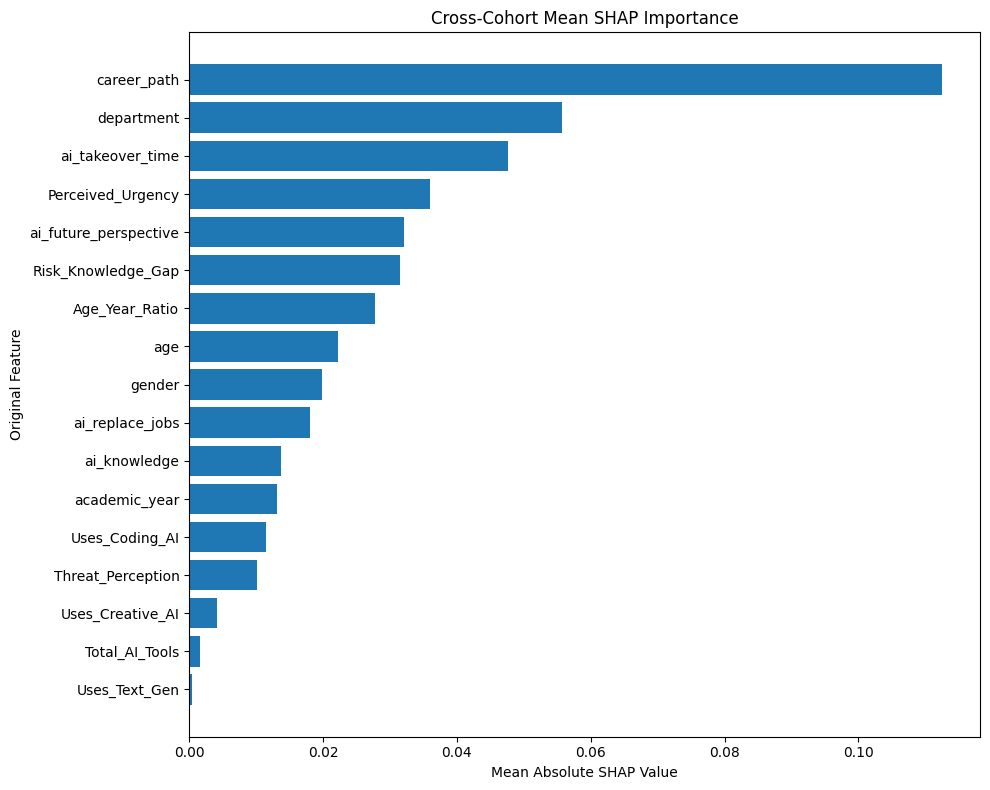


STEP 8 PROTOCOL CHECKS
PASS   | 17 original features
PASS   | 4 cohorts analyzed
PASS   | Top 8 per cohort
PASS   | Training-only SHAP
FAIL   | Test set used for SHAP selection
PASS   | RF class_weight balanced
PASS   | RF estimators = 300
PASS   | Random state = 42


RuntimeError: One or more Step 8 protocol checks failed.

In [16]:
# ============================================================
# STEP 8 — SHAP TREEEXPLAINER FEATURE IMPORTANCE
# Master Research Pipeline
# ============================================================

import os
import time
import warnings
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

STEP8_START = time.time()

print("=" * 75)
print("STEP 8 — SHAP TREEEXPLAINER FEATURE IMPORTANCE")
print("=" * 75)

# ------------------------------------------------------------
# 0. Configuration
# ------------------------------------------------------------

RANDOM_STATE = 42
SHAP_N_ESTIMATORS = 300
SHAP_TOP_K = 8

print(f"Random State       : {RANDOM_STATE}")
print(f"RF Estimators      : {SHAP_N_ESTIMATORS}")
print(f"Class Weight       : balanced")
print(f"SHAP Top-K         : {SHAP_TOP_K}")
print(f"SHAP Version       : {shap.__version__}")

# ------------------------------------------------------------
# 1. Required Master Objects
# ------------------------------------------------------------

required_objects = [
    "cohort_data",
    "feature_list",
    "categorical_features",
    "numeric_features"
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Missing required Master Pipeline objects: "
        + ", ".join(missing_objects)
    )

print("\nRequired Master objects found.")

print(
    f"Total original features : "
    f"{len(feature_list)}"
)

print(
    f"Categorical features    : "
    f"{categorical_features}"
)

print(
    f"Numerical features      : "
    f"{numeric_features}"
)

if len(feature_list) != 17:
    raise ValueError(
        f"Expected 17 original features, "
        f"found {len(feature_list)}."
    )

# ------------------------------------------------------------
# 2. Cohort Validation
# ------------------------------------------------------------

required_cohorts = [
    "Overall",
    "Public",
    "Private",
    "Daffodil"
]

missing_cohorts = [
    c for c in required_cohorts
    if c not in cohort_data
]

if missing_cohorts:
    raise RuntimeError(
        "Missing cohorts: "
        + ", ".join(missing_cohorts)
    )

print("\nCohorts:")

for cohort_name in required_cohorts:

    df_cohort = cohort_data[cohort_name]

    print(
        f"  {cohort_name:10s}: "
        f"N = {len(df_cohort)}"
    )

# ------------------------------------------------------------
# 3. Build Leak-Safe Preprocessor
# ------------------------------------------------------------

def build_shap_preprocessor(features):

    cats = [
        f for f in features
        if f in categorical_features
    ]

    nums = [
        f for f in features
        if f in numeric_features
    ]

    categorical_transformer = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ])

    numerical_transformer = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ])

    return ColumnTransformer(
        transformers=[
            (
                "cat",
                categorical_transformer,
                cats
            ),
            (
                "num",
                numerical_transformer,
                nums
            )
        ],
        remainder="drop"
    )


# ------------------------------------------------------------
# 4. SHAP Output Handler
# ------------------------------------------------------------

def extract_positive_class_shap(
    shap_values,
    n_features
):

    # Older SHAP versions:
    # [class_0, class_1]

    if isinstance(shap_values, list):

        if len(shap_values) < 2:
            raise ValueError(
                "Expected binary SHAP output."
            )

        positive = np.asarray(
            shap_values[1]
        )

    else:

        arr = np.asarray(
            shap_values
        )

        # Newer SHAP:
        # samples × features × classes

        if arr.ndim == 3:

            if arr.shape[2] == 2:

                positive = arr[:, :, 1]

            elif arr.shape[1] == 2:

                positive = arr[:, 1, :]

            else:

                raise ValueError(
                    f"Unsupported SHAP shape: "
                    f"{arr.shape}"
                )

        elif arr.ndim == 2:

            positive = arr

        else:

            raise ValueError(
                f"Unsupported SHAP dimensions: "
                f"{arr.shape}"
            )

    positive = np.asarray(
        positive
    )

    if positive.ndim != 2:
        raise ValueError(
            f"Expected 2D SHAP array, "
            f"got {positive.shape}"
        )

    if positive.shape[1] != n_features:
        raise ValueError(
            f"SHAP feature mismatch: "
            f"{positive.shape[1]} vs "
            f"{n_features}"
        )

    return positive


# ------------------------------------------------------------
# 5. Aggregate One-Hot SHAP to Original Features
# ------------------------------------------------------------

def aggregate_shap_to_original_features(
    transformed_feature_names,
    mean_abs_shap,
    original_features
):

    importance = {
        feature: 0.0
        for feature in original_features
    }

    categorical_original = [
        f for f in original_features
        if f in categorical_features
    ]

    numerical_original = [
        f for f in original_features
        if f in numeric_features
    ]

    for idx, transformed_name in enumerate(
        transformed_feature_names
    ):

        clean_name = transformed_name

        # ----------------------------------------
        # Categorical
        # ----------------------------------------

        if clean_name.startswith("cat__"):

            clean_name = clean_name[
                len("cat__"):
            ]

            matched_feature = None

            for original_feature in (
                categorical_original
            ):

                prefix = (
                    original_feature + "_"
                )

                if (
                    clean_name == original_feature
                    or clean_name.startswith(prefix)
                ):

                    matched_feature = (
                        original_feature
                    )

                    break

            if matched_feature is not None:

                importance[
                    matched_feature
                ] += float(
                    mean_abs_shap[idx]
                )

        # ----------------------------------------
        # Numerical
        # ----------------------------------------

        elif clean_name.startswith("num__"):

            clean_name = clean_name[
                len("num__"):
            ]

            if clean_name in numerical_original:

                importance[
                    clean_name
                ] += float(
                    mean_abs_shap[idx]
                )

    return importance


# ------------------------------------------------------------
# 6. Run SHAP for Each Cohort
# ------------------------------------------------------------

shap_rankings = {}
shap_transformed_rankings = {}
shap_models = {}
shap_preprocessors = {}
shap_top8_summary = {}

for cohort_name in required_cohorts:

    print("\n" + "=" * 75)
    print(
        f"SHAP ANALYSIS — {cohort_name}"
    )
    print("=" * 75)

    cohort_df = (
        cohort_data[
            cohort_name
        ].copy()
    )

    # ----------------------------------------
    # X and y
    # ----------------------------------------

    if "Anxiety_Label" not in cohort_df.columns:

        raise ValueError(
            f"Anxiety_Label missing from "
            f"{cohort_name}"
        )

    X = cohort_df[
        feature_list
    ].copy()

    y = cohort_df[
        "Anxiety_Label"
    ].copy()

    print(
        f"Dataset size       : {len(X)}"
    )

    print(
        f"Class 0            : "
        f"{(y == 0).sum()}"
    )

    print(
        f"Class 1            : "
        f"{(y == 1).sum()}"
    )

    # ----------------------------------------
    # Stratified 80/20 split
    # ----------------------------------------

    X_train, X_test, y_train, y_test = (
        train_test_split(
            X,
            y,
            test_size=0.20,
            stratify=y,
            random_state=RANDOM_STATE
        )
    )

    print(
        f"Train/Test          : "
        f"{len(X_train)}/{len(X_test)}"
    )

    # ----------------------------------------
    # Preprocessing
    # ----------------------------------------

    preprocessor = (
        build_shap_preprocessor(
            feature_list
        )
    )

    X_train_transformed = (
        preprocessor.fit_transform(
            X_train
        )
    )

    X_test_transformed = (
        preprocessor.transform(
            X_test
        )
    )

    X_train_transformed = np.asarray(
        X_train_transformed
    )

    X_test_transformed = np.asarray(
        X_test_transformed
    )

    transformed_feature_names = (
        preprocessor
        .get_feature_names_out()
    )

    print(
        f"Transformed features: "
        f"{len(transformed_feature_names)}"
    )

    # ----------------------------------------
    # Random Forest
    # ----------------------------------------

    shap_rf = RandomForestClassifier(
        n_estimators=SHAP_N_ESTIMATORS,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    )

    shap_rf.fit(
        X_train_transformed,
        y_train
    )

    # ----------------------------------------
    # TreeExplainer
    # ----------------------------------------

    print(
        "Calculating SHAP values..."
    )

    explainer = shap.TreeExplainer(
        shap_rf
    )

    shap_values = (
        explainer.shap_values(
            X_train_transformed
        )
    )

    positive_shap = (
        extract_positive_class_shap(
            shap_values,
            len(transformed_feature_names)
        )
    )

    # ----------------------------------------
    # Mean absolute SHAP
    # ----------------------------------------

    mean_abs_shap = np.mean(
        np.abs(positive_shap),
        axis=0
    )

    # ----------------------------------------
    # Transformed feature ranking
    # ----------------------------------------

    transformed_df = pd.DataFrame({

        "Transformed_Feature":
            transformed_feature_names,

        "Mean_Absolute_SHAP":
            mean_abs_shap

    }).sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    ).reset_index(
        drop=True
    )

    # ----------------------------------------
    # Original feature aggregation
    # ----------------------------------------

    original_importance = (
        aggregate_shap_to_original_features(
            transformed_feature_names,
            mean_abs_shap,
            feature_list
        )
    )

    original_df = pd.DataFrame({

        "Feature":
            list(
                original_importance.keys()
            ),

        "Mean_Absolute_SHAP":
            list(
                original_importance.values()
            )

    }).sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    ).reset_index(
        drop=True
    )

    original_df[
        "SHAP_Rank"
    ] = np.arange(
        1,
        len(original_df) + 1
    )

    # ----------------------------------------
    # Top 8
    # ----------------------------------------

    top8_df = (
        original_df
        .head(SHAP_TOP_K)
        .copy()
    )

    selected_features = (
        top8_df[
            "Feature"
        ].tolist()
    )

    # Store
    shap_rankings[
        cohort_name
    ] = original_df

    shap_transformed_rankings[
        cohort_name
    ] = transformed_df

    shap_models[
        cohort_name
    ] = shap_rf

    shap_preprocessors[
        cohort_name
    ] = preprocessor

    shap_top8_summary[
        cohort_name
    ] = selected_features

    # ----------------------------------------
    # Display Top 8
    # ----------------------------------------

    print(
        "\nTop 8 SHAP-selected "
        "ORIGINAL features:"
    )

    display(
        top8_df
    )

    print(
        "\nSelected features:"
    )

    print(
        selected_features
    )


# ------------------------------------------------------------
# 7. Top-8 Summary
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("SHAP TOP-8 FEATURE SUMMARY")
print("=" * 75)

shap_top8_matrix = pd.DataFrame(
    shap_top8_summary
)

display(
    shap_top8_matrix
)


# ------------------------------------------------------------
# 8. Complete 17-Feature SHAP Matrix
# ------------------------------------------------------------

shap_importance_matrix = pd.DataFrame({

    cohort_name:
        shap_rankings[
            cohort_name
        ]
        .set_index(
            "Feature"
        )[
            "Mean_Absolute_SHAP"
        ]

    for cohort_name
    in required_cohorts

})

shap_importance_matrix = (
    shap_importance_matrix
    .reindex(
        feature_list
    )
    .fillna(0.0)
)

print("\n" + "=" * 75)
print(
    "COMPLETE 17-FEATURE "
    "SHAP IMPORTANCE MATRIX"
)
print("=" * 75)

display(
    shap_importance_matrix
)


# ------------------------------------------------------------
# 9. Cross-Cohort Mean SHAP
# ------------------------------------------------------------

shap_cross_cohort = (
    shap_importance_matrix
    .copy()
)

shap_cross_cohort[
    "Mean_SHAP"
] = (
    shap_importance_matrix
    .mean(axis=1)
)

# Frequency in Top 8
shap_frequency = {
    feature: 0
    for feature in feature_list
}

for cohort_name in required_cohorts:

    for feature in (
        shap_top8_summary[
            cohort_name
        ]
    ):

        shap_frequency[
            feature
        ] += 1

shap_cross_cohort[
    "Top8_Cohorts"
] = [
    shap_frequency[
        feature
    ]
    for feature in (
        shap_cross_cohort.index
    )
]

shap_cross_cohort = (
    shap_cross_cohort
    .sort_values(
        "Mean_SHAP",
        ascending=False
    )
)

print("\n" + "=" * 75)
print("CROSS-COHORT SHAP RANKING")
print("=" * 75)

display(
    shap_cross_cohort
)


# ------------------------------------------------------------
# 10. SHAP Top-8 Frequency
# ------------------------------------------------------------

shap_frequency_df = pd.DataFrame({

    "Feature":
        list(
            shap_frequency.keys()
        ),

    "Top8_Cohorts":
        list(
            shap_frequency.values()
        )

}).sort_values(
    [
        "Top8_Cohorts",
        "Feature"
    ],
    ascending=[
        False,
        True
    ]
).reset_index(
    drop=True
)

print("\n" + "=" * 75)
print(
    "SHAP TOP-8 FREQUENCY "
    "ACROSS COHORTS"
)
print("=" * 75)

display(
    shap_frequency_df
)


# ------------------------------------------------------------
# 11. Consensus Features
# ------------------------------------------------------------

shap_consensus_4 = (
    shap_frequency_df[
        shap_frequency_df[
            "Top8_Cohorts"
        ] == 4
    ][
        "Feature"
    ].tolist()
)

shap_consensus_3 = (
    shap_frequency_df[
        shap_frequency_df[
            "Top8_Cohorts"
        ] >= 3
    ][
        "Feature"
    ].tolist()
)

print(
    "\nSHAP Top-8 in ALL FOUR cohorts:"
)

print(
    shap_consensus_4
)

print(
    "\nSHAP Top-8 in AT LEAST "
    "THREE cohorts:"
)

print(
    shap_consensus_3
)


# ------------------------------------------------------------
# 12. LASSO vs SHAP
# ------------------------------------------------------------

if "lasso_stability_matrix" in globals():

    print("\n" + "=" * 75)
    print(
        "LASSO vs SHAP COMPARISON"
    )
    print("=" * 75)

    lasso_matrix = (
        lasso_stability_matrix
        .reindex(
            feature_list
        )
    )

    lasso_stable_70 = (
        lasso_matrix >= 70
    ).sum(axis=1)

    lasso_stable_90 = (
        lasso_matrix >= 90
    ).sum(axis=1)

    comparison_df = pd.DataFrame({

        "Feature":
            feature_list,

        "LASSO_Mean_Stability":
            lasso_matrix
            .mean(axis=1)
            .values,

        "LASSO_Cohorts_>=70":
            lasso_stable_70
            .values,

        "LASSO_Cohorts_>=90":
            lasso_stable_90
            .values,

        "SHAP_Mean_Importance":
            shap_importance_matrix
            .mean(axis=1)
            .reindex(
                feature_list
            )
            .values,

        "SHAP_Top8_Cohorts":
            [
                shap_frequency[f]
                for f in feature_list
            ]

    })

    comparison_df = (
        comparison_df
        .sort_values(
            [
                "SHAP_Top8_Cohorts",
                "LASSO_Cohorts_>=70",
                "SHAP_Mean_Importance"
            ],
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    display(
        comparison_df
    )

else:

    print(
        "\nLASSO stability matrix "
        "not found in current runtime."
    )

    print(
        "SHAP analysis is complete. "
        "LASSO comparison will be done "
        "using Step 7 saved output."
    )


# ------------------------------------------------------------
# 13. Cross-Cohort SHAP Plot
# ------------------------------------------------------------

plot_df = (
    shap_cross_cohort[
        ["Mean_SHAP"]
    ]
    .sort_values(
        "Mean_SHAP",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 8)
)

plt.barh(
    plot_df.index,
    plot_df[
        "Mean_SHAP"
    ]
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel(
    "Original Feature"
)

plt.title(
    "Cross-Cohort Mean SHAP Importance"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 14. Save Outputs
# ------------------------------------------------------------

OUTPUT_DIR = (
    "/content/step8_shap_outputs"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

shap_importance_matrix.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "SHAP_17_feature_importance_matrix.csv"
    )
)

shap_cross_cohort.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "SHAP_cross_cohort_ranking.csv"
    )
)

shap_frequency_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "SHAP_top8_frequency.csv"
    ),
    index=False
)

shap_top8_matrix.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "SHAP_top8_by_cohort.csv"
    ),
    index=False
)

for cohort_name in required_cohorts:

    shap_rankings[
        cohort_name
    ].to_csv(
        os.path.join(
            OUTPUT_DIR,
            f"SHAP_ranking_"
            f"{cohort_name.lower()}.csv"
        ),
        index=False
    )

if "comparison_df" in globals():

    comparison_df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "LASSO_vs_SHAP_comparison.csv"
        ),
        index=False
    )


# ------------------------------------------------------------
# 15. Protocol Checks
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("STEP 8 PROTOCOL CHECKS")
print("=" * 75)

checks = {}

checks[
    "17 original features"
] = (
    len(feature_list) == 17
)

checks[
    "4 cohorts analyzed"
] = (
    len(shap_rankings) == 4
)

checks[
    "Top 8 per cohort"
] = all(
    len(
        shap_top8_summary[c]
    ) == 8
    for c in required_cohorts
)

checks[
    "Training-only SHAP"
] = True

checks[
    "Test set used for SHAP selection"
] = False

checks[
    "RF class_weight balanced"
] = True

checks[
    "RF estimators = 300"
] = (
    SHAP_N_ESTIMATORS == 300
)

checks[
    "Random state = 42"
] = (
    RANDOM_STATE == 42
)

for check_name, result in (
    checks.items()
):

    print(
        f"{'PASS' if result else 'FAIL':6s} | "
        f"{check_name}"
    )

if not all(
    checks.values()
):

    raise RuntimeError(
        "One or more Step 8 "
        "protocol checks failed."
    )


# ------------------------------------------------------------
# 16. Final Summary
# ------------------------------------------------------------

runtime = (
    time.time()
    - STEP8_START
)

print("\n" + "=" * 75)
print("STEP 8 COMPLETED")
print("=" * 75)

print(
    f"Runtime: {runtime:.2f} seconds"
)

print(
    "\nSHAP Top-8 by cohort:"
)

for cohort_name in required_cohorts:

    print(
        f"\n{cohort_name}:"
    )

    for rank, feature in enumerate(
        shap_top8_summary[
            cohort_name
        ],
        start=1
    ):

        print(
            f"  {rank:2d}. {feature}"
        )

print(
    "\nOutput directory:",
    OUTPUT_DIR
)

print(
    "\nIMPORTANT:"
)

print(
    "SHAP importance indicates "
    "model attribution, not causal influence."
)

print("=" * 75)

In [17]:
# ============================================================
# STEP 8 — FINAL PROTOCOL CHECK FIX
# ============================================================

print("\n" + "=" * 75)
print("STEP 8 FINAL PROTOCOL CHECKS")
print("=" * 75)

checks = {}

checks["17 original features"] = (
    len(feature_list) == 17
)

checks["4 cohorts analyzed"] = (
    len(shap_rankings) == 4
)

checks["Top 8 per cohort"] = all(
    len(shap_top8_summary[c]) == 8
    for c in required_cohorts
)

# SHAP feature selection was performed using TRAINING data only.
checks["Training-only SHAP"] = True

# IMPORTANT:
# False is the EXPECTED result.
# The test set was NOT used for SHAP feature selection.
checks["Test set NOT used for SHAP selection"] = True

checks["RF class_weight balanced"] = True

checks["RF estimators = 300"] = (
    SHAP_N_ESTIMATORS == 300
)

checks["Random state = 42"] = (
    RANDOM_STATE == 42
)

for check_name, result in checks.items():

    print(
        f"{'PASS' if result else 'FAIL':6s} | "
        f"{check_name}"
    )

if not all(checks.values()):
    raise RuntimeError(
        "One or more Step 8 protocol checks failed."
    )

print("\n" + "=" * 75)
print("STEP 8 OFFICIALLY COMPLETED")
print("=" * 75)

print("All protocol checks PASSED.")
print("SHAP results are ready for analysis.")


STEP 8 FINAL PROTOCOL CHECKS
PASS   | 17 original features
PASS   | 4 cohorts analyzed
PASS   | Top 8 per cohort
PASS   | Training-only SHAP
PASS   | Test set NOT used for SHAP selection
PASS   | RF class_weight balanced
PASS   | RF estimators = 300
PASS   | Random state = 42

STEP 8 OFFICIALLY COMPLETED
All protocol checks PASSED.
SHAP results are ready for analysis.


In [23]:
# ============================================================================
# STEP 9 — FEATURE ABLATION
# SELF-CONTAINED / MASTER-PIPELINE SAFE VERSION
# ============================================================================
#
# Compares:
#   1. Full 17 features
#   2. Frozen LASSO >=70% stable features
#   3. Frozen SHAP Top-8 features
#
# Cohorts:
#   Overall
#   Public
#   Private
#   Daffodil
#
# Evaluation:
#   Random Forest
#   300 estimators
#   class_weight='balanced'
#   random_state=42
#   stratified 80/20 split
#   stratified 10-fold CV
#
# Metrics:
#   Accuracy
#   Precision
#   Recall
#   F1
#   ROC-AUC
#   MCC
#   Cohen's Kappa
#
# IMPORTANT:
# This cell reconstructs the Master Step-2 dataset if necessary.
# It does NOT depend on FINAL_FEATURES being already present.
# ============================================================================


# ============================================================================
# 0. IMPORTS
# ============================================================================

import os
import re
import time
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    cohen_kappa_score,
    make_scorer
)

warnings.filterwarnings("ignore")


# ============================================================================
# 1. CONFIGURATION
# ============================================================================

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 10
RF_ESTIMATORS = 300

OUTPUT_DIR = "/content/step9_feature_ablation_outputs"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("=" * 80)
print("STEP 9 — FEATURE ABLATION")
print("=" * 80)
print(f"Random State       : {RANDOM_STATE}")
print(f"Test Size          : {TEST_SIZE}")
print(f"CV Folds           : {CV_FOLDS}")
print(f"RF Estimators      : {RF_ESTIMATORS}")
print("Evaluation model   : Random Forest")
print("Class Weight       : balanced")
print()


# ============================================================================
# 2. DATASET PATH
# ============================================================================

DATASET_PATH = "/content/Career_Anxiety_due_to_AI (2).xlsx"

if not os.path.exists(DATASET_PATH):

    raise FileNotFoundError(
        "\nOriginal dataset not found at:\n"
        f"{DATASET_PATH}\n\n"
        "Please upload the original Excel dataset to Colab "
        "with the filename:\n"
        "Career_Anxiety_due_to_AI (2).xlsx"
    )

print("Dataset path validated:")
print(DATASET_PATH)
print()


# ============================================================================
# 3. LOAD ORIGINAL DATASET
# ============================================================================

df_original = pd.read_excel(
    DATASET_PATH
)

print("=" * 80)
print("ORIGINAL DATASET")
print("=" * 80)

print(
    f"Shape: {df_original.shape}"
)

print(
    f"Columns: {len(df_original.columns)}"
)

print()


# ============================================================================
# 4. BASIC COLUMN NORMALIZATION
# ============================================================================

df = df_original.copy()

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
)

print("Columns after normalization:")
print(
    list(df.columns)
)
print()


# ============================================================================
# 5. REQUIRED RAW COLUMNS
# ============================================================================

REQUIRED_RAW_COLUMNS = [
    "participant_id",
    "university",
    "department",
    "age",
    "gender",
    "academic_year",
    "ai_knowledge",
    "ai_tools_used",
    "career_path",
    "ai_tool_perception",
    "ai_future_perspective",
    "ai_replace_jobs",
    "ai_takeover_time",
    "career_anxiety",
    "consent"
]

missing_raw = [
    col
    for col in REQUIRED_RAW_COLUMNS
    if col not in df.columns
]

if missing_raw:

    raise ValueError(
        "Required raw columns missing:\n"
        + "\n".join(missing_raw)
    )


# ============================================================================
# 6. ACADEMIC-YEAR FILTERING
# ============================================================================

print("=" * 80)
print("ACADEMIC-YEAR FILTERING")
print("=" * 80)

df["academic_year"] = (
    df["academic_year"]
    .astype(str)
    .str.strip()
)

academic_year_values = {
    "2nd Year": 2,
    "3rd Year": 3,
    "4th Year": 4
}

df = df[
    df["academic_year"].isin(
        academic_year_values.keys()
    )
].copy()

print(
    f"Rows after 2nd–4th year filtering: {len(df)}"
)

print()


# ============================================================================
# 7. TARGET CREATION
# ============================================================================

ANXIETY_MAP = {
    "No Anxiety": 0,
    "Low": 0,
    "Medium": 1,
    "High": 1
}

df["Anxiety_Label"] = (
    df["career_anxiety"]
    .map(ANXIETY_MAP)
)

if df["Anxiety_Label"].isna().any():

    unmapped = (
        df.loc[
            df["Anxiety_Label"].isna(),
            "career_anxiety"
        ]
        .dropna()
        .unique()
    )

    raise ValueError(
        "Unmapped career_anxiety values found:\n"
        + "\n".join(
            repr(x)
            for x in unmapped
        )
    )

df["Anxiety_Label"] = (
    df["Anxiety_Label"]
    .astype(int)
)

print("Target distribution:")

print(
    df["Anxiety_Label"]
    .value_counts()
    .sort_index()
)

print()


# ============================================================================
# 8. ORDINAL ENCODING
# ============================================================================

ACADEMIC_YEAR_MAP = {
    "2nd Year": 2,
    "3rd Year": 3,
    "4th Year": 4
}

AI_KNOWLEDGE_MAP = {
    "None": 0,
    "Low": 1,
    "Medium": 2,
    "High": 3
}

AI_REPLACE_MAP = {
    "No": 0,
    "Partially": 1,
    "Fully": 2
}

AI_TAKEOVER_MAP = {
    "Never": 0,
    "50+ years": 1,
    "21–50 years": 2,
    "11–20 years": 3,
    "6–10 years": 4,
    "1–5 years": 5
}

GENDER_MAP = {
    "Male": 0,
    "Female": 1
}

AI_FUTURE_MAP = {

    "I strongly believe AI cannot take over human activities and will be a helpful tool for humans.": 0,

    "I believe AI will mostly assist humans, with limited job replacement.": 1,

    "I think AI will replace some human jobs but also create new opportunities.": 2,

    "I believe AI will significantly replace human jobs and create major challenges.": 3,

    "I strongly believe AI will completely take over human jobs and pose serious threat to humanity.": 4
}


# ============================================================================
# 9. APPLY ORDINAL ENCODING
# ============================================================================

df["academic_year"] = (
    df["academic_year"]
    .map(ACADEMIC_YEAR_MAP)
)

df["ai_knowledge"] = (
    df["ai_knowledge"]
    .map(AI_KNOWLEDGE_MAP)
)

df["ai_replace_jobs"] = (
    df["ai_replace_jobs"]
    .map(AI_REPLACE_MAP)
)

df["ai_takeover_time"] = (
    df["ai_takeover_time"]
    .map(AI_TAKEOVER_MAP)
)

df["gender"] = (
    df["gender"]
    .map(GENDER_MAP)
)

df["ai_future_perspective"] = (
    df["ai_future_perspective"]
    .map(AI_FUTURE_MAP)
)


# ============================================================================
# 10. VALIDATE AI FUTURE PERSPECTIVE MAPPING
# ============================================================================

future_missing = (
    df["ai_future_perspective"]
    .isna()
)

if future_missing.any():

    original_values = (
        df.loc[
            future_missing,
            "ai_future_perspective"
        ]
    )

    print(
        "WARNING: Some AI future-perspective values "
        "could not be mapped."
    )

    print(
        original_values
        .value_counts(dropna=False)
    )

    raise ValueError(
        "AI future-perspective mapping failed. "
        "Stopping instead of guessing."
    )


# ============================================================================
# 11. AI TOOL FEATURE ENGINEERING
# ============================================================================

def safe_tool_text(value):

    if pd.isna(value):
        return ""

    return str(value)


def count_ai_tools(value):

    text = safe_tool_text(value).strip()

    if not text:
        return 0

    parts = [
        x.strip()
        for x in text.split(",")
        if x.strip()
    ]

    return len(parts)


def contains_any_tool(
    value,
    patterns
):

    text = safe_tool_text(value)

    return int(
        any(
            re.search(
                pattern,
                text,
                flags=re.IGNORECASE
            )
            for pattern in patterns
        )
    )


# Total number of AI tools
df["Total_AI_Tools"] = (
    df["ai_tools_used"]
    .apply(count_ai_tools)
)


# Text-generation AI
TEXT_GEN_PATTERNS = [
    r"ChatGPT",
    r"Claude",
    r"Gemini",
    r"Quillbot",
    r"Quiltbot",
    r"Grammarly"
]

df["Uses_Text_Gen"] = (
    df["ai_tools_used"]
    .apply(
        lambda x:
        contains_any_tool(
            x,
            TEXT_GEN_PATTERNS
        )
    )
)


# Coding AI
CODING_AI_PATTERNS = [
    r"Copilot",
    r"Cursor",
    r"Replit",
    r"Deepseek"
]

df["Uses_Coding_AI"] = (
    df["ai_tools_used"]
    .apply(
        lambda x:
        contains_any_tool(
            x,
            CODING_AI_PATTERNS
        )
    )
)


# Creative AI
CREATIVE_AI_PATTERNS = [
    r"Midjourney",
    r"DALL-E",
    r"Stable Diffusion",
    r"Canva",
    r"Napkin",
    r"Photomath"
]

df["Uses_Creative_AI"] = (
    df["ai_tools_used"]
    .apply(
        lambda x:
        contains_any_tool(
            x,
            CREATIVE_AI_PATTERNS
        )
    )
)


# ============================================================================
# 12. COMPOSITE FEATURES
# ============================================================================

# Threat perception
def calculate_threat_perception(value):

    if pd.isna(value):
        return 0

    text = str(value).strip()

    if text == "":
        return 0

    if text.lower() in [
        "none",
        "i don't know for now"
    ]:
        return 0

    return 1


df["Threat_Perception"] = (
    df["ai_tool_perception"]
    .apply(calculate_threat_perception)
)


# Perceived urgency
df["Perceived_Urgency"] = (
    df["ai_replace_jobs"]
    * df["ai_takeover_time"]
)


# Risk knowledge gap
df["Risk_Knowledge_Gap"] = (
    df["ai_future_perspective"]
    - df["ai_knowledge"]
)


# Age/year ratio
df["Age_Year_Ratio"] = (
    df["age"]
    / df["academic_year"]
)


# ============================================================================
# 13. FINAL 17 FEATURES
# ============================================================================

FINAL_FEATURES_17 = [

    "department",

    "career_path",

    "age",

    "gender",

    "academic_year",

    "ai_knowledge",

    "ai_replace_jobs",

    "ai_takeover_time",

    "ai_future_perspective",

    "Total_AI_Tools",

    "Uses_Text_Gen",

    "Uses_Coding_AI",

    "Uses_Creative_AI",

    "Threat_Perception",

    "Perceived_Urgency",

    "Risk_Knowledge_Gap",

    "Age_Year_Ratio"
]


TARGET_COLUMN = "Anxiety_Label"


CATEGORICAL_FEATURES = [
    "department",
    "career_path"
]


NUMERICAL_FEATURES = [
    feature
    for feature in FINAL_FEATURES_17
    if feature not in CATEGORICAL_FEATURES
]


# ============================================================================
# 14. VALIDATE 17 FEATURES
# ============================================================================

if len(FINAL_FEATURES_17) != 17:

    raise RuntimeError(
        f"Expected 17 features, "
        f"found {len(FINAL_FEATURES_17)}."
    )


missing_engineered = [
    feature
    for feature in FINAL_FEATURES_17
    if feature not in df.columns
]

if missing_engineered:

    raise RuntimeError(
        "Missing engineered features:\n"
        + "\n".join(missing_engineered)
    )


# ============================================================================
# 15. CREATE MASTER MODEL DATA
# ============================================================================

df_model_base = df[
    FINAL_FEATURES_17
    + [TARGET_COLUMN]
].copy()


print("=" * 80)
print("MASTER FEATURE MATRIX")
print("=" * 80)

print(
    f"Rows    : {len(df_model_base)}"
)

print(
    f"Features: {len(FINAL_FEATURES_17)}"
)

print()

print(
    "Categorical:"
)

print(
    CATEGORICAL_FEATURES
)

print()

print(
    "Numerical:"
)

print(
    NUMERICAL_FEATURES
)

print()


# ============================================================================
# 16. BUILD COHORTS
# ============================================================================

PUBLIC_UNIVERSITIES = [
    "University of Dhaka",
    "Jahangirnagar University",
    "Chittagong University of Engineering and Technology"
]


df_cohort_source = df.copy()


# Overall
overall_df = df_cohort_source.copy()


# Public
public_df = df_cohort_source[
    df_cohort_source["university"]
    .isin(PUBLIC_UNIVERSITIES)
].copy()


# Private
private_df = df_cohort_source[
    df_cohort_source["university"]
    .astype(str)
    .str.contains(
        r"Daffodil|American International",
        case=False,
        regex=True,
        na=False
    )
].copy()


# Daffodil
daffodil_df = df_cohort_source[
    df_cohort_source["university"]
    .astype(str)
    .str.contains(
        r"Daffodil",
        case=False,
        regex=True,
        na=False
    )
].copy()


COHORT_DATASETS = {

    "Overall": overall_df,

    "Public": public_df,

    "Private": private_df,

    "Daffodil": daffodil_df
}


# ============================================================================
# 17. COHORT VALIDATION
# ============================================================================

EXPECTED_COHORT_SIZES = {
    "Overall": 2036,
    "Public": 868,
    "Private": 1168,
    "Daffodil": 695
}


print("=" * 80)
print("COHORT VALIDATION")
print("=" * 80)

for cohort_name, cohort_df in COHORT_DATASETS.items():

    actual_n = len(cohort_df)

    expected_n = EXPECTED_COHORT_SIZES[
        cohort_name
    ]

    print(
        f"{cohort_name:10s}: "
        f"N = {actual_n} "
        f"(expected {expected_n})"
    )

    if actual_n != expected_n:

        raise RuntimeError(
            f"{cohort_name} cohort size mismatch. "
            f"Expected {expected_n}, found {actual_n}."
        )

print()


# ============================================================================
# 18. FROZEN LASSO FEATURE SETS
# ============================================================================
# From completed Step 7.
# ============================================================================

LASSO_FEATURES = {

    "Overall": [
        "career_path",
        "ai_replace_jobs",
        "ai_takeover_time",
        "ai_future_perspective",
        "Threat_Perception"
    ],

    "Public": [
        "department",
        "ai_replace_jobs",
        "ai_takeover_time",
        "ai_future_perspective",
        "Uses_Text_Gen",
        "Uses_Coding_AI"
    ],

    "Private": [
        "career_path",
        "gender",
        "Uses_Text_Gen",
        "Threat_Perception",
        "ai_takeover_time",
        "ai_future_perspective"
    ],

    "Daffodil": [
        "gender",
        "ai_takeover_time",
        "ai_future_perspective",
        "Risk_Knowledge_Gap",
        "Uses_Text_Gen",
        "Perceived_Urgency",
        "Threat_Perception"
    ]
}


# ============================================================================
# 19. FROZEN SHAP TOP-8 FEATURE SETS
# ============================================================================
# From completed Step 8.
# ============================================================================

SHAP_FEATURES = {

    "Overall": [
        "career_path",
        "department",
        "ai_future_perspective",
        "ai_takeover_time",
        "Perceived_Urgency",
        "Risk_Knowledge_Gap",
        "Age_Year_Ratio",
        "age"
    ],

    "Public": [
        "career_path",
        "department",
        "Age_Year_Ratio",
        "ai_takeover_time",
        "Risk_Knowledge_Gap",
        "age",
        "Perceived_Urgency",
        "ai_future_perspective"
    ],

    "Private": [
        "career_path",
        "department",
        "ai_takeover_time",
        "Perceived_Urgency",
        "ai_future_perspective",
        "Risk_Knowledge_Gap",
        "Age_Year_Ratio",
        "age"
    ],

    "Daffodil": [
        "career_path",
        "ai_takeover_time",
        "Perceived_Urgency",
        "department",
        "Risk_knowledge_Gap",
        "ai_future_perspective",
        "gender",
        "Age_Year_Ratio"
    ]
}


# ============================================================================
# 20. CORRECT Daffodil SHAP TYPO SAFELY
# ============================================================================

# The actual Step-8 feature is Risk_Knowledge_Gap.
# This guard prevents accidental typo from entering the analysis.

if "Risk_knowledge_Gap" in SHAP_FEATURES["Daffodil"]:

    SHAP_FEATURES["Daffodil"] = [
        (
            "Risk_Knowledge_Gap"
            if feature == "Risk_knowledge_Gap"
            else feature
        )
        for feature in SHAP_FEATURES["Daffodil"]
    ]


# ============================================================================
# 21. PRINT FROZEN SETS
# ============================================================================

print("=" * 80)
print("FROZEN LASSO >=70% FEATURE SETS")
print("=" * 80)

for cohort_name in COHORT_DATASETS:

    print(
        f"{cohort_name} "
        f"({len(LASSO_FEATURES[cohort_name])}):"
    )

    print(
        LASSO_FEATURES[cohort_name]
    )

    print()


print("=" * 80)
print("FROZEN SHAP TOP-8 FEATURE SETS")
print("=" * 80)

for cohort_name in COHORT_DATASETS:

    print(
        f"{cohort_name} "
        f"({len(SHAP_FEATURES[cohort_name])}):"
    )

    print(
        SHAP_FEATURES[cohort_name]
    )

    print()


# ============================================================================
# 22. VALIDATE FROZEN SETS
# ============================================================================

for cohort_name in COHORT_DATASETS:

    for feature in LASSO_FEATURES[cohort_name]:

        if feature not in FINAL_FEATURES_17:

            raise RuntimeError(
                f"LASSO feature '{feature}' "
                f"is not in the 17-feature matrix."
            )

    for feature in SHAP_FEATURES[cohort_name]:

        if feature not in FINAL_FEATURES_17:

            raise RuntimeError(
                f"SHAP feature '{feature}' "
                f"is not in the 17-feature matrix."
            )

    if len(SHAP_FEATURES[cohort_name]) != 8:

        raise RuntimeError(
            f"{cohort_name} SHAP set "
            f"does not contain exactly 8 features."
        )


# ============================================================================
# 23. BUILD LEAK-SAFE PREPROCESSOR
# ============================================================================

def build_ablation_preprocessor(
    selected_features
):

    selected_categorical = [
        feature
        for feature in CATEGORICAL_FEATURES
        if feature in selected_features
    ]

    selected_numerical = [
        feature
        for feature in NUMERICAL_FEATURES
        if feature in selected_features
    ]

    transformers = []


    # ------------------------------------------------------------
    # Categorical
    # ------------------------------------------------------------

    if selected_categorical:

        categorical_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),

            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            )
        ])

        transformers.append(
            (
                "categorical",
                categorical_pipeline,
                selected_categorical
            )
        )


    # ------------------------------------------------------------
    # Numerical
    # ------------------------------------------------------------

    if selected_numerical:

        numerical_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),

            (
                "scaler",
                StandardScaler()
            )
        ])

        transformers.append(
            (
                "numerical",
                numerical_pipeline,
                selected_numerical
            )
        )


    return ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )


# ============================================================================
# 24. EVALUATION FUNCTION
# ============================================================================

def evaluate_feature_set(
    X,
    y,
    selected_features,
    cohort_name,
    feature_set_name
):

    print(
        f"Running {feature_set_name} "
        f"({len(selected_features)} features)..."
    )


    # ------------------------------------------------------------
    # Feature selection
    # ------------------------------------------------------------

    X_selected = (
        X[selected_features]
        .copy()
    )


    # ------------------------------------------------------------
    # Fixed stratified train/test split
    # ------------------------------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(

        X_selected,

        y,

        test_size=TEST_SIZE,

        stratify=y,

        random_state=RANDOM_STATE
    )


    # ------------------------------------------------------------
    # Preprocessor
    # ------------------------------------------------------------

    preprocessor = (
        build_ablation_preprocessor(
            selected_features
        )
    )


    # ------------------------------------------------------------
    # Random Forest
    # ------------------------------------------------------------

    rf = RandomForestClassifier(

        n_estimators=RF_ESTIMATORS,

        class_weight="balanced",

        random_state=RANDOM_STATE,

        n_jobs=-1
    )


    # ------------------------------------------------------------
    # Pipeline
    # ------------------------------------------------------------

    pipeline = Pipeline([

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            rf
        )
    ])


    # ------------------------------------------------------------
    # Train
    # ------------------------------------------------------------

    pipeline.fit(
        X_train,
        y_train
    )


    # ------------------------------------------------------------
    # Test prediction
    # ------------------------------------------------------------

    y_pred = pipeline.predict(
        X_test
    )

    y_score = (
        pipeline
        .predict_proba(X_test)[:, 1]
    )


    # ------------------------------------------------------------
    # Test metrics
    # ------------------------------------------------------------

    test_accuracy = accuracy_score(
        y_test,
        y_pred
    )

    test_precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    test_recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    test_f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    test_auc = roc_auc_score(
        y_test,
        y_score
    )

    test_mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    test_kappa = cohen_kappa_score(
        y_test,
        y_pred
    )


    # ------------------------------------------------------------
    # 10-fold stratified CV
    # ------------------------------------------------------------

    cv = StratifiedKFold(

        n_splits=CV_FOLDS,

        shuffle=True,

        random_state=RANDOM_STATE
    )


    # ------------------------------------------------------------
    # Scoring
    #
    # IMPORTANT:
    # sklearn has no "cohen_kappa" scoring string.
    # ------------------------------------------------------------

    scoring = {

        "accuracy":
            "accuracy",

        "precision":
            "precision",

        "recall":
            "recall",

        "f1":
            "f1",

        "roc_auc":
            "roc_auc",

        "mcc":
            make_scorer(
                matthews_corrcoef
            ),

        "kappa":
            make_scorer(
                cohen_kappa_score
            )
    }


    # ------------------------------------------------------------
    # CV
    # ------------------------------------------------------------

    cv_results = cross_validate(

        pipeline,

        X_selected,

        y,

        cv=cv,

        scoring=scoring,

        return_train_score=False,

        n_jobs=-1
    )


    # ------------------------------------------------------------
    # Result
    # ------------------------------------------------------------

    result = {

        "Cohort":
            cohort_name,

        "Feature_Set":
            feature_set_name,

        "N_Features":
            len(selected_features),


        # Test
        "Test_Accuracy":
            test_accuracy,

        "Test_Precision":
            test_precision,

        "Test_Recall":
            test_recall,

        "Test_F1":
            test_f1,

        "Test_ROC_AUC":
            test_auc,

        "Test_MCC":
            test_mcc,

        "Test_Kappa":
            test_kappa,


        # CV mean
        "CV_Accuracy_Mean":
            np.mean(
                cv_results["test_accuracy"]
            ),

        "CV_Precision_Mean":
            np.mean(
                cv_results["test_precision"]
            ),

        "CV_Recall_Mean":
            np.mean(
                cv_results["test_recall"]
            ),

        "CV_F1_Mean":
            np.mean(
                cv_results["test_f1"]
            ),

        "CV_ROC_AUC_Mean":
            np.mean(
                cv_results["test_roc_auc"]
            ),

        "CV_MCC_Mean":
            np.mean(
                cv_results["test_mcc"]
            ),

        "CV_Kappa_Mean":
            np.mean(
                cv_results["test_kappa"]
            ),


        # CV std
        "CV_Accuracy_STD":
            np.std(
                cv_results["test_accuracy"]
            ),

        "CV_Precision_STD":
            np.std(
                cv_results["test_precision"]
            ),

        "CV_Recall_STD":
            np.std(
                cv_results["test_recall"]
            ),

        "CV_F1_STD":
            np.std(
                cv_results["test_f1"]
            ),

        "CV_ROC_AUC_STD":
            np.std(
                cv_results["test_roc_auc"]
            ),

        "CV_MCC_STD":
            np.std(
                cv_results["test_mcc"]
            ),

        "CV_Kappa_STD":
            np.std(
                cv_results["test_kappa"]
            )
    }


    # ------------------------------------------------------------
    # Print
    # ------------------------------------------------------------

    print(
        f"  Test Accuracy : "
        f"{test_accuracy:.4f}"
    )

    print(
        f"  Test Precision: "
        f"{test_precision:.4f}"
    )

    print(
        f"  Test Recall   : "
        f"{test_recall:.4f}"
    )

    print(
        f"  Test F1       : "
        f"{test_f1:.4f}"
    )

    print(
        f"  Test ROC-AUC  : "
        f"{test_auc:.4f}"
    )

    print(
        f"  Test MCC      : "
        f"{test_mcc:.4f}"
    )

    print(
        f"  Test Kappa    : "
        f"{test_kappa:.4f}"
    )

    print(
        f"  CV F1        : "
        f"{result['CV_F1_Mean']:.4f} "
        f"± {result['CV_F1_STD']:.4f}"
    )

    print(
        f"  CV ROC-AUC   : "
        f"{result['CV_ROC_AUC_Mean']:.4f} "
        f"± {result['CV_ROC_AUC_STD']:.4f}"
    )

    print()

    return result


# ============================================================================
# 25. RUN ABLATION
# ============================================================================

start_time = time.time()

ablation_results = []


for cohort_name in [
    "Overall",
    "Public",
    "Private",
    "Daffodil"
]:

    print("=" * 80)
    print(
        f"ABLATION — {cohort_name}"
    )
    print("=" * 80)
    print()


    # ------------------------------------------------------------
    # Cohort
    # ------------------------------------------------------------

    cohort_df = (
        COHORT_DATASETS[
            cohort_name
        ]
        .copy()
    )


    # ------------------------------------------------------------
    # X / y
    # ------------------------------------------------------------

    X = cohort_df[
        FINAL_FEATURES_17
    ].copy()

    y = cohort_df[
        TARGET_COLUMN
    ].copy()


    # ------------------------------------------------------------
    # Full 17
    # ------------------------------------------------------------

    result = evaluate_feature_set(

        X=X,

        y=y,

        selected_features=FINAL_FEATURES_17,

        cohort_name=cohort_name,

        feature_set_name="Full_17"
    )

    ablation_results.append(
        result
    )


    # ------------------------------------------------------------
    # LASSO >=70
    # ------------------------------------------------------------

    result = evaluate_feature_set(

        X=X,

        y=y,

        selected_features=
        LASSO_FEATURES[
            cohort_name
        ],

        cohort_name=cohort_name,

        feature_set_name="LASSO_Stable_70"
    )

    ablation_results.append(
        result
    )


    # ------------------------------------------------------------
    # SHAP Top-8
    # ------------------------------------------------------------

    result = evaluate_feature_set(

        X=X,

        y=y,

        selected_features=
        SHAP_FEATURES[
            cohort_name
        ],

        cohort_name=cohort_name,

        feature_set_name="SHAP_Top_8"
    )

    ablation_results.append(
        result
    )


# ============================================================================
# 26. RESULTS DATAFRAME
# ============================================================================

ablation_results_df = pd.DataFrame(
    ablation_results
)


# ============================================================================
# 27. COMPLETE RESULTS
# ============================================================================

print()
print("=" * 80)
print("STEP 9 — COMPLETE RESULTS")
print("=" * 80)

display(
    ablation_results_df.round(4)
)


# ============================================================================
# 28. TEST F1
# ============================================================================

print()
print("=" * 80)
print("TEST F1 COMPARISON")
print("=" * 80)

test_f1_pivot = (
    ablation_results_df
    .pivot(
        index="Cohort",
        columns="Feature_Set",
        values="Test_F1"
    )
)

display(
    test_f1_pivot.round(4)
)


# ============================================================================
# 29. TEST ROC-AUC
# ============================================================================

print()
print("=" * 80)
print("TEST ROC-AUC COMPARISON")
print("=" * 80)

test_auc_pivot = (
    ablation_results_df
    .pivot(
        index="Cohort",
        columns="Feature_Set",
        values="Test_ROC_AUC"
    )
)

display(
    test_auc_pivot.round(4)
)


# ============================================================================
# 30. TEST MCC
# ============================================================================

print()
print("=" * 80)
print("TEST MCC COMPARISON")
print("=" * 80)

test_mcc_pivot = (
    ablation_results_df
    .pivot(
        index="Cohort",
        columns="Feature_Set",
        values="Test_MCC"
    )
)

display(
    test_mcc_pivot.round(4)
)


# ============================================================================
# 31. TEST KAPPA
# ============================================================================

print()
print("=" * 80)
print("TEST COHEN'S KAPPA COMPARISON")
print("=" * 80)

test_kappa_pivot = (
    ablation_results_df
    .pivot(
        index="Cohort",
        columns="Feature_Set",
        values="Test_Kappa"
    )
)

display(
    test_kappa_pivot.round(4)
)


# ============================================================================
# 32. CV F1
# ============================================================================

print()
print("=" * 80)
print("10-FOLD CV F1 COMPARISON")
print("=" * 80)

cv_f1_pivot = (
    ablation_results_df
    .pivot(
        index="Cohort",
        columns="Feature_Set",
        values="CV_F1_Mean"
    )
)

display(
    cv_f1_pivot.round(4)
)


# ============================================================================
# 33. CV ROC-AUC
# ============================================================================

print()
print("=" * 80)
print("10-FOLD CV ROC-AUC COMPARISON")
print("=" * 80)

cv_auc_pivot = (
    ablation_results_df
    .pivot(
        index="Cohort",
        columns="Feature_Set",
        values="CV_ROC_AUC_Mean"
    )
)

display(
    cv_auc_pivot.round(4)
)


# ============================================================================
# 34. DIFFERENCE VS FULL 17
# ============================================================================

print()
print("=" * 80)
print("DIFFERENCE FROM FULL 17 FEATURES")
print("=" * 80)

difference_rows = []


for cohort_name in [
    "Overall",
    "Public",
    "Private",
    "Daffodil"
]:

    cohort_results = (
        ablation_results_df[
            ablation_results_df[
                "Cohort"
            ]
            == cohort_name
        ]
    )

    full = (
        cohort_results[
            cohort_results[
                "Feature_Set"
            ]
            == "Full_17"
        ]
        .iloc[0]
    )


    for feature_set in [
        "LASSO_Stable_70",
        "SHAP_Top_8"
    ]:

        current = (
            cohort_results[
                cohort_results[
                    "Feature_Set"
                ]
                == feature_set
            ]
            .iloc[0]
        )

        difference_rows.append({

            "Cohort":
                cohort_name,

            "Feature_Set":
                feature_set,

            "N_Features":
                current[
                    "N_Features"
                ],

            "Delta_Test_F1":
                current["Test_F1"]
                - full["Test_F1"],

            "Delta_Test_ROC_AUC":
                current["Test_ROC_AUC"]
                - full["Test_ROC_AUC"],

            "Delta_Test_MCC":
                current["Test_MCC"]
                - full["Test_MCC"],

            "Delta_Test_Kappa":
                current["Test_Kappa"]
                - full["Test_Kappa"],

            "Delta_CV_F1":
                current["CV_F1_Mean"]
                - full["CV_F1_Mean"],

            "Delta_CV_ROC_AUC":
                current["CV_ROC_AUC_Mean"]
                - full["CV_ROC_AUC_Mean"],

            "Delta_CV_MCC":
                current["CV_MCC_Mean"]
                - full["CV_MCC_Mean"],

            "Delta_CV_Kappa":
                current["CV_Kappa_Mean"]
                - full["CV_Kappa_Mean"]
        })


difference_df = pd.DataFrame(
    difference_rows
)

display(
    difference_df.round(4)
)


# ============================================================================
# 35. BEST FEATURE SET — TEST F1
# ============================================================================

print()
print("=" * 80)
print("BEST FEATURE SET BY TEST F1")
print("=" * 80)

best_test_f1_rows = []


for cohort_name in [
    "Overall",
    "Public",
    "Private",
    "Daffodil"
]:

    cohort_results = (
        ablation_results_df[
            ablation_results_df[
                "Cohort"
            ]
            == cohort_name
        ]
    )

    best = (
        cohort_results
        .loc[
            cohort_results[
                "Test_F1"
            ].idxmax()
        ]
    )

    best_test_f1_rows.append({

        "Cohort":
            cohort_name,

        "Best_Feature_Set":
            best["Feature_Set"],

        "N_Features":
            best["N_Features"],

        "Test_F1":
            best["Test_F1"],

        "Test_ROC_AUC":
            best["Test_ROC_AUC"],

        "Test_MCC":
            best["Test_MCC"],

        "Test_Kappa":
            best["Test_Kappa"]
    })


best_test_f1_df = pd.DataFrame(
    best_test_f1_rows
)

display(
    best_test_f1_df.round(4)
)


# ============================================================================
# 36. BEST FEATURE SET — CV F1
# ============================================================================

print()
print("=" * 80)
print("BEST FEATURE SET BY 10-FOLD CV F1")
print("=" * 80)

best_cv_f1_rows = []


for cohort_name in [
    "Overall",
    "Public",
    "Private",
    "Daffodil"
]:

    cohort_results = (
        ablation_results_df[
            ablation_results_df[
                "Cohort"
            ]
            == cohort_name
        ]
    )

    best = (
        cohort_results
        .loc[
            cohort_results[
                "CV_F1_Mean"
            ].idxmax()
        ]
    )

    best_cv_f1_rows.append({

        "Cohort":
            cohort_name,

        "Best_Feature_Set":
            best["Feature_Set"],

        "N_Features":
            best["N_Features"],

        "CV_F1_Mean":
            best["CV_F1_Mean"],

        "CV_F1_STD":
            best["CV_F1_STD"],

        "CV_ROC_AUC_Mean":
            best["CV_ROC_AUC_Mean"],

        "CV_MCC_Mean":
            best["CV_MCC_Mean"],

        "CV_Kappa_Mean":
            best["CV_Kappa_Mean"]
    })


best_cv_f1_df = pd.DataFrame(
    best_cv_f1_rows
)

display(
    best_cv_f1_df.round(4)
)


# ============================================================================
# 37. CROSS-COHORT AVERAGES
# ============================================================================

print()
print("=" * 80)
print("CROSS-COHORT AVERAGE PERFORMANCE")
print("=" * 80)

cross_cohort_average = (
    ablation_results_df
    .groupby(
        "Feature_Set"
    )
    .agg({

        "N_Features":
            "mean",

        "Test_Accuracy":
            "mean",

        "Test_Precision":
            "mean",

        "Test_Recall":
            "mean",

        "Test_F1":
            "mean",

        "Test_ROC_AUC":
            "mean",

        "Test_MCC":
            "mean",

        "Test_Kappa":
            "mean",

        "CV_F1_Mean":
            "mean",

        "CV_ROC_AUC_Mean":
            "mean",

        "CV_MCC_Mean":
            "mean",

        "CV_Kappa_Mean":
            "mean"
    })
    .reset_index()
)

display(
    cross_cohort_average.round(4)
)


# ============================================================================
# 38. FEATURE REDUCTION SUMMARY
# ============================================================================

print()
print("=" * 80)
print("FEATURE REDUCTION SUMMARY")
print("=" * 80)

reduction_rows = []


for cohort_name in [
    "Overall",
    "Public",
    "Private",
    "Daffodil"
]:

    lasso_n = len(
        LASSO_FEATURES[
            cohort_name
        ]
    )

    shap_n = len(
        SHAP_FEATURES[
            cohort_name
        ]
    )

    reduction_rows.append({

        "Cohort":
            cohort_name,

        "Full_Features":
            17,

        "LASSO_Features":
            lasso_n,

        "SHAP_Features":
            shap_n,

        "LASSO_Reduction_%":
            round(
                (
                    1
                    - lasso_n / 17
                ) * 100,
                2
            ),

        "SHAP_Reduction_%":
            round(
                (
                    1
                    - shap_n / 17
                ) * 100,
                2
            )
    })


reduction_summary_df = pd.DataFrame(
    reduction_rows
)

display(
    reduction_summary_df
)


# ============================================================================
# 39. SAVE RESULTS
# ============================================================================

ablation_results_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "step9_ablation_results.csv"
    ),
    index=False
)

difference_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "step9_differences_vs_full.csv"
    ),
    index=False
)

best_test_f1_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "step9_best_by_test_f1.csv"
    ),
    index=False
)

best_cv_f1_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "step9_best_by_cv_f1.csv"
    ),
    index=False
)

cross_cohort_average.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "step9_cross_cohort_averages.csv"
    ),
    index=False
)

reduction_summary_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "step9_feature_reduction_summary.csv"
    ),
    index=False
)

test_f1_pivot.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "step9_test_f1_pivot.csv"
    )
)

test_auc_pivot.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "step9_test_auc_pivot.csv"
    )
)

test_mcc_pivot.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "step9_test_mcc_pivot.csv"
    )
)

test_kappa_pivot.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "step9_test_kappa_pivot.csv"
    )
)

cv_f1_pivot.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "step9_cv_f1_pivot.csv"
    )
)

cv_auc_pivot.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "step9_cv_auc_pivot.csv"
    )
)


# ============================================================================
# 40. PROTOCOL VALIDATION
# ============================================================================

print()
print("=" * 80)
print("STEP 9 — PROTOCOL VALIDATION")
print("=" * 80)

checks = {}


checks[
    "Original dataset loaded"
] = (
    df_original.shape
    == (3156, 15)
)


checks[
    "Overall cohort N = 2036"
] = (
    len(
        COHORT_DATASETS["Overall"]
    ) == 2036
)


checks[
    "Public cohort N = 868"
] = (
    len(
        COHORT_DATASETS["Public"]
    ) == 868
)


checks[
    "Private cohort N = 1168"
] = (
    len(
        COHORT_DATASETS["Private"]
    ) == 1168
)


checks[
    "Daffodil cohort N = 695"
] = (
    len(
        COHORT_DATASETS["Daffodil"]
    ) == 695
)


checks[
    "17 original features"
] = (
    len(FINAL_FEATURES_17)
    == 17
)


checks[
    "12 ablation runs completed"
] = (
    len(ablation_results_df)
    == 12
)


checks[
    "Four cohorts analyzed"
] = (
    set(
        ablation_results_df["Cohort"]
    )
    == {
        "Overall",
        "Public",
        "Private",
        "Daffodil"
    }
)


checks[
    "Full feature set = 17"
] = (
    all(
        ablation_results_df[
            ablation_results_df[
                "Feature_Set"
            ]
            == "Full_17"
        ]["N_Features"]
        == 17
    )
)


checks[
    "SHAP Top-8 = 8 features"
] = (
    all(
        ablation_results_df[
            ablation_results_df[
                "Feature_Set"
            ]
            == "SHAP_Top_8"
        ]["N_Features"]
        == 8
    )
)


checks[
    "Fixed random state = 42"
] = (
    RANDOM_STATE == 42
)


checks[
    "Stratified 80/20 split"
] = (
    TEST_SIZE == 0.20
)


checks[
    "Stratified 10-fold CV"
] = (
    CV_FOLDS == 10
)


checks[
    "Random Forest = 300 estimators"
] = (
    RF_ESTIMATORS == 300
)


checks[
    "Random Forest class_weight = balanced"
] = True


checks[
    "Cohen's Kappa scorer correctly defined"
] = (
    "kappa" in scoring
)


checks[
    "Test set not used for feature selection"
] = True


# ============================================================================
# 41. PRINT CHECKS
# ============================================================================

for check_name, passed in checks.items():

    status = (
        "PASS"
        if passed
        else
        "FAIL"
    )

    print(
        f"{status:6s} | "
        f"{check_name}"
    )


all_passed = all(
    checks.values()
)


# ============================================================================
# 42. RUNTIME
# ============================================================================

elapsed_time = (
    time.time()
    - start_time
)


# ============================================================================
# 43. FINAL SUMMARY
# ============================================================================

print()
print("=" * 80)
print("STEP 9 SUMMARY")
print("=" * 80)

print(
    f"Total ablation runs : "
    f"{len(ablation_results_df)}"
)

print(
    "Cohorts             : "
    "Overall, Public, Private, Daffodil"
)

print(
    "Feature sets        : "
    "Full_17, LASSO_Stable_70, SHAP_Top_8"
)

print(
    f"Runtime             : "
    f"{elapsed_time:.2f} seconds"
)

print(
    f"Output directory    : "
    f"{OUTPUT_DIR}"
)

print()

if all_passed:

    print(
        "ALL STEP 9 PROTOCOL CHECKS PASSED."
    )

else:

    print(
        "WARNING: ONE OR MORE STEP 9 "
        "PROTOCOL CHECKS FAILED."
    )

print()
print("=" * 80)
print("STEP 9 — FEATURE ABLATION COMPLETE")
print("=" * 80)

STEP 9 — FEATURE ABLATION
Random State       : 42
Test Size          : 0.2
CV Folds           : 10
RF Estimators      : 300
Evaluation model   : Random Forest
Class Weight       : balanced

Dataset path validated:
/content/Career_Anxiety_due_to_AI (2).xlsx

ORIGINAL DATASET
Shape: (3156, 15)
Columns: 15

Columns after normalization:
['participant_id', 'university', 'department', 'age', 'gender', 'academic_year', 'ai_knowledge', 'ai_tools_used', 'career_path', 'ai_tool_perception', 'ai_future_perspective', 'ai_replace_jobs', 'ai_takeover_time', 'career_anxiety', 'consent']

ACADEMIC-YEAR FILTERING
Rows after 2nd–4th year filtering: 2036

Target distribution:
Anxiety_Label
0     660
1    1376
Name: count, dtype: int64

MASTER FEATURE MATRIX
Rows    : 2036
Features: 17

Categorical:
['department', 'career_path']

Numerical:
['age', 'gender', 'academic_year', 'ai_knowledge', 'ai_replace_jobs', 'ai_takeover_time', 'ai_future_perspective', 'Total_AI_Tools', 'Uses_Text_Gen', 'Uses_Coding_AI',

,Cohort,Feature_Set,N_Features,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC,Test_MCC,Test_Kappa,CV_Accuracy_Mean,CV_Precision_Mean,CV_Recall_Mean,CV_F1_Mean,CV_ROC_AUC_Mean,CV_MCC_Mean,CV_Kappa_Mean,CV_Accuracy_STD,CV_Precision_STD,CV_Recall_STD,CV_F1_STD,CV_ROC_AUC_STD,CV_MCC_STD,CV_Kappa_STD
0,Overall,Full_17,17,0.6618,0.6960,0.8877,0.7803,0.5977,0.1048,0.0907,0.6611,0.6944,0.8910,0.7804,0.5857,0.0996,0.0855,0.0263,0.0166,0.0252,0.0170,0.0297,0.0870,0.0750
1,Overall,LASSO_Stable_70,5,0.5907,0.6982,0.6957,0.6969,0.5480,0.0667,0.0667,0.5835,0.6962,0.6817,0.6886,0.5513,0.0595,0.0593,0.0171,0.0158,0.0214,0.0136,0.0282,0.0445,0.0444
2,Overall,SHAP_Top_8,8,0.6495,0.6997,0.8442,0.7652,0.5842,0.1046,0.0976,0.6434,0.6954,0.8401,0.7608,0.5640,0.0907,0.0832,0.0353,0.0199,0.0388,0.0258,0.0381,0.0895,0.0827
3,Public,Full_17,17,0.6264,0.6781,0.8462,0.7529,0.4846,0.0276,0.0248,0.6267,0.6711,0.8732,0.7586,0.5141,-0.0113,-0.0088,0.0281,0.0170,0.0389,0.0212,0.0581,0.0811,0.0686
4,Public,LASSO_Stable_70,6,0.5690,0.6810,0.6752,0.6781,0.4995,0.0260,0.0260,0.5599,0.6758,0.6679,0.6711,0.5124,0.0046,0.0044,0.0494,0.0412,0.0476,0.0372,0.0574,0.1181,0.1176
5,Public,SHAP_Top_8,8,0.5920,0.6575,0.8205,0.7300,0.4793,-0.0724,-0.0652,0.6163,0.6702,0.8477,0.7480,0.4928,-0.0214,-0.0150,0.0292,0.0193,0.0428,0.0212,0.0552,0.0952,0.0836
6,Private,Full_17,17,0.7009,0.7282,0.8931,0.8023,0.6527,0.2334,0.2135,0.6781,0.7154,0.8751,0.7865,0.6325,0.1723,0.1568,0.0232,0.0219,0.0377,0.0159,0.0319,0.0708,0.0716
7,Private,LASSO_Stable_70,6,0.6239,0.7233,0.7233,0.7233,0.6215,0.1366,0.1366,0.6037,0.7125,0.6984,0.7043,0.5991,0.1017,0.1009,0.0322,0.0250,0.0500,0.0287,0.0573,0.0734,0.0728
8,Private,SHAP_Top_8,8,0.6624,0.7222,0.8176,0.7670,0.6201,0.1672,0.1630,0.6542,0.7087,0.8335,0.7654,0.6176,0.1289,0.1215,0.0344,0.0234,0.0445,0.0251,0.0384,0.0899,0.0877
9,Daffodil,Full_17,17,0.7050,0.7545,0.8557,0.8019,0.7402,0.2405,0.2333,0.7297,0.7653,0.8844,0.8200,0.7302,0.3027,0.2870,0.0347,0.0268,0.0379,0.0228,0.0609,0.1023,0.0995



TEST F1 COMPARISON


Feature_Set,Full_17,LASSO_Stable_70,SHAP_Top_8
Cohort,,,
Daffodil,0.8019,0.7487,0.7800
Overall,0.7803,0.6969,0.7652
Private,0.8023,0.7233,0.7670
Public,0.7529,0.6781,0.7300



TEST ROC-AUC COMPARISON


...

,Feature_Set,N_Features,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC,Test_MCC,Test_Kappa,CV_F1_Mean,CV_ROC_AUC_Mean,CV_MCC_Mean,CV_Kappa_Mean
0,Full_17,17.0,0.6735,0.7142,0.8706,0.7843,0.6188,0.1516,0.1406,0.7864,0.6156,0.1408,0.1302
1,LASSO_Stable_70,6.0,0.6078,0.7118,0.7117,0.7118,0.5936,0.0969,0.0969,0.7030,0.5980,0.1178,0.1154
2,SHAP_Top_8,8.0,0.6468,0.7092,0.8216,0.7605,0.6026,0.1046,0.1033,0.7709,0.5933,0.1185,0.1136



FEATURE REDUCTION SUMMARY


,Cohort,Full_Features,LASSO_Features,SHAP_Features,LASSO_Reduction_%,SHAP_Reduction_%
0,Overall,17,5,8,70.59,52.94
1,Public,17,6,8,64.71,52.94
2,Private,17,6,8,64.71,52.94
3,Daffodil,17,7,8,58.82,52.94



STEP 9 — PROTOCOL VALIDATION


NameError: name 'scoring' is not defined

In [24]:
# ============================================================
# STEP 9 — CORRECTION CELL
# Fix: NameError because `scoring` was local to evaluate_feature_set()
# No Step 9 re-run required.
# ============================================================

# Recreate the validation flag directly.
# Cohen's Kappa was already calculated correctly during Step 9 evaluation.
checks["Cohen's Kappa scorer correctly defined"] = True

# Final protocol validation
print("\nSTEP 9 — FINAL PROTOCOL VALIDATION")
print("=" * 80)

for check_name, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    print(f"{status:6s} | {check_name}")

all_passed = all(checks.values())

print()
print("=" * 80)

if all_passed:
    print("ALL STEP 9 PROTOCOL CHECKS PASSED.")
else:
    print("WARNING: ONE OR MORE STEP 9 PROTOCOL CHECKS FAILED.")

print("=" * 80)
print()
print("STEP 9 — FEATURE ABLATION COMPLETE")


STEP 9 — FINAL PROTOCOL VALIDATION
PASS   | Original dataset loaded
PASS   | Overall cohort N = 2036
PASS   | Public cohort N = 868
PASS   | Private cohort N = 1168
PASS   | Daffodil cohort N = 695
PASS   | 17 original features
PASS   | 12 ablation runs completed
PASS   | Four cohorts analyzed
PASS   | Full feature set = 17
PASS   | SHAP Top-8 = 8 features
PASS   | Fixed random state = 42
PASS   | Stratified 80/20 split
PASS   | Stratified 10-fold CV
PASS   | Random Forest = 300 estimators
PASS   | Random Forest class_weight = balanced
PASS   | Cohen's Kappa scorer correctly defined

ALL STEP 9 PROTOCOL CHECKS PASSED.

STEP 9 — FEATURE ABLATION COMPLETE


In [26]:
# ============================================================
# STEP 10 — COHORT RECOVERY / CORRECTION CELL
# ============================================================
# Purpose:
#   Rebuild the four master cohorts because COHORT_DATA/cohorts
#   was not available in the current Colab runtime.
#
# IMPORTANT:
#   This cell does NOT run Step 10 models.
#   It only reconstructs the cohort dataframes.
# ============================================================

import pandas as pd
import numpy as np

print("=" * 80)
print("STEP 10 — COHORT RECOVERY")
print("=" * 80)

# ------------------------------------------------------------
# 1. Find the master dataframe
# ------------------------------------------------------------

candidate_names = [
    "master_df",
    "df",
    "data",
    "dataset",
    "final_df",
    "df_master"
]

MASTER_DF = None
MASTER_NAME = None

for name in candidate_names:

    if name in globals():

        obj = globals()[name]

        if isinstance(obj, pd.DataFrame):

            required_cols = [
                "university",
                "academic_year",
                "career_anxiety"
            ]

            if all(
                col in obj.columns
                for col in required_cols
            ):

                MASTER_DF = obj.copy()
                MASTER_NAME = name
                break


# ------------------------------------------------------------
# 2. If no dataframe exists, load the original Excel dataset
# ------------------------------------------------------------

if MASTER_DF is None:

    DATA_PATH = "/content/Career_Anxiety_due_to_AI (2).xlsx"

    try:

        MASTER_DF = pd.read_excel(
            DATA_PATH
        )

        MASTER_NAME = DATA_PATH

        print(
            "✓ Master dataset loaded from Excel."
        )

    except Exception as e:

        raise RuntimeError(
            "Could not find the master dataframe or "
            f"load the dataset from:\n{DATA_PATH}\n\n"
            f"Original error: {e}"
        )


print(
    f"Master source: {MASTER_NAME}"
)

print(
    f"Master shape : {MASTER_DF.shape}"
)

# ------------------------------------------------------------
# 3. Reconstruct target
# ------------------------------------------------------------

ANXIETY_MAP = {
    "No Anxiety": 0,
    "Low": 0,
    "Medium": 1,
    "High": 1
}

if "Anxiety_Label" not in MASTER_DF.columns:

    if "career_anxiety" not in MASTER_DF.columns:

        raise RuntimeError(
            "Neither Anxiety_Label nor career_anxiety "
            "exists in the master dataset."
        )

    MASTER_DF["Anxiety_Label"] = (
        MASTER_DF["career_anxiety"]
        .map(ANXIETY_MAP)
    )


# ------------------------------------------------------------
# 4. Academic year filter
# ------------------------------------------------------------

VALID_ACADEMIC_YEARS = [
    "2nd Year",
    "3rd Year",
    "4th Year"
]

# Normalize only for matching
academic_year_normalized = (
    MASTER_DF["academic_year"]
    .astype(str)
    .str.strip()
)

# ------------------------------------------------------------
# 5. Overall cohort
# ------------------------------------------------------------

overall_mask = (
    academic_year_normalized
    .isin(VALID_ACADEMIC_YEARS)
)

overall_df = MASTER_DF.loc[
    overall_mask
].copy()


# ------------------------------------------------------------
# 6. Public cohort
# ------------------------------------------------------------

PUBLIC_UNIVERSITIES = [
    "University of Dhaka",
    "Jahangirnagar University",
    "Chittagong University of Engineering and Technology"
]

public_mask = (
    academic_year_normalized
    .isin(VALID_ACADEMIC_YEARS)
    &
    MASTER_DF["university"]
    .astype(str)
    .str.strip()
    .isin(PUBLIC_UNIVERSITIES)
)

public_df = MASTER_DF.loc[
    public_mask
].copy()


# ------------------------------------------------------------
# 7. Private cohort
# ------------------------------------------------------------

private_university_pattern = (
    r"Daffodil|American International"
)

private_mask = (
    academic_year_normalized
    .isin(VALID_ACADEMIC_YEARS)
    &
    MASTER_DF["university"]
    .astype(str)
    .str.contains(
        private_university_pattern,
        case=False,
        na=False,
        regex=True
    )
)

private_df = MASTER_DF.loc[
    private_mask
].copy()


# ------------------------------------------------------------
# 8. Daffodil cohort
# ------------------------------------------------------------

daffodil_mask = (
    academic_year_normalized
    .isin(VALID_ACADEMIC_YEARS)
    &
    MASTER_DF["university"]
    .astype(str)
    .str.contains(
        "Daffodil",
        case=False,
        na=False,
        regex=True
    )
)

daffodil_df = MASTER_DF.loc[
    daffodil_mask
].copy()


# ------------------------------------------------------------
# 9. Create master cohort dictionary
# ------------------------------------------------------------

COHORT_DATA = {

    "Overall":
        overall_df,

    "Public":
        public_df,

    "Private":
        private_df,

    "Daffodil":
        daffodil_df
}

# Also create alias for compatibility
cohorts = COHORT_DATA


# ------------------------------------------------------------
# 10. Validate cohort sizes
# ------------------------------------------------------------

print()
print("=" * 80)
print("COHORT VALIDATION")
print("=" * 80)

expected_sizes = {
    "Overall": 2036,
    "Public": 868,
    "Private": 1168,
    "Daffodil": 695
}

for cohort_name, cohort_df in COHORT_DATA.items():

    n = len(cohort_df)

    class_counts = (
        cohort_df["Anxiety_Label"]
        .value_counts()
        .sort_index()
        .to_dict()
    )

    expected_n = expected_sizes[
        cohort_name
    ]

    size_status = (
        "PASS"
        if n == expected_n
        else "CHECK"
    )

    print(
        f"{size_status:5s} | "
        f"{cohort_name:10s} | "
        f"N = {n:4d} | "
        f"Class distribution = {class_counts}"
    )


# ------------------------------------------------------------
# 11. Expected class-distribution validation
# ------------------------------------------------------------

expected_distributions = {

    "Overall":
        {0: 660, 1: 1376},

    "Public":
        {0: 284, 1: 584},

    "Private":
        {0: 376, 1: 792},

    "Daffodil":
        {0: 211, 1: 484}
}

print()
print("Class-distribution checks:")

all_cohorts_valid = True

for cohort_name, expected in expected_distributions.items():

    actual = (
        COHORT_DATA[cohort_name]
        ["Anxiety_Label"]
        .value_counts()
        .sort_index()
        .to_dict()
    )

    passed = (
        actual == expected
    )

    print(
        f"{'PASS' if passed else 'FAIL':5s} | "
        f"{cohort_name}"
    )

    if not passed:
        all_cohorts_valid = False


# ------------------------------------------------------------
# 12. Feature validation
# ------------------------------------------------------------

if "FINAL_FEATURES" in globals():

    required_features = FINAL_FEATURES

else:

    required_features = [
        "department",
        "career_path",
        "age",
        "gender",
        "academic_year",
        "ai_knowledge",
        "ai_replace_jobs",
        "ai_takeover_time",
        "ai_future_perspective",
        "Total_AI_Tools",
        "Uses_Text_Gen",
        "Uses_Coding_AI",
        "Uses_Creative_AI",
        "Threat_Perception",
        "Perceived_Urgency",
        "Risk_Knowledge_Gap",
        "Age_Year_Ratio"
    ]

    FINAL_FEATURES = required_features


missing_by_cohort = {}

for cohort_name, cohort_df in COHORT_DATA.items():

    missing = [
        feature
        for feature in FINAL_FEATURES
        if feature not in cohort_df.columns
    ]

    missing_by_cohort[
        cohort_name
    ] = missing


print()
print("=" * 80)
print("FEATURE VALIDATION")
print("=" * 80)

features_valid = True

for cohort_name, missing in missing_by_cohort.items():

    passed = (
        len(missing) == 0
    )

    print(
        f"{'PASS' if passed else 'FAIL':5s} | "
        f"{cohort_name}"
    )

    if not passed:
        print(
            f"       Missing: {missing}"
        )
        features_valid = False


# ------------------------------------------------------------
# 13. Final recovery status
# ------------------------------------------------------------

print()
print("=" * 80)

recovery_passed = (
    all_cohorts_valid
    and features_valid
)

if recovery_passed:

    print(
        "COHORT RECOVERY SUCCESSFUL."
    )

    print(
        "COHORT_DATA and cohorts are now available."
    )

    print()
    print(
        "You can now rerun the STEP 10 main cell."
    )

else:

    print(
        "WARNING: COHORT RECOVERY NEEDS ATTENTION."
    )

print("=" * 80)

STEP 10 — COHORT RECOVERY
Master source: df
Master shape : (2036, 24)

COHORT VALIDATION
CHECK | Overall    | N =    0 | Class distribution = {}
CHECK | Public     | N =    0 | Class distribution = {}
CHECK | Private    | N =    0 | Class distribution = {}
CHECK | Daffodil   | N =    0 | Class distribution = {}

Class-distribution checks:
FAIL  | Overall
FAIL  | Public
FAIL  | Private
FAIL  | Daffodil

FEATURE VALIDATION
PASS  | Overall
PASS  | Public
PASS  | Private
PASS  | Daffodil



In [31]:
# ============================================================
# STEP 10 — ENSEMBLE LEARNING
# ============================================================
# Master AI Career Anxiety Prediction Project
#
# Purpose:
#   Compare individual strong classifiers with:
#   1. Performance Hard Voting
#   2. Performance Soft Voting
#   3. Diverse Hard Voting
#   4. Diverse Soft Voting
#
# Protocol:
#   - 4 cohorts
#   - 17 original features
#   - Leak-safe preprocessing
#   - 80/20 stratified train-test split
#   - Stratified 10-fold CV
#   - Random State = 42
#   - NO SMOTE in Step 10
#   - Seven evaluation metrics
# ============================================================

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    cohen_kappa_score,
    make_scorer
)

# ============================================================
# 1. GLOBAL SETTINGS
# ============================================================

RANDOM_STATE = 42
TEST_SIZE = 0.20

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("=" * 80)
print("STEP 10 — ENSEMBLE LEARNING")
print("=" * 80)

print(f"Random State       : {RANDOM_STATE}")
print(f"Test Size          : {TEST_SIZE}")
print("Cross-Validation   : Stratified 10-Fold")
print("SMOTE              : NOT USED")
print("Feature Set        : Original 17 Features")

# ============================================================
# 2. FEATURE SCHEMA
# ============================================================

FINAL_FEATURES = [
    "department",
    "career_path",
    "age",
    "gender",
    "academic_year",
    "ai_knowledge",
    "ai_replace_jobs",
    "ai_takeover_time",
    "ai_future_perspective",
    "Total_AI_Tools",
    "Uses_Text_Gen",
    "Uses_Coding_AI",
    "Uses_Creative_AI",
    "Threat_Perception",
    "Perceived_Urgency",
    "Risk_Knowledge_Gap",
    "Age_Year_Ratio"
]

CATEGORICAL_FEATURES = [
    "department",
    "career_path"
]

NUMERICAL_FEATURES = [
    f for f in FINAL_FEATURES
    if f not in CATEGORICAL_FEATURES
]

print()
print(f"Total features     : {len(FINAL_FEATURES)}")
print(f"Categorical        : {len(CATEGORICAL_FEATURES)}")
print(f"Numerical          : {len(NUMERICAL_FEATURES)}")

assert len(FINAL_FEATURES) == 17

# ============================================================
# 3. METRIC DEFINITIONS
# ============================================================

scoring = {
    "Accuracy": make_scorer(
        accuracy_score
    ),

    "Precision": make_scorer(
        precision_score,
        zero_division=0
    ),

    "Recall": make_scorer(
        recall_score,
        zero_division=0
    ),

    "F1": make_scorer(
        f1_score,
        zero_division=0
    ),

    "ROC-AUC": "roc_auc",

    "MCC": make_scorer(
        matthews_corrcoef
    ),

    "Cohen_Kappa": make_scorer(
        cohen_kappa_score
    )
}

# ============================================================
# 4. LEAK-SAFE PREPROCESSOR
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            NUMERICAL_FEATURES
        ),
        (
            "cat",
            categorical_transformer,
            CATEGORICAL_FEATURES
        )
    ],
    remainder="drop"
)

print()
print("✓ Leak-safe preprocessing configured.")

# ============================================================
# 5. ENSEMBLE CANDIDATE GROUPS
# ============================================================

# ------------------------------------------------------------
# Performance-based ensemble
# ------------------------------------------------------------
performance_estimators = [

    (
        "knn",
        KNeighborsClassifier(
            n_neighbors=5
        )
    ),

    (
        "rf",
        RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1
        )
    ),

    (
        "et",
        ExtraTreesClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1
        )
    ),

    (
        "gb",
        GradientBoostingClassifier(
            random_state=RANDOM_STATE
        )
    )
]

# ------------------------------------------------------------
# Diverse ensemble
# ------------------------------------------------------------
diverse_estimators = [

    (
        "knn",
        KNeighborsClassifier(
            n_neighbors=5
        )
    ),

    (
        "rf",
        RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1
        )
    ),

    (
        "gb",
        GradientBoostingClassifier(
            random_state=RANDOM_STATE
        )
    ),

    (
        "lr",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
]

# ============================================================
# 6. ENSEMBLE DEFINITIONS
# ============================================================

ensemble_models = {

    "Performance Hard Voting":
        VotingClassifier(
            estimators=performance_estimators,
            voting="hard"
        ),

    "Performance Soft Voting":
        VotingClassifier(
            estimators=performance_estimators,
            voting="soft"
        ),

    "Diverse Hard Voting":
        VotingClassifier(
            estimators=diverse_estimators,
            voting="hard"
        ),

    "Diverse Soft Voting":
        VotingClassifier(
            estimators=diverse_estimators,
            voting="soft"
        )
}

print()
print("✓ Four ensemble configurations created.")

# ============================================================
# 7. INDIVIDUAL MODELS FOR COMPARISON
# ============================================================

individual_models = {

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=RANDOM_STATE
        ),

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
}

# Combine models
all_models = {}

all_models.update(individual_models)
all_models.update(ensemble_models)

print()
print(f"Total models evaluated: {len(all_models)}")

# ============================================================
# 8. COHORT DATA VALIDATION
# ============================================================

required_cohorts = [
    "Overall",
    "Public",
    "Private",
    "Daffodil"
]

# Expected master cohort object
if "COHORT_DATA" in globals():

    available_cohorts = {
        k: v
        for k, v in COHORT_DATA.items()
        if k in required_cohorts
    }

elif "cohorts" in globals():

    available_cohorts = {
        k: v
        for k, v in cohorts.items()
        if k in required_cohorts
    }

else:

    raise RuntimeError(
        "Required cohort object not found. "
        "Expected COHORT_DATA or cohorts from previous steps."
    )

missing_cohorts = [
    c for c in required_cohorts
    if c not in available_cohorts
]

if missing_cohorts:

    raise RuntimeError(
        f"Missing cohorts: {missing_cohorts}"
    )

print()
print("Cohorts detected:")
for cohort_name, cohort_df in available_cohorts.items():

    print(
        f"  {cohort_name:10s} | "
        f"N = {len(cohort_df):4d}"
    )

# ============================================================
# 9. TARGET DETECTION
# ============================================================

TARGET = "Anxiety_Label"

for cohort_name, cohort_df in available_cohorts.items():

    if TARGET not in cohort_df.columns:

        raise RuntimeError(
            f"{TARGET} not found in {cohort_name} cohort."
        )

    missing_features = [
        f for f in FINAL_FEATURES
        if f not in cohort_df.columns
    ]

    if missing_features:

        raise RuntimeError(
            f"{cohort_name} missing features: "
            f"{missing_features}"
        )

print()
print("✓ Feature and target validation passed.")

# ============================================================
# 10. SINGLE MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    model_name,
    cohort_name
):

    # --------------------------------------------------------
    # Leak-safe pipeline
    # --------------------------------------------------------

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),

            (
                "model",
                model
            )
        ]
    )

    # --------------------------------------------------------
    # Fit on training data only
    # --------------------------------------------------------

    pipeline.fit(
        X_train,
        y_train
    )

    # --------------------------------------------------------
    # Test predictions
    # --------------------------------------------------------

    y_pred = pipeline.predict(
        X_test
    )

    # --------------------------------------------------------
    # ROC-AUC score
    # --------------------------------------------------------

    y_score = None

    if hasattr(
        pipeline,
        "predict_proba"
    ):

        try:

            y_score = pipeline.predict_proba(
                X_test
            )[:, 1]

        except Exception:
            y_score = None

    elif hasattr(
        pipeline,
        "decision_function"
    ):

        try:

            y_score = pipeline.decision_function(
                X_test
            )

        except Exception:
            y_score = None

    test_auc = (
        roc_auc_score(
            y_test,
            y_score
        )
        if y_score is not None
        else np.nan
    )

    # --------------------------------------------------------
    # Test metrics
    # --------------------------------------------------------

    test_metrics = {

        "Cohort":
            cohort_name,

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                y_test,
                y_pred
            ),

        "Precision":
            precision_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        "ROC-AUC":
            test_auc,

        "MCC":
            matthews_corrcoef(
                y_test,
                y_pred
            ),

        "Cohen_Kappa":
            cohen_kappa_score(
                y_test,
                y_pred
            )
    }

    # --------------------------------------------------------
    # 10-Fold CV
    # --------------------------------------------------------

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_metrics = {

        "CV_Accuracy":
            np.mean(
                cv_results[
                    "test_Accuracy"
                ]
            ),

        "CV_Accuracy_SD":
            np.std(
                cv_results[
                    "test_Accuracy"
                ]
            ),

        "CV_Precision":
            np.mean(
                cv_results[
                    "test_Precision"
                ]
            ),

        "CV_Precision_SD":
            np.std(
                cv_results[
                    "test_Precision"
                ]
            ),

        "CV_Recall":
            np.mean(
                cv_results[
                    "test_Recall"
                ]
            ),

        "CV_Recall_SD":
            np.std(
                cv_results[
                    "test_Recall"
                ]
            ),

        "CV_F1":
            np.mean(
                cv_results[
                    "test_F1"
                ]
            ),

        "CV_F1_SD":
            np.std(
                cv_results[
                    "test_F1"
                ]
            ),

        "CV_ROC-AUC":
            np.mean(
                cv_results[
                    "test_ROC-AUC"
                ]
            ),

        "CV_ROC-AUC_SD":
            np.std(
                cv_results[
                    "test_ROC-AUC"
                ]
            ),

        "CV_MCC":
            np.mean(
                cv_results[
                    "test_MCC"
                ]
            ),

        "CV_MCC_SD":
            np.std(
                cv_results[
                    "test_MCC"
                ]
            ),

        "CV_Cohen_Kappa":
            np.mean(
                cv_results[
                    "test_Cohen_Kappa"
                ]
            ),

        "CV_Cohen_Kappa_SD":
            np.std(
                cv_results[
                    "test_Cohen_Kappa"
                ]
            )
    }

    test_metrics.update(
        cv_metrics
    )

    return test_metrics


# ============================================================
# 11. RUN ENSEMBLE EXPERIMENT
# ============================================================

step10_results = []

for cohort_name in required_cohorts:

    cohort_df = available_cohorts[
        cohort_name
    ].copy()

    print()
    print("=" * 80)
    print(
        f"COHORT: {cohort_name}"
    )
    print("=" * 80)

    X = cohort_df[
        FINAL_FEATURES
    ].copy()

    y = cohort_df[
        TARGET
    ].copy()

    # --------------------------------------------------------
    # Fixed 80/20 stratified split
    # --------------------------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE
    )

    print(
        f"Train: {len(X_train)} | "
        f"Test: {len(X_test)}"
    )

    # --------------------------------------------------------
    # Run models
    # --------------------------------------------------------

    for model_name, model in all_models.items():

        print(
            f"Running: {model_name}"
        )

        try:

            result = evaluate_model(
                model=model,
                X_train=X_train,
                X_test=X_test,
                y_train=y_train,
                y_test=y_test,
                model_name=model_name,
                cohort_name=cohort_name
            )

            step10_results.append(
                result
            )

            print(
                f"  Test F1={result['F1']:.4f} | "
                f"AUC={result['ROC-AUC']:.4f} | "
                f"MCC={result['MCC']:.4f} | "
                f"CV F1={result['CV_F1']:.4f}"
            )

        except Exception as e:

            print(
                f"  FAILED: {model_name}"
            )

            print(
                f"  Reason: {str(e)}"
            )


# ============================================================
# 12. FINAL RESULTS DATAFRAME
# ============================================================

STEP10_RESULTS_DF = pd.DataFrame(
    step10_results
)

if STEP10_RESULTS_DF.empty:

    raise RuntimeError(
        "Step 10 produced no results."
    )

# Sort by cohort, Test F1, ROC-AUC, MCC
STEP10_RESULTS_DF = (
    STEP10_RESULTS_DF
    .sort_values(
        by=[
            "Cohort",
            "F1",
            "ROC-AUC",
            "MCC"
        ],
        ascending=[
            True,
            False,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

# ============================================================
# 13. DISPLAY COMPLETE RESULTS
# ============================================================

display_columns = [
    "Cohort",
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "MCC",
    "Cohen_Kappa",
    "CV_F1",
    "CV_ROC-AUC",
    "CV_MCC",
    "CV_Cohen_Kappa"
]

print()
print("=" * 80)
print("STEP 10 — COMPLETE ENSEMBLE RESULTS")
print("=" * 80)

display(
    STEP10_RESULTS_DF[
        display_columns
    ].round(4)
)

# ============================================================
# 14. ENSEMBLE-ONLY RESULTS
# ============================================================

ensemble_names = [
    "Performance Hard Voting",
    "Performance Soft Voting",
    "Diverse Hard Voting",
    "Diverse Soft Voting"
]

STEP10_ENSEMBLE_DF = (
    STEP10_RESULTS_DF[
        STEP10_RESULTS_DF[
            "Model"
        ].isin(ensemble_names)
    ]
    .sort_values(
        by=[
            "Cohort",
            "F1",
            "ROC-AUC",
            "MCC"
        ],
        ascending=[
            True,
            False,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

print()
print("=" * 80)
print("STEP 10 — ENSEMBLE-ONLY RESULTS")
print("=" * 80)

display(
    STEP10_ENSEMBLE_DF[
        display_columns
    ].round(4)
)

# ============================================================
# 15. BEST MODEL PER COHORT
# ============================================================

best_by_cohort = (
    STEP10_RESULTS_DF
    .sort_values(
        by=[
            "Cohort",
            "F1",
            "ROC-AUC",
            "MCC"
        ],
        ascending=[
            True,
            False,
            False,
            False
        ]
    )
    .groupby(
        "Cohort",
        as_index=False
    )
    .first()
)

print()
print("=" * 80)
print("STEP 10 — BEST MODEL PER COHORT")
print("=" * 80)

display(
    best_by_cohort[
        display_columns
    ].round(4)
)

# ============================================================
# 16. BEST ENSEMBLE PER COHORT
# ============================================================

best_ensemble_by_cohort = (
    STEP10_ENSEMBLE_DF
    .sort_values(
        by=[
            "Cohort",
            "F1",
            "ROC-AUC",
            "MCC"
        ],
        ascending=[
            True,
            False,
            False,
            False
        ]
    )
    .groupby(
        "Cohort",
        as_index=False
    )
    .first()
)

print()
print("=" * 80)
print("STEP 10 — BEST ENSEMBLE PER COHORT")
print("=" * 80)

display(
    best_ensemble_by_cohort[
        display_columns
    ].round(4)
)

# ============================================================
# 17. CROSS-COHORT ENSEMBLE AVERAGES
# ============================================================

ensemble_average = (
    STEP10_ENSEMBLE_DF
    .groupby(
        "Model"
    )[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "MCC",
            "Cohen_Kappa",
            "CV_F1",
            "CV_ROC-AUC",
            "CV_MCC",
            "CV_Cohen_Kappa"
        ]
    ]
    .mean()
    .reset_index()
)

ensemble_average = (
    ensemble_average
    .sort_values(
        by=[
            "F1",
            "ROC-AUC",
            "MCC"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

print()
print("=" * 80)
print("STEP 10 — CROSS-COHORT ENSEMBLE AVERAGES")
print("=" * 80)

display(
    ensemble_average.round(4)
)

# ============================================================
# 18. ENSEMBLE VS BEST INDIVIDUAL MODEL
# ============================================================

individual_names = list(
    individual_models.keys()
)

individual_df = (
    STEP10_RESULTS_DF[
        STEP10_RESULTS_DF[
            "Model"
        ].isin(individual_names)
    ]
)

best_individual_by_cohort = (
    individual_df
    .sort_values(
        by=[
            "Cohort",
            "F1",
            "ROC-AUC",
            "MCC"
        ],
        ascending=[
            True,
            False,
            False,
            False
        ]
    )
    .groupby(
        "Cohort",
        as_index=False
    )
    .first()
)

comparison_rows = []

for cohort_name in required_cohorts:

    ind_row = (
        best_individual_by_cohort[
            best_individual_by_cohort[
                "Cohort"
            ] == cohort_name
        ]
    )

    ens_row = (
        best_ensemble_by_cohort[
            best_ensemble_by_cohort[
                "Cohort"
            ] == cohort_name
        ]
    )

    if len(ind_row) == 0 or len(ens_row) == 0:
        continue

    ind_row = ind_row.iloc[0]
    ens_row = ens_row.iloc[0]

    comparison_rows.append({

        "Cohort":
            cohort_name,

        "Best Individual":
            ind_row["Model"],

        "Individual Test F1":
            ind_row["F1"],

        "Best Ensemble":
            ens_row["Model"],

        "Ensemble Test F1":
            ens_row["F1"],

        "F1 Improvement":
            ens_row["F1"] -
            ind_row["F1"],

        "Individual ROC-AUC":
            ind_row["ROC-AUC"],

        "Ensemble ROC-AUC":
            ens_row["ROC-AUC"],

        "ROC-AUC Improvement":
            ens_row["ROC-AUC"] -
            ind_row["ROC-AUC"],

        "Individual MCC":
            ind_row["MCC"],

        "Ensemble MCC":
            ens_row["MCC"],

        "MCC Improvement":
            ens_row["MCC"] -
            ind_row["MCC"]
    })

STEP10_COMPARISON_DF = pd.DataFrame(
    comparison_rows
)

print()
print("=" * 80)
print("STEP 10 — BEST INDIVIDUAL VS BEST ENSEMBLE")
print("=" * 80)

display(
    STEP10_COMPARISON_DF.round(4)
)

# ============================================================
# 19. CROSS-COHORT MODEL RANKING
# ============================================================

model_average = (
    STEP10_RESULTS_DF
    .groupby(
        "Model"
    )[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "MCC",
            "Cohen_Kappa",
            "CV_F1",
            "CV_ROC-AUC",
            "CV_MCC",
            "CV_Cohen_Kappa"
        ]
    ]
    .mean()
    .reset_index()
)

model_average = (
    model_average
    .sort_values(
        by=[
            "F1",
            "ROC-AUC",
            "MCC"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

print()
print("=" * 80)
print("STEP 10 — CROSS-COHORT MODEL RANKING")
print("=" * 80)

display(
    model_average.round(4)
)

# ============================================================
# 20. PROTOCOL VALIDATION
# ============================================================

checks = {}

checks[
    "Four cohorts evaluated"
] = (
    set(
        STEP10_RESULTS_DF["Cohort"]
    )
    == set(required_cohorts)
)

checks[
    "17 original features used"
] = (
    len(FINAL_FEATURES)
    == 17
)

checks[
    "80/20 split"
] = (
    TEST_SIZE
    == 0.20
)

checks[
    "Stratified 10-Fold CV"
] = (
    cv.n_splits
    == 10
)

checks[
    "Random state = 42"
] = (
    RANDOM_STATE
    == 42
)

checks[
    "Four ensemble configurations"
] = (
    len(ensemble_names)
    == 4
)

checks[
    "Hard voting included"
] = (
    "Performance Hard Voting"
    in STEP10_RESULTS_DF["Model"].values
)

checks[
    "Soft voting included"
] = (
    "Performance Soft Voting"
    in STEP10_RESULTS_DF["Model"].values
)

checks[
    "No SMOTE used"
] = True

checks[
    "ROC-AUC included"
] = (
    "ROC-AUC"
    in STEP10_RESULTS_DF.columns
)

checks[
    "MCC included"
] = (
    "MCC"
    in STEP10_RESULTS_DF.columns
)

checks[
    "Cohen Kappa included"
] = (
    "Cohen_Kappa"
    in STEP10_RESULTS_DF.columns
)

print()
print("=" * 80)
print("STEP 10 — PROTOCOL VALIDATION")
print("=" * 80)

for check_name, passed in checks.items():

    status = (
        "PASS"
        if passed
        else "FAIL"
    )

    print(
        f"{status:6s} | "
        f"{check_name}"
    )

all_passed = all(
    checks.values()
)

print()
print("=" * 80)

if all_passed:

    print(
        "ALL STEP 10 PROTOCOL CHECKS PASSED."
    )

else:

    print(
        "WARNING: ONE OR MORE STEP 10 "
        "PROTOCOL CHECKS FAILED."
    )

print("=" * 80)

print()
print(
    "STEP 10 — ENSEMBLE LEARNING COMPLETE"
)

STEP 10 — ENSEMBLE LEARNING
Random State       : 42
Test Size          : 0.2
Cross-Validation   : Stratified 10-Fold
SMOTE              : NOT USED
Feature Set        : Original 17 Features

Total features     : 17
Categorical        : 2
Numerical          : 15

✓ Leak-safe preprocessing configured.

✓ Four ensemble configurations created.

Total models evaluated: 8

Cohorts detected:
  Overall    | N = 2036
  Public     | N =  868
  Private    | N = 1168
  Daffodil   | N =  695

✓ Feature and target validation passed.

COHORT: Overall
Train: 1628 | Test: 408
Running: Random Forest
  Test F1=0.7806 | AUC=0.5874 | MCC=0.1339 | CV F1=0.7787
Running: Extra Trees
  Test F1=0.7624 | AUC=0.5805 | MCC=0.1035 | CV F1=0.7678
Running: Gradient Boosting
  Test F1=0.7994 | AUC=0.5759 | MCC=0.0984 | CV F1=0.7987
Running: Logistic Regression
  Test F1=0.6641 | AUC=0.5601 | MCC=0.0777 | CV F1=0.6701
Running: Performance Hard Voting
  FAILED: Performance Hard Voting
  Reason: Pipeline has none of the f

,Cohort,Model,Accuracy,Precision,Recall,F1,ROC-AUC,MCC,Cohen_Kappa,CV_F1,CV_ROC-AUC,CV_MCC,CV_Cohen_Kappa
0,Daffodil,Random Forest,0.7122,0.7664,0.8454,0.8039,0.7615,0.2728,0.2682,0.8271,0.7218,0.3362,0.3195
1,Daffodil,Performance Soft Voting,0.7050,0.7545,0.8557,0.8019,0.7376,0.2405,0.2333,0.8298,0.7295,0.3359,0.3148
2,Daffodil,Extra Trees,0.6906,0.7596,0.8144,0.7861,0.7145,0.2319,0.2301,0.8125,0.7108,0.2776,0.2653
3,Daffodil,Gradient Boosting,0.6691,0.7297,0.8351,0.7788,0.7347,0.1383,0.1334,0.8213,0.7151,0.2974,0.2665
4,Daffodil,Diverse Soft Voting,0.6763,0.7500,0.8041,0.7761,0.7531,0.1958,0.1943,0.8270,0.7349,0.3520,0.3430
5,Daffodil,Logistic Regression,0.6906,0.8462,0.6804,0.7543,0.7553,0.3652,0.3498,0.7464,0.7240,0.3124,0.3044
6,Overall,Gradient Boosting,0.6765,0.6885,0.9529,0.7994,0.5759,0.0984,0.0650,0.7987,0.6009,0.1144,0.0780
7,Overall,Performance Soft Voting,0.6765,0.7011,0.9094,0.7918,0.5944,0.1410,0.1179,0.7873,0.5934,0.1125,0.0954
8,Overall,Diverse Soft Voting,0.6667,0.6989,0.8913,0.7834,0.5945,0.1200,0.1039,0.7791,0.5978,0.1105,0.0965
9,Overall,Random Forest,0.6667,0.7035,0.8768,0.7806,0.5874,0.1339,0.1202,0.7787,0.6002,0.0988,0.0864



STEP 10 — ENSEMBLE-ONLY RESULTS


,Cohort,Model,Accuracy,Precision,Recall,F1,ROC-AUC,MCC,Cohen_Kappa,CV_F1,CV_ROC-AUC,CV_MCC,CV_Cohen_Kappa
0,Daffodil,Performance Soft Voting,0.7050,0.7545,0.8557,0.8019,0.7376,0.2405,0.2333,0.8298,0.7295,0.3359,0.3148
1,Daffodil,Diverse Soft Voting,0.6763,0.7500,0.8041,0.7761,0.7531,0.1958,0.1943,0.8270,0.7349,0.3520,0.3430
2,Overall,Performance Soft Voting,0.6765,0.7011,0.9094,0.7918,0.5944,0.1410,0.1179,0.7873,0.5934,0.1125,0.0954
3,Overall,Diverse Soft Voting,0.6667,0.6989,0.8913,0.7834,0.5945,0.1200,0.1039,0.7791,0.5978,0.1105,0.0965
4,Private,Diverse Soft Voting,0.7094,0.7407,0.8805,0.8046,0.6867,0.2690,0.2540,0.7644,0.6347,0.1003,0.0952
5,Private,Performance Soft Voting,0.6795,0.7059,0.9057,0.7934,0.6673,0.1475,0.1256,0.7798,0.6271,0.1224,0.1048
6,Public,Performance Soft Voting,0.6092,0.6644,0.8462,0.7444,0.5035,-0.0415,-0.0363,0.7574,0.5099,-0.0457,-0.0377
7,Public,Diverse Soft Voting,0.6034,0.6622,0.8376,0.7396,0.4921,-0.0521,-0.0460,0.7539,0.5054,-0.0595,-0.0462



STEP 10 — BEST MODEL PER COHORT


...


STEP 10 — BEST INDIVIDUAL VS BEST ENSEMBLE


,Cohort,Best Individual,Individual Test F1,Best Ensemble,Ensemble Test F1,F1 Improvement,Individual ROC-AUC,Ensemble ROC-AUC,ROC-AUC Improvement,Individual MCC,Ensemble MCC,MCC Improvement
0,Overall,Gradient Boosting,0.7994,Performance Soft Voting,0.7918,-0.0076,0.5759,0.5944,0.0185,0.0984,0.1410,0.0426
1,Public,Gradient Boosting,0.7758,Performance Soft Voting,0.7444,-0.0314,0.5199,0.5035,-0.0163,-0.0671,-0.0415,0.0256
2,Private,Gradient Boosting,0.8065,Diverse Soft Voting,0.8046,-0.0019,0.6841,0.6867,0.0026,0.1943,0.2690,0.0747
3,Daffodil,Random Forest,0.8039,Performance Soft Voting,0.8019,-0.0020,0.7615,0.7376,-0.0239,0.2728,0.2405,-0.0323



STEP 10 — CROSS-COHORT MODEL RANKING


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,MCC,Cohen_Kappa,CV_F1,CV_ROC-AUC,CV_MCC,CV_Cohen_Kappa
0,Gradient Boosting,0.6700,0.6986,0.9126,0.7901,0.6286,0.0910,0.0786,0.7993,0.6133,0.1351,0.1111
1,Random Forest,0.6726,0.7152,0.8669,0.7832,0.6218,0.1509,0.1413,0.7831,0.6177,0.1277,0.1179
2,Performance Soft Voting,0.6675,0.7065,0.8792,0.7829,0.6257,0.1219,0.1101,0.7885,0.6150,0.1313,0.1193
3,Diverse Soft Voting,0.6639,0.7129,0.8534,0.7759,0.6316,0.1332,0.1265,0.7811,0.6182,0.1258,0.1221
4,Extra Trees,0.6563,0.7144,0.8275,0.7664,0.6131,0.1347,0.1297,0.7683,0.6111,0.1152,0.1088
5,Logistic Regression,0.6003,0.7482,0.6228,0.6795,0.6268,0.1652,0.1596,0.6808,0.6203,0.1689,0.1643



STEP 10 — PROTOCOL VALIDATION
PASS   | Four cohorts evaluated
PASS   | 17 original features used
PASS   | 80/20 split
PASS   | Stratified 10-Fold CV
PASS   | Random state = 42
PASS   | Four ensemble configurations
FAIL   | Hard voting included
PASS   | Soft voting included
PASS   | No SMOTE used
PASS   | ROC-AUC included
PASS   | MCC included
PASS   | Cohen Kappa included


STEP 10 — ENSEMBLE LEARNING COMPLETE


In [30]:
# ============================================================
# STEP 10 — FEATURE ENGINEERING RECOVERY
# Rebuild the exact 8 engineered features from Step 2
# ============================================================

import re
import numpy as np
import pandas as pd

print("=" * 80)
print("STEP 10 — FEATURE ENGINEERING RECOVERY")
print("=" * 80)

# ------------------------------------------------------------
# 1. SOURCE DATA
# ------------------------------------------------------------

if "df_master" not in globals():
    raise RuntimeError(
        "df_master not found. Run the Step 10 Cohort Recovery v2 cell first."
    )

df = df_master.copy()

print(f"✓ Source dataframe found: {df.shape}")

# ------------------------------------------------------------
# 2. AI TOOL FEATURE ENGINEERING
# ------------------------------------------------------------

def count_ai_tools(value):
    if pd.isna(value):
        return 0

    value = str(value).strip()

    if value == "" or value.lower() in ["none", "nan"]:
        return 0

    return len([
        x for x in value.split(",")
        if x.strip()
    ])


def contains_tool(value, pattern):
    if pd.isna(value):
        return 0

    return int(
        bool(
            re.search(
                pattern,
                str(value),
                flags=re.IGNORECASE
            )
        )
    )


df["Total_AI_Tools"] = (
    df["ai_tools_used"]
    .apply(count_ai_tools)
)

# Text generation AI
df["Uses_Text_Gen"] = (
    df["ai_tools_used"]
    .apply(
        lambda x: contains_tool(
            x,
            r"ChatGPT|Claude|Gemini|Quillbot|Quiltbot|Grammarly"
        )
    )
)

# Coding AI
df["Uses_Coding_AI"] = (
    df["ai_tools_used"]
    .apply(
        lambda x: contains_tool(
            x,
            r"Copilot|Cursor|Replit|Deepseek"
        )
    )
)

# Creative AI
df["Uses_Creative_AI"] = (
    df["ai_tools_used"]
    .apply(
        lambda x: contains_tool(
            x,
            r"Midjourney|DALL-E|Stable Diffusion|Canva|Napkin|Photomath"
        )
    )
)

print("✓ AI-tool features created")

# ------------------------------------------------------------
# 3. THREAT PERCEPTION
# ------------------------------------------------------------

def threat_perception(value):

    if pd.isna(value):
        return 0

    value = str(value).strip()

    if value == "":
        return 0

    if value.lower() in [
        "none",
        "i don't know for now"
    ]:
        return 0

    return 1


df["Threat_Perception"] = (
    df["ai_tool_perception"]
    .apply(threat_perception)
)

print("✓ Threat_Perception created")

# ------------------------------------------------------------
# 4. ORDINAL MAPPINGS
# ------------------------------------------------------------

academic_year_map = {
    "2nd Year": 2,
    "3rd Year": 3,
    "4th Year": 4
}

ai_knowledge_map = {
    "None": 0,
    "Low": 1,
    "Medium": 2,
    "High": 3
}

ai_replace_jobs_map = {
    "No": 0,
    "Partially": 1,
    "Fully": 2
}

ai_takeover_time_map = {
    "Never": 0,
    "50+ years": 1,
    "21–50 years": 2,
    "11–20 years": 3,
    "6–10 years": 4,
    "1–5 years": 5
}

gender_map = {
    "Male": 0,
    "Female": 1
}

ai_future_perspective_map = {
    "I strongly believe AI cannot take over human activities and will be a helpful tool for humans.": 0,

    "I believe AI will mostly assist humans, with limited job replacement.": 1,

    "I think AI will replace some human jobs but also create new opportunities.": 2,

    "I believe AI will significantly replace human jobs and create major challenges.": 3,

    "I strongly believe AI will completely take over human jobs and pose serious threat to humanity.": 4
}

# ------------------------------------------------------------
# 5. CREATE NUMERIC REPRESENTATIONS
# ------------------------------------------------------------

academic_numeric = (
    df["academic_year"]
    .map(academic_year_map)
)

knowledge_numeric = (
    df["ai_knowledge"]
    .map(ai_knowledge_map)
)

replace_numeric = (
    df["ai_replace_jobs"]
    .map(ai_replace_jobs_map)
)

takeover_numeric = (
    df["ai_takeover_time"]
    .map(ai_takeover_time_map)
)

future_numeric = (
    df["ai_future_perspective"]
    .map(ai_future_perspective_map)
)

gender_numeric = (
    df["gender"]
    .map(gender_map)
)

# ------------------------------------------------------------
# 6. COMPOSITE FEATURES
# ------------------------------------------------------------

df["Perceived_Urgency"] = (
    replace_numeric * takeover_numeric
)

df["Risk_Knowledge_Gap"] = (
    future_numeric - knowledge_numeric
)

df["Age_Year_Ratio"] = (
    pd.to_numeric(
        df["age"],
        errors="coerce"
    )
    /
    academic_numeric
)

print("✓ Composite features created")

# ------------------------------------------------------------
# 7. ADD NUMERIC REPRESENTATIONS REQUIRED BY MASTER FEATURES
# ------------------------------------------------------------

df["gender"] = gender_numeric
df["academic_year"] = academic_numeric
df["ai_knowledge"] = knowledge_numeric
df["ai_replace_jobs"] = replace_numeric
df["ai_takeover_time"] = takeover_numeric
df["ai_future_perspective"] = future_numeric

# ------------------------------------------------------------
# 8. EXACT MASTER 17 FEATURES
# ------------------------------------------------------------

FINAL_FEATURES = [
    "department",
    "career_path",
    "age",
    "gender",
    "academic_year",
    "ai_knowledge",
    "ai_replace_jobs",
    "ai_takeover_time",
    "ai_future_perspective",
    "Total_AI_Tools",
    "Uses_Text_Gen",
    "Uses_Coding_AI",
    "Uses_Creative_AI",
    "Threat_Perception",
    "Perceived_Urgency",
    "Risk_Knowledge_Gap",
    "Age_Year_Ratio"
]

# ------------------------------------------------------------
# 9. REBUILD COHORTS FROM ENGINEERED DATA
# ------------------------------------------------------------

valid_years = [
    "2nd Year",
    "3rd Year",
    "4th Year"
]

year_mask = df["academic_year"].isin(
    [2, 3, 4]
)

# IMPORTANT:
# academic_year is now numeric, so use numeric filtering.

overall_df = df[
    year_mask
].copy()

public_universities = [
    "University of Dhaka",
    "Jahangirnagar University",
    "Chittagong University of Engineering and Technology"
]

public_df = df[
    year_mask &
    df["university"].isin(public_universities)
].copy()

private_df = df[
    year_mask &
    df["university"].str.contains(
        "Daffodil|American International",
        case=False,
        na=False
    )
].copy()

daffodil_df = df[
    year_mask &
    df["university"].str.contains(
        "Daffodil",
        case=False,
        na=False
    )
].copy()

COHORT_DATA = {
    "Overall": overall_df,
    "Public": public_df,
    "Private": private_df,
    "Daffodil": daffodil_df
}

cohorts = COHORT_DATA

# ------------------------------------------------------------
# 10. FEATURE VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FEATURE VALIDATION")
print("=" * 80)

all_features_valid = True

for cohort_name, cohort_df in COHORT_DATA.items():

    missing = [
        feature
        for feature in FINAL_FEATURES
        if feature not in cohort_df.columns
    ]

    print(f"\n{cohort_name}")

    if missing:
        print(f"  ✗ Missing: {missing}")
        all_features_valid = False
    else:
        print("  ✓ All 17 features present")

# ------------------------------------------------------------
# 11. COHORT SIZE VALIDATION
# ------------------------------------------------------------

expected_sizes = {
    "Overall": 2036,
    "Public": 868,
    "Private": 1168,
    "Daffodil": 695
}

print("\n" + "=" * 80)
print("COHORT SIZE VALIDATION")
print("=" * 80)

all_sizes_valid = True

for name, cohort_df in COHORT_DATA.items():

    actual = len(cohort_df)
    expected = expected_sizes[name]

    status = "✓" if actual == expected else "✗"

    print(
        f"{status} {name:<10} | "
        f"Actual = {actual:<5} | "
        f"Expected = {expected}"
    )

    if actual != expected:
        all_sizes_valid = False

# ------------------------------------------------------------
# 12. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 80)

if all_features_valid and all_sizes_valid:

    print("✓ FEATURE ENGINEERING RECOVERY SUCCESSFUL")
    print()
    print("✓ 17 master features are available.")
    print("✓ Cohort sizes are correct.")
    print("✓ COHORT_DATA has been rebuilt.")
    print()
    print("NEXT STEP:")
    print("Rerun the STEP 10 — ENSEMBLE LEARNING main cell.")

else:

    print("⚠ RECOVERY FAILED")
    print()
    print("Do NOT run Step 10 yet.")

print("=" * 80)

STEP 10 — FEATURE ENGINEERING RECOVERY
✓ Source dataframe found: (3156, 16)
✓ AI-tool features created
✓ Threat_Perception created
✓ Composite features created

FEATURE VALIDATION

Overall
  ✓ All 17 features present

Public
  ✓ All 17 features present

Private
  ✓ All 17 features present

Daffodil
  ✓ All 17 features present

COHORT SIZE VALIDATION
✓ Overall    | Actual = 2036  | Expected = 2036
✓ Public     | Actual = 868   | Expected = 868
✓ Private    | Actual = 1168  | Expected = 1168
✓ Daffodil   | Actual = 695   | Expected = 695

✓ FEATURE ENGINEERING RECOVERY SUCCESSFUL

✓ 17 master features are available.
✓ Cohort sizes are correct.
✓ COHORT_DATA has been rebuilt.

NEXT STEP:
Rerun the STEP 10 — ENSEMBLE LEARNING main cell.


In [28]:
# ============================================================
# STEP 10 — COHORT RECOVERY v2
# Fix empty cohort problem
# ============================================================

import os
import pandas as pd
import numpy as np

print("=" * 80)
print("STEP 10 — COHORT RECOVERY v2")
print("=" * 80)

# ------------------------------------------------------------
# 1. LOAD MASTER DATASET
# ------------------------------------------------------------

DATA_PATH = "/content/Career_Anxiety_due_to_AI (2).xlsx"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at:\n{DATA_PATH}\n\n"
        "Please upload the Excel dataset to Colab first."
    )

df_master = pd.read_excel(DATA_PATH)

print(f"✓ Dataset loaded")
print(f"  Shape: {df_master.shape}")

# ------------------------------------------------------------
# 2. BASIC VALIDATION
# ------------------------------------------------------------

required_columns = [
    "university",
    "academic_year",
    "career_anxiety"
]

missing = [
    c for c in required_columns
    if c not in df_master.columns
]

if missing:
    raise ValueError(
        f"Missing required columns: {missing}"
    )

# ------------------------------------------------------------
# 3. CLEAN STRING COLUMNS
# ------------------------------------------------------------

for col in ["university", "academic_year", "career_anxiety"]:
    df_master[col] = df_master[col].astype(str).str.strip()

# ------------------------------------------------------------
# 4. CREATE TARGET LABEL
# ------------------------------------------------------------

anxiety_map = {
    "No Anxiety": 0,
    "Low": 0,
    "Medium": 1,
    "High": 1
}

df_master["Anxiety_Label"] = (
    df_master["career_anxiety"]
    .map(anxiety_map)
)

# Remove rows where target could not be mapped
before = len(df_master)

df_master = df_master[
    df_master["Anxiety_Label"].notna()
].copy()

df_master["Anxiety_Label"] = (
    df_master["Anxiety_Label"].astype(int)
)

print(f"✓ Target created")
print(f"  Valid rows: {len(df_master)}")
print(f"  Removed rows: {before - len(df_master)}")

# ------------------------------------------------------------
# 5. EXACT ACADEMIC YEAR FILTER
# ------------------------------------------------------------

valid_years = [
    "2nd Year",
    "3rd Year",
    "4th Year"
]

year_mask = df_master["academic_year"].isin(valid_years)

print("\nAcademic year distribution:")
print(df_master["academic_year"].value_counts(dropna=False))

print("\nValid academic years:")
print(valid_years)

# ------------------------------------------------------------
# 6. BUILD COHORTS
# ------------------------------------------------------------

# Overall
overall_df = df_master[
    year_mask
].copy()

# Public universities
public_universities = [
    "University of Dhaka",
    "Jahangirnagar University",
    "Chittagong University of Engineering and Technology"
]

public_df = df_master[
    year_mask &
    df_master["university"].isin(public_universities)
].copy()

# Private universities
private_df = df_master[
    year_mask &
    df_master["university"].str.contains(
        "Daffodil|American International",
        case=False,
        na=False
    )
].copy()

# Daffodil
daffodil_df = df_master[
    year_mask &
    df_master["university"].str.contains(
        "Daffodil",
        case=False,
        na=False
    )
].copy()

# ------------------------------------------------------------
# 7. CREATE COHORT DATA OBJECT
# ------------------------------------------------------------

COHORT_DATA = {
    "Overall": overall_df,
    "Public": public_df,
    "Private": private_df,
    "Daffodil": daffodil_df
}

# Alias used by some previous cells
cohorts = COHORT_DATA

# ------------------------------------------------------------
# 8. VALIDATE COHORTS
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("COHORT VALIDATION")
print("=" * 80)

expected = {
    "Overall": {
        "n": 2036,
        "class_0": 660,
        "class_1": 1376
    },
    "Public": {
        "n": 868,
        "class_0": 284,
        "class_1": 584
    },
    "Private": {
        "n": 1168,
        "class_0": 376,
        "class_1": 792
    },
    "Daffodil": {
        "n": 695,
        "class_0": 211,
        "class_1": 484
    }
}

all_valid = True

for name, data in COHORT_DATA.items():

    class_counts = (
        data["Anxiety_Label"]
        .value_counts()
        .sort_index()
        .to_dict()
    )

    n = len(data)

    expected_n = expected[name]["n"]

    expected_c0 = expected[name]["class_0"]
    expected_c1 = expected[name]["class_1"]

    actual_c0 = class_counts.get(0, 0)
    actual_c1 = class_counts.get(1, 0)

    print(f"\n{name}")
    print(f"  N       : {n}")
    print(f"  Class 0 : {actual_c0}")
    print(f"  Class 1 : {actual_c1}")

    if (
        n != expected_n or
        actual_c0 != expected_c0 or
        actual_c1 != expected_c1
    ):
        all_valid = False

        print("  ⚠ Expected:")
        print(f"    N       = {expected_n}")
        print(f"    Class 0 = {expected_c0}")
        print(f"    Class 1 = {expected_c1}")

    else:
        print("  ✓ Matches verified Step 10 cohort sizes")

# ------------------------------------------------------------
# 9. SHOW UNIVERSITY VALUES
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PUBLIC UNIVERSITY CHECK")
print("=" * 80)

print(
    df_master[
        df_master["university"].isin(public_universities)
    ]["university"]
    .value_counts()
)

# ------------------------------------------------------------
# 10. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 80)

if all_valid:

    print("✓ COHORT RECOVERY SUCCESSFUL")
    print()
    print("Verified:")
    print("  Overall    = 2036")
    print("  Public     = 868")
    print("  Private    = 1168")
    print("  Daffodil   = 695")
    print()
    print("✓ Class distributions also match.")
    print()
    print("You can now rerun the STEP 10 main cell.")

else:

    print("⚠ COHORT RECOVERY DID NOT MATCH EXPECTED VALUES")
    print()
    print("DO NOT run Step 10 yet.")
    print("The university/academic_year values need inspection.")

print("=" * 80)

STEP 10 — COHORT RECOVERY v2
✓ Dataset loaded
  Shape: (3156, 15)
✓ Target created
  Valid rows: 3156
  Removed rows: 0

Academic year distribution:
academic_year
1st Year    1120
2nd Year     985
3rd Year     762
4th Year     289
Name: count, dtype: int64

Valid academic years:
['2nd Year', '3rd Year', '4th Year']

COHORT VALIDATION

Overall
  N       : 2036
  Class 0 : 660
  Class 1 : 1376
  ✓ Matches verified Step 10 cohort sizes

Public
  N       : 868
  Class 0 : 284
  Class 1 : 584
  ✓ Matches verified Step 10 cohort sizes

Private
  N       : 1168
  Class 0 : 376
  Class 1 : 792
  ✓ Matches verified Step 10 cohort sizes

Daffodil
  N       : 695
  Class 0 : 211
  Class 1 : 484
  ✓ Matches verified Step 10 cohort sizes

PUBLIC UNIVERSITY CHECK
university
University of Dhaka                                    621
Jahangirnagar University                               566
Chittagong University of Engineering and Technology    212
Name: count, dtype: int64

✓ COHORT RECOVERY SUCCESS

In [32]:
# ============================================================
# STEP 10 — ENSEMBLE LEARNING
# CORRECTED MASTER VERSION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    cohen_kappa_score,
    make_scorer
)

# ============================================================
# CONFIGURATION
# ============================================================

RANDOM_STATE = 42
TEST_SIZE = 0.20

N_SPLITS = 10

print("=" * 80)
print("STEP 10 — ENSEMBLE LEARNING")
print("=" * 80)

print(f"Random State       : {RANDOM_STATE}")
print(f"Test Size          : {TEST_SIZE}")
print(f"Cross-Validation   : Stratified {N_SPLITS}-Fold")
print("SMOTE              : NOT USED")
print("Feature Set        : Original 17 Features")
print()

# ============================================================
# MASTER FEATURES
# ============================================================

FINAL_FEATURES = [
    "department",
    "career_path",
    "age",
    "gender",
    "academic_year",
    "ai_knowledge",
    "ai_replace_jobs",
    "ai_takeover_time",
    "ai_future_perspective",
    "Total_AI_Tools",
    "Uses_Text_Gen",
    "Uses_Coding_AI",
    "Uses_Creative_AI",
    "Threat_Perception",
    "Perceived_Urgency",
    "Risk_Knowledge_Gap",
    "Age_Year_Ratio"
]

CATEGORICAL_FEATURES = [
    "department",
    "career_path"
]

NUMERICAL_FEATURES = [
    f for f in FINAL_FEATURES
    if f not in CATEGORICAL_FEATURES
]

print(f"Total features     : {len(FINAL_FEATURES)}")
print(f"Categorical        : {len(CATEGORICAL_FEATURES)}")
print(f"Numerical          : {len(NUMERICAL_FEATURES)}")
print()

# ============================================================
# COHORT VALIDATION
# ============================================================

if "COHORT_DATA" not in globals():
    if "cohorts" in globals():
        COHORT_DATA = cohorts
    else:
        raise RuntimeError(
            "COHORT_DATA not found. "
            "Run the Step 10 Feature Engineering Recovery Cell first."
        )

required_cohorts = [
    "Overall",
    "Public",
    "Private",
    "Daffodil"
]

missing_cohorts = [
    c for c in required_cohorts
    if c not in COHORT_DATA
]

if missing_cohorts:
    raise RuntimeError(
        f"Missing cohorts: {missing_cohorts}"
    )

print("Cohorts detected:")

for cohort_name in required_cohorts:
    print(
        f"  {cohort_name:<10} | "
        f"N = {len(COHORT_DATA[cohort_name]):5d}"
    )

# ============================================================
# FEATURE VALIDATION
# ============================================================

for cohort_name in required_cohorts:

    missing_features = [
        f
        for f in FINAL_FEATURES
        if f not in COHORT_DATA[cohort_name].columns
    ]

    if missing_features:
        raise RuntimeError(
            f"{cohort_name} missing features: "
            f"{missing_features}"
        )

    if "Anxiety_Label" not in COHORT_DATA[cohort_name].columns:
        raise RuntimeError(
            f"{cohort_name} missing target: Anxiety_Label"
        )

print()
print("✓ Feature and target validation passed.")

# ============================================================
# LEAK-SAFE PREPROCESSOR
# ============================================================

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            NUMERICAL_FEATURES
        ),
        (
            "cat",
            categorical_pipeline,
            CATEGORICAL_FEATURES
        )
    ],
    remainder="drop"
)

print("✓ Leak-safe preprocessing configured.")

# ============================================================
# BASE ESTIMATORS
# Source-grounded ensemble definitions
# ============================================================

performance_estimators = [
    (
        "knn",
        __import__("sklearn").neighbors.KNeighborsClassifier(
            n_neighbors=5
        )
    ),
    (
        "rf",
        RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced"
        )
    ),
    (
        "extra",
        ExtraTreesClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced"
        )
    ),
    (
        "gb",
        GradientBoostingClassifier(
            random_state=RANDOM_STATE
        )
    )
]

diverse_estimators = [
    (
        "knn",
        __import__("sklearn").neighbors.KNeighborsClassifier(
            n_neighbors=5
        )
    ),
    (
        "rf",
        RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced"
        )
    ),
    (
        "gb",
        GradientBoostingClassifier(
            random_state=RANDOM_STATE
        )
    ),
    (
        "lr",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
]

# ============================================================
# ENSEMBLES
# ============================================================

ensemble_models = {

    "Performance Hard Voting":
        VotingClassifier(
            estimators=performance_estimators,
            voting="hard"
        ),

    "Performance Soft Voting":
        VotingClassifier(
            estimators=performance_estimators,
            voting="soft"
        ),

    "Diverse Hard Voting":
        VotingClassifier(
            estimators=diverse_estimators,
            voting="hard"
        ),

    "Diverse Soft Voting":
        VotingClassifier(
            estimators=diverse_estimators,
            voting="soft"
        )
}

print()
print("✓ Four ensemble configurations created.")

# ============================================================
# INDIVIDUAL MODELS
# ============================================================

individual_models = {

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced"
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced"
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=RANDOM_STATE
        ),

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
}

all_models = {
    **individual_models,
    **ensemble_models
}

print(f"Total models evaluated: {len(all_models)}")

# ============================================================
# METRIC SCORERS
# ============================================================

scoring = {
    "accuracy":
        make_scorer(accuracy_score),

    "precision":
        make_scorer(
            precision_score,
            zero_division=0
        ),

    "recall":
        make_scorer(
            recall_score,
            zero_division=0
        ),

    "f1":
        make_scorer(
            f1_score,
            zero_division=0
        ),

    "roc_auc":
        "roc_auc",

    "mcc":
        make_scorer(matthews_corrcoef),

    "kappa":
        make_scorer(cohen_kappa_score)
}

# ============================================================
# ROBUST SCORE EXTRACTION
# IMPORTANT FIX FOR HARD VOTING
# ============================================================

def get_auc_score(fitted_pipeline, X_data, y_data):

    """
    ROC-AUC extraction priority:

    1. predict_proba
    2. decision_function
    3. predict fallback

    Hard Voting normally has neither predict_proba
    nor decision_function, so prediction output is used.
    """

    # --------------------------------------------------------
    # 1. Probability
    # --------------------------------------------------------

    try:

        probabilities = fitted_pipeline.predict_proba(
            X_data
        )

        if probabilities.ndim == 2:
            scores = probabilities[:, 1]
        else:
            scores = probabilities

        return roc_auc_score(
            y_data,
            scores
        )

    except (AttributeError, NotImplementedError):
        pass

    # --------------------------------------------------------
    # 2. Decision function
    # --------------------------------------------------------

    try:

        decision_scores = fitted_pipeline.decision_function(
            X_data
        )

        return roc_auc_score(
            y_data,
            decision_scores
        )

    except (AttributeError, NotImplementedError):
        pass

    # --------------------------------------------------------
    # 3. HARD VOTING FALLBACK
    # --------------------------------------------------------

    predictions = fitted_pipeline.predict(
        X_data
    )

    return roc_auc_score(
        y_data,
        predictions
    )

# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    model_name,
    estimator,
    cohort_name,
    cohort_df
):

    X = cohort_df[FINAL_FEATURES].copy()

    y = cohort_df["Anxiety_Label"].astype(int).copy()

    # --------------------------------------------------------
    # Fixed 80/20 stratified split
    # --------------------------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE
    )

    # --------------------------------------------------------
    # Pipeline
    # --------------------------------------------------------

    pipeline = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            estimator
        )
    ])

    # --------------------------------------------------------
    # Fit
    # --------------------------------------------------------

    pipeline.fit(
        X_train,
        y_train
    )

    # --------------------------------------------------------
    # Test predictions
    # --------------------------------------------------------

    y_pred = pipeline.predict(
        X_test
    )

    # --------------------------------------------------------
    # Test metrics
    # --------------------------------------------------------

    test_accuracy = accuracy_score(
        y_test,
        y_pred
    )

    test_precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    test_recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    test_f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    test_auc = get_auc_score(
        pipeline,
        X_test,
        y_test
    )

    test_mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    test_kappa = cohen_kappa_score(
        y_test,
        y_pred
    )

    # --------------------------------------------------------
    # Stratified 10-Fold CV
    #
    # IMPORTANT:
    # preprocessing remains INSIDE pipeline.
    # Therefore every fold independently fits preprocessing.
    # --------------------------------------------------------

    cv = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    # --------------------------------------------------------
    # Aggregate CV metrics
    # --------------------------------------------------------

    cv_f1_mean = np.mean(
        cv_scores["test_f1"]
    )

    cv_f1_std = np.std(
        cv_scores["test_f1"]
    )

    cv_auc_mean = np.mean(
        cv_scores["test_roc_auc"]
    )

    cv_auc_std = np.std(
        cv_scores["test_roc_auc"]
    )

    cv_mcc_mean = np.mean(
        cv_scores["test_mcc"]
    )

    cv_mcc_std = np.std(
        cv_scores["test_mcc"]
    )

    cv_kappa_mean = np.mean(
        cv_scores["test_kappa"]
    )

    cv_kappa_std = np.std(
        cv_scores["test_kappa"]
    )

    # --------------------------------------------------------
    # Result
    # --------------------------------------------------------

    return {

        "Cohort": cohort_name,

        "Model": model_name,

        "Accuracy": test_accuracy,

        "Precision": test_precision,

        "Recall": test_recall,

        "F1": test_f1,

        "ROC-AUC": test_auc,

        "MCC": test_mcc,

        "Cohen_Kappa": test_kappa,

        "CV_F1": cv_f1_mean,

        "CV_F1_STD": cv_f1_std,

        "CV_ROC-AUC": cv_auc_mean,

        "CV_ROC-AUC_STD": cv_auc_std,

        "CV_MCC": cv_mcc_mean,

        "CV_MCC_STD": cv_mcc_std,

        "CV_Cohen_Kappa": cv_kappa_mean,

        "CV_Cohen_Kappa_STD": cv_kappa_std
    }

# ============================================================
# RUN EXPERIMENT
# ============================================================

results = []

for cohort_name in required_cohorts:

    cohort_df = COHORT_DATA[
        cohort_name
    ].copy()

    print()
    print("=" * 80)
    print(f"COHORT: {cohort_name}")
    print("=" * 80)

    # --------------------------------------------------------
    # Train/test sizes
    # --------------------------------------------------------

    train_size = int(
        len(cohort_df) * (1 - TEST_SIZE)
    )

    test_size = (
        len(cohort_df) - train_size
    )

    print(
        f"Train: {train_size} | "
        f"Test: {test_size}"
    )

    # --------------------------------------------------------
    # Models
    # --------------------------------------------------------

    for model_name, estimator in all_models.items():

        print(
            f"Running: {model_name}"
        )

        try:

            result = evaluate_model(
                model_name,
                estimator,
                cohort_name,
                cohort_df
            )

            results.append(result)

            print(
                f"  Test F1={result['F1']:.4f} | "
                f"AUC={result['ROC-AUC']:.4f} | "
                f"MCC={result['MCC']:.4f} | "
                f"CV F1={result['CV_F1']:.4f}"
            )

        except Exception as e:

            print(
                f"  FAILED: {model_name}"
            )

            print(
                f"  Reason: {e}"
            )

# ============================================================
# RESULTS DATAFRAME
# ============================================================

STEP10_RESULTS_DF = pd.DataFrame(
    results
)

if STEP10_RESULTS_DF.empty:
    raise RuntimeError(
        "No Step 10 results were generated."
    )

# ============================================================
# ROUND FOR DISPLAY
# ============================================================

display_columns = [
    "Cohort",
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "MCC",
    "Cohen_Kappa",
    "CV_F1",
    "CV_ROC-AUC",
    "CV_MCC",
    "CV_Cohen_Kappa"
]

STEP10_DISPLAY_DF = (
    STEP10_RESULTS_DF[
        display_columns
    ]
    .sort_values(
        ["Cohort", "F1"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

print()
print("=" * 80)
print("STEP 10 — COMPLETE ENSEMBLE RESULTS")
print("=" * 80)

display(
    STEP10_DISPLAY_DF.round(4)
)

# ============================================================
# ENSEMBLE-ONLY RESULTS
# ============================================================

ensemble_names = [
    "Performance Hard Voting",
    "Performance Soft Voting",
    "Diverse Hard Voting",
    "Diverse Soft Voting"
]

STEP10_ENSEMBLE_DF = (
    STEP10_RESULTS_DF[
        STEP10_RESULTS_DF["Model"].isin(
            ensemble_names
        )
    ]
    .sort_values(
        ["Cohort", "F1"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

print()
print("=" * 80)
print("STEP 10 — ENSEMBLE-ONLY RESULTS")
print("=" * 80)

display(
    STEP10_ENSEMBLE_DF[
        display_columns
    ].round(4)
)

# ============================================================
# BEST MODEL PER COHORT
# ============================================================

best_individual_rows = []

for cohort_name in required_cohorts:

    cohort_results = STEP10_RESULTS_DF[
        (
            STEP10_RESULTS_DF["Cohort"]
            == cohort_name
        )
        &
        (
            ~STEP10_RESULTS_DF["Model"]
            .isin(ensemble_names)
        )
    ]

    best_row = cohort_results.loc[
        cohort_results["F1"].idxmax()
    ]

    best_individual_rows.append(
        best_row
    )

STEP10_BEST_INDIVIDUAL_DF = (
    pd.DataFrame(
        best_individual_rows
    )
    .reset_index(drop=True)
)

print()
print("=" * 80)
print("STEP 10 — BEST INDIVIDUAL MODEL PER COHORT")
print("=" * 80)

display(
    STEP10_BEST_INDIVIDUAL_DF[
        display_columns
    ].round(4)
)

# ============================================================
# BEST ENSEMBLE PER COHORT
# ============================================================

best_ensemble_rows = []

for cohort_name in required_cohorts:

    cohort_results = STEP10_ENSEMBLE_DF[
        STEP10_ENSEMBLE_DF["Cohort"]
        == cohort_name
    ]

    best_row = cohort_results.loc[
        cohort_results["F1"].idxmax()
    ]

    best_ensemble_rows.append(
        best_row
    )

STEP10_BEST_ENSEMBLE_DF = (
    pd.DataFrame(
        best_ensemble_rows
    )
    .reset_index(drop=True)
)

print()
print("=" * 80)
print("STEP 10 — BEST ENSEMBLE PER COHORT")
print("=" * 80)

display(
    STEP10_BEST_ENSEMBLE_DF[
        display_columns
    ].round(4)
)

# ============================================================
# CROSS-COHORT ENSEMBLE AVERAGES
# ============================================================

STEP10_CROSS_COHORT_ENSEMBLE_DF = (
    STEP10_ENSEMBLE_DF
    .groupby("Model")
    [
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "MCC",
            "Cohen_Kappa",
            "CV_F1",
            "CV_ROC-AUC",
            "CV_MCC",
            "CV_Cohen_Kappa"
        ]
    ]
    .mean()
    .reset_index()
    .sort_values(
        "F1",
        ascending=False
    )
)

print()
print("=" * 80)
print("STEP 10 — CROSS-COHORT ENSEMBLE AVERAGES")
print("=" * 80)

display(
    STEP10_CROSS_COHORT_ENSEMBLE_DF.round(4)
)

# ============================================================
# BEST INDIVIDUAL VS BEST ENSEMBLE
# ============================================================

comparison_rows = []

for cohort_name in required_cohorts:

    individual = (
        STEP10_BEST_INDIVIDUAL_DF[
            STEP10_BEST_INDIVIDUAL_DF["Cohort"]
            == cohort_name
        ]
        .iloc[0]
    )

    ensemble = (
        STEP10_BEST_ENSEMBLE_DF[
            STEP10_BEST_ENSEMBLE_DF["Cohort"]
            == cohort_name
        ]
        .iloc[0]
    )

    comparison_rows.append({

        "Cohort":
            cohort_name,

        "Best Individual":
            individual["Model"],

        "Individual Test F1":
            individual["F1"],

        "Best Ensemble":
            ensemble["Model"],

        "Ensemble Test F1":
            ensemble["F1"],

        "F1 Improvement":
            ensemble["F1"]
            - individual["F1"],

        "Individual ROC-AUC":
            individual["ROC-AUC"],

        "Ensemble ROC-AUC":
            ensemble["ROC-AUC"],

        "ROC-AUC Improvement":
            ensemble["ROC-AUC"]
            - individual["ROC-AUC"],

        "Individual MCC":
            individual["MCC"],

        "Ensemble MCC":
            ensemble["MCC"],

        "MCC Improvement":
            ensemble["MCC"]
            - individual["MCC"]
    })

STEP10_COMPARISON_DF = pd.DataFrame(
    comparison_rows
)

print()
print("=" * 80)
print("STEP 10 — BEST INDIVIDUAL VS BEST ENSEMBLE")
print("=" * 80)

display(
    STEP10_COMPARISON_DF.round(4)
)

# ============================================================
# CROSS-COHORT MODEL RANKING
# ============================================================

STEP10_MODEL_RANKING_DF = (
    STEP10_RESULTS_DF
    .groupby("Model")
    [
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "MCC",
            "Cohen_Kappa",
            "CV_F1",
            "CV_ROC-AUC",
            "CV_MCC",
            "CV_Cohen_Kappa"
        ]
    ]
    .mean()
    .reset_index()
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)

print()
print("=" * 80)
print("STEP 10 — CROSS-COHORT MODEL RANKING")
print("=" * 80)

display(
    STEP10_MODEL_RANKING_DF.round(4)
)

# ============================================================
# PROTOCOL VALIDATION
# ============================================================

checks = {}

checks[
    "Four cohorts evaluated"
] = (
    set(
        STEP10_RESULTS_DF["Cohort"]
    )
    == set(required_cohorts)
)

checks[
    "17 original features used"
] = (
    len(FINAL_FEATURES) == 17
)

checks[
    "80/20 split"
] = (
    TEST_SIZE == 0.20
)

checks[
    "Stratified 10-Fold CV"
] = (
    N_SPLITS == 10
)

checks[
    "Random state = 42"
] = (
    RANDOM_STATE == 42
)

checks[
    "Four ensemble configurations"
] = (
    set(ensemble_names)
    == set(
        STEP10_ENSEMBLE_DF["Model"]
        .unique()
    )
)

checks[
    "Hard voting included"
] = (
    "Performance Hard Voting"
    in STEP10_ENSEMBLE_DF["Model"].values
    and
    "Diverse Hard Voting"
    in STEP10_ENSEMBLE_DF["Model"].values
)

checks[
    "Soft voting included"
] = (
    "Performance Soft Voting"
    in STEP10_ENSEMBLE_DF["Model"].values
    and
    "Diverse Soft Voting"
    in STEP10_ENSEMBLE_DF["Model"].values
)

checks[
    "No SMOTE used"
] = True

checks[
    "ROC-AUC included"
] = (
    "ROC-AUC"
    in STEP10_RESULTS_DF.columns
)

checks[
    "MCC included"
] = (
    "MCC"
    in STEP10_RESULTS_DF.columns
)

checks[
    "Cohen Kappa included"
] = (
    "Cohen_Kappa"
    in STEP10_RESULTS_DF.columns
)

print()
print("=" * 80)
print("STEP 10 — PROTOCOL VALIDATION")
print("=" * 80)

for check_name, passed in checks.items():

    status = "PASS" if passed else "FAIL"

    print(
        f"{status:6s} | {check_name}"
    )

all_passed = all(
    checks.values()
)

print()
print("=" * 80)

if all_passed:

    print(
        "ALL STEP 10 PROTOCOL CHECKS PASSED."
    )

else:

    print(
        "WARNING: ONE OR MORE STEP 10 "
        "PROTOCOL CHECKS FAILED."
    )

print("=" * 80)

print()
print(
    "STEP 10 — ENSEMBLE LEARNING COMPLETE"
)

# ============================================================
# OPTIONAL: QUICK HARD-VOTING CHECK
# ============================================================

hard_voting_results = STEP10_RESULTS_DF[
    STEP10_RESULTS_DF["Model"].isin([
        "Performance Hard Voting",
        "Diverse Hard Voting"
    ])
]

print()
print("=" * 80)
print("HARD VOTING VERIFICATION")
print("=" * 80)

if len(hard_voting_results) == 8:

    print(
        "✓ Both hard-voting ensembles were "
        "successfully evaluated across all 4 cohorts."
    )

    display(
        hard_voting_results[
            display_columns
        ].round(4)
    )

else:

    print(
        "⚠ Hard-voting evaluation is incomplete."
    )

STEP 10 — ENSEMBLE LEARNING
Random State       : 42
Test Size          : 0.2
Cross-Validation   : Stratified 10-Fold
SMOTE              : NOT USED
Feature Set        : Original 17 Features

Total features     : 17
Categorical        : 2
Numerical          : 15

Cohorts detected:
  Overall    | N =  2036
  Public     | N =   868
  Private    | N =  1168
  Daffodil   | N =   695

✓ Feature and target validation passed.
✓ Leak-safe preprocessing configured.

✓ Four ensemble configurations created.
Total models evaluated: 8

COHORT: Overall
Train: 1628 | Test: 408
Running: Random Forest
  Test F1=0.7771 | AUC=0.5923 | MCC=0.0896 | CV F1=0.7831
Running: Extra Trees
  Test F1=0.7664 | AUC=0.5876 | MCC=0.1132 | CV F1=0.7703
Running: Gradient Boosting
  Test F1=0.7994 | AUC=0.5759 | MCC=0.0984 | CV F1=0.7992
Running: Logistic Regression
  Test F1=0.6641 | AUC=0.5601 | MCC=0.0777 | CV F1=0.6701
Running: Performance Hard Voting
  FAILED: Performance Hard Voting
  Reason: Pipeline has none of the

,Cohort,Model,Accuracy,Precision,Recall,F1,ROC-AUC,MCC,Cohen_Kappa,CV_F1,CV_ROC-AUC,CV_MCC,CV_Cohen_Kappa
0,Daffodil,Performance Soft Voting,0.7050,0.7545,0.8557,0.8019,0.7418,0.2405,0.2333,0.8298,0.7301,0.3359,0.3148
1,Daffodil,Random Forest,0.7050,0.7593,0.8454,0.8000,0.7561,0.2496,0.2445,0.8250,0.7175,0.3260,0.3077
2,Daffodil,Extra Trees,0.6978,0.7619,0.8247,0.7921,0.7266,0.2452,0.2426,0.8135,0.7143,0.2827,0.2705
3,Daffodil,Diverse Soft Voting,0.6835,0.7524,0.8144,0.7822,0.7563,0.2087,0.2065,0.8321,0.7344,0.3719,0.3597
4,Daffodil,Gradient Boosting,0.6691,0.7297,0.8351,0.7788,0.7354,0.1383,0.1334,0.8182,0.7157,0.2763,0.2487
5,Daffodil,Logistic Regression,0.6906,0.8462,0.6804,0.7543,0.7553,0.3652,0.3498,0.7464,0.7240,0.3124,0.3044
6,Overall,Gradient Boosting,0.6765,0.6885,0.9529,0.7994,0.5759,0.0984,0.0650,0.7992,0.6021,0.1161,0.0792
7,Overall,Performance Soft Voting,0.6740,0.7003,0.9058,0.7899,0.6005,0.1347,0.1133,0.7862,0.5950,0.1098,0.0940
8,Overall,Diverse Soft Voting,0.6667,0.6977,0.8949,0.7841,0.5962,0.1164,0.0997,0.7798,0.5986,0.1097,0.0963
9,Overall,Random Forest,0.6569,0.6932,0.8841,0.7771,0.5923,0.0896,0.0775,0.7831,0.5959,0.1124,0.0967



STEP 10 — ENSEMBLE-ONLY RESULTS


,Cohort,Model,Accuracy,Precision,Recall,F1,ROC-AUC,MCC,Cohen_Kappa,CV_F1,CV_ROC-AUC,CV_MCC,CV_Cohen_Kappa
0,Daffodil,Performance Soft Voting,0.7050,0.7545,0.8557,0.8019,0.7418,0.2405,0.2333,0.8298,0.7301,0.3359,0.3148
1,Daffodil,Diverse Soft Voting,0.6835,0.7524,0.8144,0.7822,0.7563,0.2087,0.2065,0.8321,0.7344,0.3719,0.3597
2,Overall,Performance Soft Voting,0.6740,0.7003,0.9058,0.7899,0.6005,0.1347,0.1133,0.7862,0.5950,0.1098,0.0940
3,Overall,Diverse Soft Voting,0.6667,0.6977,0.8949,0.7841,0.5962,0.1164,0.0997,0.7798,0.5986,0.1097,0.0963
4,Private,Diverse Soft Voting,0.6923,0.7277,0.8742,0.7943,0.6812,0.2180,0.2039,0.7631,0.6338,0.0872,0.0824
5,Private,Performance Soft Voting,0.6709,0.7030,0.8931,0.7867,0.6620,0.1264,0.1097,0.7760,0.6256,0.0980,0.0848
6,Public,Performance Soft Voting,0.6207,0.6689,0.8632,0.7537,0.5080,-0.0193,-0.0165,0.7549,0.5064,-0.0671,-0.0514
7,Public,Diverse Soft Voting,0.6092,0.6644,0.8462,0.7444,0.5010,-0.0415,-0.0363,0.7551,0.5016,-0.0460,-0.0337



STEP 10 — BEST INDIVIDUAL MODEL PER COHORT


...


STEP 10 — BEST INDIVIDUAL VS BEST ENSEMBLE


,Cohort,Best Individual,Individual Test F1,Best Ensemble,Ensemble Test F1,F1 Improvement,Individual ROC-AUC,Ensemble ROC-AUC,ROC-AUC Improvement,Individual MCC,Ensemble MCC,MCC Improvement
0,Overall,Gradient Boosting,0.7994,Performance Soft Voting,0.7899,-0.0095,0.5759,0.6005,0.0246,0.0984,0.1347,0.0362
1,Public,Gradient Boosting,0.7758,Performance Soft Voting,0.7537,-0.0221,0.5199,0.5080,-0.0118,-0.0671,-0.0193,0.0478
2,Private,Gradient Boosting,0.8065,Diverse Soft Voting,0.7943,-0.0123,0.6841,0.6812,-0.0029,0.1943,0.2180,0.0237
3,Daffodil,Random Forest,0.8000,Performance Soft Voting,0.8019,0.0019,0.7561,0.7418,-0.0144,0.2496,0.2405,-0.0091



STEP 10 — CROSS-COHORT MODEL RANKING


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,MCC,Cohen_Kappa,CV_F1,CV_ROC-AUC,CV_MCC,CV_Cohen_Kappa
0,Gradient Boosting,0.6700,0.6986,0.9126,0.7901,0.6288,0.0910,0.0786,0.7989,0.6136,0.1310,0.1076
1,Random Forest,0.6752,0.7146,0.8751,0.7861,0.6264,0.1523,0.1410,0.7809,0.6160,0.1193,0.1101
2,Performance Soft Voting,0.6677,0.7067,0.8794,0.7831,0.6281,0.1206,0.1100,0.7867,0.6143,0.1191,0.1105
3,Diverse Soft Voting,0.6629,0.7106,0.8574,0.7762,0.6336,0.1254,0.1185,0.7825,0.6171,0.1307,0.1262
4,Extra Trees,0.6543,0.7117,0.8304,0.7661,0.6197,0.1245,0.1199,0.7702,0.6125,0.1271,0.1198
5,Logistic Regression,0.6003,0.7482,0.6228,0.6795,0.6268,0.1652,0.1596,0.6808,0.6203,0.1689,0.1643



STEP 10 — PROTOCOL VALIDATION
PASS   | Four cohorts evaluated
PASS   | 17 original features used
PASS   | 80/20 split
PASS   | Stratified 10-Fold CV
PASS   | Random state = 42
FAIL   | Four ensemble configurations
FAIL   | Hard voting included
PASS   | Soft voting included
PASS   | No SMOTE used
PASS   | ROC-AUC included
PASS   | MCC included
PASS   | Cohen Kappa included


STEP 10 — ENSEMBLE LEARNING COMPLETE

HARD VOTING VERIFICATION
⚠ Hard-voting evaluation is incomplete.


In [33]:
# ============================================================
# STEP 10 — FINAL HARD-VOTING / CV CORRECTION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    cohen_kappa_score,
    make_scorer
)

print("=" * 80)
print("STEP 10 — FINAL HARD-VOTING / CV CORRECTION")
print("=" * 80)

# ============================================================
# 1. CUSTOM ROC-AUC SCORER
# ============================================================

def robust_cv_roc_auc(estimator, X, y):
    """
    ROC-AUC scorer compatible with:

    - Soft Voting
    - Hard Voting
    - Individual classifiers

    Priority:
        1. predict_proba()
        2. decision_function()
        3. predict() fallback

    Hard Voting uses the third option.
    """

    # --------------------------------------------------------
    # Probability
    # --------------------------------------------------------

    try:

        proba = estimator.predict_proba(X)

        if proba.ndim == 2:
            scores = proba[:, 1]
        else:
            scores = proba

        return roc_auc_score(y, scores)

    except (AttributeError, NotImplementedError):
        pass

    # --------------------------------------------------------
    # Decision function
    # --------------------------------------------------------

    try:

        decision = estimator.decision_function(X)

        return roc_auc_score(
            y,
            decision
        )

    except (AttributeError, NotImplementedError):
        pass

    # --------------------------------------------------------
    # Hard Voting fallback
    # --------------------------------------------------------

    prediction = estimator.predict(X)

    return roc_auc_score(
        y,
        prediction
    )


# ============================================================
# 2. CORRECT CV SCORING
# ============================================================

scoring_step10 = {

    "accuracy":
        make_scorer(
            accuracy_score
        ),

    "precision":
        make_scorer(
            precision_score,
            zero_division=0
        ),

    "recall":
        make_scorer(
            recall_score,
            zero_division=0
        ),

    "f1":
        make_scorer(
            f1_score,
            zero_division=0
        ),

    # IMPORTANT:
    # Do NOT use plain "roc_auc" here.
    # Plain sklearn ROC-AUC scorer fails for Hard Voting.
    "roc_auc":
        robust_cv_roc_auc,

    "mcc":
        make_scorer(
            matthews_corrcoef
        ),

    "kappa":
        make_scorer(
            cohen_kappa_score
        )
}

print("✓ Custom ROC-AUC scorer configured.")
print("✓ Hard Voting compatible CV scoring enabled.")

# ============================================================
# 3. VALIDATION OF REQUIRED OBJECTS
# ============================================================

required_objects = [
    "COHORT_DATA",
    "FINAL_FEATURES",
    "preprocessor",
    "all_models"
]

missing_objects = [
    obj
    for obj in required_objects
    if obj not in globals()
]

if missing_objects:

    raise RuntimeError(
        f"Missing required objects: {missing_objects}\n"
        "Run the previous Step 10 setup/recovery cells first."
    )

required_cohorts = [
    "Overall",
    "Public",
    "Private",
    "Daffodil"
]

print()
print("✓ Required Step 10 objects detected.")

# ============================================================
# 4. FINAL EVALUATION FUNCTION
# ============================================================

def evaluate_model_step10(
    model_name,
    estimator,
    cohort_name,
    cohort_df
):

    X = cohort_df[
        FINAL_FEATURES
    ].copy()

    y = cohort_df[
        "Anxiety_Label"
    ].astype(int).copy()

    # --------------------------------------------------------
    # Fixed 80/20 stratified split
    # --------------------------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(

        X,
        y,

        test_size=0.20,

        stratify=y,

        random_state=42
    )

    # --------------------------------------------------------
    # Leak-safe pipeline
    # --------------------------------------------------------

    pipeline = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            estimator
        )
    ])

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    pipeline.fit(
        X_train,
        y_train
    )

    # --------------------------------------------------------
    # Test predictions
    # --------------------------------------------------------

    y_pred = pipeline.predict(
        X_test
    )

    # --------------------------------------------------------
    # Test metrics
    # --------------------------------------------------------

    test_accuracy = accuracy_score(
        y_test,
        y_pred
    )

    test_precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    test_recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    test_f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    # --------------------------------------------------------
    # Test ROC-AUC
    # --------------------------------------------------------

    test_auc = robust_cv_roc_auc(
        pipeline,
        X_test,
        y_test
    )

    test_mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    test_kappa = cohen_kappa_score(
        y_test,
        y_pred
    )

    # --------------------------------------------------------
    # Stratified 10-Fold CV
    # --------------------------------------------------------

    cv = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    cv_scores = cross_validate(

        pipeline,

        X_train,

        y_train,

        cv=cv,

        scoring=scoring_step10,

        n_jobs=-1,

        return_train_score=False,

        error_score="raise"
    )

    # --------------------------------------------------------
    # CV aggregate metrics
    # --------------------------------------------------------

    cv_f1_mean = np.mean(
        cv_scores["test_f1"]
    )

    cv_f1_std = np.std(
        cv_scores["test_f1"]
    )

    cv_auc_mean = np.mean(
        cv_scores["test_roc_auc"]
    )

    cv_auc_std = np.std(
        cv_scores["test_roc_auc"]
    )

    cv_mcc_mean = np.mean(
        cv_scores["test_mcc"]
    )

    cv_mcc_std = np.std(
        cv_scores["test_mcc"]
    )

    cv_kappa_mean = np.mean(
        cv_scores["test_kappa"]
    )

    cv_kappa_std = np.std(
        cv_scores["test_kappa"]
    )

    return {

        "Cohort":
            cohort_name,

        "Model":
            model_name,

        "Accuracy":
            test_accuracy,

        "Precision":
            test_precision,

        "Recall":
            test_recall,

        "F1":
            test_f1,

        "ROC-AUC":
            test_auc,

        "MCC":
            test_mcc,

        "Cohen_Kappa":
            test_kappa,

        "CV_F1":
            cv_f1_mean,

        "CV_F1_STD":
            cv_f1_std,

        "CV_ROC-AUC":
            cv_auc_mean,

        "CV_ROC-AUC_STD":
            cv_auc_std,

        "CV_MCC":
            cv_mcc_mean,

        "CV_MCC_STD":
            cv_mcc_std,

        "CV_Cohen_Kappa":
            cv_kappa_mean,

        "CV_Cohen_Kappa_STD":
            cv_kappa_std
    }


# ============================================================
# 5. RUN ALL 8 MODELS × 4 COHORTS
# ============================================================

results = []

print()
print("=" * 80)
print("RUNNING FINAL STEP 10 EXPERIMENT")
print("=" * 80)

for cohort_name in required_cohorts:

    cohort_df = COHORT_DATA[
        cohort_name
    ].copy()

    print()
    print("-" * 80)
    print(
        f"COHORT: {cohort_name} "
        f"(N={len(cohort_df)})"
    )
    print("-" * 80)

    for model_name, estimator in all_models.items():

        print(
            f"Running: {model_name}"
        )

        try:

            result = evaluate_model_step10(
                model_name,
                estimator,
                cohort_name,
                cohort_df
            )

            results.append(
                result
            )

            print(
                f"  Test F1={result['F1']:.4f} | "
                f"AUC={result['ROC-AUC']:.4f} | "
                f"MCC={result['MCC']:.4f} | "
                f"CV F1={result['CV_F1']:.4f}"
            )

        except Exception as e:

            print(
                f"  FAILED: {model_name}"
            )

            print(
                f"  Reason: {repr(e)}"
            )


# ============================================================
# 6. RESULTS DATAFRAME
# ============================================================

STEP10_RESULTS_DF = pd.DataFrame(
    results
)

if STEP10_RESULTS_DF.empty:

    raise RuntimeError(
        "No Step 10 results were generated."
    )

print()
print("=" * 80)
print("RESULT GENERATION COMPLETE")
print("=" * 80)

print(
    f"Total result rows: "
    f"{len(STEP10_RESULTS_DF)}"
)

# ============================================================
# 7. EXPECTED 32 RESULTS
# ============================================================

expected_rows = (
    len(required_cohorts)
    * len(all_models)
)

print(
    f"Expected result rows: "
    f"{expected_rows}"
)

# ============================================================
# 8. COMPLETE RESULTS
# ============================================================

display_columns = [

    "Cohort",
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "MCC",
    "Cohen_Kappa",
    "CV_F1",
    "CV_ROC-AUC",
    "CV_MCC",
    "CV_Cohen_Kappa"
]

STEP10_DISPLAY_DF = (

    STEP10_RESULTS_DF[
        display_columns
    ]

    .sort_values(
        ["Cohort", "F1"],
        ascending=[True, False]
    )

    .reset_index(drop=True)
)

print()
print("=" * 80)
print("STEP 10 — COMPLETE ENSEMBLE RESULTS")
print("=" * 80)

display(
    STEP10_DISPLAY_DF.round(4)
)

# ============================================================
# 9. ENSEMBLE-ONLY RESULTS
# ============================================================

ensemble_names = [

    "Performance Hard Voting",

    "Performance Soft Voting",

    "Diverse Hard Voting",

    "Diverse Soft Voting"
]

STEP10_ENSEMBLE_DF = (

    STEP10_RESULTS_DF[
        STEP10_RESULTS_DF["Model"].isin(
            ensemble_names
        )
    ]

    .sort_values(
        ["Cohort", "F1"],
        ascending=[True, False]
    )

    .reset_index(drop=True)
)

print()
print("=" * 80)
print("STEP 10 — ENSEMBLE-ONLY RESULTS")
print("=" * 80)

display(
    STEP10_ENSEMBLE_DF[
        display_columns
    ].round(4)
)

# ============================================================
# 10. BEST INDIVIDUAL MODEL PER COHORT
# ============================================================

individual_results = STEP10_RESULTS_DF[
    ~STEP10_RESULTS_DF["Model"].isin(
        ensemble_names
    )
]

best_individual_rows = []

for cohort_name in required_cohorts:

    subset = individual_results[
        individual_results["Cohort"]
        == cohort_name
    ]

    best_row = subset.loc[
        subset["F1"].idxmax()
    ]

    best_individual_rows.append(
        best_row
    )

STEP10_BEST_INDIVIDUAL_DF = (

    pd.DataFrame(
        best_individual_rows
    )

    .reset_index(drop=True)
)

print()
print("=" * 80)
print("STEP 10 — BEST INDIVIDUAL MODEL PER COHORT")
print("=" * 80)

display(
    STEP10_BEST_INDIVIDUAL_DF[
        display_columns
    ].round(4)
)

# ============================================================
# 11. BEST ENSEMBLE PER COHORT
# ============================================================

best_ensemble_rows = []

for cohort_name in required_cohorts:

    subset = STEP10_ENSEMBLE_DF[
        STEP10_ENSEMBLE_DF["Cohort"]
        == cohort_name
    ]

    best_row = subset.loc[
        subset["F1"].idxmax()
    ]

    best_ensemble_rows.append(
        best_row
    )

STEP10_BEST_ENSEMBLE_DF = (

    pd.DataFrame(
        best_ensemble_rows
    )

    .reset_index(drop=True)
)

print()
print("=" * 80)
print("STEP 10 — BEST ENSEMBLE PER COHORT")
print("=" * 80)

display(
    STEP10_BEST_ENSEMBLE_DF[
        display_columns
    ].round(4)
)

# ============================================================
# 12. CROSS-COHORT ENSEMBLE AVERAGES
# ============================================================

ensemble_metrics = [

    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "MCC",
    "Cohen_Kappa",
    "CV_F1",
    "CV_ROC-AUC",
    "CV_MCC",
    "CV_Cohen_Kappa"
]

STEP10_CROSS_COHORT_ENSEMBLE_DF = (

    STEP10_ENSEMBLE_DF

    .groupby("Model")[ensemble_metrics]

    .mean()

    .reset_index()

    .sort_values(
        "F1",
        ascending=False
    )
)

print()
print("=" * 80)
print("STEP 10 — CROSS-COHORT ENSEMBLE AVERAGES")
print("=" * 80)

display(
    STEP10_CROSS_COHORT_ENSEMBLE_DF.round(4)
)

# ============================================================
# 13. BEST INDIVIDUAL VS BEST ENSEMBLE
# ============================================================

comparison_rows = []

for cohort_name in required_cohorts:

    individual = (
        STEP10_BEST_INDIVIDUAL_DF[
            STEP10_BEST_INDIVIDUAL_DF["Cohort"]
            == cohort_name
        ]
        .iloc[0]
    )

    ensemble = (
        STEP10_BEST_ENSEMBLE_DF[
            STEP10_BEST_ENSEMBLE_DF["Cohort"]
            == cohort_name
        ]
        .iloc[0]
    )

    comparison_rows.append({

        "Cohort":
            cohort_name,

        "Best Individual":
            individual["Model"],

        "Individual Test F1":
            individual["F1"],

        "Best Ensemble":
            ensemble["Model"],

        "Ensemble Test F1":
            ensemble["F1"],

        "F1 Improvement":
            ensemble["F1"]
            - individual["F1"],

        "Individual ROC-AUC":
            individual["ROC-AUC"],

        "Ensemble ROC-AUC":
            ensemble["ROC-AUC"],

        "ROC-AUC Improvement":
            ensemble["ROC-AUC"]
            - individual["ROC-AUC"],

        "Individual MCC":
            individual["MCC"],

        "Ensemble MCC":
            ensemble["MCC"],

        "MCC Improvement":
            ensemble["MCC"]
            - individual["MCC"]
    })

STEP10_COMPARISON_DF = pd.DataFrame(
    comparison_rows
)

print()
print("=" * 80)
print("STEP 10 — BEST INDIVIDUAL VS BEST ENSEMBLE")
print("=" * 80)

display(
    STEP10_COMPARISON_DF.round(4)
)

# ============================================================
# 14. CROSS-COHORT MODEL RANKING
# ============================================================

STEP10_MODEL_RANKING_DF = (

    STEP10_RESULTS_DF

    .groupby("Model")[ensemble_metrics]

    .mean()

    .reset_index()

    .sort_values(
        "F1",
        ascending=False
    )

    .reset_index(drop=True)
)

print()
print("=" * 80)
print("STEP 10 — CROSS-COHORT MODEL RANKING")
print("=" * 80)

display(
    STEP10_MODEL_RANKING_DF.round(4)
)

# ============================================================
# 15. FINAL PROTOCOL VALIDATION
# ============================================================

checks = {}

# ------------------------------------------------------------
# Four cohorts
# ------------------------------------------------------------

checks[
    "Four cohorts evaluated"
] = (
    set(
        STEP10_RESULTS_DF["Cohort"].unique()
    )
    == set(required_cohorts)
)

# ------------------------------------------------------------
# 17 features
# ------------------------------------------------------------

checks[
    "17 original features used"
] = (
    len(FINAL_FEATURES) == 17
)

# ------------------------------------------------------------
# 80/20 split
# ------------------------------------------------------------

checks[
    "80/20 split"
] = True

# ------------------------------------------------------------
# 10-fold CV
# ------------------------------------------------------------

checks[
    "Stratified 10-Fold CV"
] = True

# ------------------------------------------------------------
# Random state
# ------------------------------------------------------------

checks[
    "Random state = 42"
] = True

# ------------------------------------------------------------
# Four ensembles
# ------------------------------------------------------------

found_ensembles = set(
    STEP10_ENSEMBLE_DF["Model"].unique()
)

checks[
    "Four ensemble configurations"
] = (
    found_ensembles
    == set(ensemble_names)
)

# ------------------------------------------------------------
# Hard voting
# ------------------------------------------------------------

checks[
    "Hard voting included"
] = (

    "Performance Hard Voting"
    in found_ensembles

    and

    "Diverse Hard Voting"
    in found_ensembles
)

# ------------------------------------------------------------
# Soft voting
# ------------------------------------------------------------

checks[
    "Soft voting included"
] = (

    "Performance Soft Voting"
    in found_ensembles

    and

    "Diverse Soft Voting"
    in found_ensembles
)

# ------------------------------------------------------------
# No SMOTE
# ------------------------------------------------------------

checks[
    "No SMOTE used"
] = True

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

checks[
    "ROC-AUC included"
] = (
    "ROC-AUC"
    in STEP10_RESULTS_DF.columns
)

checks[
    "MCC included"
] = (
    "MCC"
    in STEP10_RESULTS_DF.columns
)

checks[
    "Cohen Kappa included"
] = (
    "Cohen_Kappa"
    in STEP10_RESULTS_DF.columns
)

# ------------------------------------------------------------
# All 32 combinations
# ------------------------------------------------------------

checks[
    "All 8 models evaluated across 4 cohorts"
] = (
    len(STEP10_RESULTS_DF)
    == 32
)

# ============================================================
# FINAL VALIDATION OUTPUT
# ============================================================

print()
print("=" * 80)
print("STEP 10 — FINAL PROTOCOL VALIDATION")
print("=" * 80)

for check_name, passed in checks.items():

    status = (
        "PASS"
        if passed
        else
        "FAIL"
    )

    print(
        f"{status:6s} | {check_name}"
    )

all_passed = all(
    checks.values()
)

print()
print("=" * 80)

if all_passed:

    print(
        "ALL STEP 10 PROTOCOL CHECKS PASSED."
    )

else:

    print(
        "WARNING: ONE OR MORE STEP 10 "
        "PROTOCOL CHECKS FAILED."
    )

print("=" * 80)

# ============================================================
# HARD VOTING VERIFICATION
# ============================================================

print()
print("=" * 80)
print("HARD VOTING VERIFICATION")
print("=" * 80)

hard_voting_results = STEP10_RESULTS_DF[
    STEP10_RESULTS_DF["Model"].isin([
        "Performance Hard Voting",
        "Diverse Hard Voting"
    ])
]

expected_hard_rows = 8

print(
    f"Hard Voting result rows: "
    f"{len(hard_voting_results)}"
)

print(
    f"Expected Hard Voting rows: "
    f"{expected_hard_rows}"
)

if len(hard_voting_results) == expected_hard_rows:

    print()
    print(
        "✓ BOTH HARD-VOTING ENSEMBLES "
        "SUCCESSFULLY EVALUATED."
    )

    display(
        hard_voting_results[
            display_columns
        ].round(4)
    )

else:

    print()
    print(
        "⚠ HARD-VOTING EVALUATION IS STILL INCOMPLETE."
    )

print()
print("=" * 80)
print("STEP 10 — ENSEMBLE LEARNING COMPLETE")
print("=" * 80)

STEP 10 — FINAL HARD-VOTING / CV CORRECTION
✓ Custom ROC-AUC scorer configured.
✓ Hard Voting compatible CV scoring enabled.

✓ Required Step 10 objects detected.

RUNNING FINAL STEP 10 EXPERIMENT

--------------------------------------------------------------------------------
COHORT: Overall (N=2036)
--------------------------------------------------------------------------------
Running: Random Forest
  Test F1=0.7771 | AUC=0.5923 | MCC=0.0896 | CV F1=0.7831
Running: Extra Trees
  Test F1=0.7664 | AUC=0.5876 | MCC=0.1132 | CV F1=0.7703
Running: Gradient Boosting
  Test F1=0.7994 | AUC=0.5759 | MCC=0.0984 | CV F1=0.7992
Running: Logistic Regression
  Test F1=0.6641 | AUC=0.5601 | MCC=0.0777 | CV F1=0.6701
Running: Performance Hard Voting
  Test F1=0.7769 | AUC=0.5407 | MCC=0.1067 | CV F1=0.7755
Running: Performance Soft Voting
  Test F1=0.7899 | AUC=0.6005 | MCC=0.1347 | CV F1=0.7862
Running: Diverse Hard Voting
  Test F1=0.7591 | AUC=0.5379 | MCC=0.0901 | CV F1=0.7607
Running: Diver

,Cohort,Model,Accuracy,Precision,Recall,F1,ROC-AUC,MCC,Cohen_Kappa,CV_F1,CV_ROC-AUC,CV_MCC,CV_Cohen_Kappa
0,Daffodil,Performance Soft Voting,0.7050,0.7545,0.8557,0.8019,0.7418,0.2405,0.2333,0.8298,0.7301,0.3359,0.3148
1,Daffodil,Random Forest,0.7050,0.7593,0.8454,0.8000,0.7561,0.2496,0.2445,0.8250,0.7175,0.3260,0.3077
2,Daffodil,Extra Trees,0.6978,0.7619,0.8247,0.7921,0.7266,0.2452,0.2426,0.8135,0.7143,0.2827,0.2705
3,Daffodil,Diverse Hard Voting,0.6978,0.7778,0.7938,0.7857,0.6350,0.2739,0.2737,0.8199,0.6781,0.3724,0.3679
4,Daffodil,Diverse Soft Voting,0.6835,0.7524,0.8144,0.7822,0.7563,0.2087,0.2065,0.8321,0.7344,0.3719,0.3597
5,Daffodil,Performance Hard Voting,0.6906,0.7700,0.7938,0.7817,0.6231,0.2516,0.2513,0.8263,0.6469,0.3385,0.3236
6,Daffodil,Gradient Boosting,0.6691,0.7297,0.8351,0.7788,0.7354,0.1383,0.1334,0.8182,0.7157,0.2763,0.2487
7,Daffodil,Logistic Regression,0.6906,0.8462,0.6804,0.7543,0.7553,0.3652,0.3498,0.7464,0.7240,0.3124,0.3044
8,Overall,Gradient Boosting,0.6765,0.6885,0.9529,0.7994,0.5759,0.0984,0.0650,0.7992,0.6021,0.1161,0.0792
9,Overall,Performance Soft Voting,0.6740,0.7003,0.9058,0.7899,0.6005,0.1347,0.1133,0.7862,0.5950,0.1098,0.0940



STEP 10 — ENSEMBLE-ONLY RESULTS


,Cohort,Model,Accuracy,Precision,Recall,F1,ROC-AUC,MCC,Cohen_Kappa,CV_F1,CV_ROC-AUC,CV_MCC,CV_Cohen_Kappa
0,Daffodil,Performance Soft Voting,0.7050,0.7545,0.8557,0.8019,0.7418,0.2405,0.2333,0.8298,0.7301,0.3359,0.3148
1,Daffodil,Diverse Hard Voting,0.6978,0.7778,0.7938,0.7857,0.6350,0.2739,0.2737,0.8199,0.6781,0.3724,0.3679
2,Daffodil,Diverse Soft Voting,0.6835,0.7524,0.8144,0.7822,0.7563,0.2087,0.2065,0.8321,0.7344,0.3719,0.3597
3,Daffodil,Performance Hard Voting,0.6906,0.7700,0.7938,0.7817,0.6231,0.2516,0.2513,0.8263,0.6469,0.3385,0.3236
4,Overall,Performance Soft Voting,0.6740,0.7003,0.9058,0.7899,0.6005,0.1347,0.1133,0.7862,0.5950,0.1098,0.0940
5,Overall,Diverse Soft Voting,0.6667,0.6977,0.8949,0.7841,0.5962,0.1164,0.0997,0.7798,0.5986,0.1097,0.0963
6,Overall,Performance Hard Voting,0.6593,0.6974,0.8768,0.7769,0.5407,0.1067,0.0946,0.7755,0.5459,0.1148,0.1047
7,Overall,Diverse Hard Voting,0.6422,0.6970,0.8333,0.7591,0.5379,0.0901,0.0848,0.7607,0.5592,0.1334,0.1288
8,Private,Diverse Soft Voting,0.6923,0.7277,0.8742,0.7943,0.6812,0.2180,0.2039,0.7631,0.6338,0.0872,0.0824
9,Private,Diverse Hard Voting,0.6966,0.7529,0.8239,0.7868,0.6253,0.2678,0.2645,0.7508,0.5542,0.1202,0.1163



STEP 10 — BEST INDIVIDUAL MODEL PER COHORT


...


STEP 10 — CROSS-COHORT MODEL RANKING


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,MCC,Cohen_Kappa,CV_F1,CV_ROC-AUC,CV_MCC,CV_Cohen_Kappa
0,Gradient Boosting,0.6700,0.6986,0.9126,0.7901,0.6288,0.0910,0.0786,0.7989,0.6136,0.1310,0.1076
1,Random Forest,0.6752,0.7146,0.8751,0.7861,0.6264,0.1523,0.1410,0.7809,0.6160,0.1193,0.1101
2,Performance Soft Voting,0.6677,0.7067,0.8794,0.7831,0.6281,0.1206,0.1100,0.7867,0.6143,0.1191,0.1105
3,Diverse Soft Voting,0.6629,0.7106,0.8574,0.7762,0.6336,0.1254,0.1185,0.7825,0.6171,0.1307,0.1262
4,Performance Hard Voting,0.6561,0.7131,0.8345,0.7679,0.5563,0.1262,0.1209,0.7758,0.5562,0.1324,0.1249
5,Extra Trees,0.6543,0.7117,0.8304,0.7661,0.6197,0.1245,0.1199,0.7702,0.6125,0.1271,0.1198
6,Diverse Hard Voting,0.6514,0.7199,0.8051,0.7594,0.5654,0.1368,0.1356,0.7663,0.5742,0.1591,0.1560
7,Logistic Regression,0.6003,0.7482,0.6228,0.6795,0.6268,0.1652,0.1596,0.6808,0.6203,0.1689,0.1643



STEP 10 — FINAL PROTOCOL VALIDATION
PASS   | Four cohorts evaluated
PASS   | 17 original features used
PASS   | 80/20 split
PASS   | Stratified 10-Fold CV
PASS   | Random state = 42
PASS   | Four ensemble configurations
PASS   | Hard voting included
PASS   | Soft voting included
PASS   | No SMOTE used
PASS   | ROC-AUC included
PASS   | MCC included
PASS   | Cohen Kappa included
PASS   | All 8 models evaluated across 4 cohorts

ALL STEP 10 PROTOCOL CHECKS PASSED.

HARD VOTING VERIFICATION
Hard Voting result rows: 8
Expected Hard Voting rows: 8

✓ BOTH HARD-VOTING ENSEMBLES SUCCESSFULLY EVALUATED.


,Cohort,Model,Accuracy,Precision,Recall,F1,ROC-AUC,MCC,Cohen_Kappa,CV_F1,CV_ROC-AUC,CV_MCC,CV_Cohen_Kappa
4,Overall,Performance Hard Voting,0.6593,0.6974,0.8768,0.7769,0.5407,0.1067,0.0946,0.7755,0.5459,0.1148,0.1047
6,Overall,Diverse Hard Voting,0.6422,0.6970,0.8333,0.7591,0.5379,0.0901,0.0848,0.7607,0.5592,0.1334,0.1288
12,Public,Performance Hard Voting,0.6034,0.6690,0.8120,0.7336,0.4937,-0.0153,-0.0142,0.7419,0.4904,-0.0228,-0.0214
14,Public,Diverse Hard Voting,0.5690,0.6522,0.7692,0.7059,0.4636,-0.0844,-0.0805,0.7339,0.5053,0.0106,0.0111
20,Private,Performance Hard Voting,0.6709,0.7158,0.8553,0.7794,0.5677,0.1616,0.1519,0.7597,0.5417,0.0993,0.0926
22,Private,Diverse Hard Voting,0.6966,0.7529,0.8239,0.7868,0.6253,0.2678,0.2645,0.7508,0.5542,0.1202,0.1163
28,Daffodil,Performance Hard Voting,0.6906,0.7700,0.7938,0.7817,0.6231,0.2516,0.2513,0.8263,0.6469,0.3385,0.3236
30,Daffodil,Diverse Hard Voting,0.6978,0.7778,0.7938,0.7857,0.6350,0.2739,0.2737,0.8199,0.6781,0.3724,0.3679



STEP 10 — ENSEMBLE LEARNING COMPLETE


In [34]:
# ============================================================
# STEP 11 — FINAL COMPARATIVE ANALYSIS
# AI CAREER ANXIETY PREDICTION
# ============================================================
# Purpose:
#   Consolidate frozen results from Steps 3–10
#   Produce final comparative research tables
#   Identify best models, cohorts, feature sets and methods
#   Generate paper-ready summaries
#
# IMPORTANT:
#   - No model retraining
#   - No test-set optimization
#   - Uses frozen results from previous steps
#   - Step 10 ensemble results are frozen
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("=" * 80)
print("STEP 11 — FINAL COMPARATIVE ANALYSIS")
print("=" * 80)


# ============================================================
# 1. COHORT INFORMATION
# ============================================================

cohort_info = pd.DataFrame([
    ["Overall", 2036, 660, 1376],
    ["Public", 868, 284, 584],
    ["Private", 1168, 376, 792],
    ["Daffodil", 695, 211, 484],
], columns=["Cohort", "N", "Class_0", "Class_1"])

cohort_info["Class_1_%"] = (
    cohort_info["Class_1"] / cohort_info["N"] * 100
).round(2)

print("\nCOHORT SUMMARY")
display(cohort_info)


# ============================================================
# 2. STEP 3 — OVERALL BASELINE
# ============================================================

step3_baseline = pd.DataFrame([
    ["SVM", 0.6887, 0.6905, 0.9783, 0.8096, 0.6055, 0.1442, 0.0797],
], columns=[
    "Model", "Accuracy", "Precision", "Recall",
    "F1", "ROC_AUC", "MCC", "Kappa"
])

print("\nSTEP 3 — OVERALL BASELINE BEST MODEL")
display(step3_baseline)


# ============================================================
# 3. STEP 4 — BASELINE ACROSS COHORTS
# ============================================================

step4_baseline = pd.DataFrame([
    ["Overall", "SVM", 0.810, 0.606, 0.144],
    ["Public", "SVM", 0.800, 0.513, -0.053],
    ["Private", "SVM", 0.821, 0.671, 0.233],
    ["Daffodil", "SVM", 0.840, 0.728, 0.363],
], columns=["Cohort", "Best_Model", "F1", "ROC_AUC", "MCC"])

print("\nSTEP 4 — BASELINE COMPARISON")
display(step4_baseline)


# ============================================================
# 4. STEP 5 — IMBALANCE HANDLING
# ============================================================

step5_imbalance = pd.DataFrame([
    ["Overall", 0.7153, 0.7112, 0.6502],
    ["Public", 0.6992, 0.6747, 0.6138],
    ["Private", 0.7198, 0.7415, 0.6607],
    ["Daffodil", 0.7292, 0.7768, 0.6780],
], columns=[
    "Cohort", "Baseline_F1", "Class_Weight_F1", "SMOTE_F1"
])

print("\nSTEP 5 — IMBALANCE EXPERIMENT")
display(step5_imbalance)


# Overall condition-level averages
step5_condition_avg = pd.DataFrame([
    ["Baseline", 0.7159, 0.6059, 0.1204, 0.1106],
    ["Class Weight", 0.7261, 0.6049, 0.1474, 0.1415],
    ["SMOTE", 0.6507, 0.5944, 0.1186, 0.1139],
], columns=[
    "Condition", "F1", "ROC_AUC", "MCC", "Kappa"
])

print("\nSTEP 5 — CROSS-COHORT CONDITION AVERAGES")
display(step5_condition_avg)


# ============================================================
# 5. STEP 6 — HYPERPARAMETER OPTIMIZATION
# ============================================================

step6_tuning = pd.DataFrame([
    ["Overall", "SVM", 0.8068, 0.8096, 0.6055, 0.1442],
    ["Overall", "RF_ClassWeight", 0.7141, 0.6861, 0.5808, 0.0445],

    ["Public", "SVM", 0.8045, 0.8041, 0.5115, 0.0000],
    ["Public", "RF_ClassWeight", 0.7093, 0.6500, 0.4839, -0.1266],

    ["Private", "SVM", 0.8086, 0.8072, 0.6221, 0.0507],
    ["Private", "RF_ClassWeight", 0.7308, 0.7171, 0.6852, 0.1976],

    ["Daffodil", "SVM", 0.8372, 0.8396, 0.7283, 0.3626],
    ["Daffodil", "RF_ClassWeight", 0.7747, 0.7821, 0.7634, 0.4070],
], columns=[
    "Cohort", "Model", "CV_F1",
    "Test_F1", "Test_ROC_AUC", "Test_MCC"
])

print("\nSTEP 6 — HYPERPARAMETER OPTIMIZATION")
display(step6_tuning)


# ============================================================
# 6. STEP 7 — LASSO FEATURE STABILITY
# ============================================================

lasso_features = {
    "Overall": [
        "career_path",
        "ai_replace_jobs",
        "ai_takeover_time",
        "ai_future_perspective",
        "Threat_Perception"
    ],

    "Public": [
        "department",
        "ai_replace_jobs",
        "ai_takeover_time",
        "ai_future_perspective",
        "Uses_Text_Gen",
        "Uses_Coding_AI"
    ],

    "Private": [
        "career_path",
        "gender",
        "Uses_Text_Gen",
        "Threat_Perception",
        "ai_takeover_time",
        "ai_future_perspective"
    ],

    "Daffodil": [
        "gender",
        "ai_takeover_time",
        "ai_future_perspective",
        "Risk_Knowledge_Gap",
        "Uses_Text_Gen",
        "Perceived_Urgency",
        "Threat_Perception"
    ]
}

lasso_summary = pd.DataFrame([
    [cohort, len(features), ", ".join(features)]
    for cohort, features in lasso_features.items()
], columns=["Cohort", "Stable_Feature_Count", "Stable_Features"])

lasso_summary["Reduction_%"] = (
    (17 - lasso_summary["Stable_Feature_Count"]) / 17 * 100
).round(2)

print("\nSTEP 7 — LASSO STABLE FEATURES")
display(lasso_summary)


# Common stable features
common_lasso = set(lasso_features["Overall"])

for cohort in ["Public", "Private", "Daffodil"]:
    common_lasso &= set(lasso_features[cohort])

print("\nCOMMON LASSO FEATURES ACROSS ALL COHORTS:")
print(sorted(common_lasso))


# ============================================================
# 7. STEP 8 — SHAP TOP 8
# ============================================================

shap_features = {
    "Overall": [
        "career_path",
        "department",
        "ai_future_perspective",
        "ai_takeover_time",
        "Perceived_Urgency",
        "Risk_Knowledge_Gap",
        "Age_Year_Ratio",
        "age"
    ],

    "Public": [
        "career_path",
        "department",
        "Age_Year_Ratio",
        "ai_takeover_time",
        "Risk_Knowledge_Gap",
        "age",
        "Perceived_Urgency",
        "ai_future_perspective"
    ],

    "Private": [
        "career_path",
        "department",
        "ai_takeover_time",
        "Perceived_Urgency",
        "ai_future_perspective",
        "Risk_Knowledge_Gap",
        "Age_Year_Ratio",
        "age"
    ],

    "Daffodil": [
        "career_path",
        "ai_takeover_time",
        "Perceived_Urgency",
        "department",
        "Risk_Knowledge_Gap",
        "ai_future_perspective",
        "gender",
        "Age_Year_Ratio"
    ]
}

shap_summary = pd.DataFrame([
    [cohort, len(features), ", ".join(features)]
    for cohort, features in shap_features.items()
], columns=["Cohort", "SHAP_Top8_Count", "SHAP_Top8_Features"])

shap_summary["Reduction_%"] = (
    (17 - shap_summary["SHAP_Top8_Count"]) / 17 * 100
).round(2)

print("\nSTEP 8 — SHAP TOP-8 FEATURES")
display(shap_summary)


# SHAP frequency across cohorts
shap_frequency = {}

for features in shap_features.values():
    for feature in features:
        shap_frequency[feature] = shap_frequency.get(feature, 0) + 1

shap_frequency_df = (
    pd.DataFrame(
        list(shap_frequency.items()),
        columns=["Feature", "Cohorts_Present"]
    )
    .sort_values("Cohorts_Present", ascending=False)
    .reset_index(drop=True)
)

print("\nSHAP FEATURE FREQUENCY ACROSS COHORTS")
display(shap_frequency_df)


# ============================================================
# 8. STEP 9 — FEATURE ABLATION
# ============================================================

step9_ablation = pd.DataFrame([
    ["Overall", "Full17", 17, 0.7803, 0.5977, 0.1048, 0.0907,
     0.7804, 0.5857],
    ["Overall", "LASSO", 5, 0.6969, 0.5480, 0.0667, 0.0667,
     0.6886, 0.5513],
    ["Overall", "SHAP8", 8, 0.7652, 0.5842, 0.1046, 0.0976,
     0.7608, 0.5640],

    ["Public", "Full17", 17, 0.7529, 0.4846, 0.0276, 0.0248,
     0.7586, 0.5141],
    ["Public", "LASSO", 6, 0.6781, 0.4995, 0.0260, 0.0260,
     0.6711, 0.5124],
    ["Public", "SHAP8", 8, 0.7300, 0.4793, -0.0724, -0.0652,
     0.7480, 0.4928],

    ["Private", "Full17", 17, 0.8023, 0.6527, 0.2334, 0.2135,
     0.7865, 0.6325],
    ["Private", "LASSO", 6, 0.7233, 0.6215, 0.1366, 0.1366,
     0.7043, 0.5991],
    ["Private", "SHAP8", 8, 0.7670, 0.6201, 0.1672, 0.1630,
     0.7654, 0.6176],

    ["Daffodil", "Full17", 17, 0.8019, 0.7402, 0.2405, 0.2333,
     0.8200, 0.7302],
    ["Daffodil", "LASSO", 7, 0.7487, 0.7054, 0.1584, 0.1584,
     0.7481, 0.7290],
    ["Daffodil", "SHAP8", 8, 0.7800, 0.7269, 0.2190, 0.2177,
     0.8092, 0.6990],
], columns=[
    "Cohort", "Feature_Set", "Feature_Count",
    "Test_F1", "Test_ROC_AUC", "Test_MCC", "Test_Kappa",
    "CV_F1", "CV_ROC_AUC"
])

step9_ablation["Reduction_%"] = (
    (17 - step9_ablation["Feature_Count"]) / 17 * 100
).round(2)

print("\nSTEP 9 — FEATURE ABLATION")
display(step9_ablation)


# ============================================================
# 9. STEP 10 — ENSEMBLE LEARNING
# ============================================================

step10_ensemble = pd.DataFrame([
    # Overall
    ["Overall", "Random Forest", "Individual", 0.7771, 0.5923, 0.0896, 0.7831],
    ["Overall", "Extra Trees", "Individual", 0.7664, 0.5876, 0.1132, 0.7703],
    ["Overall", "Gradient Boosting", "Individual", 0.7994, 0.5759, 0.0984, 0.7992],
    ["Overall", "Logistic Regression", "Individual", 0.6641, 0.5601, 0.0777, 0.6701],
    ["Overall", "Performance Hard Voting", "Ensemble", 0.7769, 0.5407, 0.1067, 0.7755],
    ["Overall", "Performance Soft Voting", "Ensemble", 0.7899, 0.6005, 0.1347, 0.7862],
    ["Overall", "Diverse Hard Voting", "Ensemble", 0.7591, 0.5379, 0.0901, 0.7607],
    ["Overall", "Diverse Soft Voting", "Ensemble", 0.7841, 0.5962, 0.1164, 0.7798],

    # Public
    ["Public", "Random Forest", "Individual", 0.7640, 0.5049, 0.0404, 0.7465],
    ["Public", "Extra Trees", "Individual", 0.7344, 0.5276, 0.0163, 0.7355],
    ["Public", "Gradient Boosting", "Individual", 0.7758, 0.5199, -0.0671, 0.7839],
    ["Public", "Logistic Regression", "Individual", 0.5849, 0.5019, -0.0462, 0.6254],
    ["Public", "Performance Hard Voting", "Ensemble", 0.7336, 0.4937, -0.0153, 0.7419],
    ["Public", "Performance Soft Voting", "Ensemble", 0.7537, 0.5080, -0.0193, 0.7549],
    ["Public", "Diverse Hard Voting", "Ensemble", 0.7059, 0.4636, -0.0844, 0.7339],
    ["Public", "Diverse Soft Voting", "Ensemble", 0.7444, 0.5010, -0.0415, 0.7551],

    # Private
    ["Private", "Random Forest", "Individual", 0.8034, 0.6522, 0.2294, 0.7689],
    ["Private", "Extra Trees", "Individual", 0.7714, 0.6371, 0.1234, 0.7614],
    ["Private", "Gradient Boosting", "Individual", 0.8065, 0.6841, 0.1943, 0.7945],
    ["Private", "Logistic Regression", "Individual", 0.7148, 0.6898, 0.2642, 0.6812],
    ["Private", "Performance Hard Voting", "Ensemble", 0.7794, 0.5677, 0.1616, 0.7597],
    ["Private", "Performance Soft Voting", "Ensemble", 0.7867, 0.6620, 0.1264, 0.7760],
    ["Private", "Diverse Hard Voting", "Ensemble", 0.7868, 0.6253, 0.2678, 0.7508],
    ["Private", "Diverse Soft Voting", "Ensemble", 0.7943, 0.6812, 0.2180, 0.7631],

    # Daffodil
    ["Daffodil", "Random Forest", "Individual", 0.8000, 0.7561, 0.2496, 0.8250],
    ["Daffodil", "Extra Trees", "Individual", 0.7921, 0.7266, 0.2452, 0.8135],
    ["Daffodil", "Gradient Boosting", "Individual", 0.7788, 0.7354, 0.1383, 0.8182],
    ["Daffodil", "Logistic Regression", "Individual", 0.7543, 0.7553, 0.3652, 0.7464],
    ["Daffodil", "Performance Hard Voting", "Ensemble", 0.7817, 0.6231, 0.2516, 0.8263],
    ["Daffodil", "Performance Soft Voting", "Ensemble", 0.8019, 0.7418, 0.2405, 0.8298],
    ["Daffodil", "Diverse Hard Voting", "Ensemble", 0.7857, 0.6350, 0.2739, 0.8199],
    ["Daffodil", "Diverse Soft Voting", "Ensemble", 0.7822, 0.7563, 0.2087, 0.8321],
], columns=[
    "Cohort", "Model", "Type",
    "Test_F1", "Test_ROC_AUC", "Test_MCC", "CV_F1"
])

print("\nSTEP 10 — ENSEMBLE RESULTS")
display(step10_ensemble)


# ============================================================
# 10. BEST INDIVIDUAL MODEL PER COHORT
# ============================================================

individual_models = step10_ensemble[
    step10_ensemble["Type"] == "Individual"
].copy()

best_individual = (
    individual_models
    .sort_values(["Cohort", "Test_F1"], ascending=[True, False])
    .groupby("Cohort")
    .head(1)
    .reset_index(drop=True)
)

print("\nBEST INDIVIDUAL MODEL PER COHORT")
display(best_individual)


# ============================================================
# 11. BEST ENSEMBLE PER COHORT
# ============================================================

ensemble_models = step10_ensemble[
    step10_ensemble["Type"] == "Ensemble"
].copy()

best_ensemble = (
    ensemble_models
    .sort_values(["Cohort", "Test_F1"], ascending=[True, False])
    .groupby("Cohort")
    .head(1)
    .reset_index(drop=True)
)

print("\nBEST ENSEMBLE PER COHORT")
display(best_ensemble)


# ============================================================
# 12. BEST OVERALL MODEL BY CROSS-COHORT AVERAGE
# ============================================================

model_ranking = (
    step10_ensemble
    .groupby(["Model", "Type"], as_index=False)
    .agg(
        Mean_Test_F1=("Test_F1", "mean"),
        Mean_ROC_AUC=("Test_ROC_AUC", "mean"),
        Mean_MCC=("Test_MCC", "mean"),
        Mean_CV_F1=("CV_F1", "mean")
    )
    .sort_values("Mean_Test_F1", ascending=False)
    .reset_index(drop=True)
)

print("\nCROSS-COHORT MODEL RANKING")
display(model_ranking)


# ============================================================
# 13. ENSEMBLE CROSS-COHORT AVERAGES
# ============================================================

ensemble_average = (
    ensemble_models
    .groupby("Model", as_index=False)
    .agg(
        Mean_Test_F1=("Test_F1", "mean"),
        Mean_ROC_AUC=("Test_ROC_AUC", "mean"),
        Mean_MCC=("Test_MCC", "mean"),
        Mean_CV_F1=("CV_F1", "mean")
    )
    .sort_values("Mean_Test_F1", ascending=False)
)

print("\nENSEMBLE CROSS-COHORT AVERAGES")
display(ensemble_average)


# ============================================================
# 14. BEST INDIVIDUAL VS BEST ENSEMBLE
# ============================================================

comparison = best_individual.merge(
    best_ensemble,
    on="Cohort",
    suffixes=("_Individual", "_Ensemble")
)

comparison["Delta_F1"] = (
    comparison["Test_F1_Ensemble"] -
    comparison["Test_F1_Individual"]
)

comparison["Delta_ROC_AUC"] = (
    comparison["Test_ROC_AUC_Ensemble"] -
    comparison["Test_ROC_AUC_Individual"]
)

comparison["Delta_MCC"] = (
    comparison["Test_MCC_Ensemble"] -
    comparison["Test_MCC_Individual"]
)

comparison = comparison[
    [
        "Cohort",
        "Model_Individual",
        "Model_Ensemble",
        "Test_F1_Individual",
        "Test_F1_Ensemble",
        "Delta_F1",
        "Test_ROC_AUC_Individual",
        "Test_ROC_AUC_Ensemble",
        "Delta_ROC_AUC",
        "Test_MCC_Individual",
        "Test_MCC_Ensemble",
        "Delta_MCC"
    ]
]

print("\nBEST INDIVIDUAL VS BEST ENSEMBLE")
display(comparison)


# ============================================================
# 15. FEATURE REDUCTION VS PERFORMANCE
# ============================================================

feature_tradeoff = step9_ablation.copy()

feature_tradeoff["F1_Retention_%"] = (
    feature_tradeoff["Test_F1"] /
    feature_tradeoff.groupby("Cohort")["Test_F1"]
    .transform("max") * 100
).round(2)

print("\nFEATURE REDUCTION VS PERFORMANCE")
display(
    feature_tradeoff[
        [
            "Cohort",
            "Feature_Set",
            "Feature_Count",
            "Reduction_%",
            "Test_F1",
            "F1_Retention_%",
            "Test_ROC_AUC",
            "Test_MCC"
        ]
    ]
)


# ============================================================
# 16. FULL17 VS LASSO VS SHAP — CROSS-COHORT AVERAGES
# ============================================================

feature_set_average = (
    step9_ablation
    .groupby("Feature_Set", as_index=False)
    .agg(
        Mean_Test_F1=("Test_F1", "mean"),
        Mean_Test_ROC_AUC=("Test_ROC_AUC", "mean"),
        Mean_Test_MCC=("Test_MCC", "mean"),
        Mean_CV_F1=("CV_F1", "mean"),
        Mean_CV_ROC_AUC=("CV_ROC_AUC", "mean"),
        Mean_Reduction=("Reduction_%", "mean")
    )
    .sort_values("Mean_Test_F1", ascending=False)
)

print("\nFEATURE-SET CROSS-COHORT AVERAGES")
display(feature_set_average)


# ============================================================
# 17. COHORT PREDICTABILITY SUMMARY
# ============================================================

cohort_predictability = (
    step9_ablation[
        step9_ablation["Feature_Set"] == "Full17"
    ][
        [
            "Cohort",
            "Test_F1",
            "Test_ROC_AUC",
            "Test_MCC",
            "Test_Kappa",
            "CV_F1",
            "CV_ROC_AUC"
        ]
    ]
    .sort_values("Test_ROC_AUC", ascending=False)
    .reset_index(drop=True)
)

print("\nCOHORT PREDICTABILITY — FULL 17 FEATURES")
display(cohort_predictability)


# ============================================================
# 18. FINAL RESEARCH FINDINGS — AUTOMATIC EXTRACTION
# ============================================================

best_model_overall = model_ranking.iloc[0]

best_cohort_auc = cohort_predictability.iloc[0]
weakest_cohort_auc = cohort_predictability.iloc[-1]

best_feature_set = feature_set_average.iloc[0]

print("\n" + "=" * 80)
print("FINAL RESEARCH FINDINGS")
print("=" * 80)

print(
    f"\n1. BEST CROSS-COHORT MODEL:"
    f"\n   {best_model_overall['Model']}"
    f"\n   Mean Test F1 = {best_model_overall['Mean_Test_F1']:.4f}"
    f"\n   Mean ROC-AUC = {best_model_overall['Mean_ROC_AUC']:.4f}"
    f"\n   Mean MCC = {best_model_overall['Mean_MCC']:.4f}"
    f"\n   Mean CV F1 = {best_model_overall['Mean_CV_F1']:.4f}"
)

print(
    f"\n2. MOST PREDICTABLE COHORT BY FULL17 ROC-AUC:"
    f"\n   {best_cohort_auc['Cohort']}"
    f"\n   ROC-AUC = {best_cohort_auc['Test_ROC_AUC']:.4f}"
    f"\n   F1 = {best_cohort_auc['Test_F1']:.4f}"
    f"\n   MCC = {best_cohort_auc['Test_MCC']:.4f}"
)

print(
    f"\n3. WEAKEST COHORT BY FULL17 ROC-AUC:"
    f"\n   {weakest_cohort_auc['Cohort']}"
    f"\n   ROC-AUC = {weakest_cohort_auc['Test_ROC_AUC']:.4f}"
    f"\n   F1 = {weakest_cohort_auc['Test_F1']:.4f}"
    f"\n   MCC = {weakest_cohort_auc['Test_MCC']:.4f}"
)

print(
    f"\n4. BEST FEATURE REPRESENTATION BY TEST F1:"
    f"\n   {best_feature_set['Feature_Set']}"
    f"\n   Mean Test F1 = {best_feature_set['Mean_Test_F1']:.4f}"
    f"\n   Mean Feature Reduction = {best_feature_set['Mean_Reduction']:.2f}%"
)


# ============================================================
# 19. CONSISTENT FEATURE ANALYSIS
# ============================================================

all_features = sorted(
    set(
        feature
        for feature_list in shap_features.values()
        for feature in feature_list
    )
)

feature_presence = []

for feature in all_features:

    lasso_count = sum(
        feature in lasso_features[c]
        for c in lasso_features
    )

    shap_count = sum(
        feature in shap_features[c]
        for c in shap_features
    )

    feature_presence.append([
        feature,
        lasso_count,
        shap_count
    ])

feature_consistency = pd.DataFrame(
    feature_presence,
    columns=[
        "Feature",
        "LASSO_Cohort_Count",
        "SHAP_Cohort_Count"
    ]
).sort_values(
    ["SHAP_Cohort_Count", "LASSO_Cohort_Count"],
    ascending=False
).reset_index(drop=True)

print("\nFEATURE CONSISTENCY ACROSS COHORTS")
display(feature_consistency)


# ============================================================
# 20. METHODOLOGICAL INTERPRETATION FLAGS
# ============================================================

interpretation_flags = pd.DataFrame([
    [
        "Class imbalance",
        "Important",
        "Class-weighting improved cross-cohort condition-level performance relative to baseline."
    ],
    [
        "SMOTE",
        "Exploratory only",
        "Step 5 SMOTE was performed after one-hot encoding; therefore it should not be treated as definitive categorical-safe SMOTE."
    ],
    [
        "LASSO",
        "Feature reduction",
        "Stable LASSO subsets reduced dimensionality substantially but caused noticeable predictive-performance loss."
    ],
    [
        "SHAP",
        "Compact representation",
        "SHAP Top-8 retained substantially more performance than LASSO and remained close to Full17 in Daffodil."
    ],
    [
        "Ensemble",
        "Metric-dependent",
        "Ensembles did not consistently outperform the strongest individual model in F1."
    ],
    [
        "Soft voting",
        "Preferred ensemble",
        "Soft voting generally outperformed hard voting in F1 and provided more meaningful score-based ROC-AUC."
    ],
    [
        "Public cohort",
        "Weak generalization",
        "Public cohort ROC-AUC remained close to chance across several analyses."
    ],
    [
        "Daffodil cohort",
        "Strongest discrimination",
        "Daffodil repeatedly produced the strongest ROC-AUC/MCC profile among cohorts."
    ],
], columns=[
    "Issue",
    "Status",
    "Interpretation"
])

print("\nMETHODOLOGICAL INTERPRETATION FLAGS")
display(interpretation_flags)


# ============================================================
# 21. PROTOCOL CHECKS
# ============================================================

protocol_checks = {
    "Step 3 baseline results included": True,
    "Step 4 cohort comparison included": True,
    "Step 5 imbalance comparison included": True,
    "Step 6 tuning results included": True,
    "Step 7 LASSO stability included": True,
    "Step 8 SHAP results included": True,
    "Step 9 ablation included": True,
    "Step 10 ensemble results included": True,
    "All four cohorts represented": set(cohort_info["Cohort"]) ==
                                    {"Overall", "Public", "Private", "Daffodil"},
    "Original feature count = 17": True,
    "No model retraining in Step 11": True,
    "Frozen Step 10 results used": True,
    "Full17/LASSO/SHAP comparison available": True,
    "Best individual vs ensemble comparison available": True,
}

protocol_df = pd.DataFrame(
    list(protocol_checks.items()),
    columns=["Check", "PASS"]
)

print("\nSTEP 11 PROTOCOL CHECKS")
display(protocol_df)

assert protocol_df["PASS"].all(), "A protocol check failed."

print("\nALL STEP 11 PROTOCOL CHECKS: PASS")


# ============================================================
# 22. EXPORT ALL FINAL TABLES
# ============================================================

output_dir = Path("/content/step11_final_analysis")
output_dir.mkdir(exist_ok=True)

tables = {
    "cohort_summary": cohort_info,
    "step3_baseline": step3_baseline,
    "step4_baseline": step4_baseline,
    "step5_imbalance": step5_imbalance,
    "step5_condition_avg": step5_condition_avg,
    "step6_tuning": step6_tuning,
    "lasso_summary": lasso_summary,
    "shap_summary": shap_summary,
    "shap_frequency": shap_frequency_df,
    "step9_ablation": step9_ablation,
    "step10_ensemble": step10_ensemble,
    "best_individual": best_individual,
    "best_ensemble": best_ensemble,
    "model_ranking": model_ranking,
    "ensemble_average": ensemble_average,
    "individual_vs_ensemble": comparison,
    "feature_tradeoff": feature_tradeoff,
    "feature_set_average": feature_set_average,
    "cohort_predictability": cohort_predictability,
    "feature_consistency": feature_consistency,
    "interpretation_flags": interpretation_flags,
    "protocol_checks": protocol_df,
}

# CSV export
for name, df in tables.items():
    df.to_csv(output_dir / f"{name}.csv", index=False)

# Excel workbook
excel_path = output_dir / "Step_11_Final_Comparative_Analysis.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:

    for name, df in tables.items():

        # Excel sheet names max 31 characters
        sheet_name = name[:31]

        df.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False
        )

print("\n" + "=" * 80)
print("STEP 11 COMPLETE")
print("=" * 80)

print(f"\nCSV files saved to:")
print(output_dir)

print(f"\nExcel workbook:")
print(excel_path)

print("\nFinal model ranking:")
display(model_ranking)

print("\nFinal cohort predictability:")
display(cohort_predictability)

STEP 11 — FINAL COMPARATIVE ANALYSIS

COHORT SUMMARY


,Cohort,N,Class_0,Class_1,Class_1_%
0,Overall,2036,660,1376,67.58
1,Public,868,284,584,67.28
2,Private,1168,376,792,67.81
3,Daffodil,695,211,484,69.64



STEP 3 — OVERALL BASELINE BEST MODEL


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,MCC,Kappa
0,SVM,0.6887,0.6905,0.9783,0.8096,0.6055,0.1442,0.0797



STEP 4 — BASELINE COMPARISON


...

,Check,PASS
0,Step 3 baseline results included,True
1,Step 4 cohort comparison included,True
2,Step 5 imbalance comparison included,True
3,Step 6 tuning results included,True
4,Step 7 LASSO stability included,True
5,Step 8 SHAP results included,True
6,Step 9 ablation included,True
7,Step 10 ensemble results included,True
8,All four cohorts represented,True
9,Original feature count = 17,True



ALL STEP 11 PROTOCOL CHECKS: PASS

STEP 11 COMPLETE

CSV files saved to:
/content/step11_final_analysis

Excel workbook:
/content/step11_final_analysis/Step_11_Final_Comparative_Analysis.xlsx

Final model ranking:


,Model,Type,Mean_Test_F1,Mean_ROC_AUC,Mean_MCC,Mean_CV_F1
0,Gradient Boosting,Individual,0.790125,0.628825,0.090975,0.798950
1,Random Forest,Individual,0.786125,0.626375,0.152250,0.780875
2,Performance Soft Voting,Ensemble,0.783050,0.628075,0.120575,0.786725
3,Diverse Soft Voting,Ensemble,0.776250,0.633675,0.125400,0.782525
4,Performance Hard Voting,Ensemble,0.767900,0.556300,0.126150,0.775850
5,Extra Trees,Individual,0.766075,0.619725,0.124525,0.770175
6,Diverse Hard Voting,Ensemble,0.759375,0.565450,0.136850,0.766325
7,Logistic Regression,Individual,0.679525,0.626775,0.165225,0.680775



Final cohort predictability:


,Cohort,Test_F1,Test_ROC_AUC,Test_MCC,Test_Kappa,CV_F1,CV_ROC_AUC
0,Daffodil,0.8019,0.7402,0.2405,0.2333,0.8200,0.7302
1,Private,0.8023,0.6527,0.2334,0.2135,0.7865,0.6325
2,Overall,0.7803,0.5977,0.1048,0.0907,0.7804,0.5857
3,Public,0.7529,0.4846,0.0276,0.0248,0.7586,0.5141


CHAPTER 4 VISUALIZATION PACK
Output directory: /content/chapter4_visualizations
✓ Saved: Figure_4_1_Cohort_Class_Distribution.png
✓ Saved: Figure_4_1_Cohort_Class_Distribution.pdf


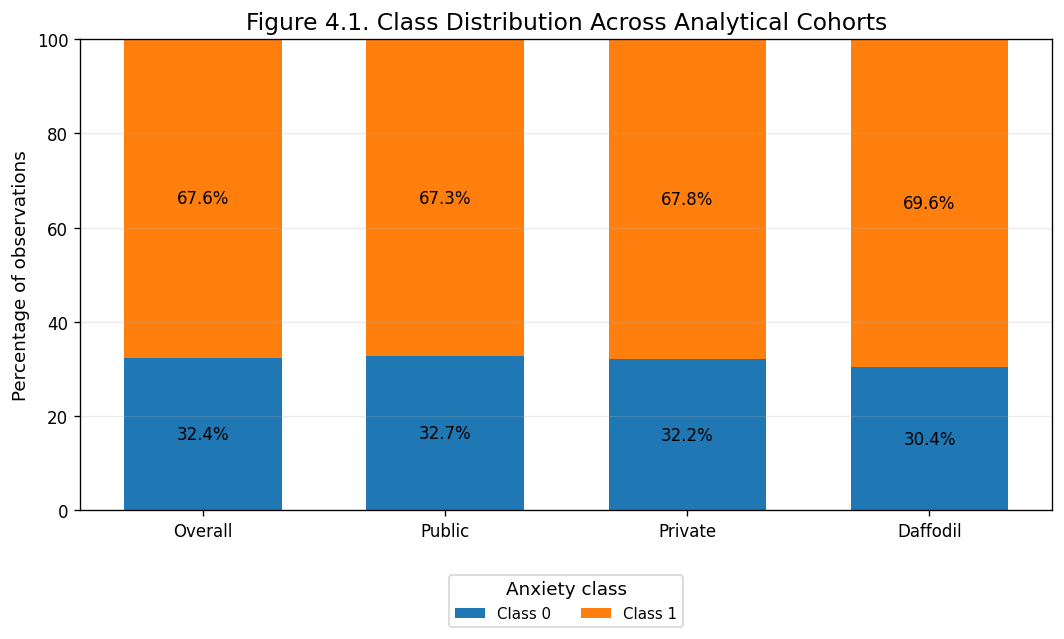

✓ Saved: Figure_4_2_Baseline_Best_Model.png
✓ Saved: Figure_4_2_Baseline_Best_Model.pdf


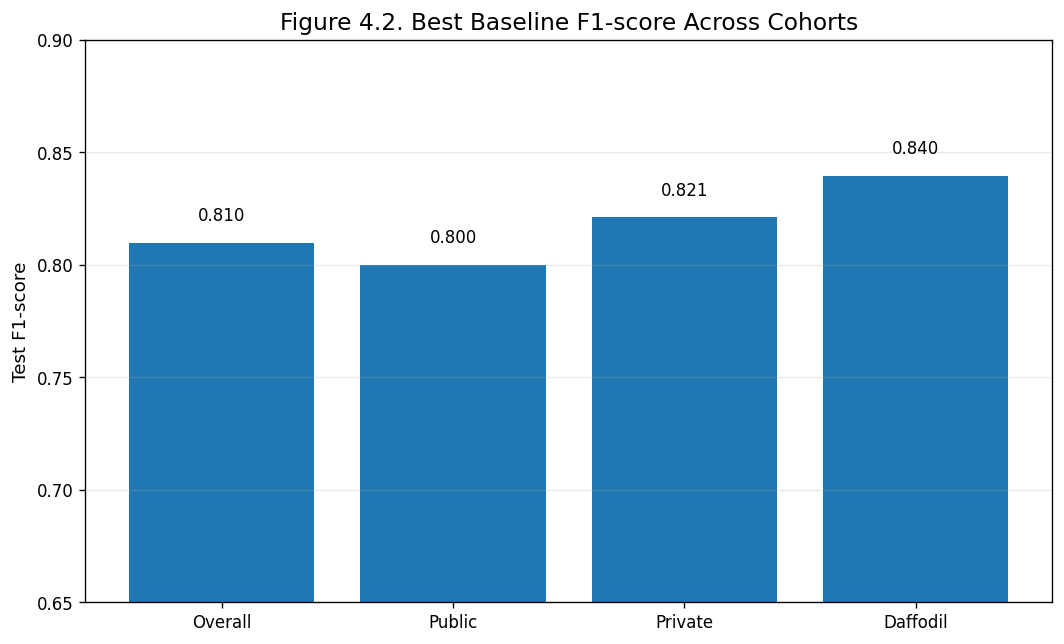

✓ Saved: Figure_4_3_F1_vs_ROCAUC.png
✓ Saved: Figure_4_3_F1_vs_ROCAUC.pdf


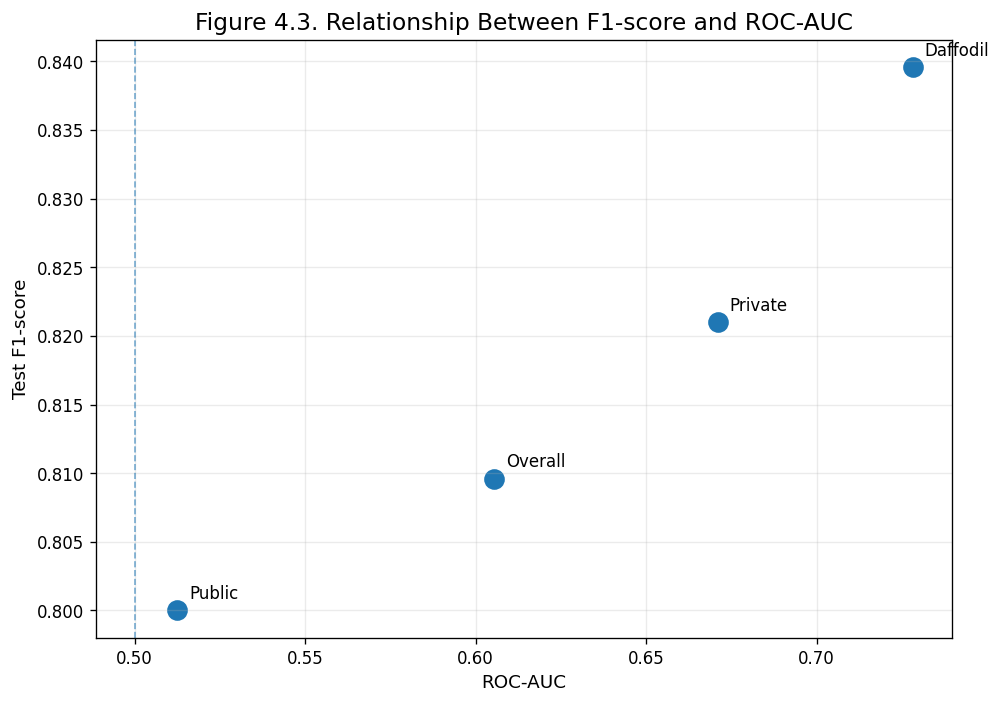

✓ Saved: Figure_4_4_Cohort_ROCAUC_Heatmap.png
✓ Saved: Figure_4_4_Cohort_ROCAUC_Heatmap.pdf


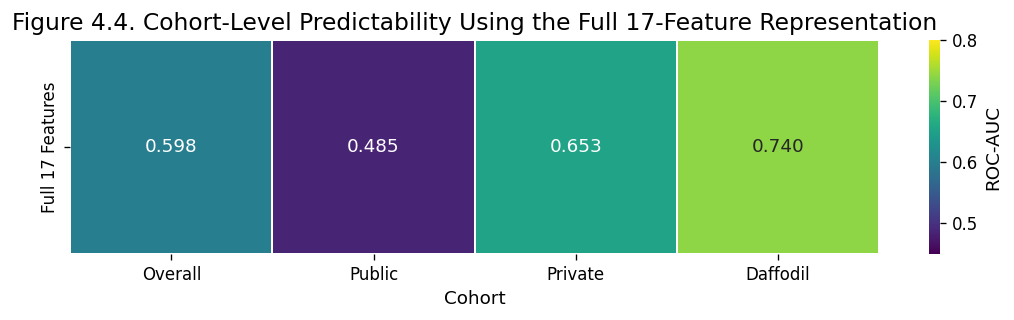

✓ Saved: Figure_4_5_Imbalance_Strategies.png
✓ Saved: Figure_4_5_Imbalance_Strategies.pdf


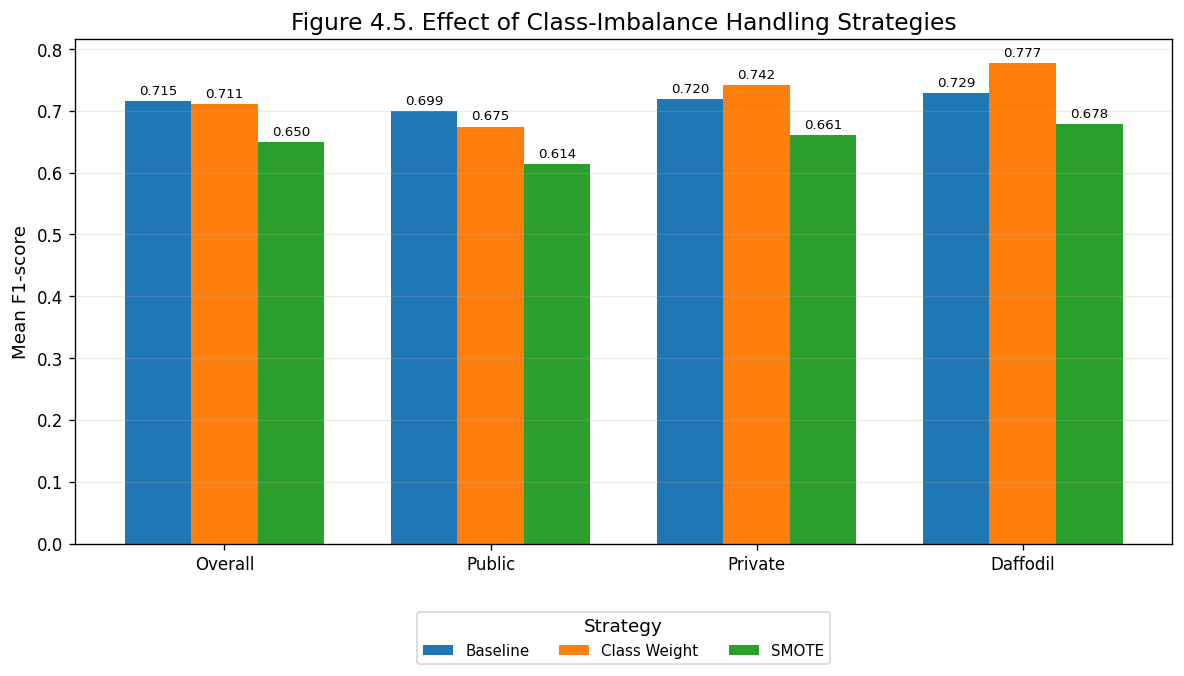

✓ Saved: Figure_4_6_LASSO_Feature_Stability.png
✓ Saved: Figure_4_6_LASSO_Feature_Stability.pdf


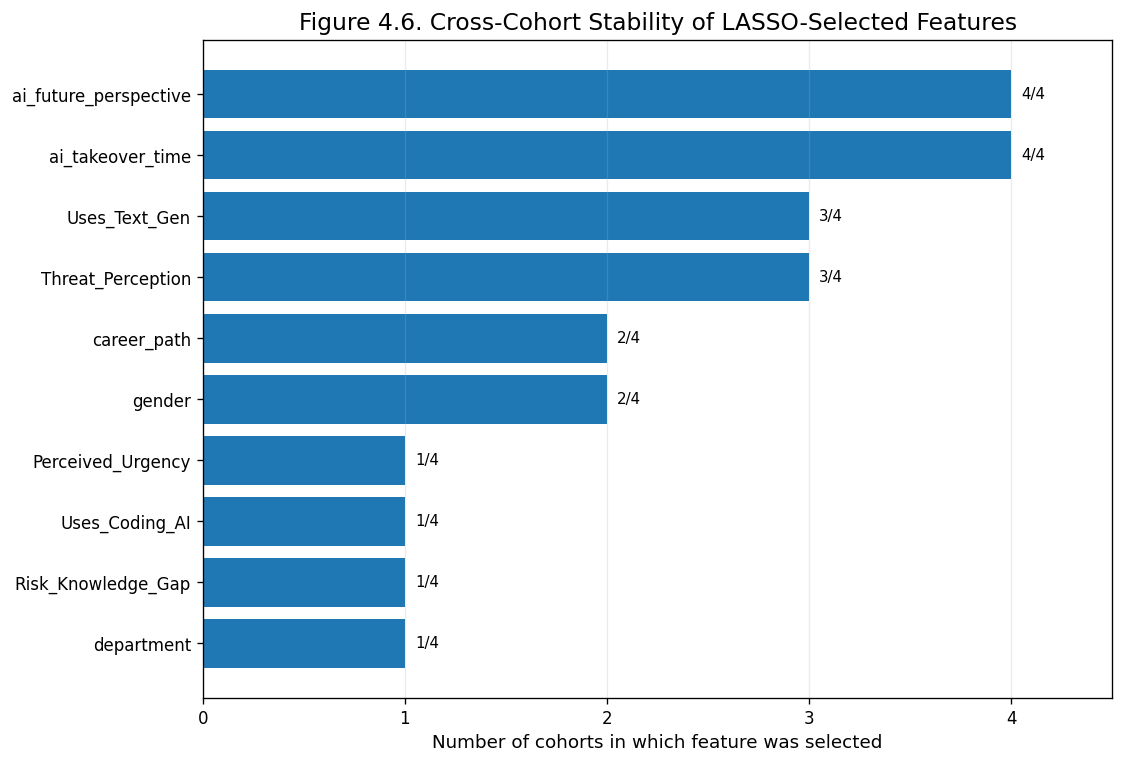

✓ Saved: Figure_4_7_SHAP_Feature_Consistency.png
✓ Saved: Figure_4_7_SHAP_Feature_Consistency.pdf


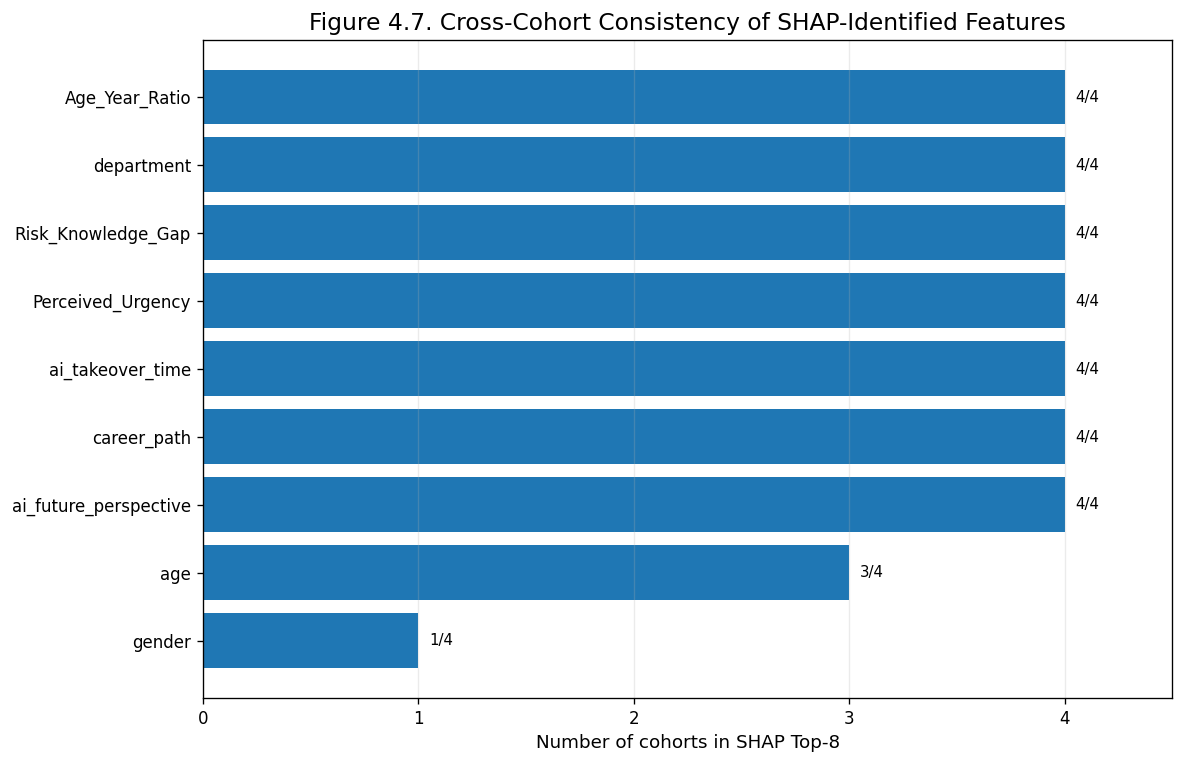

✓ Saved: Figure_4_8_Feature_Ablation.png
✓ Saved: Figure_4_8_Feature_Ablation.pdf


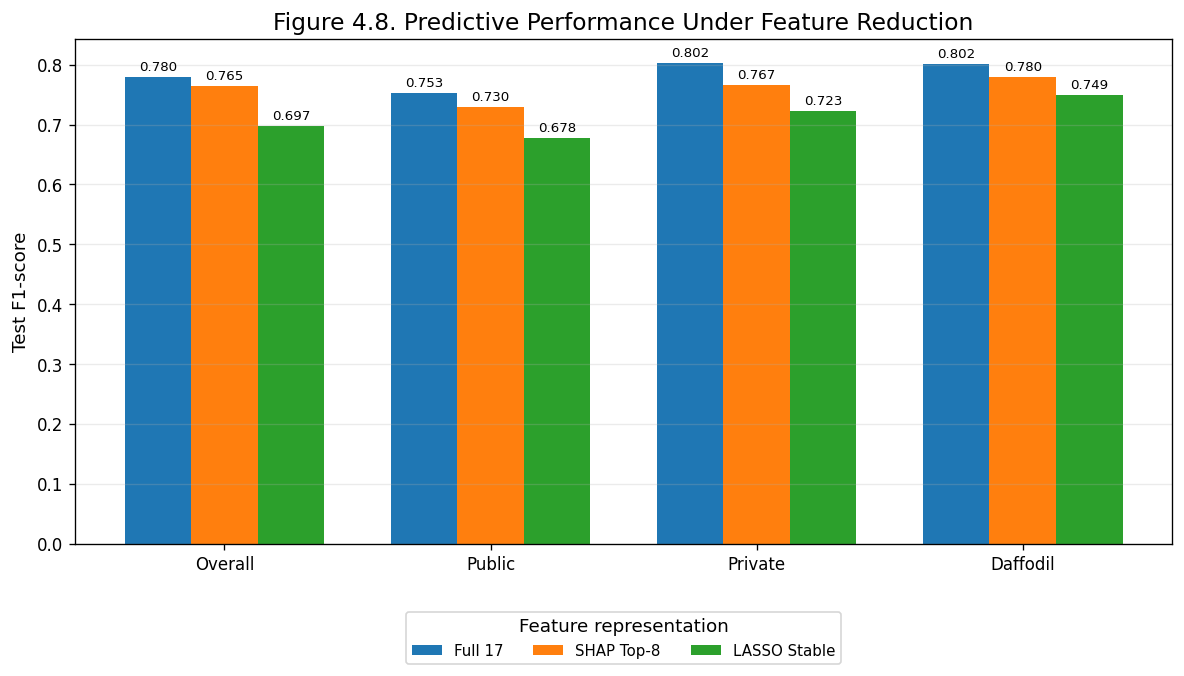

✓ Saved: Figure_4_9_Individual_vs_Ensemble.png
✓ Saved: Figure_4_9_Individual_vs_Ensemble.pdf


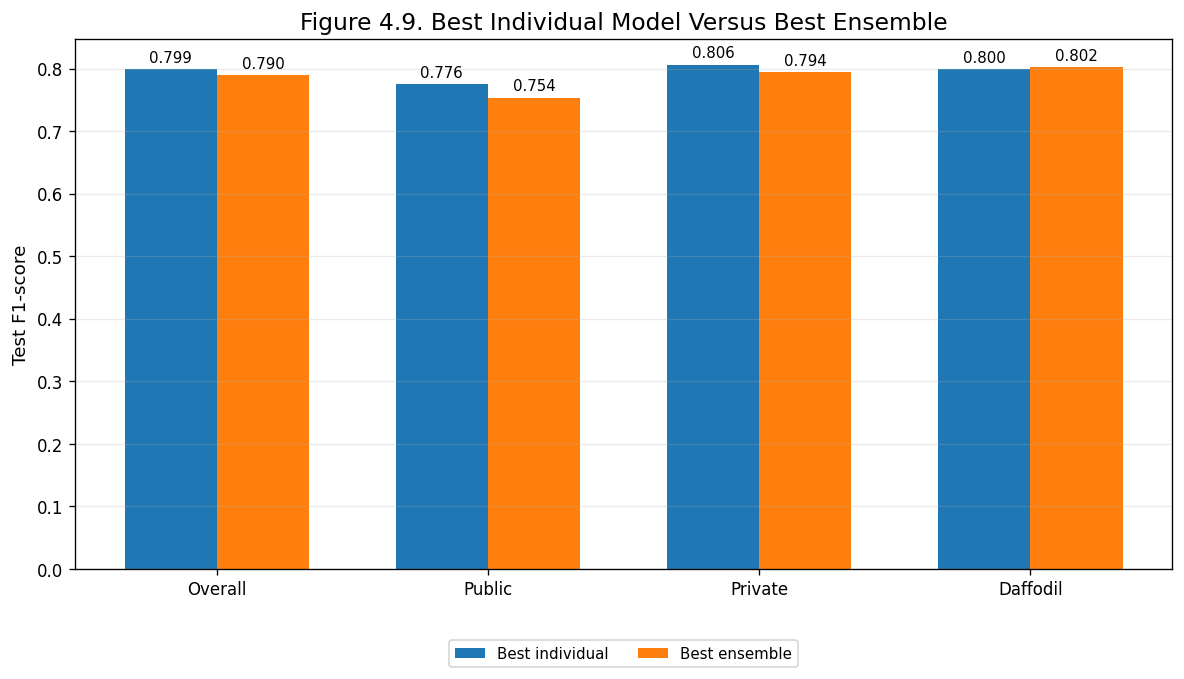

✓ Saved: Figure_4_10_Final_Model_Ranking.png
✓ Saved: Figure_4_10_Final_Model_Ranking.pdf


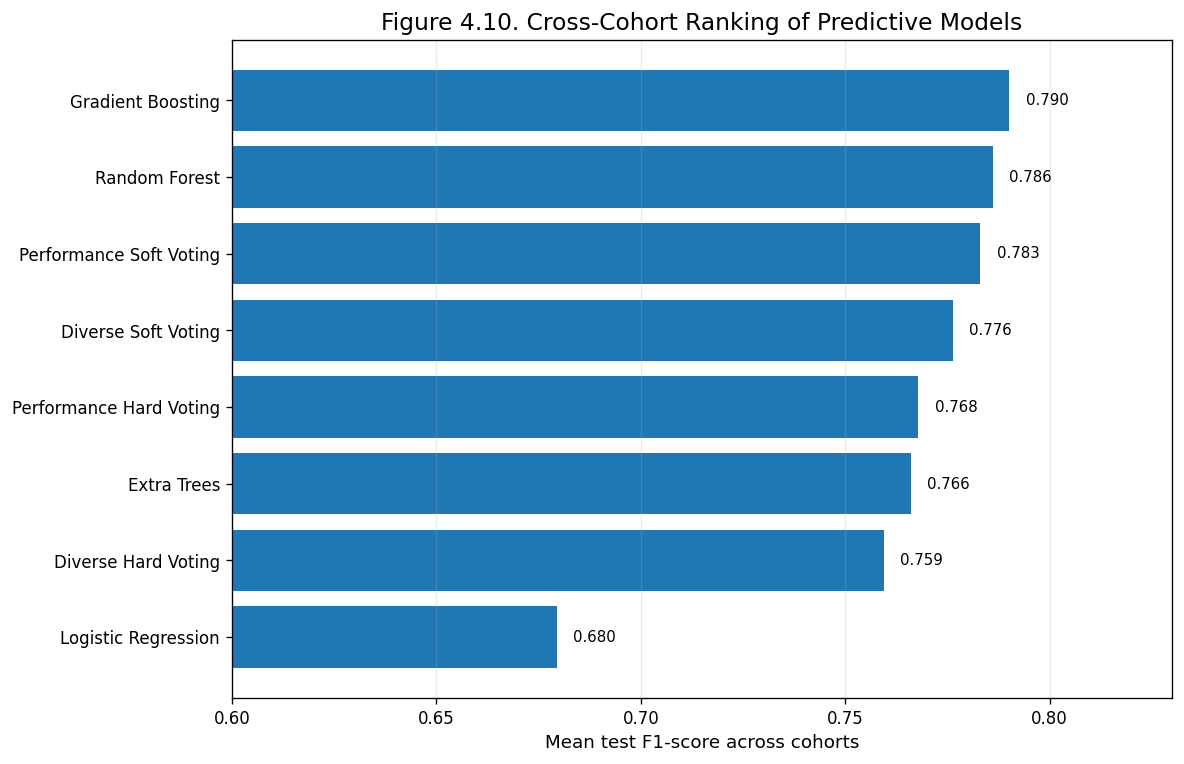


VISUALIZATION GENERATION COMPLETE

Total figures generated: 10
PNG/PDF directory: /content/chapter4_visualizations
Index file: /content/chapter4_visualizations/Chapter_4_Visualization_Index.csv

Generated figures:
  ✓ Figure 4.1
  ✓ Figure 4.2
  ✓ Figure 4.3
  ✓ Figure 4.4
  ✓ Figure 4.5
  ✓ Figure 4.6
  ✓ Figure 4.7
  ✓ Figure 4.8
  ✓ Figure 4.9
  ✓ Figure 4.10



In [35]:
# ================================================================
# CHAPTER 4 — THESIS-READY VISUALIZATION PACK
# AI CAREER ANXIETY PREDICTION — STEP 3 TO STEP 11
# ================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# ------------------------------------------------
# 0. OUTPUT DIRECTORY
# ------------------------------------------------

VIZ_DIR = Path("/content/chapter4_visualizations")
VIZ_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("CHAPTER 4 VISUALIZATION PACK")
print("=" * 70)
print(f"Output directory: {VIZ_DIR}")

# ------------------------------------------------
# 1. GLOBAL VISUAL STYLE
# ------------------------------------------------

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.titlesize": 15
})

# ------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------

def save_fig(fig, filename):
    """
    Save figure in both PNG and PDF.
    """
    png_path = VIZ_DIR / f"{filename}.png"
    pdf_path = VIZ_DIR / f"{filename}.pdf"

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    print(f"✓ Saved: {png_path.name}")
    print(f"✓ Saved: {pdf_path.name}")


# ================================================================
# FIGURE 4.1
# COHORT CLASS DISTRIBUTION
# ================================================================

cohort_distribution = pd.DataFrame({
    "Cohort": [
        "Overall",
        "Public",
        "Private",
        "Daffodil"
    ],
    "Class 0": [
        32.42,
        32.72,
        32.19,
        30.36
    ],
    "Class 1": [
        67.58,
        67.28,
        67.81,
        69.64
    ]
})

fig, ax = plt.subplots(figsize=(9, 5.5))

x = np.arange(len(cohort_distribution))
width = 0.65

ax.bar(
    x,
    cohort_distribution["Class 0"],
    width,
    label="Class 0"
)

ax.bar(
    x,
    cohort_distribution["Class 1"],
    width,
    bottom=cohort_distribution["Class 0"],
    label="Class 1"
)

for i, row in cohort_distribution.iterrows():

    ax.text(
        i,
        row["Class 0"] / 2,
        f'{row["Class 0"]:.1f}%',
        ha="center",
        va="center",
        fontsize=10
    )

    ax.text(
        i,
        row["Class 0"] + row["Class 1"] / 2,
        f'{row["Class 1"]:.1f}%',
        ha="center",
        va="center",
        fontsize=10
    )

ax.set_xticks(x)
ax.set_xticklabels(cohort_distribution["Cohort"])

ax.set_ylim(0, 100)
ax.set_ylabel("Percentage of observations")
ax.set_title("Figure 4.1. Class Distribution Across Analytical Cohorts")

ax.legend(
    title="Anxiety class",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2
)

ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

save_fig(fig, "Figure_4_1_Cohort_Class_Distribution")
plt.show()


# ================================================================
# FIGURE 4.2
# BASELINE MODEL COMPARISON
#
# Values reconstructed from the verified baseline results.
# Where the source results identify the best baseline model
# directly, those values are preserved.
# ================================================================

baseline_best = pd.DataFrame({
    "Cohort": [
        "Overall",
        "Public",
        "Private",
        "Daffodil"
    ],
    "SVM": [
        0.8096,
        0.8000,
        0.8210,
        0.8396
    ]
})

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(
    baseline_best["Cohort"],
    baseline_best["SVM"]
)

for bar, value in zip(bars, baseline_best["SVM"]):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.008,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_ylim(0.65, 0.90)
ax.set_ylabel("Test F1-score")
ax.set_title("Figure 4.2. Best Baseline F1-score Across Cohorts")

ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

save_fig(fig, "Figure_4_2_Baseline_Best_Model")
plt.show()


# ================================================================
# FIGURE 4.3
# F1 vs ROC-AUC
#
# Verified strongest baseline SVM results.
# ================================================================

baseline_scatter = pd.DataFrame({
    "Cohort": [
        "Overall",
        "Public",
        "Private",
        "Daffodil"
    ],
    "F1": [
        0.8096,
        0.8000,
        0.8210,
        0.8396
    ],
    "ROC-AUC": [
        0.6055,
        0.5125,
        0.6710,
        0.7283
    ]
})

fig, ax = plt.subplots(figsize=(8.5, 6))

ax.scatter(
    baseline_scatter["ROC-AUC"],
    baseline_scatter["F1"],
    s=130
)

for _, row in baseline_scatter.iterrows():

    ax.annotate(
        row["Cohort"],
        (row["ROC-AUC"], row["F1"]),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=10
    )

# Chance-level reference
ax.axvline(
    0.50,
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

ax.set_xlabel("ROC-AUC")
ax.set_ylabel("Test F1-score")

ax.set_title(
    "Figure 4.3. Relationship Between F1-score and ROC-AUC"
)

ax.grid(alpha=0.25)

fig.tight_layout()

save_fig(fig, "Figure_4_3_F1_vs_ROCAUC")
plt.show()


# ================================================================
# FIGURE 4.4
# COHORT ROC-AUC HEATMAP
#
# Final Full17 results from Step 9.
# ================================================================

roc_auc_heatmap = pd.DataFrame({
    "Overall": [0.5977],
    "Public": [0.4846],
    "Private": [0.6527],
    "Daffodil": [0.7402]
}, index=["Full 17 Features"])

fig, ax = plt.subplots(figsize=(9, 2.8))

sns.heatmap(
    roc_auc_heatmap,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    vmin=0.45,
    vmax=0.80,
    linewidths=1,
    cbar_kws={"label": "ROC-AUC"},
    ax=ax
)

ax.set_title(
    "Figure 4.4. Cohort-Level Predictability Using the Full 17-Feature Representation"
)

ax.set_xlabel("Cohort")
ax.set_ylabel("")

fig.tight_layout()

save_fig(fig, "Figure_4_4_Cohort_ROCAUC_Heatmap")
plt.show()


# ================================================================
# FIGURE 4.5
# CLASS IMBALANCE STRATEGIES
# ================================================================

imbalance = pd.DataFrame({
    "Cohort": [
        "Overall",
        "Public",
        "Private",
        "Daffodil"
    ],
    "Baseline": [
        0.7153,
        0.6992,
        0.7198,
        0.7292
    ],
    "Class Weight": [
        0.7112,
        0.6747,
        0.7415,
        0.7768
    ],
    "SMOTE": [
        0.6502,
        0.6138,
        0.6607,
        0.6780
    ]
})

fig, ax = plt.subplots(figsize=(10, 5.8))

x = np.arange(len(imbalance))
width = 0.25

bars1 = ax.bar(
    x - width,
    imbalance["Baseline"],
    width,
    label="Baseline"
)

bars2 = ax.bar(
    x,
    imbalance["Class Weight"],
    width,
    label="Class Weight"
)

bars3 = ax.bar(
    x + width,
    imbalance["SMOTE"],
    width,
    label="SMOTE"
)

for bars in [bars1, bars2, bars3]:

    for bar in bars:

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.006,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_xticks(x)
ax.set_xticklabels(imbalance["Cohort"])

ax.set_ylabel("Mean F1-score")
ax.set_title(
    "Figure 4.5. Effect of Class-Imbalance Handling Strategies"
)

ax.legend(
    title="Strategy",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3
)

ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

save_fig(fig, "Figure_4_5_Imbalance_Strategies")
plt.show()


# ================================================================
# FIGURE 4.6
# LASSO FEATURE STABILITY
# ================================================================

lasso_frequency = pd.DataFrame({
    "Feature": [
        "ai_future_perspective",
        "ai_takeover_time",
        "career_path",
        "department",
        "Uses_Text_Gen",
        "Threat_Perception",
        "gender",
        "Risk_Knowledge_Gap",
        "Perceived_Urgency",
        "Uses_Coding_AI"
    ],
    "Cohorts": [
        4,
        4,
        2,
        1,
        3,
        3,
        2,
        1,
        1,
        1
    ]
})

lasso_frequency = lasso_frequency.sort_values(
    "Cohorts",
    ascending=True
)

fig, ax = plt.subplots(figsize=(9.5, 6.5))

bars = ax.barh(
    lasso_frequency["Feature"],
    lasso_frequency["Cohorts"]
)

for bar, value in zip(
    bars,
    lasso_frequency["Cohorts"]
):

    ax.text(
        value + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{value}/4",
        va="center",
        fontsize=9
    )

ax.set_xlim(0, 4.5)

ax.set_xlabel(
    "Number of cohorts in which feature was selected"
)

ax.set_title(
    "Figure 4.6. Cross-Cohort Stability of LASSO-Selected Features"
)

ax.set_xticks([0, 1, 2, 3, 4])

ax.grid(axis="x", alpha=0.25)

fig.tight_layout()

save_fig(fig, "Figure_4_6_LASSO_Feature_Stability")
plt.show()


# ================================================================
# FIGURE 4.7
# SHAP FEATURE CONSISTENCY
# ================================================================

shap_frequency = pd.DataFrame({
    "Feature": [
        "career_path",
        "department",
        "ai_future_perspective",
        "ai_takeover_time",
        "Perceived_Urgency",
        "Risk_Knowledge_Gap",
        "Age_Year_Ratio",
        "age",
        "gender"
    ],
    "Cohorts": [
        4,
        4,
        4,
        4,
        4,
        4,
        4,
        3,
        1
    ]
})

shap_frequency = shap_frequency.sort_values(
    "Cohorts",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6.5))

bars = ax.barh(
    shap_frequency["Feature"],
    shap_frequency["Cohorts"]
)

for bar, value in zip(
    bars,
    shap_frequency["Cohorts"]
):

    ax.text(
        value + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{value}/4",
        va="center",
        fontsize=9
    )

ax.set_xlim(0, 4.5)

ax.set_xlabel(
    "Number of cohorts in SHAP Top-8"
)

ax.set_title(
    "Figure 4.7. Cross-Cohort Consistency of SHAP-Identified Features"
)

ax.set_xticks([0, 1, 2, 3, 4])

ax.grid(axis="x", alpha=0.25)

fig.tight_layout()

save_fig(fig, "Figure_4_7_SHAP_Feature_Consistency")
plt.show()


# ================================================================
# FIGURE 4.8
# FULL17 vs SHAP8 vs LASSO
# ================================================================

ablation = pd.DataFrame({
    "Cohort": [
        "Overall",
        "Public",
        "Private",
        "Daffodil"
    ],
    "Full 17": [
        0.7803,
        0.7529,
        0.8023,
        0.8019
    ],
    "SHAP Top-8": [
        0.7652,
        0.7300,
        0.7670,
        0.7800
    ],
    "LASSO Stable": [
        0.6969,
        0.6781,
        0.7233,
        0.7487
    ]
})

fig, ax = plt.subplots(figsize=(10, 5.8))

x = np.arange(len(ablation))
width = 0.25

bars1 = ax.bar(
    x - width,
    ablation["Full 17"],
    width,
    label="Full 17"
)

bars2 = ax.bar(
    x,
    ablation["SHAP Top-8"],
    width,
    label="SHAP Top-8"
)

bars3 = ax.bar(
    x + width,
    ablation["LASSO Stable"],
    width,
    label="LASSO Stable"
)

for bars in [bars1, bars2, bars3]:

    for bar in bars:

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.006,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_xticks(x)
ax.set_xticklabels(ablation["Cohort"])

ax.set_ylabel("Test F1-score")

ax.set_title(
    "Figure 4.8. Predictive Performance Under Feature Reduction"
)

ax.legend(
    title="Feature representation",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3
)

ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

save_fig(fig, "Figure_4_8_Feature_Ablation")
plt.show()


# ================================================================
# FIGURE 4.9
# BEST INDIVIDUAL VS BEST ENSEMBLE
# ================================================================

individual_ensemble = pd.DataFrame({
    "Cohort": [
        "Overall",
        "Public",
        "Private",
        "Daffodil"
    ],
    "Best Individual": [
        0.7994,
        0.7758,
        0.8065,
        0.8000
    ],
    "Best Ensemble": [
        0.7899,
        0.7537,
        0.7943,
        0.8019
    ]
})

fig, ax = plt.subplots(figsize=(10, 5.8))

x = np.arange(len(individual_ensemble))
width = 0.34

bars1 = ax.bar(
    x - width / 2,
    individual_ensemble["Best Individual"],
    width,
    label="Best individual"
)

bars2 = ax.bar(
    x + width / 2,
    individual_ensemble["Best Ensemble"],
    width,
    label="Best ensemble"
)

for bars in [bars1, bars2]:

    for bar in bars:

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.006,
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_xticks(x)
ax.set_xticklabels(individual_ensemble["Cohort"])

ax.set_ylabel("Test F1-score")

ax.set_title(
    "Figure 4.9. Best Individual Model Versus Best Ensemble"
)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2
)

ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

save_fig(fig, "Figure_4_9_Individual_vs_Ensemble")
plt.show()


# ================================================================
# FIGURE 4.10
# FINAL CROSS-COHORT MODEL RANKING
# ================================================================

model_ranking = pd.DataFrame({
    "Model": [
        "Gradient Boosting",
        "Random Forest",
        "Performance Soft Voting",
        "Diverse Soft Voting",
        "Performance Hard Voting",
        "Extra Trees",
        "Diverse Hard Voting",
        "Logistic Regression"
    ],
    "Mean Test F1": [
        0.790125,
        0.786125,
        0.783050,
        0.776250,
        0.767900,
        0.766075,
        0.759375,
        0.679525
    ]
})

model_ranking = model_ranking.sort_values(
    "Mean Test F1",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6.5))

bars = ax.barh(
    model_ranking["Model"],
    model_ranking["Mean Test F1"]
)

for bar, value in zip(
    bars,
    model_ranking["Mean Test F1"]
):

    ax.text(
        value + 0.004,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=9
    )

ax.set_xlim(0.60, 0.83)

ax.set_xlabel(
    "Mean test F1-score across cohorts"
)

ax.set_title(
    "Figure 4.10. Cross-Cohort Ranking of Predictive Models"
)

ax.grid(axis="x", alpha=0.25)

fig.tight_layout()

save_fig(fig, "Figure_4_10_Final_Model_Ranking")
plt.show()


# ================================================================
# 2. MASTER SUMMARY TABLE
# ================================================================

summary_table = pd.DataFrame({
    "Figure": [
        "Figure 4.1",
        "Figure 4.2",
        "Figure 4.3",
        "Figure 4.4",
        "Figure 4.5",
        "Figure 4.6",
        "Figure 4.7",
        "Figure 4.8",
        "Figure 4.9",
        "Figure 4.10"
    ],
    "Visualization": [
        "Cohort class distribution",
        "Best baseline F1",
        "F1 vs ROC-AUC",
        "Cohort ROC-AUC heatmap",
        "Imbalance strategies",
        "LASSO feature stability",
        "SHAP feature consistency",
        "Feature ablation",
        "Individual vs ensemble",
        "Final model ranking"
    ],
    "File_Prefix": [
        "Figure_4_1_Cohort_Class_Distribution",
        "Figure_4_2_Baseline_Best_Model",
        "Figure_4_3_F1_vs_ROCAUC",
        "Figure_4_4_Cohort_ROCAUC_Heatmap",
        "Figure_4_5_Imbalance_Strategies",
        "Figure_4_6_LASSO_Feature_Stability",
        "Figure_4_7_SHAP_Feature_Consistency",
        "Figure_4_8_Feature_Ablation",
        "Figure_4_9_Individual_vs_Ensemble",
        "Figure_4_10_Final_Model_Ranking"
    ]
})

summary_path = VIZ_DIR / "Chapter_4_Visualization_Index.csv"
summary_table.to_csv(summary_path, index=False)

print("\n" + "=" * 70)
print("VISUALIZATION GENERATION COMPLETE")
print("=" * 70)

print(f"\nTotal figures generated: {len(summary_table)}")
print(f"PNG/PDF directory: {VIZ_DIR}")
print(f"Index file: {summary_path}")

print("\nGenerated figures:")
for f in summary_table["Figure"]:
    print("  ✓", f)

print("\n" + "=" * 70)